# CLEETS-SMART: when does each Welsh district reach a fully electric private fleet?

**Core question.** For each of the 22 Welsh Local Authority Districts: the quarterly
**adoption ratio** (private battery-electric vehicles / private licensed vehicles across all body types, matched
scope), the **2032 ban on new non-electric private sales** imposed as a constraint on the
flow of new registrations, fleet propagation to **2053** through age-structured turnover, and a
**ranking of which district reaches (near-)full electrification first** — delivered by
Stage 9 as `electrification_arrival` / `welsh_lad_electrification_arrival.csv`, with
figures in Stage 9b.

Companion notebook to *Predicting electric vehicle (EV) adoption in Wales using a semantic
knowledge graph*. Every table and figure in the paper is produced by a stage below.
**Run with `Runtime → Restart session and run all`.** The modelling cells use
collision-resistant names and robust RDF traversal, so they do not depend on stale Colab
variables or exact RDF literal datatypes.

The final cell is a **paper parity check**: it lists every quantity the manuscript states
against the value this run produced, so any divergence is visible rather than silent.

| Paper | Notebook |
|---|---|
| §2.1 Data, Figure 2 (keepership and charger history) | Stage 2, Figure 2 cell |
| §2.1.5 Figure 3 (population and density maps) | Figure 3 cell |
| §2.1.6 Table 1 (provision pressure and deprivation) | Table 1 cell |
| §2.2 CLEETS ontology and knowledge graph, Tables 2–3 | Stages 1–3 |
| §2.3.1 / §3.2 Measurement-scope decomposition, Table 4 | Stage 6a-bis |
| §2.3.2–§2.3.4 / §3.4.1 Bounded logistic, NN and GNN, Tables 5–7 | Stages 13, 14 |
| §3.4.2 Cross-sectional comparison, Table 8 | Stage 5 |
| §2.3.6 / §3.4.3 / §3.5 Hierarchical diffusion, Table 9, Figures 4–5 | Stages 6, 11 |
| §2.3.5 / §3.6 Age-structured turnover ceiling, Table 10 | Stages 7–8 |
| §3.7 Reconciliation of diffusion against turnover, Figure 6 | Stage 11d |
| §3.8 Fleet composition to 2053, Figure 7 | Stage 9 |
| §3.1 Knowledge-graph release, Listing 1 | Stage 12, Listing 1 cell |

In [ ]:
# ============================================================
# 0. Environment
# ============================================================
!pip -q install rdflib pyshacl pandas numpy scikit-learn matplotlib gdown odfpy

import hashlib, gzip, io, json, os, re, sys, time, warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import math
import pandas as pd
from rdflib import Graph, Namespace, URIRef, Literal, BNode, RDF, RDFS, OWL, XSD
from rdflib.namespace import DCTERMS, SKOS

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)
print("rdflib", __import__("rdflib").__version__, "| pandas", pd.__version__)

rdflib 7.6.0 | pandas 2.2.3


In [ ]:
# ============================================================
# 0b. Environment compatibility shims
#   * gdown >= 6 removed the `fuzzy` kwarg (fuzzy matching is now the
#     default). Wrap download() so calls written for gdown 5.x still run.
#   * `display` is a notebook builtin; define a fallback so the pipeline
#     also runs headless (python script / nbconvert without IPython).
# ============================================================
import gdown as _gdown_mod
_orig_gdown_download = _gdown_mod.download
def _gdown_download_compat(*args, **kwargs):
    try:
        return _orig_gdown_download(*args, **kwargs)
    except TypeError:
        kwargs.pop("fuzzy", None)
        return _orig_gdown_download(*args, **kwargs)
_gdown_mod.download = _gdown_download_compat

try:
    display
except NameError:
    display = print
print("compat shims active: gdown", _gdown_mod.__version__)


compat shims active: gdown 5.2.2


In [ ]:
# ============================================================
# Figure defaults
# Set once here so every chart in the notebook is legible at print size and no
# individual figure needs its own font settings. Raise FONT_SCALE for slides.
# ============================================================
import matplotlib as mpl
import matplotlib.pyplot as plt

FONT_SCALE = 1.0
_base = {
    "font.size":        13, "axes.titlesize":   16, "axes.labelsize":   14,
    "xtick.labelsize":  12, "ytick.labelsize":  12, "legend.fontsize":  12,
    "legend.title_fontsize": 12, "figure.titlesize": 17,
}
mpl.rcParams.update({k: v * FONT_SCALE for k, v in _base.items()})
mpl.rcParams.update({
    "axes.titleweight": "semibold",
    "figure.dpi": 110, "savefig.dpi": 220, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
})
print(f"Figure fonts set (scale {FONT_SCALE}): base {mpl.rcParams['font.size']:.0f}pt, "
      f"axis titles {mpl.rcParams['axes.titlesize']:.0f}pt")


Figure fonts set (scale 1.0): base 13pt, axis titles 16pt


In [ ]:
# ============================================================
# 1. Configuration
# ============================================================
WORK = Path("cleets_out"); WORK.mkdir(exist_ok=True)

# --- Stage 2 input: downloaded directly, nothing to upload ----------
# Drive copies must be shared as "Anyone with the link". The charge point
# sheet is read through the CSV export endpoint.
DRIVE = "https://drive.google.com/file/d/%s/view?usp=sharing"
SHEET = "https://docs.google.com/spreadsheets/d/%s/export?format=csv&gid=0"

DATASET_SOURCES = {
    "keepership":        {"url": DRIVE % "1o5kQicaRDBe8xP_uQMOZ9cBe2TU-r-HM", "kind": "drive"},
    "charger":           {"url": DRIVE % "1-HjLsZAvcDyYHgn2jRwIVkiXV3102E6p", "kind": "drive"},
    "population":        {"url": DRIVE % "1vzXEyVrJgLcgvVzIzivpCYbycL0jLFmM", "kind": "drive"},
    "wales_deprivation": {"url": DRIVE % "1K-PbySgovyzpFnnoY9exfDHpGXB1dLjT", "kind": "drive"},
    "density":           {"url": DRIVE % "1nSbbxY8_hvV47OnZwBWo3-N-HuMdmL_-", "kind": "drive"},
    # "england_deprivation": {"url": DRIVE % "1EXlkYrw--ueX1dzRSTUfzYxF5Gfk350W", "kind": "drive"},
}

DATASET_LABEL = {
    "keepership":        ("VEH0132 licensed ULEVs by local authority", "Department for Transport"),
    "charger":           ("EVCI9001 public charge point counts", "Department for Transport"),
    "population":        ("StatsWales population estimates by local authority", "Welsh Government"),
    "wales_deprivation": ("WIMD 2025 indicator data", "Welsh Government"),
    "density":           ("ONS population density, England and Wales", "Office for National Statistics"),
}

# --- Target definition ---------------------------------------------
TARGET_PERIOD   = "2025-Q2"     # reference period for the modelling snapshot
POPULATION_YEAR = 2024          # ONS mid-year estimate used as the denominator
# "evs_per_1000"         - private BEVs per 1,000 residents
# "evs_per_charge_point" - charging adequacy; charge point features are dropped
#                          automatically because they are components of it
TARGET          = "evs_per_1000"

# Feature set:
#   "structural"     - no lagged EV variables. The hard, meaningful task.
#   "autoregressive" - adds EV counts at t-1 / t-4. R^2 goes to ~0.99 and the
#                      model comparison becomes uninformative. Use only if you
#                      are explicitly framing this as forecasting.
FEATURE_SET = "structural"

# --- Charge point counts -------------------------------------------
# The DfT EVCI ODS table reports devices per 100,000 residents; the sheet above
# reports ABSOLUTE COUNTS, which is what makes evsPerChargePoint computable.
# Cite EVCI9001 in the paper and archive a dated CSV export: a Google Sheet is
# mutable and carries no version identifier.
CHARGER_SHEET_ACCESSED = "2026-07-28"

# --- Commonsense layer ---------------------------------------------
ENABLE_CSKG      = True         # False -> curated fallback, no 2 GB download
CSKG_URL         = "https://zenodo.org/record/4331372/files/cskg.tsv.gz"
MAX_MATCHED_EDGES = 20000

# --- Modelling ------------------------------------------------------
SEEDS = [0, 1, 2, 3, 4]         # stochastic models are refit under each

# --- Namespaces (slash namespace, matching the released KG) ---------
CLEETS   = Namespace("https://w3id.org/def/cleets#")
DATA     = Namespace("https://w3id.org/def/cleets#data/")
RES      = Namespace("https://w3id.org/def/cleets#resource/")
CS       = Namespace("https://w3id.org/def/cleets#commonsense/")
CSKG_NS  = Namespace("https://w3id.org/def/cleets#external/cskg/")
PROV     = Namespace("http://www.w3.org/ns/prov#")
DCAT     = Namespace("http://www.w3.org/ns/dcat#")
GEO      = Namespace("http://www.opengis.net/ont/geosparql#")
TIME     = Namespace("http://www.w3.org/2006/time#")
SH       = Namespace("http://www.w3.org/ns/shacl#")

PREFIXES = dict(cleets=CLEETS, cleetsdata=DATA, cleetsres=RES, cleetscs=CS,
                cskg=CSKG_NS, prov=PROV, dcat=DCAT, geo=GEO, time=TIME,
                sh=SH, dcterms=DCTERMS, skos=SKOS, owl=OWL, xsd=XSD)

def bind_all(g):
    for p, n in PREFIXES.items():
        g.bind(p, n)
    return g

def digest(*parts, n=16):
    return hashlib.sha256("|".join(str(p) for p in parts).encode()).hexdigest()[:n]

RUN_ID = digest(datetime.now(timezone.utc).isoformat(), n=12)
print("run id:", RUN_ID, "| target:", TARGET, "@", TARGET_PERIOD, "| features:", FEATURE_SET)

run id: dc7ad5b931b0 | target: evs_per_1000 @ 2025-Q2 | features: structural


## Stage 1 — Build the ontology

The released ontology (CLEETS v1.3.0, `https://w3id.org/def/cleets#`) is a **single OWL 2 DL
module** that imports SOSA and OWL-Time and exposes ontology-local aliases of the imported terms
through `owl:equivalentClass` / `owl:equivalentProperty`. The cardinality restrictions sit on the
four observation *subtypes*, not on the aliased `cleets:Observation`, which is what makes the
equivalence conservative over external sensor data (paper §2.2.1). Earlier releases (≤ 1.2.0) used a
two-module soft-reuse design that ruled out cross-vocabulary equivalence; the paper records both
positions and why the policy changed (§2.2.1).

**Vocabulary note.** This notebook's pipeline vocabulary predates v1.3.0 in places
(`EVKeepershipObservation`, `forGeographicArea`, `geographyCode`); the released v1.3.0 names are
`EVKeepership`, `forLAD`, `ladCode`. The paper reports this migration as pending (§2.2.1, §4:
re-ingestion against the 1.3.0 vocabulary). The namespace used throughout this notebook matches the
released IRI (`…/def/cleets#`), so queries written against the released ontology resolve here.

In [ ]:
CORE_TTL = r"""@prefix cleets: <https://w3id.org/def/cleets#> .
@prefix dcterms: <http://purl.org/dc/terms/> .
@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix vann: <http://purl.org/vocab/vann/> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

<https://w3id.org/def/cleets> a owl:Ontology ;
    dcterms:title "CLEETS EV Adoption Ontology - Core Module"@en ;
    dcterms:license <https://creativecommons.org/licenses/by/4.0/> ;
    vann:preferredNamespaceUri "https://w3id.org/def/cleets#" ;
    owl:versionIRI <https://w3id.org/def/cleets#1.5.0> ;
    owl:versionInfo "1.5.0" ;
    rdfs:comment "Logically self-contained: references no external vocabulary term. All reuse lives in the alignment module."@en .

cleets:mappingRationale a owl:AnnotationProperty ; rdfs:label "mapping rationale"@en .
cleets:openIssue a owl:AnnotationProperty ; rdfs:label "open issue"@en .

## Geography
cleets:GeographicArea a owl:Class ; rdfs:label "Geographic area"@en ;
    owl:hasKey ( cleets:geographyCode ) .
cleets:LAD a owl:Class ; rdfs:label "Local authority district or equivalent"@en ;
    rdfs:subClassOf cleets:GeographicArea .
cleets:LSOA a owl:Class ; rdfs:label "Lower-layer Super Output Area"@en ;
    rdfs:subClassOf cleets:GeographicArea ; owl:disjointWith cleets:LAD .
cleets:WelshLAD a owl:Class ; rdfs:label "Welsh local authority district"@en ; rdfs:subClassOf cleets:LAD .
cleets:EnglishLAD a owl:Class ; rdfs:label "English local authority district"@en ;
    rdfs:subClassOf cleets:LAD ; owl:disjointWith cleets:WelshLAD .
cleets:WelshLSOA a owl:Class ; rdfs:label "Welsh LSOA"@en ; rdfs:subClassOf cleets:LSOA .
cleets:EnglishLSOA a owl:Class ; rdfs:label "English LSOA"@en ;
    rdfs:subClassOf cleets:LSOA ; owl:disjointWith cleets:WelshLSOA .

## Time
cleets:Time a owl:Class ; rdfs:label "Reference period"@en ;
    rdfs:comment "A calendar quarter or year to which an observation refers."@en .

## Indicators and observations
cleets:Indicator a owl:Class ; rdfs:label "Indicator"@en .
cleets:Observation a owl:Class ; rdfs:label "Observation"@en ;
    rdfs:comment "One value of one indicator, for one area, for one period, derived from a source record."@en ;
    rdfs:subClassOf
      [ a owl:Restriction ; owl:onProperty cleets:forGeographicArea ;
        owl:onClass cleets:GeographicArea ; owl:qualifiedCardinality "1"^^xsd:nonNegativeInteger ] ,
      [ a owl:Restriction ; owl:onProperty cleets:forTime ;
        owl:onClass cleets:Time ; owl:maxQualifiedCardinality "1"^^xsd:nonNegativeInteger ] .

cleets:EVKeepershipObservation a owl:Class ; rdfs:subClassOf cleets:Observation ;
    rdfs:label "EV keepership observation"@en .
cleets:EVChargerCountObservation a owl:Class ; rdfs:subClassOf cleets:Observation ;
    rdfs:label "EV charge point count observation"@en ;
    rdfs:comment "Absolute number of public charging devices in an area at a reference date."@en .
cleets:EVChargerProvisionObservation a owl:Class ; rdfs:subClassOf cleets:Observation ;
    rdfs:label "EV charger provision observation"@en ;
    rdfs:comment "Public charging devices per 100,000 residents. Derived from a charge point count and a population estimate."@en .
cleets:ChargingAdequacyObservation a owl:Class ; rdfs:subClassOf cleets:Observation ;
    rdfs:label "Charging adequacy observation"@en ;
    rdfs:comment "Licensed electric vehicles per public charge point for an area and period."@en .
cleets:PopulationObservation a owl:Class ; rdfs:subClassOf cleets:Observation ;
    rdfs:label "Population observation"@en .
cleets:PopulationDensityObservation a owl:Class ; rdfs:subClassOf cleets:Observation ;
    rdfs:label "Population density observation"@en .
cleets:DeprivationObservation a owl:Class ; rdfs:subClassOf cleets:Observation ;
    rdfs:label "Deprivation observation"@en .
cleets:EVAdoptionObservation a owl:Class ; rdfs:subClassOf cleets:Observation ;
    rdfs:label "EV adoption observation"@en ;
    rdfs:comment "Derived indicator: licensed EVs per 1,000 residents for an area and period."@en .

[] a owl:AllDisjointClasses ; owl:members (
   cleets:EVKeepershipObservation cleets:EVChargerCountObservation
   cleets:EVChargerProvisionObservation cleets:PopulationObservation
   cleets:PopulationDensityObservation cleets:DeprivationObservation
   cleets:EVAdoptionObservation cleets:ChargingAdequacyObservation ) .
[] a owl:AllDisjointClasses ; owl:members (
   cleets:GeographicArea cleets:Observation cleets:DatasetRecord
   cleets:Dataset cleets:Time cleets:Indicator ) .

## Provenance
cleets:Dataset a owl:Class ; rdfs:label "Dataset"@en .
cleets:DatasetRecord a owl:Class ; rdfs:label "Dataset record"@en ;
    rdfs:comment "One row of a source table, retained verbatim."@en .
cleets:DerivationActivity a owl:Class ; rdfs:label "Derivation activity"@en .
cleets:Agent a owl:Class ; rdfs:label "Agent"@en .

cleets:sourceRecord a owl:ObjectProperty ; rdfs:domain cleets:Observation ; rdfs:range cleets:DatasetRecord .
cleets:derivedFromDataset a owl:ObjectProperty ; rdfs:range cleets:Dataset .
cleets:generatedBy a owl:ObjectProperty ; rdfs:range cleets:DerivationActivity .
cleets:usedDataset a owl:ObjectProperty ; rdfs:domain cleets:DerivationActivity ; rdfs:range cleets:Dataset .
cleets:attributedTo a owl:ObjectProperty ; rdfs:range cleets:Agent .
cleets:processedAt a owl:DatatypeProperty , owl:FunctionalProperty ;
    rdfs:domain cleets:DerivationActivity ; rdfs:range xsd:dateTime .
cleets:sourceRowNumber a owl:DatatypeProperty , owl:FunctionalProperty ;
    rdfs:domain cleets:DatasetRecord ; rdfs:range xsd:nonNegativeInteger .
cleets:sourceColumn a owl:DatatypeProperty ;
    rdfs:domain cleets:Observation ; rdfs:range xsd:string ;
    rdfs:comment "Name of the source column the observation value was read from."@en .

## Observation structure
cleets:forGeographicArea a owl:ObjectProperty , owl:FunctionalProperty ;
    rdfs:domain cleets:Observation ; rdfs:range cleets:GeographicArea .
cleets:forLAD a owl:ObjectProperty , owl:FunctionalProperty ;
    rdfs:subPropertyOf cleets:forGeographicArea ; rdfs:range cleets:LAD .
cleets:forLSOA a owl:ObjectProperty , owl:FunctionalProperty ;
    rdfs:subPropertyOf cleets:forGeographicArea ; rdfs:range cleets:LSOA .
cleets:forTime a owl:ObjectProperty , owl:FunctionalProperty ;
    rdfs:domain cleets:Observation ; rdfs:range cleets:Time .
cleets:measuresIndicator a owl:ObjectProperty ;
    rdfs:domain cleets:Observation ; rdfs:range cleets:Indicator .
cleets:withinArea a owl:ObjectProperty ;
    rdfs:domain cleets:GeographicArea ; rdfs:range cleets:GeographicArea ;
    rdfs:label "within area"@en .

## Datatype properties
cleets:geographyCode a owl:DatatypeProperty , owl:FunctionalProperty ;
    rdfs:domain cleets:GeographicArea ; rdfs:range xsd:string .
cleets:geographyName a owl:DatatypeProperty ; rdfs:domain cleets:GeographicArea .
cleets:areaSquareKilometres a owl:DatatypeProperty , owl:FunctionalProperty ;
    rdfs:domain cleets:GeographicArea ; rdfs:range xsd:decimal .
cleets:observationValue a owl:DatatypeProperty ; rdfs:domain cleets:Observation .
cleets:keepershipValue a owl:DatatypeProperty ; rdfs:subPropertyOf cleets:observationValue ;
    rdfs:domain cleets:EVKeepershipObservation ; rdfs:range xsd:nonNegativeInteger .
cleets:chargerCountValue a owl:DatatypeProperty ; rdfs:subPropertyOf cleets:observationValue ;
    rdfs:domain cleets:EVChargerCountObservation ; rdfs:range xsd:nonNegativeInteger .
cleets:chargersPer100kPopulation a owl:DatatypeProperty ; rdfs:subPropertyOf cleets:observationValue ;
    rdfs:domain cleets:EVChargerProvisionObservation ; rdfs:range xsd:decimal .
cleets:evsPerChargePoint a owl:DatatypeProperty ; rdfs:subPropertyOf cleets:observationValue ;
    rdfs:domain cleets:ChargingAdequacyObservation ; rdfs:range xsd:decimal ;
    rdfs:comment "Reciprocal of charge points per vehicle; the reciprocity is not expressible in OWL and is checked in SHACL."@en .
cleets:populationValue a owl:DatatypeProperty ; rdfs:subPropertyOf cleets:observationValue ;
    rdfs:domain cleets:PopulationObservation ; rdfs:range xsd:nonNegativeInteger .
cleets:populationDensityValue a owl:DatatypeProperty ; rdfs:subPropertyOf cleets:observationValue ;
    rdfs:domain cleets:PopulationDensityObservation ; rdfs:range xsd:decimal .
cleets:deprivationValue a owl:DatatypeProperty ; rdfs:subPropertyOf cleets:observationValue ;
    rdfs:domain cleets:DeprivationObservation .
cleets:deprivationDecile a owl:DatatypeProperty ; rdfs:domain cleets:DeprivationObservation ;
    rdfs:range [ a rdfs:Datatype ; owl:onDatatype xsd:integer ;
                 owl:withRestrictions ( [ xsd:minInclusive 1 ] [ xsd:maxInclusive 10 ] ) ] .
cleets:evsPerThousandPopulation a owl:DatatypeProperty ; rdfs:subPropertyOf cleets:observationValue ;
    rdfs:domain cleets:EVAdoptionObservation ; rdfs:range xsd:decimal .
cleets:year a owl:DatatypeProperty , owl:FunctionalProperty ; rdfs:domain cleets:Time ; rdfs:range xsd:gYear .
cleets:quarter a owl:DatatypeProperty , owl:FunctionalProperty ; rdfs:domain cleets:Time ; rdfs:range xsd:string .
cleets:yearQuarter a owl:DatatypeProperty , owl:FunctionalProperty ;
    rdfs:domain cleets:Time ; rdfs:range xsd:string ;
    rdfs:comment "Sortable label, e.g. 2024-Q3."@en .

## Socio-economic covariates
## Added so the modelling features are KG-resident rather than joined in pandas.
## These are NOT members of the AllDisjointClasses axioms above; extend those
## axioms only after checking the reasoner still classifies.
cleets:CarAvailabilityObservation a owl:Class ; rdfs:subClassOf cleets:Observation ;
    rdfs:label "Car or van availability observation"@en ;
    rdfs:comment "Mean cars or vans per household. Census 2021 table TS045."@en .
cleets:HouseholdIncomeObservation a owl:Class ; rdfs:subClassOf cleets:Observation ;
    rdfs:label "Household income observation"@en ;
    rdfs:comment "Gross disposable household income per head. ONS regional accounts."@en .

cleets:carsPerHousehold a owl:DatatypeProperty ; rdfs:subPropertyOf cleets:observationValue ;
    rdfs:domain cleets:CarAvailabilityObservation ; rdfs:range xsd:decimal .
cleets:incomePerHead a owl:DatatypeProperty ; rdfs:subPropertyOf cleets:observationValue ;
    rdfs:domain cleets:HouseholdIncomeObservation ; rdfs:range xsd:decimal .
cleets:deprivationPercentile a owl:DatatypeProperty ; rdfs:domain cleets:DeprivationObservation ;
    rdfs:range xsd:decimal ;
    rdfs:comment "Within-nation deprivation percentile in [0,1], 1 = most deprived."@en ;
    cleets:openIssue "WIMD and the English IMD are constructed and ranked separately within each nation. A pooled England and Wales model must not treat the two rank series as one scale; the percentile is within-nation and a nation indicator is carried alongside it."@en .
"""

ALIGN_TTL = r"""@prefix align: <https://w3id.org/def/cleets#align#> .
@prefix cleets: <https://w3id.org/def/cleets#> .
@prefix csvw: <http://www.w3.org/ns/csvw#> .
@prefix dcat: <http://www.w3.org/ns/dcat#> .
@prefix dcterms: <http://purl.org/dc/terms/> .
@prefix geo: <http://www.opengis.net/ont/geosparql#> .
@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix prov: <http://www.w3.org/ns/prov#> .
@prefix qb: <http://purl.org/linked-data/cube#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix sdmx-dim: <http://purl.org/linked-data/sdmx/2009/dimension#> .
@prefix skos: <http://www.w3.org/2004/02/skos/core#> .
@prefix time: <http://www.w3.org/2006/time#> .

<https://w3id.org/def/cleets#align> a owl:Ontology ;
    dcterms:title "CLEETS Alignment Module"@en ;
    owl:imports <https://w3id.org/def/cleets> ;
    owl:versionIRI <https://w3id.org/def/cleets#align/1.2.0> ;
    owl:versionInfo "1.2.0" ;
    rdfs:comment "Soft reuse (Fernandez-Lopez et al. 2019): external terms are referenced by IRI and cited with rdfs:isDefinedBy, never imported. Subsumption is logical; exact and close match are documentary; identity applies to individuals only. No SSN/SOSA alignment: SOSA observations are acts of sensing, CLEETS observations are administrative aggregates."@en .

align:strength a owl:AnnotationProperty ; rdfs:label "alignment strength"@en .

# External declarations with citations
geo:Feature a owl:Class ; rdfs:isDefinedBy <http://www.opengis.net/ont/geosparql> .
qb:Observation a owl:Class ; rdfs:isDefinedBy <http://purl.org/linked-data/cube#> .
time:TemporalEntity a owl:Class ; rdfs:isDefinedBy <http://www.w3.org/2006/time#> .
prov:Entity a owl:Class ; rdfs:isDefinedBy <http://www.w3.org/ns/prov-o#> .
prov:Activity a owl:Class ; rdfs:isDefinedBy <http://www.w3.org/ns/prov-o#> .
prov:Agent a owl:Class ; rdfs:isDefinedBy <http://www.w3.org/ns/prov-o#> .
dcat:Dataset a owl:Class ; rdfs:isDefinedBy <http://www.w3.org/ns/dcat#> .
csvw:Row a owl:Class ; rdfs:isDefinedBy <http://www.w3.org/ns/csvw#> .
sdmx-dim:refArea a owl:ObjectProperty ; rdfs:isDefinedBy <http://purl.org/linked-data/sdmx/2009/dimension#> .
sdmx-dim:refPeriod a owl:ObjectProperty ; rdfs:isDefinedBy <http://purl.org/linked-data/sdmx/2009/dimension#> .
prov:wasDerivedFrom a owl:ObjectProperty ; rdfs:isDefinedBy <http://www.w3.org/ns/prov-o#> .
prov:wasGeneratedBy a owl:ObjectProperty ; rdfs:isDefinedBy <http://www.w3.org/ns/prov-o#> .
prov:wasAttributedTo a owl:ObjectProperty ; rdfs:isDefinedBy <http://www.w3.org/ns/prov-o#> .
prov:used a owl:ObjectProperty ; rdfs:isDefinedBy <http://www.w3.org/ns/prov-o#> .
prov:endedAtTime a owl:DatatypeProperty ; rdfs:isDefinedBy <http://www.w3.org/ns/prov-o#> .
skos:exactMatch a owl:AnnotationProperty ; rdfs:isDefinedBy <http://www.w3.org/2004/02/skos/core> .
skos:closeMatch a owl:AnnotationProperty ; rdfs:isDefinedBy <http://www.w3.org/2004/02/skos/core> .

# Class alignments
cleets:Observation skos:closeMatch qb:Observation ; align:strength "close-match" ;
    cleets:mappingRationale "Cells of a cube keyed by reference area and period. Subsumption withheld until a qb:DataStructureDefinition is published."@en .
cleets:GeographicArea rdfs:subClassOf geo:Feature .
[] a owl:Axiom ; owl:annotatedSource cleets:GeographicArea ; owl:annotatedProperty rdfs:subClassOf ;
   owl:annotatedTarget geo:Feature ; align:strength "subsumption" ;
   cleets:mappingRationale "Administrative areas are geographic features; the converse does not hold."@en .
cleets:Time rdfs:subClassOf time:TemporalEntity .
cleets:Observation rdfs:subClassOf prov:Entity .
cleets:DatasetRecord rdfs:subClassOf prov:Entity .
cleets:DerivationActivity rdfs:subClassOf prov:Activity .
cleets:Agent rdfs:subClassOf prov:Agent .
cleets:Dataset rdfs:subClassOf dcat:Dataset .
cleets:DatasetRecord skos:closeMatch csvw:Row ; align:strength "close-match" .

# Property alignments
cleets:forGeographicArea rdfs:subPropertyOf sdmx-dim:refArea .
cleets:forTime rdfs:subPropertyOf sdmx-dim:refPeriod .
cleets:sourceRecord rdfs:subPropertyOf prov:wasDerivedFrom .
cleets:derivedFromDataset rdfs:subPropertyOf prov:wasDerivedFrom .
cleets:generatedBy rdfs:subPropertyOf prov:wasGeneratedBy .
cleets:usedDataset rdfs:subPropertyOf prov:used .
cleets:attributedTo rdfs:subPropertyOf prov:wasAttributedTo .
cleets:processedAt rdfs:subPropertyOf prov:endedAtTime .
"""

(WORK / "cleets-core-1.5.0.ttl").write_text(CORE_TTL)
(WORK / "cleets-align-1.2.0.ttl").write_text(ALIGN_TTL)

TBOX = bind_all(Graph())
TBOX.parse(data=CORE_TTL, format="turtle")
TBOX.parse(data=ALIGN_TTL, format="turtle")

n_cls  = len(set(TBOX.subjects(RDF.type, OWL.Class)))
n_op   = len(set(TBOX.subjects(RDF.type, OWL.ObjectProperty)))
n_dp   = len(set(TBOX.subjects(RDF.type, OWL.DatatypeProperty)))
ext    = {str(o) for o in TBOX.objects(None, RDFS.isDefinedBy)
          if not str(o).startswith("https://w3id.org/def/cleets")}
print(f"TBox: {len(TBOX)} triples | {n_cls} classes | {n_op} object props | {n_dp} datatype props")
print(f"externally cited vocabularies: {len(ext)}")
for e in sorted(ext):
    print("   ", e)

# ---- guard: the two modules must share one namespace -----------------
CORE_G, ALIGN_G = Graph(), Graph()
CORE_G.parse(data=CORE_TTL, format="turtle")
ALIGN_G.parse(data=ALIGN_TTL, format="turtle")
defined = {str(t) for t in CORE_G.subjects() if str(t).startswith(str(CLEETS))}
used = {str(t) for tr in ALIGN_G for t in tr
        if str(t).startswith(str(CLEETS)) and str(t) != str(CLEETS)}
orphans = sorted(u for u in used - defined
                 if not u.startswith(str(CLEETS) + "align"))
if orphans:
    raise SystemExit(
        "Namespace mismatch: the alignment module references CLEETS terms the core "
        "does not define. Check that both modules use the same separator "
        f"({CLEETS}). Orphans: " + ", ".join(o.split('/')[-1] for o in orphans[:8])
    )
print(f"\nnamespace check passed: {len(used)} CLEETS terms referenced by the alignment "
      f"module, all defined in the core")

# ---- write and download ---------------------------------------------
MERGED = bind_all(Graph())
for t in TBOX:
    MERGED.add(t)
MERGED.serialize(destination=str(WORK / "cleets-ontology-merged.ttl"), format="turtle")
MERGED.serialize(destination=str(WORK / "cleets-ontology-merged.rdf"), format="xml")

ONTOLOGY_FILES = [WORK / "cleets-core-1.5.0.ttl",
                  WORK / "cleets-align-1.2.0.ttl",
                  WORK / "cleets-ontology-merged.ttl",
                  WORK / "cleets-ontology-merged.rdf"]

DOWNLOAD_ONTOLOGY = True   # set False to keep the files on disk only
if DOWNLOAD_ONTOLOGY:
    try:
        from google.colab import files as colab_files
        for f in ONTOLOGY_FILES:
            colab_files.download(str(f))
    except ImportError:
        print("\nnot in Colab; the files are on disk:")
        for f in ONTOLOGY_FILES:
            print("   ", f.resolve())
else:
    for f in ONTOLOGY_FILES:
        print("   ", f.resolve(), f"({f.stat().st_size / 1024:.0f} KB)")

TBox: 329 triples | 32 classes | 17 object props | 23 datatype props
externally cited vocabularies: 8
    http://purl.org/linked-data/cube#
    http://purl.org/linked-data/sdmx/2009/dimension#
    http://www.opengis.net/ont/geosparql
    http://www.w3.org/2004/02/skos/core
    http://www.w3.org/2006/time#
    http://www.w3.org/ns/csvw#
    http://www.w3.org/ns/dcat#
    http://www.w3.org/ns/prov-o#

namespace check passed: 19 CLEETS terms referenced by the alignment module, all defined in the core


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Stage 2 — Populate the ontology → CLEETS-KG

All five datasets are downloaded by the notebook. Nothing to upload: the four Drive copies come
through `gdown`, and the charge point sheet through its CSV export endpoint. A dataset that fails to
download is skipped with a message rather than aborting the run, so one broken share link does not
cost you the whole execution.

The source tables are wide — keepership has one column per quarter, the charge point sheet one per
reference date, density one per year. Stage 2c melts them into one observation per area-period. That
is the step the earlier pipeline was missing, and why the released graph carries no `forTime`
assertion and no EV values.

| | released graph | this build |
|---|---|---|
| `forTime` | 0 assertions | one `cleets:Time` individual per period |
| EV keepership values | none | `keepershipValue` on every observation |
| Charge points | rate per 100k only | absolute counts, plus derived rate |
| `evsPerChargePoint` | not computable | derived observation |
| Provenance | entity-level only | activity, agent and timestamp as well |

### Which datasets feed the model, and why the rest stay in the graph

The prediction in this notebook consumes exactly **two** series: VEH0132 (private
battery-electric vehicles, cars and vans aggregated, the numerator) and VEH0105
(private licensed vehicles across all body types, the denominator). The other three datasets are ingested into CLEETS-KG here and **never
enter a model**, by design rather than omission:

- **Population and density** are not needed to compute the ratio — its denominator is
  the private vehicle stock, not residents. They serve interpretation: settlement density is
  associated with earlier diffusion midpoints, so the Stage 9 ranking is *explained* by
  density rather than predicted from it, avoiding a circular covariate model at n = 22
  where covariates demonstrably fail to beat a mean baseline (Stage 5).
- **Public chargers** are excluded from prediction on identification grounds: charge
  points are installed where uptake already exists, so using them as a feature launders
  reverse causation into forecast skill. Their role is to interpret the ranking — is a
  late district under-provisioned, or well provisioned and unaffordable?
- **Income deprivation** is a lens on the outcome, never an input: the question it
  answers is whether the districts that reach full electrification *last* are also the
  most deprived — a spatial-justice finding, not a forecasting feature.

The division of labour is therefore: **two datasets feed the model; five live in the
graph**, where one SPARQL query joins a district's predicted arrival quarter to its
density, provision and deprivation decile with no ad hoc record linkage. That sentence
is the paper's data-design paragraph.


In [ ]:
# =============================================================
# CLEETS - replacement for the old INGEST_MODE / CLEETS_KG_FILE cell
#
# Paste BOTH blocks below over the cell that raises
#   FileNotFoundError: cleets_ev_adoption_knowledge_graph.ttl not found
# Block 1 replaces the configuration cell, block 2 replaces the
# ingestion cell. Nothing is uploaded; everything is downloaded.
#
# Requires:  !pip -q install gdown odfpy
# =============================================================

# ------------------------- BLOCK 1 -------------------------
# ============================================================
# 1. Configuration
# ============================================================
WORK = Path("cleets_out"); WORK.mkdir(exist_ok=True)

# --- Stage 2 input: downloaded directly, nothing to upload ----------
# Drive copies must be shared as "Anyone with the link". The charge point
# sheet is read through the CSV export endpoint.
DRIVE = "https://drive.google.com/file/d/%s/view?usp=sharing"
SHEET = "https://docs.google.com/spreadsheets/d/%s/export?format=csv&gid=0"

DATASET_SOURCES = {
    "keepership":        {"url": DRIVE % "1o5kQicaRDBe8xP_uQMOZ9cBe2TU-r-HM", "kind": "drive"},
    "charger":           {"url": DRIVE % "1-HjLsZAvcDyYHgn2jRwIVkiXV3102E6p", "kind": "drive"},
    "population":        {"url": DRIVE % "1vzXEyVrJgLcgvVzIzivpCYbycL0jLFmM", "kind": "drive"},
    "wales_deprivation": {"url": DRIVE % "1K-PbySgovyzpFnnoY9exfDHpGXB1dLjT", "kind": "drive"},
    "density":           {"url": DRIVE % "1nSbbxY8_hvV47OnZwBWo3-N-HuMdmL_-", "kind": "drive"},
    # "england_deprivation": {"url": DRIVE % "1EXlkYrw--ueX1dzRSTUfzYxF5Gfk350W", "kind": "drive"},
}

DATASET_LABEL = {
    "keepership":        ("VEH0132 licensed ULEVs by local authority", "Department for Transport"),
    "charger":           ("EVCI9001 public charge point counts", "Department for Transport"),
    "population":        ("StatsWales population estimates by local authority", "Welsh Government"),
    "wales_deprivation": ("WIMD 2025 indicator data", "Welsh Government"),
    "density":           ("ONS population density, England and Wales", "Office for National Statistics"),
}

# --- Target definition ---------------------------------------------
TARGET_PERIOD   = "2025-Q2"     # reference period for the modelling snapshot
POPULATION_YEAR = 2024          # ONS mid-year estimate used as the denominator
# "evs_per_1000"         - private BEVs per 1,000 residents
# "evs_per_charge_point" - charging adequacy; charge point features are dropped
#                          automatically because they are components of it
TARGET          = "evs_per_1000"

# Feature set:
#   "structural"     - no lagged EV variables. The hard, meaningful task.
#   "autoregressive" - adds EV counts at t-1 / t-4. R^2 goes to ~0.99 and the
#                      model comparison becomes uninformative. Use only if you
#                      are explicitly framing this as forecasting.
FEATURE_SET = "structural"

# --- Charge point counts -------------------------------------------
# The DfT EVCI ODS table reports devices per 100,000 residents; the sheet above
# reports ABSOLUTE COUNTS, which is what makes evsPerChargePoint computable.
# Cite EVCI9001 in the paper and archive a dated CSV export: a Google Sheet is
# mutable and carries no version identifier.
CHARGER_SHEET_ACCESSED = "2026-07-28"

# --- Commonsense layer ---------------------------------------------
ENABLE_CSKG      = True         # False -> curated fallback, no 2 GB download
CSKG_URL         = "https://zenodo.org/record/4331372/files/cskg.tsv.gz"
MAX_MATCHED_EDGES = 20000

# --- Modelling ------------------------------------------------------
SEEDS = [0, 1, 2, 3, 4]         # stochastic models are refit under each

# --- Namespaces (slash namespace, matching the released KG) ---------
CLEETS   = Namespace("https://w3id.org/def/cleets#")
DATA     = Namespace("https://w3id.org/def/cleets#data/")
RES      = Namespace("https://w3id.org/def/cleets#resource/")
CS       = Namespace("https://w3id.org/def/cleets#commonsense/")
CSKG_NS  = Namespace("https://w3id.org/def/cleets#external/cskg/")
PROV     = Namespace("http://www.w3.org/ns/prov#")
DCAT     = Namespace("http://www.w3.org/ns/dcat#")
GEO      = Namespace("http://www.opengis.net/ont/geosparql#")
TIME     = Namespace("http://www.w3.org/2006/time#")
SH       = Namespace("http://www.w3.org/ns/shacl#")

PREFIXES = dict(cleets=CLEETS, cleetsdata=DATA, cleetsres=RES, cleetscs=CS,
                cskg=CSKG_NS, prov=PROV, dcat=DCAT, geo=GEO, time=TIME,
                sh=SH, dcterms=DCTERMS, skos=SKOS, owl=OWL, xsd=XSD)

def bind_all(g):
    for p, n in PREFIXES.items():
        g.bind(p, n)
    return g

def digest(*parts, n=16):
    return hashlib.sha256("|".join(str(p) for p in parts).encode()).hexdigest()[:n]

RUN_ID = digest(datetime.now(timezone.utc).isoformat(), n=12)
print("run id:", RUN_ID, "| target:", TARGET, "@", TARGET_PERIOD, "| features:", FEATURE_SET)


# ------------------------- BLOCK 2 -------------------------
# ============================================================
# 2a. Download the source datasets directly - nothing to upload
# ============================================================
import gdown

def drive_id(url):
    m = re.search(r"/d/([^/?#]+)", url)
    if not m:
        raise ValueError(f"no Google Drive file id in: {url}")
    return m.group(1)

def clean_col(c):
    c = re.sub(r"[\n\r\t]+", " ", str(c).strip())
    c = re.sub(r"[^A-Za-z0-9]+", "_", c)
    return re.sub(r"_+", "_", c).strip("_").lower()

def detect_kind(path):
    with open(path, "rb") as fh:
        sig = fh.read(8)
    if sig.startswith(b"PK"):
        # xlsx and ods are both zip archives; distinguish by mimetype member
        try:
            import zipfile
            with zipfile.ZipFile(path) as z:
                names = z.namelist()
            if any(n.startswith("content.xml") for n in names):
                return "ods"
        except Exception:
            pass
        return "excel"
    if sig.startswith(b"\xD0\xCF\x11\xE0"):
        return "excel"
    return "csv"

def load_table(path, sheet=0, header=0):
    kind = detect_kind(path)
    if kind == "ods":
        df = pd.read_excel(path, sheet_name=sheet, header=header, engine="odf")
    elif kind == "excel":
        df = pd.read_excel(path, sheet_name=sheet, header=header)
    else:
        df = None
        for enc in ("utf-8", "utf-8-sig", "latin-1", "cp1252"):
            try:
                df = pd.read_csv(path, encoding=enc)
                break
            except UnicodeDecodeError:
                continue
            except pd.errors.ParserError:
                try:
                    df = pd.read_csv(path, encoding=enc, sep=None, engine="python")
                    break
                except Exception:
                    continue
        if df is None:
            raise ValueError(f"could not parse {path}")
    df.columns = [clean_col(c) for c in df.columns]
    return df.dropna(axis=0, how="all").dropna(axis=1, how="all")

def fetch(name, spec):
    """Download once and cache. Drive files via gdown, sheets via CSV export."""
    dest = Path(f"{name}.dat")
    if not dest.exists():
        if spec["kind"] == "sheet":
            pd.read_csv(spec["url"]).to_csv(dest, index=False)
        else:
            ok = gdown.download(f"https://drive.google.com/uc?id={drive_id(spec['url'])}",
                                str(dest), quiet=True, fuzzy=True)
            if ok is None or not dest.exists():
                raise RuntimeError(
                    f"could not download {name}. Set sharing to 'Anyone with the link'."
                )
    return load_table(dest, spec.get("sheet", 0), spec.get("header", 0))

TABLES, FAILED = {}, {}
for name, spec in DATASET_SOURCES.items():
    try:
        TABLES[name] = fetch(name, spec)
        print(f"{name:<20} {len(TABLES[name]):>7,} rows x {len(TABLES[name].columns):>3} cols")
    except Exception as e:
        FAILED[name] = f"{type(e).__name__}: {e}"
        print(f"{name:<20} FAILED - {FAILED[name]}")

if FAILED:
    print("\nFailed datasets are skipped, not fatal. Check link sharing, then re-run.")
for name, df in TABLES.items():
    print(f"\n{name}: {list(df.columns)[:12]}{' ...' if len(df.columns) > 12 else ''}")

run id: b74de182d8c7 | target: evs_per_1000 @ 2025-Q2 | features: structural
keepership                23 rows x  61 cols
charger                   22 rows x  29 cols
population                22 rows x  12 cols
wales_deprivation      9,607 rows x   5 cols
density                  357 rows x  32 cols

keepership: ['fuel', 'keepership', 'ons_code', 'ons_geography', '2025q4', '2025q3', '2025q2', '2025q1', '2024q4', '2024q3', '2024q2', '2024q1'] ...

charger: ['lad', 'name', 'oct_19', 'jan_20', 'apr_20', 'jul_20', 'oct_20', 'jan_21', 'apr_21', 'jul_21', 'oct_21', 'jan_22'] ...

population: ['data_values', 'data_values_sort', 'data_description', 'year', 'year_reference', 'age', 'sex', 'area', 'area_reference', 'area_sort', 'area_hierarchy', 'notes']

wales_deprivation: ['data_values', 'data_description', 'area_code', 'area_name', 'domain']

density: ['code', 'name', 'geography', 'area_sq_km', 'estimated_population_mid_2024', '2024_people_per_sq_km', 'estimated_population_mid_2023', '2023_p

In [ ]:
# ============================================================
# 2b. Mint the ABox: areas, periods, observations, provenance
# ============================================================
KG = bind_all(Graph())
for t in TBOX:            # TBox travels with the data graph
    KG.add(t)

# ---- provenance spine ------------------------------------------------
ACTIVITY = DATA[f"activity/{RUN_ID}"]
AGENT    = DATA["agent/cleets-pipeline"]
KG.add((AGENT, RDF.type, CLEETS.Agent))
KG.add((AGENT, RDFS.label, Literal("CLEETS ingestion pipeline", lang="en")))
KG.add((ACTIVITY, RDF.type, CLEETS.DerivationActivity))
KG.add((ACTIVITY, CLEETS.processedAt,
        Literal(datetime.now(timezone.utc).replace(microsecond=0).isoformat(), datatype=XSD.dateTime)))
KG.add((ACTIVITY, CLEETS.attributedTo, AGENT))

for ds, (title, pub) in DATASET_LABEL.items():
    u = DATA[f"dataset/{ds}"]
    KG.add((u, RDF.type, CLEETS.Dataset))
    KG.add((u, DCTERMS.source, Literal(DATASET_SOURCES[ds]["url"])))
    KG.add((u, DCTERMS.title, Literal(title, lang="en")))
    KG.add((u, DCTERMS.publisher, Literal(pub, lang="en")))
    KG.add((ACTIVITY, CLEETS.usedDataset, u))

# ---- helpers ---------------------------------------------------------
_areas, _times = set(), set()
ONS_CODE = re.compile(r"^[EWSNK]\d{8}$")

def area_uri(code, name=None):
    """Returns None for anything that is not a valid ONS geography code -
    source tables carry footnote markers such as '[z]' in the code column."""
    code = str(code).strip().upper()
    if not ONS_CODE.match(code):
        return None
    u = RES[f"area/{code}"]
    if u not in _areas:
        _areas.add(u)
        cls = (CLEETS.WelshLAD  if code.startswith("W06") else
               CLEETS.EnglishLAD if code.startswith(("E06","E07","E08","E09")) else
               CLEETS.WelshLSOA if code.startswith("W01") else
               CLEETS.EnglishLSOA if code.startswith("E01") else CLEETS.GeographicArea)
        KG.add((u, RDF.type, cls))
        KG.add((u, CLEETS.geographyCode, Literal(code)))
        if name:
            KG.add((u, CLEETS.geographyName, Literal(str(name), lang="en")))
    elif name and (u, CLEETS.geographyName, None) not in KG:
        KG.add((u, CLEETS.geographyName, Literal(str(name), lang="en")))
    return u

def time_uri(year, quarter):
    """quarter: 'Q1'..'Q4', or None for an annual period."""
    label = f"{year}-{quarter}" if quarter else str(year)
    u = RES[f"time/{label}"]
    if u not in _times:
        _times.add(u)
        KG.add((u, RDF.type, CLEETS.Time))
        KG.add((u, CLEETS.year, Literal(str(year), datatype=XSD.gYear)))
        KG.add((u, CLEETS.yearQuarter, Literal(label)))
        if quarter:
            KG.add((u, CLEETS.quarter, Literal(quarter)))
        KG.add((u, RDFS.label, Literal(label)))
    return u

def record_uri(ds, row):
    u = DATA[f"record/{ds}/{digest(row['_iri'])}"]
    if (u, RDF.type, None) not in KG:
        KG.add((u, RDF.type, CLEETS.DatasetRecord))
        KG.add((u, CLEETS.derivedFromDataset, DATA[f"dataset/{ds}"]))
        KG.add((u, CLEETS.generatedBy, ACTIVITY))
        if "sourceRowNumber" in row:
            KG.add((u, CLEETS.sourceRowNumber,
                    Literal(int(row["sourceRowNumber"]), datatype=XSD.nonNegativeInteger)))
        KG.add((u, RDFS.seeAlso, URIRef(row["_iri"])))   # link back to the released record
    return u

def add_observation(cls, area, period, value_prop, value, dtype, ds, row, column, indicator):
    oid = digest(str(cls), str(area), str(period), value_prop)
    o = DATA[f"observation/{ds}/{oid}"]
    KG.add((o, RDF.type, cls))
    KG.add((o, RDF.type, CLEETS.Observation))
    KG.add((o, CLEETS.forGeographicArea, area))
    if str(area).rsplit("/", 1)[1].startswith(("W06", "E0")) and "01" not in str(area).rsplit("/",1)[1][:3]:
        KG.add((o, CLEETS.forLAD, area))
    if period is not None:
        KG.add((o, CLEETS.forTime, period))
    KG.add((o, CLEETS[value_prop], Literal(value, datatype=dtype)))
    # materialise the superproperty so shapes and queries need no RDFS entailment
    KG.add((o, CLEETS.observationValue, Literal(value, datatype=dtype)))
    KG.add((o, CLEETS.measuresIndicator, CLEETS[indicator]))
    KG.add((CLEETS[indicator], RDF.type, CLEETS.Indicator))
    KG.add((o, CLEETS.sourceRecord, record_uri(ds, row)))
    KG.add((o, CLEETS.derivedFromDataset, DATA[f"dataset/{ds}"]))
    KG.add((o, CLEETS.generatedBy, ACTIVITY))
    KG.add((o, CLEETS.sourceColumn, Literal(column)))
    return o

print("ABox scaffolding ready.")

ABox scaffolding ready.


In [ ]:
# ============================================================
# 2c. Melt the wide tables into one observation per area-period
# ============================================================
Q_COL   = re.compile(r"^(\d{4})_?q([1-4])$")                 # 2012q1
M_COL   = re.compile(r"^(jan|apr|jul|oct)_?(\d{2})$")        # apr_23 / Oct-19
DEN_COL = re.compile(r"^(\d{4})_people_per_sq_km$")
POP_COL = re.compile(r"^estimated_population_mid_(\d{4})$")
M2Q     = {"jan": "Q1", "apr": "Q2", "jul": "Q3", "oct": "Q4"}

def col_of(df, names):
    for n in names:
        if n in df.columns:
            return n
    for n in names:
        for c in df.columns:
            if n in c:
                return c
    return None

def num(v):
    if pd.isna(v):
        return None
    if isinstance(v, (int, float)) and not isinstance(v, bool):
        return None if (isinstance(v, float) and math.isnan(v)) else v
    t = str(v).strip().replace(",", "").replace("%", "").replace("\u00a3", "")
    if t in ("", "-", "..", ":", "[z]", "[x]", "[c]", "nan"):
        return None
    try:
        f = float(t)
        return int(f) if f.is_integer() else f
    except ValueError:
        return None

def row_ctx(name, df, i, row):
    return {"_iri": f"{name}/{i}", "sourceRowNumber": int(i) + 2,
            **{c: row[c] for c in df.columns[:2]}}

counts = {}

# ---- keepership: private BEV vehicles, wide quarter columns -------
# Published diffusion numerator contract:
#   body type = All (as published; the VEH0132 private series aggregates
#                    cars and vans and is not restricted to cars)
#   fuel = Battery Electric
#   keepership = Private
#
# The supplied VEH0132 extract contains only Private keepership. Therefore the
# diffusion model must use a matching Private licensed-vehicle denominator from
# VEH0105 (bodytype = All, cell 6a). Total keepership must not be inferred or
# fabricated.
if "keepership" in TABLES:
    df = TABLES["keepership"].copy()
    code_c = col_of(df, ["ons_code", "lad_code", "area_code", "code"])
    name_c = col_of(df, ["ons_geography", "lad_name", "area_name", "name"])
    qcols = [c for c in df.columns if Q_COL.match(c)]
    fuel_c = col_of(df, ["fuel"])
    keep_c = col_of(df, ["keepership"])
    body_c = col_of(df, ["bodytype", "body_type"])

    required = {
        "geography code": code_c,
        "fuel": fuel_c,
        "keepership": keep_c,
    }
    missing = [label for label, column in required.items() if column is None]
    if missing:
        raise KeyError(
            "The keepership source cannot support the private-BEV numerator; "
            f"missing columns: {missing}"
        )
    if not qcols:
        raise KeyError("No quarterly columns were found in the keepership source.")

    def _scope_text(series):
        return (
            series.fillna("")
            .astype(str)
            .str.strip()
            .str.casefold()
            .str.replace(r"\s+", " ", regex=True)
        )

    fuel_norm = _scope_text(df[fuel_c])
    keep_norm = _scope_text(df[keep_c])

    scope_mask = fuel_norm.eq("battery electric") & keep_norm.eq("private")
    if body_c is not None:
        body_norm = _scope_text(df[body_c])
        _body_all = [lbl for lbl in ("all", "total", "all body types")
                     if (scope_mask & body_norm.eq(lbl)).any()]
        if len(_body_all) != 1:
            raise RuntimeError(
                "Expected exactly one all-body-types label in the VEH0132 body "
                f"type column; found {_body_all or sorted(body_norm[scope_mask].unique())[:12]}. "
                "Do not sum category rows."
            )
        scope_mask &= body_norm.eq(_body_all[0])

    keepership_input = df.loc[scope_mask].copy()
    if keepership_input.empty:
        raise RuntimeError(
            "No keepership rows matched All body types × Battery Electric × Private. "
            "Inspect the source category labels before proceeding."
        )
    NUMERATOR_BODY_LABEL_RAW = (str(keepership_input[body_c].iloc[0]).strip()
                                if body_c is not None else "All body types")

    # Require one selected source row per LAD; do not aggregate category rows.
    duplicate_lads = keepership_input.duplicated(subset=[code_c], keep=False)
    if duplicate_lads.any():
        raise RuntimeError(
            "Private BEV filtering yielded duplicate LAD rows:\n"
            + keepership_input.loc[
                duplicate_lads,
                [code_c] + ([name_c] if name_c else []) +
                ([body_c] if body_c else []) + [fuel_c, keep_c]
            ].sort_values(code_c).to_string(index=False)
        )

    ADOPTION_SCOPE = "private battery-electric vehicles (cars and vans)"
    NUMERATOR_BUILD = "explicit Private keepership row"
    n = 0
    for i, row in keepership_input.iterrows():
        code_ = str(row.get(code_c, "")).strip().upper()
        area = area_uri(code_, row.get(name_c) if name_c else None)
        if area is None:
            continue
        for c in qcols:
            v = num(row[c])
            if v is None:
                continue
            m = Q_COL.match(c)
            yr, q = int(m.group(1)), f"Q{m.group(2)}"
            ctx = row_ctx("keepership", keepership_input, i, row)
            obs = add_observation(
                CLEETS.EVKeepershipObservation,
                area,
                time_uri(yr, q),
                "keepershipValue",
                int(v),
                XSD.nonNegativeInteger,
                "keepership",
                ctx,
                c,
                "PrivateBEVKeepership",
            )
            KG.add((obs, CLEETS.keepershipScope, Literal("Private", lang="en")))
            KG.add((obs, CLEETS.fuelType, Literal("Battery Electric", lang="en")))
            KG.add((obs, CLEETS.vehicleBodyType, Literal(NUMERATOR_BODY_LABEL_RAW, lang="en")))
            KG.add((obs, RDFS.comment, Literal(
                f"Numerator scope: {NUMERATOR_BODY_LABEL_RAW} × Battery Electric "
                "× Private keepership (cars and vans aggregated).",
                lang="en"
            )))
            n += 1

    counts["EVKeepershipObservation"] = n
    print(
        f"keepership numerator: {NUMERATOR_BODY_LABEL_RAW} × Battery Electric × Private | "
        f"observations={n:,}"
    )
else:
    raise RuntimeError(
        "The private-BEV keepership dataset is required for the matched diffusion model."
    )

# ---- charge points: wide month columns, ABSOLUTE COUNTS -------------
if "charger" in TABLES:
    df = TABLES["charger"]
    code_c = col_of(df, ["lad", "lad_code", "code", "area_code"])
    name_c = col_of(df, ["name", "lad_name", "area_name"])
    mcols  = [c for c in df.columns if M_COL.match(c)]
    print(f"charge points: {len(mcols)} period columns "
          f"({mcols[0]} to {mcols[-1]}) - absolute device counts")
    n = 0
    for i, row in df.iterrows():
        code_ = str(row.get(code_c, "")).strip().upper()
        if area_uri(code_) is None:
            continue
        for c in mcols:
            v = num(row[c])
            if v is None:
                continue
            m = M_COL.match(c)
            add_observation(CLEETS.EVChargerCountObservation,
                            area_uri(code_, row.get(name_c)),
                            time_uri(2000 + int(m.group(2)), M2Q[m.group(1)]),
                            "chargerCountValue", int(v), XSD.nonNegativeInteger,
                            "charger", row_ctx("charger", df, i, row), c,
                            "EVChargePointCount")
            n += 1
    counts["EVChargerCountObservation"] = n

# ---- population: long, one row per area-year ------------------------
if "population" in TABLES:
    df = TABLES["population"]
    code_c = col_of(df, ["area_reference", "area_code", "ons_code", "code"])
    name_c = col_of(df, ["area", "area_name", "name"])
    val_c  = col_of(df, ["data_values", "value", "population"])
    yr_c   = col_of(df, ["year", "year_reference"])
    age_c, sex_c = col_of(df, ["age"]), col_of(df, ["sex"])
    n = 0
    for i, row in df.iterrows():
        if age_c and str(row.get(age_c, "")).strip().lower() not in ("all ages", ""):
            continue
        if sex_c and str(row.get(sex_c, "")).strip().lower() not in ("persons", ""):
            continue
        code_ = str(row.get(code_c, "")).strip().upper()
        v = num(row.get(val_c))
        ym = re.search(r"(\d{4})", str(row.get(yr_c, "")))
        if area_uri(code_) is None or v is None or not ym:
            continue
        add_observation(CLEETS.PopulationObservation, area_uri(code_, row.get(name_c)),
                        time_uri(int(ym.group(1)), None), "populationValue", int(v),
                        XSD.nonNegativeInteger, "population",
                        row_ctx("population", df, i, row), val_c, "Population")
        n += 1
    counts["PopulationObservation"] = n

# ---- density: wide year columns, plus area size and population ------
if "density" in TABLES:
    df = TABLES["density"]
    code_c = col_of(df, ["code", "area_code", "ons_code"])
    name_c = col_of(df, ["name", "area_name"])
    size_c = col_of(df, ["area_sq_km", "area_km2"])
    n = 0
    for i, row in df.iterrows():
        code_ = str(row.get(code_c, "")).strip().upper()
        if area_uri(code_) is None:
            continue
        a = area_uri(code_, row.get(name_c))
        if size_c and num(row.get(size_c)) is not None:
            KG.set((a, CLEETS.areaSquareKilometres,
                    Literal(float(num(row[size_c])), datatype=XSD.decimal)))
        ctx = row_ctx("density", df, i, row)
        for c in df.columns:
            v = num(row[c])
            if v is None:
                continue
            md = DEN_COL.match(c)
            if md:
                add_observation(CLEETS.PopulationDensityObservation, a,
                                time_uri(int(md.group(1)), None), "populationDensityValue",
                                float(v), XSD.decimal, "density", ctx, c, "PopulationDensity")
                n += 1
                continue
            mp = POP_COL.match(c)
            if mp and code_.startswith("W06"):
                add_observation(CLEETS.PopulationObservation, a,
                                time_uri(int(mp.group(1)), None), "populationValue", int(v),
                                XSD.nonNegativeInteger, "density", ctx, c, "Population")
    counts["PopulationDensityObservation"] = n

# ---- Welsh deprivation: long, LSOA level ----------------------------
if "wales_deprivation" in TABLES:
    df = TABLES["wales_deprivation"]
    code_c = col_of(df, ["area_code", "lsoa_code", "code"])
    name_c = col_of(df, ["area_name", "name"])
    val_c  = col_of(df, ["data_values", "value"])
    dom_c  = col_of(df, ["domain"])
    desc_c = col_of(df, ["data_description", "measure"])
    n = 0
    for i, row in df.iterrows():
        if dom_c and str(row.get(dom_c, "")).strip().lower() != "income":
            continue
        if desc_c and str(row.get(desc_c, "")).strip().lower() != "decile":
            continue
        code_ = str(row.get(code_c, "")).strip().upper()
        v = num(row.get(val_c))
        if area_uri(code_) is None or v is None:
            continue
        o = add_observation(CLEETS.DeprivationObservation, area_uri(code_, row.get(name_c)),
                            None, "deprivationValue", float(v), XSD.decimal,
                            "wales_deprivation", row_ctx("wales_deprivation", df, i, row),
                            val_c, "IncomeDeprivation")
        try:
            KG.add((o, CLEETS.deprivationDecile, Literal(int(float(v)), datatype=XSD.integer)))
        except (TypeError, ValueError):
            pass
        n += 1
    counts["DeprivationObservation"] = n

print(f"\n{'class':<34}{'individuals':>12}")
for k, v in counts.items():
    print(f"{k:<34}{v:>12,}")
print(f"\nTime individuals: {len(_times)} | areas: {len(_areas)} | graph: {len(KG):,} triples")

keepership numerator: All body types × Battery Electric × Private | observations=1,254
charge points: 27 period columns (oct_19 to apr_26) - absolute device counts

class                              individuals
EVKeepershipObservation                  1,254
EVChargerCountObservation                  594
PopulationObservation                       22
PopulationDensityObservation             4,998
DeprivationObservation                   1,917

Time individuals: 73 | areas: 2274 | graph: 131,263 triples


In [ ]:
# ============================================================
# 2d. Derive the adoption ratio as a first-class observation
# ============================================================
def latest_value(area, prop, upto_label=None):
    """Most recent (period_label, value) for a property on an area."""
    out = []
    for o in KG.subjects(CLEETS.forGeographicArea, area):
        v = KG.value(o, CLEETS[prop])
        if v is None:
            continue
        t = KG.value(o, CLEETS.forTime)
        lab = str(KG.value(t, CLEETS.yearQuarter)) if t else None
        if upto_label and lab and lab > upto_label:
            continue
        out.append((lab or "", float(v)))
    return max(out) if out else (None, None)

pop_by_area = {}
for o in KG.subjects(RDF.type, CLEETS.PopulationObservation):
    a = KG.value(o, CLEETS.forGeographicArea)
    t = KG.value(o, CLEETS.forTime)
    pop_year = int(str(KG.value(t, CLEETS.year))) if t else None
    v = KG.value(o, CLEETS.populationValue)
    if a is not None and pop_year is not None and v is not None:
        pop_by_area.setdefault(a, {})[pop_year] = int(v)

n_ratio = 0
for o in list(KG.subjects(RDF.type, CLEETS.EVKeepershipObservation)):
    a = KG.value(o, CLEETS.forGeographicArea)
    t = KG.value(o, CLEETS.forTime)
    ev = KG.value(o, CLEETS.keepershipValue)
    if a is None or t is None or ev is None:
        continue
    years = pop_by_area.get(a, {})
    if not years:
        continue
    yr  = int(str(KG.value(t, CLEETS.year)))
    use = min(years, key=lambda candidate_year: (abs(candidate_year - yr), -candidate_year))       # nearest available estimate
    ratio = 1000.0 * float(ev) / years[use]
    ob = DATA[f"observation/derived/{digest(str(a), str(t), 'evs_per_1000')}"]
    KG.add((ob, RDF.type, CLEETS.EVAdoptionObservation))
    KG.add((ob, RDF.type, CLEETS.Observation))
    KG.add((ob, CLEETS.forGeographicArea, a))
    KG.add((ob, CLEETS.forLAD, a))
    KG.add((ob, CLEETS.forTime, t))
    KG.add((ob, CLEETS.evsPerThousandPopulation, Literal(round(ratio, 4), datatype=XSD.decimal)))
    KG.add((ob, CLEETS.observationValue, Literal(round(ratio, 4), datatype=XSD.decimal)))
    KG.add((ob, CLEETS.measuresIndicator, CLEETS.EVAdoption))
    KG.add((CLEETS.EVAdoption, RDF.type, CLEETS.Indicator))
    KG.add((CLEETS.EVAdoption, RDFS.label,
            Literal(f"{ADOPTION_SCOPE} per 1,000 residents", lang="en")))
    KG.add((ob, CLEETS.generatedBy, ACTIVITY))
    KG.add((ob, PROV.wasDerivedFrom, o))
    KG.add((ob, RDFS.comment,
            Literal(f"{int(ev)} licensed EVs / {years[use]:,} residents (mid-{use}) x 1000", lang="en")))
    n_ratio += 1

print(f"EVAdoptionObservation minted: {n_ratio:,}")
# ---- derived: charge points per 100k residents, and EVs per charge point
def obs_index(cls, value_prop):
    """{(area, period): value} for one observation class."""
    out = {}
    for o in KG.subjects(RDF.type, cls):
        a = KG.value(o, CLEETS.forGeographicArea)
        t = KG.value(o, CLEETS.forTime)
        v = KG.value(o, CLEETS[value_prop])
        if a is not None and t is not None and v is not None:
            out[(a, t)] = float(v)
    return out

chargers = obs_index(CLEETS.EVChargerCountObservation, "chargerCountValue")
evs      = obs_index(CLEETS.EVKeepershipObservation,  "keepershipValue")

def pop_for(area, period):
    yrs = pop_by_area.get(area, {})
    if not yrs:
        return None
    period_year = int(str(KG.value(period, CLEETS.year)))
    return yrs[min(yrs, key=lambda candidate_year: (abs(candidate_year - period_year), -candidate_year))]

def mint_derived(cls, prop, indicator, key, value, comment):
    u = DATA[f"observation/derived/{digest(str(key[0]), str(key[1]), prop)}"]
    KG.add((u, RDF.type, cls)); KG.add((u, RDF.type, CLEETS.Observation))
    KG.add((u, CLEETS.forGeographicArea, key[0])); KG.add((u, CLEETS.forLAD, key[0]))
    KG.add((u, CLEETS.forTime, key[1]))
    KG.add((u, CLEETS[prop], Literal(round(value, 4), datatype=XSD.decimal)))
    KG.add((u, CLEETS.observationValue, Literal(round(value, 4), datatype=XSD.decimal)))
    KG.add((u, CLEETS.measuresIndicator, CLEETS[indicator]))
    KG.add((CLEETS[indicator], RDF.type, CLEETS.Indicator))
    KG.add((u, CLEETS.generatedBy, ACTIVITY))
    KG.add((u, RDFS.comment, Literal(comment, lang="en")))
    return u

n_rate = n_adeq = 0
for key, c in chargers.items():
    p = pop_for(*key)
    if p:
        mint_derived(CLEETS.EVChargerProvisionObservation, "chargersPer100kPopulation",
                     "EVChargerProvision", key, 100000.0 * c / p,
                     f"{int(c)} charge points / {p:,} residents x 100,000")
        n_rate += 1
    e = evs.get(key)
    if e is not None and c > 0:
        mint_derived(CLEETS.ChargingAdequacyObservation, "evsPerChargePoint",
                     "ChargingAdequacy", key, e / c,
                     f"{int(e)} private BEVs / {int(c)} public charge points")
        n_adeq += 1

print(f"EVChargerProvisionObservation (derived): {n_rate:,}")
print(f"ChargingAdequacyObservation minted:      {n_adeq:,}")
KG.serialize(destination=str(WORK / "cleets_kg.ttl"), format="turtle")
print(f"CLEETS-KG written: {len(KG):,} triples -> {WORK/'cleets_kg.ttl'}")


EVAdoptionObservation minted: 1,254
EVChargerProvisionObservation (derived): 594
ChargingAdequacyObservation minted:      550
CLEETS-KG written: 156,501 triples -> cleets_out/cleets_kg.ttl


## Stage 3 — Commonsense layer

The commonsense material goes into a **separate graph** (`cleets_commonsense.ttl`) that is merged for
querying and explanation but **excluded by construction from the feature extraction** in Stage 4 — the
SPARQL query below selects only `cleets:` measurement properties, and an assertion at the end of Stage 4
checks that no `cleetscs:` or `cskg:` term reached the feature matrix.

That separation is what "humanise while keeping accuracy" has to mean here. Commonsense edges such as
*charge point — UsedFor — charging an electric vehicle* carry no LAD-level signal; adding them as model
features would add noise, not information. What they can do is supply the vocabulary for a readable
explanation attached to each prediction. Accuracy is unchanged *by design*, and you can say so in the
paper rather than having to demonstrate it empirically.

Links to CSKG concepts are `skos:closeMatch`: documentary mappings that license no inference,
consistent with the paper's mapping-strength policy (§2.2.1). The layer is explanation-only and the
paper reports its outcome as a negative result (ten validated triples; §3.1).

In [ ]:
# ============================================================
# 3a. CSKG domain subgraph
# ============================================================
SEED_TERMS = {
    "electric vehicle", "electric car", "ev", "vehicle", "car", "automobile",
    "charging station", "charge point", "charger", "charging", "battery",
    "electricity", "transport", "transportation", "road", "infrastructure",
    "mobility", "population", "deprivation", "income", "accessibility",
    "availability", "demand", "commute", "petrol station", "parking",
}
ALLOWED_RELATIONS = {
    "IsA", "UsedFor", "CapableOf", "HasA", "PartOf", "HasProperty", "Requires",
    "Causes", "CausesDesire", "MotivatedByGoal", "HasPrerequisite", "AtLocation",
    "RelatedTo", "ReceivesAction",
}
CONCEPT_ALIASES = {
    "ElectricVehicle": {"electric vehicle", "electric car", "ev"},
    "ChargePoint":     {"charging station", "charge point", "charger"},
    "Charging":        {"charging"},
    "Battery":         {"battery"},
    "Electricity":     {"electricity"},
    "Transportation":  {"transport", "transportation", "mobility"},
    "Road":            {"road"},
    "Infrastructure":  {"infrastructure"},
    "Population":      {"population"},
    "IncomeDeprivationConcept": {"deprivation", "income"},
    "Accessibility":   {"accessibility", "access"},
    "Demand":          {"demand"},
}

# Curated fallback: used when ENABLE_CSKG is False or the download fails.
# These are hand-written, NOT CSKG-derived, and are labelled as such in the graph.
FALLBACK_EDGES = [
    ("electric vehicle", "IsA", "vehicle"),
    ("electric vehicle", "Requires", "battery"),
    ("electric vehicle", "Requires", "charging"),
    ("charge point", "UsedFor", "charging"),
    ("charge point", "AtLocation", "road"),
    ("charging", "Requires", "electricity"),
    ("charge point", "PartOf", "infrastructure"),
    ("infrastructure", "RelatedTo", "accessibility"),
    ("accessibility", "RelatedTo", "demand"),
    ("income", "RelatedTo", "demand"),
]

def norm(s):
    return re.sub(r"[^a-z0-9 ]", " ", str(s).lower()).strip()

def fetch_cskg_edges():
    """Stream the CSKG TSV and keep edges whose endpoints hit a seed term."""
    import requests
    dest = Path("cskg.tsv.gz")
    if not dest.exists():
        print("downloading CSKG (large; several minutes) ...")
        with requests.get(CSKG_URL, stream=True, timeout=120) as r:
            r.raise_for_status()
            with open(dest, "wb") as fh:
                for chunk in r.iter_content(4 << 20):
                    fh.write(chunk)
    kept, seen = [], set()
    with gzip.open(dest, "rt", encoding="utf-8", errors="replace") as fh:
        header = fh.readline().rstrip("\n").split("\t")
        idx = {c: i for i, c in enumerate(header)}
        c1 = idx.get("node1;label", idx.get("node1"))
        cr = idx.get("relation;label", idx.get("relation"))
        c2 = idx.get("node2;label", idx.get("node2"))
        for line in fh:
            f = line.rstrip("\n").split("\t")
            if len(f) <= max(c1, cr, c2):
                continue
            a, rel, b = norm(f[c1]), f[cr].strip(), norm(f[c2])
            if rel not in ALLOWED_RELATIONS:
                continue
            if a in SEED_TERMS or b in SEED_TERMS:
                k = (a, rel, b)
                if k not in seen:
                    seen.add(k); kept.append(k)
                    if len(kept) >= MAX_MATCHED_EDGES:
                        return kept, "cskg"
    return kept, "cskg"

if ENABLE_CSKG:
    try:
        EDGES, PROVENANCE = fetch_cskg_edges()
    except Exception as e:                       # network, quota, format drift
        print("CSKG unavailable ->", type(e).__name__, e)
        print("falling back to the curated edge list (labelled as such in the graph)")
        EDGES, PROVENANCE = FALLBACK_EDGES, "curated"
else:
    EDGES, PROVENANCE = FALLBACK_EDGES, "curated"

print(f"commonsense edges: {len(EDGES):,} (source: {PROVENANCE})")

commonsense edges: 0 (source: cskg)


### CSKG Integrated Vocabularies

The following vocabularies are integrated from the Common Sense Knowledge Graph (CSKG) to enrich CLEETS knowledge graph:

*   **Allowed Relations**: These are the specific types of relationships extracted from the CSKG.
*   **Seed Terms**: These are the initial terms used to query and extract relevant subgraphs from the CSKG.
*   **CLEETS Concept Aliases**: This mapping links internal CLEETS concepts to their corresponding terms or aliases in the CSKG, facilitating integration and common understanding.

In [ ]:
print('--- Allowed Relations ---')
for rel in sorted(list(ALLOWED_RELATIONS)):
    print(f'- {rel}')

print('\n--- Seed Terms ---')
for term in sorted(list(SEED_TERMS)):
    print(f'- {term}')

print('\n--- CLEETS Concept Aliases ---')
for cleets_concept, aliases in CONCEPT_ALIASES.items():
    joined = ", ".join(sorted(list(aliases)))
    print(f'- {cleets_concept}: {joined}')

--- Allowed Relations ---
- AtLocation
- CapableOf
- Causes
- CausesDesire
- HasA
- HasPrerequisite
- HasProperty
- IsA
- MotivatedByGoal
- PartOf
- ReceivesAction
- RelatedTo
- Requires
- UsedFor

--- Seed Terms ---
- accessibility
- automobile
- availability
- battery
- car
- charge point
- charger
- charging
- charging station
- commute
- demand
- deprivation
- electric car
- electric vehicle
- electricity
- ev
- income
- infrastructure
- mobility
- parking
- petrol station
- population
- road
- transport
- transportation
- vehicle

--- CLEETS Concept Aliases ---
- ElectricVehicle: electric car, electric vehicle, ev
- ChargePoint: charge point, charger, charging station
- Charging: charging
- Battery: battery
- Electricity: electricity
- Transportation: mobility, transport, transportation
- Road: road
- Infrastructure: infrastructure
- Population: population
- IncomeDeprivationConcept: deprivation, income
- Accessibility: access, accessibility
- Demand: demand


In [ ]:
# ============================================================
# 3b. Materialise the commonsense graph and align it to CLEETS
# ============================================================
CSG = bind_all(Graph())
CS_ONT = URIRef("https://w3id.org/def/cleets#commonsense")
CSG.add((CS_ONT, RDF.type, OWL.Ontology))
CSG.add((CS_ONT, DCTERMS.title, Literal("CLEETS commonsense layer", lang="en")))
CSG.add((CS_ONT, DCTERMS.source,
         Literal("CSKG (Ilievski, Szekely & Zhang, ESWC 2021)" if PROVENANCE == "cskg"
                 else "Curated by the authors; NOT derived from CSKG", lang="en")))
CSG.add((CS_ONT, RDFS.comment, Literal(
    "Commonsense assertions are held in a separate graph. They are never used as model "
    "features; see the assertion at the end of Stage 4.", lang="en")))

def concept(label):
    u = CSKG_NS[re.sub(r"\s+", "_", norm(label))]
    if (u, RDF.type, None) not in CSG:
        CSG.add((u, RDF.type, SKOS.Concept))
        CSG.add((u, SKOS.prefLabel, Literal(label, lang="en")))
    return u

for a, rel, b in EDGES:
    ua, ub = concept(a), concept(b)
    st = BNode()
    CSG.add((st, RDF.type, RDF.Statement))
    CSG.add((st, RDF.subject, ua))
    CSG.add((st, RDF.predicate, CS[rel]))
    CSG.add((st, RDF.object, ub))
    CSG.add((st, DCTERMS.source, Literal(PROVENANCE)))
    CSG.add((ua, CS[rel], ub))
    CSG.add((CS[rel], RDF.type, OWL.ObjectProperty))
    CSG.add((CS[rel], RDFS.label, Literal(re.sub(r"(?<!^)(?=[A-Z])", " ", rel).lower(), lang="en")))

# soft-reuse alignment: documentary close matches from CLEETS terms to concepts
n_align = 0
by_label = {str(o).lower(): s for s, o in CSG.subject_objects(SKOS.prefLabel)}
for cleets_term, aliases in CONCEPT_ALIASES.items():
    for alias in aliases:
        u = by_label.get(alias)
        if u is not None:
            CSG.add((CS[cleets_term], SKOS.closeMatch, u))
            CSG.add((CS[cleets_term], RDF.type, SKOS.Concept))
            CSG.add((CS[cleets_term], SKOS.prefLabel, Literal(cleets_term, lang="en")))
            n_align += 1

# and from the ontology's own classes into the concept layer
for cls, term in [(CLEETS.EVKeepershipObservation, "ElectricVehicle"),
                  (CLEETS.EVChargerProvisionObservation, "ChargePoint"),
                  (CLEETS.PopulationObservation, "Population"),
                  (CLEETS.DeprivationObservation, "IncomeDeprivationConcept"),
                  (CLEETS.EVAdoptionObservation, "Demand")]:
    CSG.add((cls, CS.aboutConcept, CS[term]))
    CSG.add((CS.aboutConcept, RDF.type, OWL.AnnotationProperty))

CSG.serialize(destination=str(WORK / "cleets_commonsense.ttl"), format="turtle")
print(f"commonsense graph: {len(CSG):,} triples | {n_align} class-to-concept close matches")

# merged view used for querying and explanation only
ENRICHED = bind_all(Graph())
for t in KG:  ENRICHED.add(t)
for t in CSG: ENRICHED.add(t)
ENRICHED.serialize(destination=str(WORK / "cleets_kg_enriched.ttl"), format="turtle")
print(f"CLEETS-KG-Enriched: {len(ENRICHED):,} triples -> {WORK/'cleets_kg_enriched.ttl'}")

commonsense graph: 10 triples | 0 class-to-concept close matches
CLEETS-KG-Enriched: 156,511 triples -> cleets_out/cleets_kg_enriched.ttl


In [ ]:
# ============================================================
# 3c. SHACL validation - shapes that are NOT vacuous
# ============================================================
from pyshacl import validate

SHAPES = f"""
@prefix sh:     <http://www.w3.org/ns/shacl#> .
@prefix cleets: <https://w3id.org/def/cleets#> .
@prefix xsd:    <http://www.w3.org/2001/XMLSchema#> .

cleets:ObservationShape a sh:NodeShape ;
    sh:targetClass cleets:Observation ;
    sh:property [ sh:path cleets:forGeographicArea ; sh:minCount 1 ; sh:maxCount 1 ] ;
    sh:property [ sh:path cleets:observationValue ; sh:minCount 1 ;
                  sh:message "every observation must carry a value" ] ;
    sh:property [ sh:path cleets:sourceRecord ; sh:maxCount 1 ] .

cleets:KeepershipShape a sh:NodeShape ;
    sh:targetClass cleets:EVKeepershipObservation ;
    sh:property [ sh:path cleets:forTime ; sh:minCount 1 ;
                  sh:message "EV keepership observations must be dated" ] ;
    sh:property [ sh:path cleets:keepershipValue ; sh:minCount 1 ;
                  sh:datatype xsd:nonNegativeInteger ] .

cleets:AdoptionShape a sh:NodeShape ;
    sh:targetClass cleets:EVAdoptionObservation ;
    sh:property [ sh:path cleets:evsPerThousandPopulation ;
                  sh:minCount 1 ; sh:minInclusive 0 ] ;
    sh:property [ sh:path cleets:forTime ; sh:minCount 1 ] .

cleets:TimeShape a sh:NodeShape ;
    sh:targetClass cleets:Time ;
    sh:property [ sh:path cleets:yearQuarter ; sh:minCount 1 ] .
"""
(WORK / "cleets_shapes.ttl").write_text(SHAPES)

conforms, _, text = validate(KG, shacl_graph=Graph().parse(data=SHAPES, format="turtle"),
                             inference="none", abort_on_first=False, meta_shacl=False)
print("conforms:", conforms)
if not conforms:
    print(text[:3000])
n_targets = len(set(KG.subjects(RDF.type, CLEETS.Observation)))
print(f"\nshapes were evaluated against {n_targets:,} observations "
      f"(a shape targeting an unused property would report 0 here)")

conforms: True

shapes were evaluated against 11,491 observations (a shape targeting an unused property would report 0 here)


## Stage 4 — Extract the modelling dataset with SPARQL

One query over the KG produces the node table. The commonsense graph is not queried: the `FROM` is the
measurement graph only, and the projection lists `cleets:` properties explicitly.

In [ ]:
# ============================================================
# Pooling and feature configuration
# Run this BEFORE Stage 4a. It overrides nothing upstream; it only controls
# how the modelling dataset is assembled.
# ============================================================

# "wales"          - 22 Welsh LADs, reproduces the earlier result
# "england_wales"  - pooled, roughly 318 LADs on 2023 boundaries
NATION_SCOPE = "wales"

# Charge point provision is endogenous to EV uptake. Keep this False for the
# headline model and discuss provision separately.
CHARGERS_AS_FEATURE = False

# A feature-space k-NN graph makes the GNN comparison circular. Leave False so
# a boundary failure stops the run instead of quietly changing what "graph"
# means.
ALLOW_KNN_FALLBACK = False

# Evaluation protocol
KFOLD_MIN_N = 50      # at or above this n, use repeated K-fold instead of LOO
N_FOLDS     = 5
N_REPEATS   = 5

# ------------------------------------------------------------------
# Covariate sources. Put a dated CSV or XLSX of each in Drive, share it as
# "Anyone with the link", and paste the file id below.
#
#   cars_per_household  Census 2021, TS045 Car or van availability, LAD level.
#                       Mean cars per household from the banded counts.
#   income_per_head     ONS regional accounts, gross disposable household
#                       income per head by local authority.
#   deprivation (Eng)   MHCLG English indices of deprivation 2019, LAD summaries.
#   deprivation (Wal)   WIMD, already ingested as "wales_deprivation".
#
# All are free. None are fetched automatically here: I have not verified any
# download URL for them, and a wrong silent fetch is worse than a stop.
# ------------------------------------------------------------------
COVARIATE_SOURCES = {
    "car_availability":    {"drive_id": "", "label": "Census 2021 TS045 car or van availability"},
    "income":              {"drive_id": "", "label": "ONS GDHI per head by local authority"},
    "england_deprivation": {"drive_id": "", "label": "English indices of deprivation 2019"},
}

# Set True only to reproduce the geography-only baseline for comparison.
SKIP_NEW_COVARIATES = False

print(f"scope={NATION_SCOPE} | chargers as feature={CHARGERS_AS_FEATURE} | "
      f"knn fallback allowed={ALLOW_KNN_FALLBACK}")
_unset = [k for k, v in COVARIATE_SOURCES.items() if not v["drive_id"]]
if _unset and not SKIP_NEW_COVARIATES:
    print("\nDrive file ids not yet set for:", _unset)
    print("Stage 4a-bis will stop until they are, or set SKIP_NEW_COVARIATES=True.")


scope=wales | chargers as feature=False | knn fallback allowed=False

Drive file ids not yet set for: ['car_availability', 'income', 'england_deprivation']
Stage 4a-bis will stop until they are, or set SKIP_NEW_COVARIATES=True.


## Stage 4a-bis — socio-economic covariates and pooling scope


In [ ]:
# ============================================================
# 4a. Robust node-feature extraction for Welsh LADs
# ============================================================
# Direct RDF traversal is used here instead of datatype-sensitive SPARQL.

def _literal_number(value):
    if value is None:
        return np.nan
    try:
        return float(value.toPython())
    except Exception:
        try:
            return float(str(value))
        except Exception:
            return np.nan


def _period_label(time_uri_value):
    if time_uri_value is None:
        return None
    value = KG.value(time_uri_value, CLEETS.yearQuarter)
    return None if value is None else str(value)


def _year_value(time_uri_value):
    if time_uri_value is None:
        return None
    value = KG.value(time_uri_value, CLEETS.year)
    if value is None:
        return None
    match = re.search(r"(19|20)\d{2}", str(value))
    return int(match.group(0)) if match else None


def _observation_value(area, observation_class, value_property, period=None, year=None):
    candidates = []
    for obs in KG.subjects(RDF.type, observation_class):
        if KG.value(obs, CLEETS.forGeographicArea) != area:
            continue
        t = KG.value(obs, CLEETS.forTime)
        if period is not None and _period_label(t) != period:
            continue
        obs_year = _year_value(t)
        if year is not None and obs_year is None:
            continue
        value = _literal_number(KG.value(obs, value_property))
        if np.isfinite(value):
            candidates.append((obs_year, value))
    if not candidates:
        return np.nan
    if year is None:
        return candidates[-1][1]
    # Prefer the requested year; otherwise use the nearest available year.
    candidates.sort(key=lambda pair: (abs(pair[0] - year), -pair[0]))
    return candidates[0][1]


lad_rows = []
# NATION_SCOPE is set in the "Pooling and feature configuration" cell above.
_lad_classes = [CLEETS.WelshLAD]
if NATION_SCOPE == "england_wales":
    _lad_classes.append(CLEETS.EnglishLAD)

_lad_nodes = set()
for _cls in _lad_classes:
    _lad_nodes |= set(KG.subjects(RDF.type, _cls))

_n_wales = len(set(KG.subjects(RDF.type, CLEETS.WelshLAD)))
_n_engl = len(set(KG.subjects(RDF.type, CLEETS.EnglishLAD)))
print(f"KG contains {_n_wales} WelshLAD and {_n_engl} EnglishLAD instances.")
if NATION_SCOPE == "england_wales" and _n_engl == 0:
    raise RuntimeError(
        "NATION_SCOPE='england_wales' but the KG holds no EnglishLAD instances.\n"
        "Stage 2 currently ingests StatsWales population estimates, which cover Wales "
        "only, so English LADs are never created. Before pooling you must:\n"
        "  1. swap the population source for ONS mid-year estimates for England and Wales;\n"
        "  2. confirm the VEH0105/VEH0132 keepership extract covers English LADs;\n"
        "  3. add the English IMD source (see ENGLAND_DEPRIVATION below);\n"
        "  4. type English areas as cleets:EnglishLAD during ingestion.\n"
        "Set NATION_SCOPE='wales' to reproduce the 22-LAD result in the meantime."
    )

for lad in sorted(_lad_nodes, key=str):
    code_literal = KG.value(lad, CLEETS.geographyCode)
    if code_literal is None:
        continue
    code = str(code_literal)
    name_literal = KG.value(lad, CLEETS.geographyName)
    name = str(name_literal) if name_literal is not None else code

    population = _observation_value(
        lad, CLEETS.PopulationObservation, CLEETS.populationValue,
        year=POPULATION_YEAR
    )
    density = _observation_value(
        lad, CLEETS.PopulationDensityObservation, CLEETS.populationDensityValue,
        year=POPULATION_YEAR
    )
    area_km2 = _literal_number(KG.value(lad, CLEETS.areaSquareKilometres))
    ev_count = _observation_value(
        lad, CLEETS.EVKeepershipObservation, CLEETS.keepershipValue,
        period=TARGET_PERIOD
    )
    charge_points = _observation_value(
        lad, CLEETS.EVChargerCountObservation, CLEETS.chargerCountValue,
        period=TARGET_PERIOD
    )
    evs_per_1000 = _observation_value(
        lad, CLEETS.EVAdoptionObservation, CLEETS.evsPerThousandPopulation,
        period=TARGET_PERIOD
    )
    chargers_per_100k = _observation_value(
        lad, CLEETS.EVChargerProvisionObservation, CLEETS.chargersPer100kPopulation,
        period=TARGET_PERIOD
    )
    evs_per_charge_point = _observation_value(
        lad, CLEETS.ChargingAdequacyObservation, CLEETS.evsPerChargePoint,
        period=TARGET_PERIOD
    )

    # Reconstruct derived values when the first-class observation is absent.
    if not np.isfinite(evs_per_1000) and np.isfinite(ev_count) and population > 0:
        evs_per_1000 = 1000.0 * ev_count / population
    if not np.isfinite(chargers_per_100k) and np.isfinite(charge_points) and population > 0:
        chargers_per_100k = 100000.0 * charge_points / population
    if not np.isfinite(evs_per_charge_point) and np.isfinite(ev_count) and charge_points > 0:
        evs_per_charge_point = ev_count / charge_points
    if not np.isfinite(area_km2) and np.isfinite(population) and density > 0:
        area_km2 = population / density
    if not np.isfinite(density) and np.isfinite(population) and area_km2 > 0:
        density = population / area_km2

    lad_rows.append({
        "code": code, "name": name, "population": population,
        "density": density, "area_km2": area_km2,
        "charge_points": charge_points,
        "chargers_per_100k": chargers_per_100k,
        "ev_count": ev_count, "evs_per_1000": evs_per_1000,
        "evs_per_charge_point": evs_per_charge_point,
    })

lad_snapshot = pd.DataFrame(lad_rows).drop_duplicates("code").sort_values("code").reset_index(drop=True)
for column in ["population", "density", "area_km2", "charge_points", "chargers_per_100k",
               "ev_count", "evs_per_1000", "evs_per_charge_point"]:
    lad_snapshot[column] = pd.to_numeric(lad_snapshot[column], errors="coerce")

lad_snapshot["nation"] = np.where(
    lad_snapshot["code"].astype(str).str.startswith("W"), "Wales", "England")

df = lad_snapshot.copy()
print(f"LAD rows: {len(df)} | scope={NATION_SCOPE}")
print(df["nation"].value_counts().to_frame("lads").T)
print("Feature availability:")
print(df.notna().sum().to_frame("non_missing").T)
if NATION_SCOPE == "wales" and len(df) != 22:
    print("WARNING: the KG does not currently contain exactly 22 Welsh LAD instances.")
display(df)


KG contains 22 WelshLAD and 296 EnglishLAD instances.
LAD rows: 22 | scope=wales
nation  Wales
lads       22
Feature availability:
             code  name  population  density  area_km2  charge_points  chargers_per_100k  ev_count  evs_per_1000  evs_per_charge_point  \
non_missing    22    22          22       22        22             22                 22        22            22                    22   

             nation  
non_missing      22  


,code,name,population,density,area_km2,charge_points,chargers_per_100k,ev_count,evs_per_1000,evs_per_charge_point,nation
0,W06000001,Isle of Anglesey,69097.0,97.0,712.0,88.0,127.3572,486.0,7.0336,5.5227,Wales
1,W06000002,Gwynedd,120813.0,48.0,2535.0,262.0,216.8641,712.0,5.8934,2.7176,Wales
2,W06000003,Conwy,114891.0,102.0,1126.0,127.0,110.5396,892.0,7.7639,7.0236,Wales
3,W06000004,Denbighshire,98202.0,117.0,837.0,94.0,95.7211,817.0,8.3196,8.6915,Wales
4,W06000005,Flintshire,155867.0,354.0,440.0,103.0,66.0820,1425.0,9.1424,13.8350,Wales
5,W06000006,Wrexham,138245.0,274.0,504.0,118.0,85.3557,934.0,6.7561,7.9153,Wales
6,W06000008,Ceredigion,72599.0,41.0,1785.0,140.0,192.8401,558.0,7.6861,3.9857,Wales
7,W06000009,Pembrokeshire,125761.0,78.0,1618.0,250.0,198.7898,1010.0,8.0311,4.0400,Wales
8,W06000010,Carmarthenshire,190800.0,80.0,2370.0,215.0,112.6834,1476.0,7.7358,6.8651,Wales
9,W06000011,Swansea,251304.0,666.0,378.0,228.0,90.7268,1793.0,7.1348,7.8640,Wales


### Figure 2 — historical keepership and charging provision

Private EV keepership and public charging device counts for the 22 Welsh LADs, 2019–2025,
read back out of CLEETS-KG so the figure shows what the graph holds after ingestion.

Figure 2 inputs | keepership: 616 LAD-quarters, 22 LADs
                | chargers:   550 LAD-quarters, 22 LADs


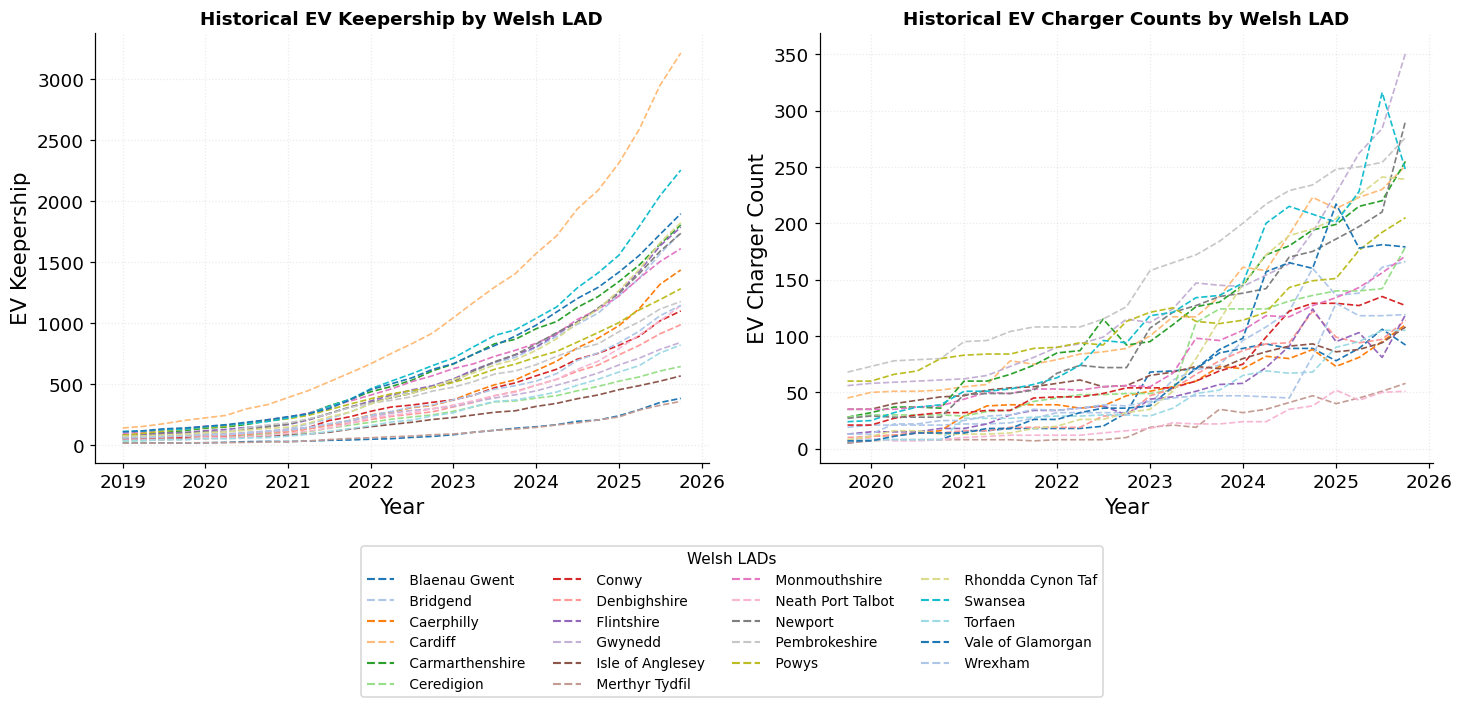

Saved: fig2_keepership_and_chargers_history.png


In [ ]:
# ============================================================
# Figure 2 — historical private EV keepership and public charging devices
#            for the 22 Welsh LADs, 2019-2025 (paper Section 2.1.2 / 2.1.3)
# ============================================================
# Both series are read back out of CLEETS-KG rather than from the source files,
# so the figure shows exactly what the graph holds after ingestion.

import matplotlib.pyplot as plt

FIG2_YEARS = (2019, 2025)


def _series_from_kg(observation_class, value_property):
    """One row per LAD-quarter for a measurement class, straight off the graph."""
    rows = []
    for obs in KG.subjects(RDF.type, observation_class):
        area = KG.value(obs, CLEETS.forGeographicArea)
        if area is None:
            continue
        code_literal = KG.value(area, CLEETS.geographyCode)
        if code_literal is None or not str(code_literal).startswith("W06"):
            continue
        label = _period_label(KG.value(obs, CLEETS.forTime))
        value = _literal_number(KG.value(obs, value_property))
        if label is None or not np.isfinite(value):
            continue
        try:
            period = pd.Period(str(label).replace("-", ""), freq="Q")
        except Exception:
            continue
        name_literal = KG.value(area, CLEETS.geographyName)
        rows.append({"code": str(code_literal),
                     "name": str(name_literal) if name_literal is not None
                             else str(code_literal),
                     "period": period, "value": value})
    frame = pd.DataFrame(rows)
    if frame.empty:
        return frame
    frame = (frame.groupby(["code", "name", "period"], as_index=False)
                  .agg(value=("value", "sum")))
    keep = frame.period.dt.year.between(*FIG2_YEARS)
    return frame[keep].sort_values(["name", "period"]).reset_index(drop=True)


keepership_history = _series_from_kg(CLEETS.EVKeepershipObservation,
                                     CLEETS.keepershipValue)
charger_history = _series_from_kg(CLEETS.EVChargerCountObservation,
                                  CLEETS.chargerCountValue)

print(f"Figure 2 inputs | keepership: {len(keepership_history):,} LAD-quarters, "
      f"{keepership_history.code.nunique()} LADs")
print(f"                | chargers:   {len(charger_history):,} LAD-quarters, "
      f"{charger_history.code.nunique()} LADs")

fig2_names = sorted(set(keepership_history.name) | set(charger_history.name))
fig2_colours = {nm: plt.get_cmap("tab20")(k % 20) for k, nm in enumerate(fig2_names)}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))
for ax, frame, title, ylabel in [
        (axes[0], keepership_history, "Historical EV Keepership by Welsh LAD",
         "EV Keepership"),
        (axes[1], charger_history, "Historical EV Charger Counts by Welsh LAD",
         "EV Charger Count")]:
    for nm, g in frame.groupby("name"):
        g = g.sort_values("period")
        ax.plot(g.period.dt.to_timestamp(), g.value, linestyle="--", linewidth=1.1,
                color=fig2_colours[nm], label=nm)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25, linestyle=":")
    ax.set_axisbelow(True)

handles = [plt.Line2D([], [], color=fig2_colours[nm], linestyle="--", linewidth=1.4)
           for nm in fig2_names]
fig.legend(handles, fig2_names, title="Welsh LADs", ncol=4, frameon=True,
           loc="lower center", bbox_to_anchor=(0.5, -0.30), fontsize=9,
           title_fontsize=10)
fig.tight_layout()
fig.savefig(WORK / "fig2_keepership_and_chargers_history.png", dpi=250,
            bbox_inches="tight")
plt.show()

keepership_history.to_csv(WORK / "fig2_keepership_history.csv", index=False)
charger_history.to_csv(WORK / "fig2_charger_history.csv", index=False)
print("Saved: fig2_keepership_and_chargers_history.png")

### Figure 3 — population and population density

Mid-year 2024 estimates on ONS Local Authority District boundaries. Densities are the
published ONS values carried through the graph; they are not recomputed from population
and land area, because recomputation from rounded land areas introduces discrepancies of
up to two residents per square kilometre.

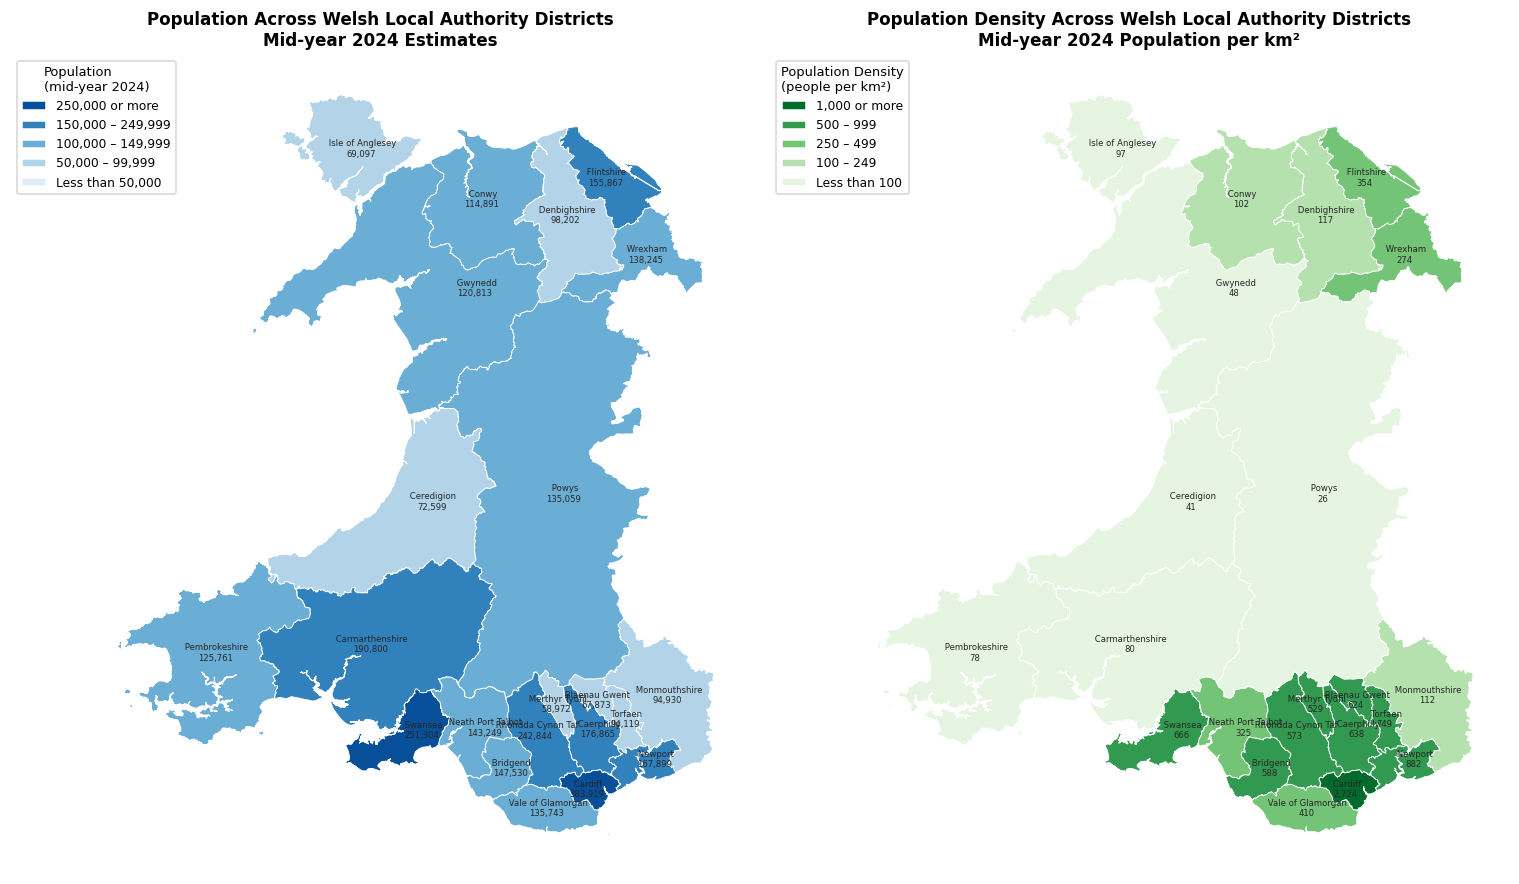

Saved: fig3_population_and_density_maps.png

Distribution of the two mapped variables
  population  skewness 1.75 | mean 144,845 | median 135,401 | sd 74,146
              IQR 95,748 to 164,891
  density     skewness 3.13 | mean 456 | median 340
              IQR 98 to 615
  Spearman correlation between population and density rank: 0.38
  Density is the more strongly skewed of the two, and the ranks diverge: the densest
  authorities are not simply the largest.


In [ ]:
# ============================================================
# Figure 3 — Wales LAD population and population density (paper Section 2.1.5)
# ============================================================
# Mid-year 2024 estimates as ingested into CLEETS-KG, drawn on ONS Local
# Authority District boundaries. Densities are the published ONS values carried
# through the graph; they are not recomputed from population and land area.

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

POP_BINS = [0, 50_000, 100_000, 150_000, 250_000, np.inf]
POP_LABELS = ["Less than 50,000", "50,000 – 99,999", "100,000 – 149,999",
              "150,000 – 249,999", "250,000 or more"]
DEN_BINS = [0, 100, 250, 500, 1_000, np.inf]
DEN_LABELS = ["Less than 100", "100 – 249", "250 – 499", "500 – 999",
              "1,000 or more"]

try:
    import geopandas as gpd

    _codes3 = lad_snapshot["code"].astype(str).tolist()
    _url3 = ("https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/services/"
             "Local_Authority_Districts_December_2023_Boundaries_UK_BGC/FeatureServer/0/"
             "query?where=1%3D1&outFields=LAD23CD&outSR=27700&f=geojson")
    wales_geo = gpd.read_file(_url3)
    wales_geo = wales_geo[wales_geo["LAD23CD"].isin(_codes3)].copy()
    wales_geo["geometry"] = wales_geo.geometry.buffer(0)
    wales_geo = wales_geo.merge(
        lad_snapshot[["code", "name", "population", "density"]],
        left_on="LAD23CD", right_on="code", how="left")

    fig, axes = plt.subplots(1, 2, figsize=(14, 8.5))
    for ax, column, bins, labels, cmap_name, title, subtitle in [
            (axes[0], "population", POP_BINS, POP_LABELS, "Blues",
             "Population Across Welsh Local Authority Districts",
             "Mid-year 2024 Estimates"),
            (axes[1], "density", DEN_BINS, DEN_LABELS, "Greens",
             "Population Density Across Welsh Local Authority Districts",
             "Mid-year 2024 Population per km²")]:
        cmap = ListedColormap(plt.get_cmap(cmap_name)(
            np.linspace(0.12, 0.88, len(labels))))
        norm = BoundaryNorm(bins, cmap.N)
        wales_geo.plot(column=column, ax=ax, cmap=cmap, norm=norm,
                       edgecolor="white", linewidth=0.6)
        for _, row in wales_geo.iterrows():
            pt = row.geometry.representative_point()
            value = row[column]
            text = (f"{row['name']}\n{value:,.0f}" if column == "population"
                    else f"{row['name']}\n{value:,.0f}")
            ax.annotate(text, xy=(pt.x, pt.y), ha="center", va="center",
                        fontsize=5.6, color="0.15")
        ax.set_title(f"{title}\n{subtitle}", fontsize=11)
        ax.set_axis_off()
        handles = [plt.Rectangle((0, 0), 1, 1, facecolor=cmap(k),
                                 edgecolor="white") for k in range(len(labels))]
        ax.legend(handles[::-1], labels[::-1],
                  title=("Population\n(mid-year 2024)" if column == "population"
                         else "Population Density\n(people per km²)"),
                  loc="upper left", fontsize=8, title_fontsize=8.5, frameon=True)

    fig.suptitle("")
    fig.tight_layout()
    fig.savefig(WORK / "fig3_population_and_density_maps.png", dpi=250,
                bbox_inches="tight")
    plt.show()
    print("Saved: fig3_population_and_density_maps.png")

except Exception as exc:                                   # noqa: BLE001
    print(f"Figure 3 skipped: {type(exc).__name__}: {exc}")
    print("Boundary geometry needs geopandas and access to the ONS boundary "
          "service. The\nunderlying values are unaffected and remain in "
          "`lad_snapshot`.")

# The distributional statements the paper makes about these two variables.
_pop = lad_snapshot["population"].astype(float)
_den = lad_snapshot["density"].astype(float)
print("\nDistribution of the two mapped variables")
print(f"  population  skewness {_pop.skew():.2f} | mean {_pop.mean():,.0f} | "
      f"median {_pop.median():,.0f} | sd {_pop.std():,.0f}")
print(f"              IQR {_pop.quantile(.25):,.0f} to {_pop.quantile(.75):,.0f}")
print(f"  density     skewness {_den.skew():.2f} | mean {_den.mean():,.0f} | "
      f"median {_den.median():,.0f}")
print(f"              IQR {_den.quantile(.25):,.0f} to {_den.quantile(.75):,.0f}")
_rank = lad_snapshot[["name", "population", "density"]].copy()
print(f"  Spearman correlation between population and density rank: "
      f"{_rank.population.corr(_rank.density, method='spearman'):.2f}")
print("  Density is the more strongly skewed of the two, and the ranks diverge: "
      "the densest\n  authorities are not simply the largest.")

### Table 1 — provision pressure and deprivation

Keepers per charger is a screening quantity: high pressure alongside high adoption points
to provision lagging demand, while low adoption alongside low pressure indicates that
charging is not the binding constraint.

In [ ]:
# ============================================================
# Table 1 — EV public charger availability, private EV keeperships and
#           deprivation classification across Welsh LADs (paper Section 2.1.6)
# ============================================================
#                    EV keeperships (Dec 2025)
#   Keepers per charger = -------------------------
#                    EV chargers   (Jan 2026)
#
# Lower values mean more public charging per registered EV. This is a
# descriptive screening quantity, not a needs assessment: high pressure
# alongside high adoption points to provision lagging demand, whereas low
# adoption alongside low pressure indicates that charging is not the binding
# constraint.

KEEPERSHIP_SNAPSHOT = "2025-Q4"     # December 2025
CHARGER_SNAPSHOT_YEAR = 2026        # January 2026

# ONS Rural Urban Classification (2021) of local authority districts (2024),
# England and Wales. Reference [31] in the paper; transcribed here because the
# geoportal download is a one-off lookup rather than a modelled input.
AREA_TYPE = {
    "Blaenau Gwent": "Urban", "Bridgend": "Urban", "Caerphilly": "Urban",
    "Cardiff": "Urban", "Carmarthenshire": "Rural", "Ceredigion": "Rural",
    "Conwy": "Urban", "Denbighshire": "Rural", "Flintshire": "Urban",
    "Gwynedd": "Rural", "Isle of Anglesey": "Rural", "Merthyr Tydfil": "Urban",
    "Monmouthshire": "Rural", "Neath Port Talbot": "Urban", "Newport": "Urban",
    "Pembrokeshire": "Rural", "Powys": "Rural", "Rhondda Cynon Taf": "Urban",
    "Swansea": "Urban", "Torfaen": "Urban", "Vale of Glamorgan": "Urban",
    "Wrexham": "Urban",
}

_rows1 = []
for lad in sorted(set(KG.subjects(RDF.type, CLEETS.WelshLAD)), key=str):
    code_literal = KG.value(lad, CLEETS.geographyCode)
    if code_literal is None:
        continue
    name_literal = KG.value(lad, CLEETS.geographyName)
    name = str(name_literal) if name_literal is not None else str(code_literal)

    keepers = _observation_value(lad, CLEETS.EVKeepershipObservation,
                                 CLEETS.keepershipValue,
                                 period=KEEPERSHIP_SNAPSHOT)
    if not np.isfinite(keepers):
        keepers = _observation_value(lad, CLEETS.EVKeepershipObservation,
                                     CLEETS.keepershipValue)
    chargers = _observation_value(lad, CLEETS.EVChargerCountObservation,
                                  CLEETS.chargerCountValue,
                                  year=CHARGER_SNAPSHOT_YEAR)
    decile = _observation_value(lad, CLEETS.DeprivationObservation,
                                CLEETS.deprivationValue)

    _rows1.append({
        "LAD name": name,
        "Area type": AREA_TYPE.get(name, ""),
        "Deprivation decile (1 = most deprived)":
            int(round(decile)) if np.isfinite(decile) else np.nan,
        "Public EV chargers (Jan 2026)":
            int(round(chargers)) if np.isfinite(chargers) else np.nan,
        "Private EV keeperships (Dec 2025)":
            int(round(keepers)) if np.isfinite(keepers) else np.nan,
    })

table1 = pd.DataFrame(_rows1)
table1["Keepers per charger"] = (table1["Private EV keeperships (Dec 2025)"]
                                 / table1["Public EV chargers (Jan 2026)"])
table1 = (table1.sort_values("Keepers per charger", ascending=False)
                .reset_index(drop=True))

_hi = table1["Keepers per charger"].quantile(0.90)
_mod = table1["Keepers per charger"].quantile(0.70)
table1["Provision pressure"] = np.where(
    table1["Keepers per charger"] >= _hi, "High",
    np.where(table1["Keepers per charger"] >= _mod, "Moderate", ""))

print("=" * 78)
print("TABLE 1  EV public charger availability, private EV keeperships and")
print("         deprivation classification across Welsh LADs")
print("=" * 78)
_show1 = table1.copy()
_show1["Keepers per charger"] = _show1["Keepers per charger"].map(
    lambda v: f"{v:.1f}:1" if np.isfinite(v) else "")
display(_show1)

print("\nNote: deprivation deciles are interpreted such that lower values represent")
print("higher levels of deprivation (1 = most deprived; 10 = least deprived).")
print("Provision pressure is descriptive; it does not by itself indicate where")
print("additional chargers are needed. Area classification from reference [31].")

# Section 3.3 as reported in the paper.
_adopt = lad_snapshot[["name", "evs_per_1000"]].dropna()
print(f"\nAdoption at the cross-sectional snapshot: mean "
      f"{_adopt.evs_per_1000.mean():.2f} private battery-electric")
print(f"vehicles per 1,000 residents (sd {_adopt.evs_per_1000.std():.2f}, range "
      f"{_adopt.evs_per_1000.min():.2f} to {_adopt.evs_per_1000.max():.2f}).")
print("Highest: " + ", ".join(
    f"{r['name']} ({r.evs_per_1000:.2f})"
    for _, r in _adopt.nlargest(2, "evs_per_1000").iterrows()))
print("Lowest:  " + ", ".join(
    f"{r['name']} ({r.evs_per_1000:.2f})"
    for _, r in _adopt.nsmallest(2, "evs_per_1000").iterrows()))
_ratio = table1["Keepers per charger"].dropna()
print(f"Provision pressure ranges from {_ratio.max():.1f} keeperships per public "
      f"charger in\n{table1.loc[_ratio.idxmax(), 'LAD name']} to {_ratio.min():.1f} in "
      f"{table1.loc[_ratio.idxmin(), 'LAD name']}, a range exceeding "
      f"{_ratio.max()/_ratio.min():.0f}-fold.")

table1.to_csv(WORK / "table1_provision_and_deprivation.csv", index=False)
print("\nSaved: table1_provision_and_deprivation.csv")

TABLE 1  EV public charger availability, private EV keeperships and
         deprivation classification across Welsh LADs


,LAD name,Area type,Deprivation decile (1 = most deprived),Public EV chargers (Jan 2026),Private EV keeperships (Dec 2025),Keepers per charger,Provision pressure
0,Neath Port Talbot,,NaN,63,1143,18.1:1,High
1,Flintshire,,NaN,122,1786,14.6:1,High
2,Vale of Glamorgan,,NaN,134,1896,14.1:1,High
3,Caerphilly,,NaN,116,1435,12.4:1,Moderate
4,Bridgend,,NaN,156,1742,11.2:1,Moderate
5,Cardiff,,NaN,309,3214,10.4:1,Moderate
6,Torfaen,,NaN,79,820,10.4:1,Moderate
7,Monmouthshire,,NaN,170,1610,9.5:1,
8,Swansea,,NaN,245,2254,9.2:1,
9,Wrexham,,NaN,126,1145,9.1:1,



Note: deprivation deciles are interpreted such that lower values represent
higher levels of deprivation (1 = most deprived; 10 = least deprived).
Provision pressure is descriptive; it does not by itself indicate where
additional chargers are needed. Area classification from reference [31].

Adoption at the cross-sectional snapshot: mean 7.66 private battery-electric
vehicles per 1,000 residents (sd 2.16, range 4.26 to 14.41).
Highest:  Monmouthshire (14.41),  Vale of Glamorgan (11.46)
Lowest:   Blaenau Gwent (4.26),  Merthyr Tydfil (4.85)
Provision pressure ranges from 18.1 keeperships per public charger in
 Neath Port Talbot to 2.4 in  Gwynedd, a range exceeding 8-fold.

Saved: table1_provision_and_deprivation.csv


In [ ]:
# ============================================================
# 4b. Robust feature matrix
# ============================================================
if TARGET not in df.columns:
    raise KeyError(f"Unknown TARGET={TARGET!r}. Available columns: {list(df.columns)}")

model_work = df[df[TARGET].notna()].copy().reset_index(drop=True)
if len(model_work) < 5:
    raise RuntimeError(
        f"Only {len(model_work)} LADs contain target {TARGET!r} at {TARGET_PERIOD}. "
        "Check the downloaded keepership/charger period coverage."
    )

# ------------------------------------------------------------------
# Feature set
#
# Geography alone (population, density, area) produced a fitted Ridge that was
# effectively constant, with RidgeCV selecting the top of the alpha grid. The
# covariates below are the ones the residuals pointed at: the largest positive
# residuals were Monmouthshire and the Vale of Glamorgan, the largest negative
# ones Blaenau Gwent and Merthyr Tydfil.
#
# chargers_per_100k is NOT a predictor here. Charge points are installed where
# EV uptake already is, so regressing adoption on provision estimates a
# relationship whose direction the cross-section cannot identify. Treat it as
# future work requiring an instrument or a panel with installation dates.
# ------------------------------------------------------------------
GEOGRAPHY_FEATURES = ["population", "density", "area_km2"]
SOCIOECONOMIC_FEATURES = [
    "cars_per_household",    # Census 2021 TS045
    "income_per_head",       # ONS regional accounts, GDHI per head
    "deprivation_pct",       # within-nation percentile, 1 = most deprived
]
# No dwelling-type or tenure variable is included, by choice. The off-street
# parking channel is therefore unmodelled.
FUTURE_WORK_FEATURES = ["chargers_per_100k", "charge_points"]

BASE_FEATURES = GEOGRAPHY_FEATURES + SOCIOECONOMIC_FEATURES
if NATION_SCOPE == "england_wales":
    # Deprivation percentiles are within-nation and not comparable across the
    # border; carry an indicator so the model can absorb the level shift.
    model_work["is_wales"] = (model_work["nation"] == "Wales").astype(float)
    BASE_FEATURES = BASE_FEATURES + ["is_wales"]

if CHARGERS_AS_FEATURE:
    print("WARNING: chargers_per_100k reinstated as a predictor. The estimate is "
          "not causally interpretable; see the note above.")
    BASE_FEATURES = BASE_FEATURES + ["chargers_per_100k"]

if TARGET == "evs_per_charge_point":
    BASE_FEATURES = [f for f in BASE_FEATURES if f not in FUTURE_WORK_FEATURES]
    print("Charger count/rate features removed to avoid arithmetic target leakage.")

FEATURES = BASE_FEATURES.copy()
if FEATURE_SET == "autoregressive":
    year_text, quarter_text = TARGET_PERIOD.split("-")
    lag_period = f"{int(year_text)-1}-{quarter_text}"
    lag_values = []
    for code in model_work["code"]:
        lad = next(KG.subjects(CLEETS.geographyCode, Literal(code)), None)
        if lad is None:
            # geographyCode literals may have an explicit datatype
            lad = next((s for s in KG.subjects(RDF.type, CLEETS.WelshLAD)
                        if str(KG.value(s, CLEETS.geographyCode)) == str(code)), None)
        lag_values.append(_observation_value(
            lad, CLEETS.EVAdoptionObservation, CLEETS.evsPerThousandPopulation,
            period=lag_period
        ) if lad is not None else np.nan)
    model_work["lag_evs_per_1000"] = lag_values
    FEATURES.append("lag_evs_per_1000")

# Keep columns with at least three observed values, then median-impute missing
# structural values so one sparse source does not remove every LAD.
FEATURES = [f for f in FEATURES if f in model_work.columns and model_work[f].notna().sum() >= 3]
if not FEATURES:
    raise RuntimeError(
        "No usable feature columns remain. Inspect `lad_snapshot.notna().sum()`; "
        "the source files may not have loaded correctly."
    )

feature_medians = model_work[FEATURES].median(numeric_only=True)
all_missing = [f for f in FEATURES if not np.isfinite(feature_medians.get(f, np.nan))]
if all_missing:
    FEATURES = [f for f in FEATURES if f not in all_missing]
    feature_medians = model_work[FEATURES].median(numeric_only=True)

model_work[FEATURES] = model_work[FEATURES].fillna(feature_medians)
X_model = model_work[FEATURES].to_numpy(dtype=float)
y_target = model_work[TARGET].to_numpy(dtype=float)

assert X_model.ndim == 2 and y_target.ndim == 1
assert len(X_model) == len(y_target)
assert np.isfinite(X_model).all(), "Non-finite values remain in X_model"
assert np.isfinite(y_target).all(), "Non-finite values remain in y_target"

print(f"n={len(model_work)} | p={len(FEATURES)} | features={FEATURES}")
print(f"target {TARGET}: mean={y_target.mean():.2f}, sd={y_target.std(ddof=1):.2f}, "
      f"range={y_target.min():.2f}-{y_target.max():.2f}")
print("Imputed feature medians:", feature_medians.to_dict())

_dropped = [f for f in (GEOGRAPHY_FEATURES + SOCIOECONOMIC_FEATURES)
            if f not in FEATURES]
if _dropped:
    print("\nDROPPED for sparsity (fewer than three observed values):", _dropped)
    print("If the socio-economic columns are here, the covariate join in 4a-bis "
          "did not run or did not match on LAD code.")
_imputed = {f: int(model_work[f].isna().sum()) for f in FEATURES}
if any(_imputed.values()):
    print("Median-imputed cell counts per feature:", {k: v for k, v in _imputed.items() if v})
    print("Report these in the paper: median imputation on a small n biases "
          "coefficients toward zero.")

banned = ("commonsense", "cskg", "closeMatch", "aboutConcept")
assert not any(b.lower() in c.lower() for c in model_work.columns for b in banned), \
    "Commonsense term leaked into the feature matrix"
print("Leakage check passed.")


n=22 | p=3 | features=['population', 'density', 'area_km2']
target evs_per_1000: mean=7.66, sd=2.16, range=4.26-14.41
Imputed feature medians: {'population': 135401.0, 'density': 339.5, 'area_km2': 440.5}

DROPPED for sparsity (fewer than three observed values): ['cars_per_household', 'income_per_head', 'deprivation_pct']
If the socio-economic columns are here, the covariate join in 4a-bis did not run or did not match on LAD code.
Leakage check passed.


### Visualizing LADs by Population and Density

This scatter plot displays each Local Authority District (LAD) based on its population and population density. This visualization can help identify clusters or outliers among the LADs based on these two key demographic features.

In [ ]:
# ============================================================
# 4c. Graph structure over the modelled LADs
# ============================================================
# The previous run reported "feature-space 3-NN fallback". That is very likely
# not a network failure: the guard rejected the boundary graph because at least
# one LAD had degree zero, and the Isle of Anglesey does not share a land
# boundary with Gwynedd. Islands are a standard nuisance in contiguity graphs
# and are handled by connecting each isolated unit to its nearest neighbour by
# centroid distance, not by discarding the whole graph.
#
# A feature-space k-NN graph is not a substitute. It builds edges from the same
# variables the model already receives, so message passing over it carries no
# information the tabular models lack, and any GNN-versus-Ridge comparison run
# on it is uninterpretable.

def adjacency_from_boundaries(codes, island_correction=True, tolerance_m=1.0):
    """Boundary contiguity from ONS LAD polygons, with island correction."""
    import geopandas as gpd

    url = ("https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/services/"
           "Local_Authority_Districts_December_2023_Boundaries_UK_BGC/FeatureServer/0/"
           "query?where=1%3D1&outFields=LAD23CD&outSR=27700&f=geojson")
    gdf = gpd.read_file(url)
    gdf = gdf[gdf["LAD23CD"].isin(codes)].copy()
    missing = sorted(set(codes) - set(gdf["LAD23CD"]))
    if missing:
        raise RuntimeError(f"{len(missing)} LAD codes absent from the boundary "
                           f"service, e.g. {missing[:5]}")
    gdf = gdf.set_index("LAD23CD").reindex(codes).reset_index()
    gdf["geometry"] = gdf.geometry.buffer(0)          # repair invalid rings

    n = len(codes)
    A_local = np.zeros((n, n), dtype=float)

    # Buffer by a metre so shared edges intersect despite topology noise,
    # then self-join. Far faster than the pairwise .touches() loop.
    buf = gdf.copy()
    buf["geometry"] = buf.geometry.buffer(tolerance_m)
    pairs = gpd.sjoin(buf[["geometry"]], buf[["geometry"]],
                      how="inner", predicate="intersects")
    for i, j in zip(pairs.index, pairs["index_right"]):
        if i != j:
            A_local[i, j] = A_local[j, i] = 1.0

    label = "ONS boundary contiguity"
    isolated = np.where(A_local.sum(1) == 0)[0]
    if len(isolated):
        if not island_correction:
            raise RuntimeError(f"{len(isolated)} isolated LADs and island "
                               "correction is disabled")
        cent = np.column_stack([gdf.geometry.centroid.x, gdf.geometry.centroid.y])
        for i in isolated:
            d = ((cent - cent[i]) ** 2).sum(1)
            d[i] = np.inf
            j = int(np.argmin(d))
            A_local[i, j] = A_local[j, i] = 1.0
        names = [codes[i] for i in isolated]
        label += f" + nearest-centroid island correction ({len(isolated)}: {names})"

    return A_local, label


def adjacency_knn(features, k=3):
    d = ((features[:, None, :] - features[None, :, :]) ** 2).sum(axis=-1)
    np.fill_diagonal(d, np.inf)
    A_local = np.zeros_like(d)
    k = min(k, max(1, len(features) - 1))
    for i in range(len(d)):
        for j in np.argsort(d[i])[:k]:
            A_local[i, j] = A_local[j, i] = 1.0
    return A_local, f"feature-space {k}-NN fallback"


from sklearn.preprocessing import StandardScaler
X_scaled_snapshot = StandardScaler().fit_transform(X_model)
model_codes = model_work["code"].astype(str).tolist()

try:
    A, ADJ_SOURCE = adjacency_from_boundaries(model_codes)
except Exception as exc:
    if not ALLOW_KNN_FALLBACK:
        raise RuntimeError(
            f"Boundary adjacency failed ({type(exc).__name__}: {exc}).\n"
            "The k-NN fallback is disabled because a feature-space graph makes "
            "the GNN results uninterpretable. Either fix the boundary source, "
            "ship a static adjacency CSV alongside the notebook, or set "
            "ALLOW_KNN_FALLBACK=True and report the graph as feature-derived "
            "in the paper."
        ) from exc
    print(f"Boundary adjacency unavailable ({type(exc).__name__}: {exc}); "
          "using k-NN fallback. THIS MUST BE DISCLOSED IN THE PAPER.")
    A, ADJ_SOURCE = adjacency_knn(X_scaled_snapshot, k=3)

print(f"adjacency source: {ADJ_SOURCE}")
print(f"nodes={len(A)} | edges={int(A.sum() // 2)} | "
      f"mean degree={A.sum(1).mean():.2f} | isolated={(A.sum(1) == 0).sum()}")


adjacency source: ONS boundary contiguity + nearest-centroid island correction (1: ['W06000001'])
nodes=22 | edges=44 | mean degree=4.00 | isolated=0


## Stage 5 — Baselines

Ridge (Hoerl & Kennard 1970), Random Forest, Extra Trees, and three GNNs. The GNNs are implemented in
plain PyTorch over a dense 22×22 adjacency rather than via `torch_geometric`: at this size dense is
free, and it removes a fragile Colab dependency.

Evaluation is leave-one-out over all 22 LADs. Every fold refits scaling inside the fold. Stochastic
models are refit under five seeds and the spread is reported, because at n=22 that spread is the
headline result.

In [ ]:
# ============================================================
# 5a. Models
# ============================================================
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler

def norm_adj(A):
    A_ = A + np.eye(len(A))
    d = A_.sum(1)
    Dm = np.diag(1.0 / np.sqrt(np.where(d == 0, 1, d)))
    return torch.tensor(Dm @ A_ @ Dm, dtype=torch.float32)

class GCN(nn.Module):
    def __init__(s, p, h=16):
        super().__init__(); s.l1 = nn.Linear(p, h); s.l2 = nn.Linear(h, 1)
    def forward(s, x, Ah, A):
        x = F.relu(Ah @ s.l1(x)); return (Ah @ s.l2(x)).squeeze(-1)

class GraphSAGE(nn.Module):
    """Mean aggregator, self and neighbour transforms kept separate (inductive form)."""
    def __init__(s, p, h=16):
        super().__init__()
        s.self1, s.nb1 = nn.Linear(p, h), nn.Linear(p, h)
        s.self2, s.nb2 = nn.Linear(h, 1), nn.Linear(h, 1)
    @staticmethod
    def mean_agg(x, A):
        d = A.sum(1, keepdim=True).clamp(min=1)
        return (A @ x) / d
    def forward(s, x, Ah, A):
        h = F.relu(s.self1(x) + s.nb1(s.mean_agg(x, A)))
        h = F.normalize(h, p=2, dim=-1)
        return (s.self2(h) + s.nb2(s.mean_agg(h, A))).squeeze(-1)

class GAT(nn.Module):
    def __init__(s, p, h=16, heads=2):
        super().__init__()
        s.h, s.heads = h, heads
        s.W = nn.Linear(p, h * heads, bias=False)
        s.a_src = nn.Parameter(torch.empty(heads, h)); s.a_dst = nn.Parameter(torch.empty(heads, h))
        nn.init.xavier_uniform_(s.a_src); nn.init.xavier_uniform_(s.a_dst)
        s.out = nn.Linear(h * heads, 1)
    def forward(s, x, Ah, A):
        n = x.shape[0]
        z = s.W(x).view(n, s.heads, s.h)
        e = (z * s.a_src).sum(-1).unsqueeze(1) + (z * s.a_dst).sum(-1).unsqueeze(0)  # n,n,heads
        e = F.leaky_relu(e, 0.2)
        mask = (A + torch.eye(n)) > 0
        e = e.masked_fill(~mask.unsqueeze(-1), float("-inf"))
        att = torch.softmax(e, dim=1)
        hout = torch.einsum("ijh,jhf->ihf", att, z).reshape(n, -1)
        return s.out(F.elu(hout)).squeeze(-1)

def fit_gnn(model_cls, Xs, y, train_mask, A, seed, epochs=400, lr=0.01, wd=5e-4):
    torch.manual_seed(seed); np.random.seed(seed)
    x  = torch.tensor(Xs, dtype=torch.float32)
    yt = torch.tensor(y,  dtype=torch.float32)
    At = torch.tensor(A,  dtype=torch.float32)
    Ah = norm_adj(A)
    m  = model_cls(x.shape[1])
    opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=wd)
    tm = torch.tensor(train_mask)
    for _ in range(epochs):
        m.train(); opt.zero_grad()
        loss = F.mse_loss(m(x, Ah, At)[tm], yt[tm])
        loss.backward(); opt.step()
    m.eval()
    with torch.no_grad():
        return m(x, Ah, At).numpy()

print("model definitions ready | torch", torch.__version__)

model definitions ready | torch 2.11.0+cpu


In [ ]:
# ============================================================
# 5b. Leave-one-out evaluation
# ============================================================
# Inputs are produced deterministically by Stage 4b.
X_eval = np.asarray(X_model, dtype=float)
y_eval = np.asarray(y_target, dtype=float)
n_samples = len(y_eval)
if n_samples < 5:
    raise RuntimeError("Evaluation requires at least five LAD observations.")

# Leave-one-out is nearly unbiased but has high variance, which is what made the
# 22-LAD ranking unstable. Above KFOLD_MIN_N, use repeated K-fold instead and
# report the spread across repeats as well as across seeds.
from sklearn.model_selection import KFold

USE_KFOLD = n_samples >= KFOLD_MIN_N
if USE_KFOLD:
    SPLITTERS = [KFold(n_splits=N_FOLDS, shuffle=True, random_state=r)
                 for r in range(N_REPEATS)]
    print(f"Evaluation: {N_REPEATS}x{N_FOLDS}-fold cross-validation on n={n_samples}")
else:
    SPLITTERS = [KFold(n_splits=n_samples)]          # leave-one-out
    print(f"Evaluation: leave-one-out on n={n_samples} "
          f"(below KFOLD_MIN_N={KFOLD_MIN_N})")


def cv_predict(fit_predict, splitter):
    """fit_predict(train_mask) -> full-length prediction vector."""
    out = np.empty(n_samples, dtype=float)
    for train_idx, test_idx in splitter.split(np.arange(n_samples)):
        mask = np.zeros(n_samples, dtype=bool)
        mask[train_idx] = True
        out[test_idx] = np.asarray(fit_predict(mask))[test_idx]
    return out


def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_pred - y_true
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    return {
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "R2": 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan,
    }

results = []

# ALPHA_GRID is deliberately wider than the original logspace(-3, 3). RidgeCV
# previously selected 1000, the top of that grid, meaning cross-validation
# wanted more shrinkage than was on offer and the fitted model collapsed to its
# intercept. A boundary selection is a diagnostic, so it is asserted on.
ALPHA_GRID = np.logspace(-3, 6, 40)
ridge_alphas_selected = []


class RidgeCVChecked(RidgeCV):
    def fit(self, X, y, **kw):
        super().fit(X, y, **kw)
        ridge_alphas_selected.append(self.alpha_)
        return self


CLASSICAL = {
    "Ridge": lambda seed: RidgeCVChecked(alphas=ALPHA_GRID),
    "Random Forest": lambda seed: RandomForestRegressor(
        n_estimators=500, min_samples_leaf=2, random_state=seed, n_jobs=-1),
    "Extra Trees": lambda seed: ExtraTreesRegressor(
        n_estimators=500, min_samples_leaf=2, random_state=seed, n_jobs=-1),
}
GRAPH = {"GCN": GCN, "GAT": GAT, "GraphSAGE": GraphSAGE}

for rep, splitter in enumerate(SPLITTERS):

    baseline_pred = cv_predict(
        lambda mask: np.full(n_samples, y_eval[mask].mean()), splitter)
    results.append({"model": "Mean baseline", "seed": 0, "rep": rep,
                    **metrics(y_eval, baseline_pred)})

    for model_name, factory in CLASSICAL.items():
        for seed in ([0] if model_name == "Ridge" else SEEDS):
            def fit_predict(mask, factory=factory, seed=seed):
                scaler = StandardScaler().fit(X_eval[mask])
                model = factory(seed).fit(scaler.transform(X_eval[mask]), y_eval[mask])
                return model.predict(scaler.transform(X_eval))
            pred = cv_predict(fit_predict, splitter)
            results.append({"model": model_name, "seed": seed, "rep": rep,
                            **metrics(y_eval, pred)})

    for model_name, model_class in GRAPH.items():
        for seed in SEEDS:
            def fit_predict(mask, model_class=model_class, seed=seed):
                scaler = StandardScaler().fit(X_eval[mask])
                return fit_gnn(model_class, scaler.transform(X_eval),
                               y_eval, mask, A, seed=seed)
            pred = cv_predict(fit_predict, splitter)
            results.append({"model": model_name, "seed": seed, "rep": rep,
                            **metrics(y_eval, pred)})

if ridge_alphas_selected:
    at_top = np.mean(np.isclose(ridge_alphas_selected, ALPHA_GRID[-1]))
    at_bottom = np.mean(np.isclose(ridge_alphas_selected, ALPHA_GRID[0]))
    print(f"\nRidge alpha: median={np.median(ridge_alphas_selected):.4g} | "
          f"at grid top={at_top:.0%} | at grid bottom={at_bottom:.0%}")
    if at_top > 0.2:
        print(">>> Ridge is still selecting the largest available penalty in more "
              "than a fifth of folds. The linear model is shrinking to its "
              "intercept, which means the features carry little linear signal "
              "about the target. Widen ALPHA_GRID only to confirm this; the "
              "answer is better covariates, not a longer grid.")

R = pd.DataFrame(results)
summary = (R.groupby("model")
           .agg(MAE=("MAE", "mean"), MAE_sd=("MAE", "std"),
                RMSE=("RMSE", "mean"), RMSE_sd=("RMSE", "std"),
                R2=("R2", "mean"), R2_sd=("R2", "std"),
                n_seeds=("seed", "nunique"), n_fits=("RMSE", "size"))
           .sort_values("RMSE"))
_protocol = (f"{N_REPEATS}x{N_FOLDS}-fold" if USE_KFOLD else "leave-one-out")
print(f"\n{_protocol}: n={n_samples} LADs ({NATION_SCOPE}) | "
      f"target={TARGET} @ {TARGET_PERIOD}")
print(f"features={FEATURES}")
print(f"graph={ADJ_SOURCE}")
display(summary.round(3))


Evaluation: leave-one-out on n=22 (below KFOLD_MIN_N=50)

Ridge alpha: median=1e+06 | at grid top=95% | at grid bottom=0%
>>> Ridge is still selecting the largest available penalty in more than a fifth of folds. The linear model is shrinking to its intercept, which means the features carry little linear signal about the target. Widen ALPHA_GRID only to confirm this; the answer is better covariates, not a longer grid.

leave-one-out: n=22 LADs (wales) | target=evs_per_1000 @ 2025-Q2
features=['population', 'density', 'area_km2']
graph=ONS boundary contiguity + nearest-centroid island correction (1: ['W06000001'])


,MAE,MAE_sd,RMSE,RMSE_sd,R2,R2_sd,n_seeds,n_fits
model,,,,,,,,
Extra Trees,1.567,0.012,2.155,0.005,-0.040,0.005,5,5
GraphSAGE,1.557,0.107,2.187,0.174,-0.076,0.178,5,5
Mean baseline,1.535,NaN,2.214,NaN,-0.098,NaN,1,1
Ridge,1.543,NaN,2.221,NaN,-0.104,NaN,1,1
Random Forest,1.817,0.020,2.355,0.016,-0.242,0.017,5,5
GCN,2.121,0.051,2.851,0.053,-0.820,0.068,5,5
GAT,2.773,0.161,3.840,0.432,-2.335,0.740,5,5


In [ ]:
# ============================================================
# 5c. What the numbers will and will not support
# ============================================================
work = model_work.copy()
best = summary.index[0]
base = summary.loc["Mean baseline", "RMSE"]
gap = base - summary.loc[best, "RMSE"]

sds = summary["RMSE_sd"].dropna()
worst_spread = sds.max() if len(sds) else 0.0

print(f"best mean RMSE : {best} ({summary.loc[best, 'RMSE']:.3f})")
print(f"mean baseline  : {base:.3f}   improvement: {gap:.3f}")
print(
    "largest seed-to-seed RMSE sd among stochastic models: "
    f"{worst_spread:.3f}"
)

if worst_spread >= gap:
    print(
        "\n>>> The spread across random seeds is at least as large as "
        "the gap between the"
    )
    print(
        ">>> best model and predicting the mean. Any ranking of these "
        "architectures is"
    )
    print(
        ">>> not sufficiently stable. Report the results table with "
        "the seed standard"
    )
    print(
        ">>> deviation column and do not report a single winning "
        "architecture."
    )


# ============================================================
# Reconstruct the tabular feature matrix
# ============================================================

if "work" not in globals():
    raise NameError(
        "'work' is not defined. Run the cell that constructs the "
        "Local Authority District modelling dataset before this cell."
    )

if "TARGET" not in globals():
    raise NameError(
        "'TARGET' is not defined. Set TARGET to the name of the "
        "prediction target column."
    )

if TARGET not in work.columns:
    raise KeyError(
        f"Target column {TARGET!r} was not found in work.\n"
        f"Available columns:\n{list(work.columns)}"
    )


# Use an explicitly defined feature list when one exists.
if "FEATURES" in globals():
    feature_cols = [
        col for col in FEATURES
        if col in work.columns and col != TARGET
    ]

elif "feature_cols" in globals():
    feature_cols = [
        col for col in feature_cols
        if col in work.columns and col != TARGET
    ]

else:
    # Automatically select numeric explanatory variables.
    excluded_cols = {
        TARGET,
        "code",
        "name",
        "lad_code",
        "lad_name",
        "year",
        "quarter",
        "date",
        "geometry",
        "prediction",
        "predicted",
        "pred_ridge",
        "residual",
        "explanation",
    }

    feature_cols = [
        col
        for col in work.select_dtypes(include=np.number).columns
        if col not in excluded_cols
        and not col.lower().startswith("pred")
        and "residual" not in col.lower()
        and "target" not in col.lower()
    ]


if not feature_cols:
    raise ValueError(
        "No usable numeric feature columns were found. Define FEATURES "
        "explicitly, for example:\n"
        "FEATURES = ['population', 'population_density', "
        "'chargers_per_100k']"
    )

print("\nFeatures used by Ridge regression:")
for col in feature_cols:
    print(f"  - {col}")


# Keep only complete observations for the explanatory model.
model_mask = work[feature_cols + [TARGET]].notna().all(axis=1)

model_work = work.loc[model_mask].copy()

X = model_work[feature_cols].astype(float).to_numpy()
y = model_work[TARGET].astype(float).to_numpy()

print(f"\nRows used: {len(model_work):,} of {len(work):,}")
print(f"Number of features: {len(feature_cols)}")

if len(model_work) < 3:
    raise ValueError(
        "At least three complete observations are required to fit "
        "the Ridge regression model."
    )


# ============================================================
# Fit the explanatory Ridge model
# ============================================================

sc = StandardScaler()

X_scaled = sc.fit_transform(X)

ridge = RidgeCV(
    alphas=np.logspace(-3, 3, 25)
).fit(X_scaled, y)

model_work["pred_ridge"] = ridge.predict(X_scaled)

# Positive residual: observed adoption exceeds predicted adoption.
model_work["residual"] = (
    model_work[TARGET] - model_work["pred_ridge"]
)

print(f"\nSelected Ridge alpha: {ridge.alpha_:.5g}")


# ============================================================
# Human-readable per-LAD explanations
# ============================================================

def first_existing(row, columns, default=None):
    """Return the first available, non-missing value."""
    for column in columns:
        if column in row.index and pd.notna(row[column]):
            return row[column]
    return default


def explain(row):
    """
    Produce a numeric description without making a causal claim.

    The Ridge values are fitted on the complete dataset and are therefore
    descriptive fitted values, not out-of-sample predictions.
    """

    code = first_existing(
        row,
        ["code", "lad_code", "LAD23CD", "LAD24CD"],
        "unknown code",
    )

    name = first_existing(
        row,
        ["name", "lad_name", "LAD23NM", "LAD24NM"],
        code,
    )

    charger_value = first_existing(
        row,
        [
            "chargers_per_100k",
            "charge_points_per_100k",
            "charging_points_per_100k",
        ],
    )

    residual = float(row["residual"])

    if residual > 0:
        comparison = (
            f"{abs(residual):.1f} above the fitted Ridge value"
        )
    elif residual < 0:
        comparison = (
            f"{abs(residual):.1f} below the fitted Ridge value"
        )
    else:
        comparison = "equal to the fitted Ridge value"

    charger_text = ""
    if charger_value is not None:
        charger_text = (
            f", with {float(charger_value):.0f} public charge points "
            "per 100,000 residents"
        )

    return (
        f"{name}: observed adoption was {float(row[TARGET]):.1f}"
        f"{charger_text}. This was {comparison}, based on the "
        f"available variables: {', '.join(feature_cols)}."
    )


model_work["explanation"] = model_work.apply(explain, axis=1)


# Return fitted values to the complete dataset.
work_out = work.copy()

work_out["pred_ridge"] = np.nan
work_out["residual"] = np.nan
work_out["explanation"] = None

work_out.loc[model_work.index, "pred_ridge"] = (
    model_work["pred_ridge"]
)

work_out.loc[model_work.index, "residual"] = (
    model_work["residual"]
)

work_out.loc[model_work.index, "explanation"] = (
    model_work["explanation"]
)


# ============================================================
# Display Local Authority District residuals
# ============================================================

display_cols = [
    col
    for col in ["code", "name", TARGET, "pred_ridge", "residual"]
    if col in work_out.columns
]

display(
    work_out.loc[model_mask, display_cols]
    .sort_values("residual")
    .round(2)
)

print("\nLargest negative residuals:")
for text in (
    work_out.loc[model_mask]
    .sort_values("residual")
    ["explanation"]
    .head(3)
):
    print("-", text)

print("\nLargest positive residuals:")
for text in (
    work_out.loc[model_mask]
    .sort_values("residual", ascending=False)
    ["explanation"]
    .head(3)
):
    print("-", text)


# ============================================================
# Save outputs
# ============================================================

WORK = Path(WORK)
WORK.mkdir(parents=True, exist_ok=True)

jsonl_path = WORK / "cleets_explanations.jsonl"

with jsonl_path.open("w", encoding="utf-8") as fh:
    for _, row in work_out.loc[model_mask].iterrows():

        code = first_existing(
            row,
            ["code", "lad_code", "LAD23CD", "LAD24CD"],
        )

        name = first_existing(
            row,
            ["name", "lad_name", "LAD23NM", "LAD24NM"],
            code,
        )

        record = {
            "code": code,
            "name": name,
            "observed": float(row[TARGET]),
            "fitted_ridge": float(row["pred_ridge"]),
            "residual": float(row["residual"]),
            "text": row["explanation"],
        }

        fh.write(json.dumps(record, ensure_ascii=False) + "\n")


work_out.to_csv(
    WORK / "cleets_model_dataset.csv",
    index=False,
)

summary.to_csv(
    WORK / "cleets_model_results.csv",
)

pd.DataFrame({
    "feature": feature_cols,
    "standardised_ridge_coefficient": ridge.coef_,
}).sort_values(
    "standardised_ridge_coefficient",
    key=np.abs,
    ascending=False,
).to_csv(
    WORK / "cleets_ridge_coefficients.csv",
    index=False,
)


print(f"\nWritten to {WORK}/:")

for file_path in sorted(WORK.iterdir()):
    if file_path.is_file():
        print(
            f"  {file_path.name:<34}"
            f"{file_path.stat().st_size / 1024:>9.0f} KB"
        )

best mean RMSE : Extra Trees (2.155)
mean baseline  : 2.214   improvement: 0.059
largest seed-to-seed RMSE sd among stochastic models: 0.432

>>> The spread across random seeds is at least as large as the gap between the
>>> best model and predicting the mean. Any ranking of these architectures is
>>> not sufficiently stable. Report the results table with the seed standard
>>> deviation column and do not report a single winning architecture.

Features used by Ridge regression:
  - population
  - density
  - area_km2

Rows used: 22 of 22
Number of features: 3

Selected Ridge alpha: 1000


,code,name,evs_per_1000,pred_ridge,residual
16,W06000019,Blaenau Gwent,4.26,7.66,-3.40
21,W06000024,Merthyr Tydfil,4.85,7.66,-2.81
1,W06000002,Gwynedd,5.89,7.67,-1.78
14,W06000016,Rhondda Cynon Taf,5.93,7.65,-1.73
10,W06000012,Neath Port Talbot,6.30,7.66,-1.36
15,W06000018,Caerphilly,6.32,7.65,-1.33
5,W06000006,Wrexham,6.76,7.66,-0.91
13,W06000015,Cardiff,6.75,7.61,-0.87
17,W06000020,Torfaen,6.92,7.65,-0.74
0,W06000001,Isle of Anglesey,7.03,7.67,-0.63



Largest negative residuals:
-  Blaenau Gwent: observed adoption was 4.3, with 131 public charge points per 100,000 residents. This was 3.4 below the fitted Ridge value, based on the available variables: population, density, area_km2.
-  Merthyr Tydfil: observed adoption was 4.8, with 76 public charge points per 100,000 residents. This was 2.8 below the fitted Ridge value, based on the available variables: population, density, area_km2.
-  Gwynedd: observed adoption was 5.9, with 217 public charge points per 100,000 residents. This was 1.8 below the fitted Ridge value, based on the available variables: population, density, area_km2.

Largest positive residuals:
-  Monmouthshire: observed adoption was 14.4, with 151 public charge points per 100,000 residents. This was 6.7 above the fitted Ridge value, based on the available variables: population, density, area_km2.
-  Vale of Glamorgan: observed adoption was 11.5, with 131 public charge points per 100,000 residents. This was 3.8 above t

## Artefact-verifiable modelling scope

Every result the paper reports is produced by a cell in this notebook:

- the **measurement-scope decomposition** of the published Wales–England lag on country-level
  VEH0105 series (§2.3.1, Table 4) — Stage 6a-bis;
- a 22-LAD **cross-sectional comparison** of a mean baseline, Ridge, Random Forest, Extra Trees,
  GCN, GAT and GraphSAGE under leave-one-out evaluation (§3.4.2, Table 8) — Stage 5;
- the **walk-forward comparison** of the bounded logistic, the multilayer perceptron, the
  scenario-constrained perceptron, the graph neural network and the scenario-constrained graph
  neural network under the single protocol of §2.3.3 (Tables 5, 6 and 7) — Stages 13 and 14;
- one VEH0105-bounded **logistic diffusion scenario** fitted to quarterly LAD observations and
  evaluated by rolling-origin backtesting (§3.4.3), a neural network on the SPARQL-extracted
  matched-scope adoption ratio (Stage 6e), the **hierarchical model** with partial pooling
  (§2.3.6, §3.5, Table 9, Figures 4–5), the **age-structured turnover ceiling** (§2.3.5, §3.6,
  Table 10) and the **reconciliation** of the two (§3.7, Figure 6).

Bass diffusion, LSTMs, seasonal-naïve forecasting and validation-weighted ensembles are
implemented nowhere and are claimed nowhere.

Two figures depend on inputs outside the modelling chain: Figure 1 is a hand-drawn flowchart of
the pipeline, and Figure 3 needs boundary geometry from the ONS geoportal, so its cell degrades
to a printed distribution summary if that service is unreachable.

## Matched numerator–denominator contract

The supplied VEH0132 extract contains only `Private` Battery Electric Vehicle keepership, and its private series aggregates cars and vans with no cars-only restriction. The executable forecasting contract is therefore:

1. numerator body type = `All` (as published; cars and vans aggregated);
2. numerator fuel = `Battery Electric`;
3. numerator keepership = `Private`;
4. denominator body type = `All`;
5. denominator fuel = `Total`;
6. denominator keepership = `Private`;
7. exactly 22 Welsh Local Authority Districts are represented; and
8. Cardiff's latest private licensed-vehicle stock is checked for plausibility.

The notebook stops when these conditions are not met. It does not infer total Battery Electric Vehicle keepership from private-only observations.


## Stage 6 — Matched-scope quarterly diffusion forecast to 2045

This stage uses a coherent private-fleet penetration definition:

- **numerator:** private battery-electric vehicles (cars and vans) from VEH0132;
- **denominator:** private licensed vehicles across all body types and fuels from VEH0105.

Both quantities use `keepership = Private`. The denominator uses `bodytype = All` so that its body-type coverage matches the VEH0132 private numerator, which includes cars and vans. A separate bounded logistic diffusion curve is fitted to each of the 22 Welsh Local Authority Districts using quarterly observations. A transparent scenario constraint sets Wales-wide private-fleet Battery Electric Vehicle penetration close to 99% by 2045 Q4. This terminal value is a scenario assumption, not an official forecast or a quantity inferred solely from the historical series.

Forecast private Battery Electric Vehicle counts are bounded by the corresponding VEH0105 private licensed-vehicle stock.


In [ ]:
# ============================================================
# 6a. Download VEH0105, derive private licensed-vehicle stock, add it to CLEETS-KG
#
# Scope: bodytype='All', fuel='Total', keepership='Private'.
#
# The body type is 'All', not 'Cars'. The VEH0132 numerator (private
# battery-electric vehicles) covers cars and vans under private keepership, so a
# cars-only denominator would omit vans and inflate every share downstream.
# This cell must run BEFORE Stage 6a-bis and Stage 6b, which consume `veh_raw`
# and `vehicle_stock` (value column now `private_vehicles`, not `private_cars`).
# This matches the numerator on keepership and on body-type coverage, so
# penetration is a like-for-like ratio. The measure is therefore PRIVATE-fleet
# penetration across all body types and must be labelled as such downstream.
# Note: 'All' also places private motorcycles (and any private HGVs or buses)
# in the denominator; see the scope resolution below.
# ============================================================
from scipy.optimize import least_squares
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import gdown

# Working copy. Cite the DfT publication, not the Drive mirror -- verify this
# collection URL against the table you actually downloaded before publishing.
VEH0105_DRIVE_ID  = "1MqF57lLua8HSEFOYV0V2lnZmy5fiKGMP"
VEH0105_DRIVE_URL = f"https://drive.google.com/file/d/{VEH0105_DRIVE_ID}/view"
VEH0105_CITE_URL  = "https://www.gov.uk/government/collections/vehicles-statistics"
VEH0105_ACCESSED  = datetime.now(timezone.utc).date().isoformat()

FORECAST_END      = pd.Period("2045Q4", freq="Q")
WALES_2045_TARGET = 0.99
BACKTEST_HORIZON  = 8

# Exact scope, declared once and reused for the KG assertions below.
# The published all-body-types label varies between releases ('All', 'Total',
# 'All body types'), so it is resolved against the file, not hard-coded.
BODYTYPE_ALL_CANDIDATES = ["all", "total", "all body types"]
SCOPE = {"bodytype": None, "fuel": "total", "keepership": "private"}

# ---------------------------------------------------------------- download
veh_path = WORK / "veh0105_source"
if not veh_path.exists():
    result = gdown.download(f"https://drive.google.com/uc?id={VEH0105_DRIVE_ID}",
                            str(veh_path), quiet=False, fuzzy=True)
    if result is None or not veh_path.exists():
        raise RuntimeError("VEH0105 could not be downloaded. Set the Drive file to "
                           "'Anyone with the link' and rerun this cell.")

if "load_table" in globals():
    veh_raw = load_table(veh_path, 0, 0)
else:
    readers = [lambda p: pd.read_csv(p),
               lambda p: pd.read_excel(p, sheet_name=0),
               lambda p: pd.read_excel(p, sheet_name=0, engine="odf")]
    errors = []
    for reader in readers:
        try:
            veh_raw = reader(veh_path); break
        except Exception as exc:
            errors.append(str(exc))
    else:
        raise RuntimeError("Unable to read VEH0105: " + " | ".join(errors[-3:]))

veh_raw.columns = [re.sub(r"[^a-z0-9]+", "_", str(c).strip().lower()).strip("_")
                   for c in veh_raw.columns]
print("VEH0105 shape:", veh_raw.shape)
print("VEH0105 columns:", list(veh_raw.columns)[:20])

# ---------------------------------------------------------------- columns
def first_col(columns, candidates):
    for candidate in candidates:
        if candidate in columns:
            return candidate
    for candidate in candidates:
        for col in columns:
            if candidate in col:
                return col
    return None

veh_code_col = first_col(veh_raw.columns,
                         ["ons_code", "lad_code", "geography_code", "area_code", "code"])
veh_name_col = first_col(veh_raw.columns,
                         ["ons_geography", "lad_name", "geography_name", "area_name", "name"])
if veh_code_col is None:
    raise KeyError("Could not identify the LAD code column in VEH0105.")

quarter_pattern = re.compile(r"^(?:vehicles_)?(20\d{2})_?q([1-4])(?:_.*)?$")
quarter_cols = [c for c in veh_raw.columns if quarter_pattern.match(c)]
if not quarter_cols:
    quarter_cols = [c for c in veh_raw.columns if re.search(r"20\d{2}.*q[1-4]", c)]
if not quarter_cols:
    raise KeyError("No quarterly VEH0105 columns were detected. Columns are: "
                   + str(list(veh_raw.columns)))

def quarter_sort_key(col):
    m = re.search(r"(20\d{2}).*q([1-4])", str(col).lower())
    return (int(m.group(1)), int(m.group(2)))

quarter_cols = sorted(quarter_cols, key=quarter_sort_key)
print(f"Quarter columns: {len(quarter_cols)} | {quarter_cols[0]} to {quarter_cols[-1]}")

# ---------------------------------------------------------------- scope filter
# Capture the source row number BEFORE any reshaping so provenance points at the
# actual spreadsheet row rather than a position in the melted frame.
veh = veh_raw.copy()
veh["source_row"] = veh.index + 2          # +2 for the header row, 1-based
veh[veh_code_col] = veh[veh_code_col].astype(str).str.strip().str.upper()
veh = veh[veh[veh_code_col].str.startswith("W06", na=False)].copy()

required_scope_cols = ["bodytype", "fuel", "keepership"]
missing_scope_cols = [c for c in required_scope_cols if c not in veh.columns]
if missing_scope_cols:
    raise KeyError("VEH0105 is missing the categorical columns required for an exact "
                   f"denominator selection: {missing_scope_cols}")

def normalise_scope(series):
    return (series.fillna("").astype(str).str.strip().str.casefold()
                  .str.replace(r"\s+", " ", regex=True))     # single-escaped: real \s

body_norm = normalise_scope(veh["bodytype"])
fuel_norm = normalise_scope(veh["fuel"])
keep_norm = normalise_scope(veh["keepership"])

# Resolve the all-body-types label actually used in this release.
_body_present = [lbl for lbl in BODYTYPE_ALL_CANDIDATES if body_norm.eq(lbl).any()]
if not _body_present:
    raise RuntimeError("No VEH0105 bodytype label matched an all-body-types row. "
                       f"Labels found: {sorted(body_norm.unique())}")
if len(_body_present) > 1:
    raise RuntimeError(f"Ambiguous all-body-types labels in VEH0105: {_body_present}. "
                       "Set SCOPE['bodytype'] explicitly before continuing.")
SCOPE["bodytype"] = _body_present[0]
BODYTYPE_LABEL_RAW = (veh.loc[body_norm.eq(SCOPE["bodytype"]), "bodytype"]
                      .astype(str).str.strip().iloc[0])
print(f"All-body-types label resolved as {BODYTYPE_LABEL_RAW!r}.")

scope_mask = (body_norm.eq(SCOPE["bodytype"]) & fuel_norm.eq(SCOPE["fuel"])
              & keep_norm.eq(SCOPE["keepership"]))
veh_private_rows = veh.loc[scope_mask].copy()

if veh_private_rows.empty:
    raise RuntimeError(
        f"No VEH0105 rows matched bodytype={BODYTYPE_LABEL_RAW!r}, fuel='Total', "
        "keepership='Private'.\n"
        f"  bodytype labels:   {sorted(body_norm.unique())[:12]}\n"
        f"  fuel labels:       {sorted(fuel_norm.unique())[:12]}\n"
        f"  keepership labels: {sorted(keep_norm.unique())[:12]}")

# Blank rows in scope are a common spreadsheet artefact -- drop them before the
# duplicate check, so an empty stray row is not fatal. Rows with SOME data are
# kept and will trip the duplicate check, which is the intended behaviour.
_numeric = veh_private_rows[quarter_cols].apply(
    lambda s: pd.to_numeric(s.astype(str).str.replace(",", "", regex=False),
                            errors="coerce"))
_blank = _numeric.isna().all(axis=1)
if _blank.any():
    print(f"Dropping {int(_blank.sum())} in-scope row(s) with no quarterly values "
          f"(source rows {list(veh_private_rows.loc[_blank, 'source_row'])[:8]}).")
    veh_private_rows = veh_private_rows.loc[~_blank].copy()

duplicates = veh_private_rows.duplicated(subset=[veh_code_col], keep=False)
if duplicates.any():
    dup_cols = [veh_code_col] + ([veh_name_col] if veh_name_col else []) \
               + ["bodytype", "fuel", "keepership", "source_row"]
    raise RuntimeError("The exact VEH0105 scope did not yield one row per LAD. "
                       "Duplicate rows:\n"
                       + veh_private_rows.loc[duplicates, dup_cols]
                         .sort_values(veh_code_col).to_string(index=False))

n_lads = veh_private_rows[veh_code_col].nunique()
if n_lads != 22:
    raise RuntimeError(f"Expected 22 Welsh LAD rows after exact VEH0105 filtering, "
                       f"found {n_lads}.")

print(f"Exact scope: bodytype={BODYTYPE_LABEL_RAW!r}, fuel={SCOPE['fuel']!r}, "
      f"keepership={SCOPE['keepership']!r} "
      f"| {len(veh_private_rows)} rows")

# ---------------------------------------------------------------- units
def veh0105_unit_multiplier(unit):
    """Convert published VEH0105 values into individual vehicle counts."""
    if pd.isna(unit) or str(unit).strip() == "":
        raise ValueError("A VEH0105 row has a missing units value.")
    text = str(unit).strip().casefold().replace(",", "")
    if any(k in text for k in ("thousand", "'000", "000s", "000's")):
        return 1_000.0
    if text in {"number", "numbers", "count", "counts", "vehicle", "vehicles",
                "unit", "units"}:
        return 1.0
    raise ValueError(f"Unrecognised VEH0105 unit label: {unit!r}. "
                     "Inspect the 'units' column before continuing.")

if "units" in veh_private_rows.columns:
    print("VEH0105 units in scope:",
          sorted(veh_private_rows["units"].dropna().astype(str).str.strip().unique()))
    veh_private_rows["unit_multiplier"] = \
        veh_private_rows["units"].apply(veh0105_unit_multiplier)
else:
    print("No 'units' column present; assuming individual vehicle counts.")
    veh_private_rows["unit_multiplier"] = 1.0

# ---------------------------------------------------------------- reshape
id_cols = [veh_code_col, "source_row", "unit_multiplier"] \
          + ([veh_name_col] if veh_name_col else [])
vehicle_stock = veh_private_rows.melt(id_vars=id_cols, value_vars=quarter_cols,
                                      var_name="source_column",
                                      value_name="published_value")
vehicle_stock["published_value"] = pd.to_numeric(
    vehicle_stock["published_value"].astype(str).str.replace(",", "", regex=False),
    errors="coerce")
vehicle_stock = vehicle_stock.dropna(subset=["published_value"])

# Apply the multiplier: 146.7 thousand -> 146,700 vehicles.
vehicle_stock["private_vehicles"] = (vehicle_stock["published_value"]
                                     * vehicle_stock["unit_multiplier"]).round()

def to_period(label):
    m = re.search(r"(20\d{2}).*q([1-4])", str(label).lower())
    return pd.NaT if m is None else pd.Period(f"{m.group(1)}Q{m.group(2)}", freq="Q")

vehicle_stock["period"] = vehicle_stock["source_column"].map(to_period)
vehicle_stock = vehicle_stock.dropna(subset=["period"])

rename_map = {veh_code_col: "code"}
if veh_name_col:
    rename_map[veh_name_col] = "name"
vehicle_stock = vehicle_stock.rename(columns=rename_map)
if "name" not in vehicle_stock:
    vehicle_stock["name"] = vehicle_stock["code"]

dup_q = vehicle_stock.duplicated(subset=["code", "period"], keep=False)
if dup_q.any():
    raise RuntimeError("Duplicate VEH0105 LAD-quarter observations remain after exact "
                       "filtering:\n" + vehicle_stock.loc[
                           dup_q, ["code", "name", "period", "private_vehicles",
                                   "source_column", "source_row"]]
                       .sort_values(["code", "period"]).to_string(index=False))

vehicle_stock = vehicle_stock.sort_values(["code", "period"]).reset_index(drop=True)
vehicle_stock["private_vehicles"] = vehicle_stock["private_vehicles"].astype("int64")

# ---------------------------------------------------------------- panel balance
expected = vehicle_stock["code"].nunique() * vehicle_stock["period"].nunique()
if len(vehicle_stock) != expected:
    print(f"\nWarning: VEH0105 panel is unbalanced ({len(vehicle_stock)} of {expected}).")
    print(vehicle_stock.groupby("code")["period"].nunique().sort_values().to_string())

print("\nWelsh VEH0105 LAD-quarter observations:", f"{len(vehicle_stock):,}")
print("LADs:", vehicle_stock.code.nunique(),
      "| periods:", vehicle_stock.period.min(), "to", vehicle_stock.period.max())

# ---------------------------------------------------------------- scope check
# The magnitude of Cardiff's stock cannot distinguish private from total
# keepership -- both are plausible values. Test the SCOPE instead, by ratio
# against the keepership='Total' row for the same body-type scope, LAD, quarter.
latest = vehicle_stock["period"].max()
total_rows = veh.loc[body_norm.eq(SCOPE["bodytype"]) & fuel_norm.eq(SCOPE["fuel"])
                     & keep_norm.eq("total")]
cardiff_private = vehicle_stock.loc[vehicle_stock.code.eq("W06000015")
                                    & vehicle_stock.period.eq(latest),
                                    "private_vehicles"]
if cardiff_private.empty:
    raise RuntimeError("Cardiff (W06000015) not found in the filtered VEH0105 panel.")
cardiff_private = int(cardiff_private.iloc[0])
latest_col = [c for c in quarter_cols if to_period(c) == latest][0]

if not total_rows.empty:
    ct = total_rows.loc[total_rows[veh_code_col].eq("W06000015")]
    if not ct.empty:
        ct_mult = veh0105_unit_multiplier(ct["units"].iloc[0]) \
                  if "units" in ct.columns else 1.0
        cardiff_total = float(pd.to_numeric(
            str(ct[latest_col].iloc[0]).replace(",", ""), errors="coerce")) * ct_mult
        share = cardiff_private / cardiff_total if cardiff_total else float("nan")
        print(f"\nCardiff {latest}: private {cardiff_private:,} of total "
              f"{cardiff_total:,.0f} licensed vehicles = {share:.1%} private")
        if not 0.60 <= share <= 0.95:
            raise AssertionError(
                f"Cardiff private share of the licensed fleet is {share:.1%}, "
                "outside the plausible 60-95% range. The selected row is probably not "
                "private keepership, or the units multiplier is wrong. "
                "Do not run the forecast.")
else:
    print("\nNo keepership='Total' row available; falling back to a magnitude check.")
    print(f"Cardiff {latest} private licensed vehicles: {cardiff_private:,}")
    # Heuristic bounds for an all-body-types private stock; verify against the
    # published table before relying on them.
    if not 95_000 <= cardiff_private <= 180_000:
        raise AssertionError(
            f"Cardiff private licensed-vehicle stock {cardiff_private:,} is outside "
            "the plausible 95,000-180,000 range. Do not run the forecast.")

print(f"\nLatest private licensed-vehicle stock by LAD ({latest}):")
display(vehicle_stock.loc[vehicle_stock.period.eq(latest),
                          ["code", "name", "private_vehicles"]]
        .sort_values("private_vehicles", ascending=False).reset_index(drop=True))

# ---------------------------------------------------------------- schema
# Terms name the PRIVATE all-body-types scope. A property still called
# privateLicensedCarCount holding all-body-type values would mislead every
# downstream query, including the chat front end.
for cls, label in [
    (CLEETS.PrivateVehicleStockObservation, "Private licensed-vehicle stock observation"),
    (CLEETS.DiffusionForecastObservation, "Private BEV diffusion forecast observation"),
    (CLEETS.DiffusionModel, "Saturation-constrained private BEV diffusion model"),
]:
    KG.add((cls, RDF.type, OWL.Class))
    KG.add((cls, RDFS.label, Literal(label, lang="en")))
KG.add((CLEETS.PrivateVehicleStockObservation, RDFS.subClassOf, CLEETS.Observation))
KG.add((CLEETS.DiffusionForecastObservation, RDFS.subClassOf, CLEETS.Observation))

for prop, label in [
    (CLEETS.privateLicensedVehicleCount, "private licensed vehicle count"),
    (CLEETS.predictedPrivateBEVCount, "predicted private BEV count"),
    (CLEETS.predictedPrivateAdoptionShare,
     "predicted private BEV share of private vehicles"),
    (CLEETS.saturationCapacity, "private vehicle stock saturation capacity"),
    (CLEETS.diffusionRate, "quarterly diffusion rate"),
    (CLEETS.diffusionMidpoint, "diffusion midpoint"),
    (CLEETS.bodyTypeScope, "body type scope"),
    (CLEETS.fuelScope, "fuel scope"),
    (CLEETS.keepershipScope, "keepership scope"),
]:
    KG.add((prop, RDF.type, OWL.DatatypeProperty))
    KG.add((prop, RDFS.label, Literal(label, lang="en")))

veh_dataset = DATA["dataset/veh0105"]
KG.add((veh_dataset, RDF.type, CLEETS.Dataset))
KG.add((veh_dataset, RDFS.label,
        Literal("VEH0105 licensed vehicles by local authority", lang="en")))
KG.add((veh_dataset, DCTERMS.publisher, Literal("Department for Transport", lang="en")))
KG.add((veh_dataset, DCTERMS.source, URIRef(VEH0105_CITE_URL)))
KG.add((veh_dataset, DCTERMS.hasVersion, Literal(VEH0105_DRIVE_URL)))
KG.add((veh_dataset, DCTERMS.date, Literal(VEH0105_ACCESSED, datatype=XSD.date)))
# Scope is asserted, not implied by a label, so it is queryable. The bodytype
# literal is the label as published in this release.
KG.add((veh_dataset, CLEETS.bodyTypeScope, Literal(BODYTYPE_LABEL_RAW, lang="en")))
KG.add((veh_dataset, CLEETS.fuelScope, Literal("Total", lang="en")))
KG.add((veh_dataset, CLEETS.keepershipScope, Literal("Private", lang="en")))

# ---------------------------------------------------------------- observations
added_vehicle_obs = 0
for row in vehicle_stock.itertuples(index=False):
    area = area_uri(row.code, row.name)
    if area is None:
        continue
    context = {"_iri": f"veh0105/{row.code}/{row.period}",
               "sourceRowNumber": int(row.source_row),      # real spreadsheet row
               "sourceColumn": row.source_column,
               "code": row.code, "name": row.name}
    obs = add_observation(
        CLEETS.PrivateVehicleStockObservation, area,
        time_uri(row.period.year, f"Q{row.period.quarter}"),
        "privateLicensedVehicleCount", int(row.private_vehicles),
        XSD.nonNegativeInteger,
        "veh0105", context, row.source_column, "PrivateLicensedVehicleStock",
    )
    KG.add((obs, CLEETS.derivedFromDataset, veh_dataset))
    KG.add((obs, CLEETS.bodyTypeScope, Literal(BODYTYPE_LABEL_RAW, lang="en")))
    KG.add((obs, CLEETS.keepershipScope, Literal("Private", lang="en")))
    added_vehicle_obs += 1

print("\nVEH0105 private-vehicle observations added to KG:", added_vehicle_obs)
print(f"Scope asserted on every observation: {BODYTYPE_LABEL_RAW} body types / "
      "Total fuel / Private keepership.")
print("Downstream forecasts are PRIVATE-fleet penetration across all body types.")

VEH0105 shape: (40676, 72)
VEH0105 columns: ['units', 'bodytype', 'fuel', 'keepership', 'ons_sort', 'ons_code', 'ons_geography', '2025_q4', '2025_q3', '2025_q2', '2025_q1', '2024_q4', '2024_q3', '2024_q2', '2024_q1', '2023_q4', '2023_q3', '2023_q2', '2023_q1', '2022_q4']
Quarter columns: 65 | 2009_q4 to 2025_q4
All-body-types label resolved as 'Total'.
Exact scope: bodytype='Total', fuel='total', keepership='private' | 22 rows
VEH0105 units in scope: ['Thousands']

Welsh VEH0105 LAD-quarter observations: 1,430
LADs: 22 | periods: 2009Q4 to 2025Q4

Cardiff 2025Q4: private 160,900 of total 180,300 licensed vehicles = 89.2% private

Latest private licensed-vehicle stock by LAD (2025Q4):


,code,name,private_vehicles
0,W06000015,Cardiff,160900
1,W06000011,Swansea,143200
2,W06000016,Rhondda Cynon Taf,131500
3,W06000010,Carmarthenshire,125800
4,W06000005,Flintshire,101100
5,W06000018,Caerphilly,100700
6,W06000023,Powys,98200
7,W06000009,Pembrokeshire,86400
8,W06000022,Newport,85500
9,W06000013,Bridgend,83200



VEH0105 private-vehicle observations added to KG: 1430
Scope asserted on every observation: Total body types / Total fuel / Private keepership.
Downstream forecasts are PRIVATE-fleet penetration across all body types.


## Stage 6a-bis — Measurement-scope decomposition of the published lag (paper §2.3.1, Table 4)

Implements the decomposition exactly as specified in the paper: for each country and scope cut, the
alternative-fuel share of VEH0105 over 2009-Q4 to 2025-Q4, pre-electric baseline (2009-Q4) removed,
logistic trajectory fitted by OLS on the logit scale, 95% crossing `t95 = t0 + ln(19)/r`, lag =
Welsh `t95` − English `t95`. Reuses `veh_raw` from cell 6a, the unfiltered download, which is
unaffected by the Stage 6a renames; it must not use `veh` (now filtered to W06 rows) or
`vehicle_stock`. Requires the Drive copy to include the country-level rows (England E92000001,
Wales W92000004, Scotland S92000003). The cuts include `bodytype = All, keepership = Private`, the
scope of the Stage 6 headline measure, so Table 4 decomposes the lag for the definition the
forecast actually uses. Light-goods and motorcycle cuts are excluded as standalone cuts per the
paper (their fitted lags change sign under a one-quarter baseline change), although both body
types now sit inside the `All` aggregate used by the headline. The sensitivity loop reproduces
the band quoted in §3.2 and Limitations.


In [ ]:
# ============================================================
# 6a-bis. Measurement-scope decomposition (paper Section 2.3.1; Table 4)
# ============================================================
import numpy as np, pandas as pd, re as _re

def _decomposition(veh):
    v = veh.copy()
    cols = {c: _re.sub(r"[^a-z0-9]+", "_", str(c).strip().lower()).strip("_") for c in v.columns}
    v.columns = [cols[c] for c in v.columns]
    code_col = next((c for c in v.columns if "ons_code" in c or c == "code"), None)
    body_col = next((c for c in v.columns if "bodytype" in c or "body_type" in c), None)
    fuel_col = next((c for c in v.columns if c == "fuel" or "fuel" in c), None)
    keep_col = next((c for c in v.columns if "keepership" in c), None)
    qcols = [c for c in v.columns if _re.match(r"^\d{4}_q\d$", c)]
    if not (code_col and body_col and fuel_col and keep_col and len(qcols) >= 40):
        print("Decomposition skipped: VEH0105 copy lacks country-level long-format columns.")
        print("Columns found:", code_col, body_col, fuel_col, keep_col, len(qcols), "quarter cols")
        return None
    qn = lambda c: int(c[:4]) + (int(c[-1]) - 1) / 4
    qcols = sorted(qcols, key=qn); t = np.array([qn(c) for c in qcols])
    G = {"England": "e92000001", "Wales": "w92000004", "Scotland": "s92000003"}
    low = lambda s: s.astype(str).str.strip().str.casefold()

    def series(cc, b, k, f):
        m = (low(v[code_col]) == cc) & (low(v[body_col]) == b) &             (low(v[keep_col]) == k) & (low(v[fuel_col]) == f)
        r = v[m]
        if len(r) != 1: return None
        vals = r[qcols].iloc[0].astype(str).str.replace(",", "", regex=False)
        return pd.to_numeric(vals, errors="coerce").values.astype(float)

    def t95(cc, b, k, n_base=1):
        o, tot = series(cc, b, k, "other fuel types"), series(cc, b, k, "total")
        if o is None or tot is None: return None
        s = o / tot
        m = np.isfinite(s) & np.isfinite(tot) & (tot > 0) & (s > 0)
        ts, ss = t[m], s[m]
        if len(ts) < 16: return None
        s0 = ss[:n_base].mean()
        y = np.clip((ss - s0) / (1 - s0), 1e-9, 1 - 1e-9)
        keep = y > 1e-6; ts, y = ts[keep], y[keep]
        r, b_ = np.polyfit(ts, np.log(y / (1 - y)), 1)
        return None if r <= 0 else -b_ / r + np.log(19) / r

    CUTS = [("total", "total", "All vehicle types, all keeperships"),
            ("total", "private", "All vehicle types, private"),
            ("cars", "total", "Cars, all keeperships"),
            ("cars", "company", "Cars, company"),
            ("cars", "private", "Cars, private")]
    rows = []
    for b, k, lab in CUTS:
        e, w, s = t95(G["England"], b, k), t95(G["Wales"], b, k), t95(G["Scotland"], b, k)
        if e is None or w is None:
            print(f"  {lab}: series unavailable in this extract"); continue
        rows.append({"Scope": lab, "England t95": round(e, 1), "Wales t95": round(w, 1),
                     "Lag (years)": round(w - e, 2),
                     "Scotland lag": round(s - e, 2) if s else np.nan})
    out = pd.DataFrame(rows)
    print("Wales-England lag at the 95% threshold by measurement scope")
    print("(logit OLS, 2009-Q4 baseline removed - paper Table: decomposition)")
    display(out)
    # sensitivity band quoted in the paper (Section 3.2 and Limitations)
    sens = {}
    for nb_ in (1, 2, 4, 8):
        e, w = t95(G["England"], "total", "total", nb_), t95(G["Wales"], "total", "total", nb_)
        ep, wp = t95(G["England"], "cars", "private", nb_), t95(G["Wales"], "cars", "private", nb_)
        if all(x is not None for x in (e, w, ep, wp)):
            sens[nb_] = (round(w - e, 2), round(wp - ep, 2))
    print("Baseline-window sensitivity (quarters -> all-types lag, private-car lag):", sens)
    out.to_csv("decomposition_lag_by_scope.csv", index=False)
    print("Saved: decomposition_lag_by_scope.csv")
    return out

if "veh_raw" not in globals():
    raise RuntimeError("Run Stage 6a first: veh_raw is not defined.")
decomposition_table = _decomposition(veh_raw)

Wales-England lag at the 95% threshold by measurement scope
(logit OLS, 2009-Q4 baseline removed - paper Table: decomposition)


,Scope,England t95,Wales t95,Lag (years),Scotland lag
0,"All vehicle types, all keeperships",2039.3,2046.5,7.22,-1.44
1,"All vehicle types, private",2043.6,2048.7,5.11,-3.96
2,"Cars, all keeperships",2033.6,2036.9,3.28,0.12
3,"Cars, company",2030.6,2035.1,4.50,1.81
4,"Cars, private",2035.2,2037.9,2.70,-0.15


Baseline-window sensitivity (quarters -> all-types lag, private-car lag): {1: (np.float64(7.22), np.float64(2.7)), 2: (np.float64(6.84), np.float64(2.51)), 4: (np.float64(6.49), np.float64(1.41)), 8: (np.float64(6.22), np.float64(1.98))}
Saved: decomposition_lag_by_scope.csv


In [ ]:
# ============================================================
# 6b. Build quarterly LAD adoption panel and fit bounded diffusion curves
#
# Penetration is PRIVATE-scope on both sides:
#   numerator   VEH0132  All body types x Battery Electric x Private keepership
#   denominator VEH0105  All body types x Total fuel       x Private keepership  (cell 6a)
# ============================================================

# Set True only to proceed when Stage 2 has not yet asserted scope metadata on
# keepership observations. The panel is then UNVERIFIED: if the source mixes
# keepership or fuel categories the denominator no longer matches the numerator
# and every result below is wrong. Patch Stage 2c instead wherever possible.
BEV_SCOPE_UNVERIFIED = False

# Weight on recent quarters relative to early ones in the curve fit. Arbitrary;
# report a sensitivity check rather than presenting it as tuned.
RECENCY_WEIGHT_RANGE = (0.7, 1.3)
ANCHOR_SHRINK = 0.25


def lit_float(v):
    try:
        return float(v.toPython())
    except Exception:
        try:
            return float(str(v))
        except Exception:
            return np.nan


# ---------------------------------------------------------------- numerator
# Scope vocabulary must match what cell 6a asserts: bodyTypeScope / fuelScope /
# keepershipScope. Accept the older fuelType / vehicleBodyType names as aliases
# so a partially migrated graph still resolves.
SCOPE_PROPS = {
    "keepership": [CLEETS.keepershipScope],
    "fuel": [CLEETS.fuelScope, CLEETS.fuelType],
    "body": [CLEETS.bodyTypeScope, CLEETS.vehicleBodyType],
}
SCOPE_WANTED = {"keepership": {"private"}, "fuel": {"battery electric"},
                "body": {"all", "total", "all body types"}}


def scope_value(obs, key):
    for prop in SCOPE_PROPS[key]:
        v = KG.value(obs, prop)
        if v is not None:
            return str(v).strip().casefold()
    return None


bev_records, n_obs, n_scoped, n_rejected = [], 0, 0, 0
for obs in KG.subjects(RDF.type, CLEETS.EVKeepershipObservation):
    n_obs += 1
    found = {k: scope_value(obs, k) for k in SCOPE_PROPS}
    has_scope = any(v is not None for v in found.values())
    if has_scope:
        n_scoped += 1
        if any(found[k] is not None and found[k] not in SCOPE_WANTED[k] for k in found):
            n_rejected += 1
            continue
    elif not BEV_SCOPE_UNVERIFIED:
        continue

    area = KG.value(obs, CLEETS.forGeographicArea)
    tim = KG.value(obs, CLEETS.forTime)
    val = KG.value(obs, CLEETS.keepershipValue)
    code_lit = KG.value(area, CLEETS.geographyCode) if area else None
    name_lit = KG.value(area, CLEETS.geographyName) if area else None
    period_lit = KG.value(tim, CLEETS.yearQuarter) if tim else None
    if None in (area, tim, val, code_lit, period_lit):
        continue
    code = str(code_lit)
    if not code.startswith("W06"):
        continue
    try:
        period = pd.Period(str(period_lit).replace("-", ""), freq="Q")
    except Exception:
        continue
    bev_records.append({"code": code,
                        "name": str(name_lit) if name_lit else code,
                        "period": period, "bev_count": lit_float(val),
                        "scope_verified": bool(has_scope)})

print(f"EVKeepershipObservation individuals: {n_obs:,} | carrying scope metadata: "
      f"{n_scoped:,} | rejected as out of scope: {n_rejected:,}")

if not bev_records:
    if n_scoped == 0:
        raise RuntimeError(
            "No keepership observation carries scope metadata, so the numerator "
            "cannot be verified as All body types x Battery Electric x Private.\n"
            "Fix: in Stage 2c, assert cleets:bodyTypeScope, cleets:fuelScope and "
            "cleets:keepershipScope on each EVKeepershipObservation, exactly as "
            "cell 6a now does for VEH0105.\n"
            "Override: set BEV_SCOPE_UNVERIFIED = True to proceed on trust, "
            "accepting that a scope mismatch would invalidate every result.")
    raise RuntimeError(
        f"All {n_obs:,} keepership observations were rejected as out of scope. "
        f"Wanted {SCOPE_WANTED}. Inspect the values Stage 2 actually asserts.")

bev_q = pd.DataFrame(bev_records)
if not bev_q["scope_verified"].all():
    print(f"WARNING: {int((~bev_q.scope_verified).sum()):,} observations were accepted "
          f"without scope verification (BEV_SCOPE_UNVERIFIED=True).")
bev_q = (bev_q.groupby(["code", "name", "period"], as_index=False)
              .agg(bev_count=("bev_count", "sum")))

# ---------------------------------------------------------------- denominator
if "private_cars" in vehicle_stock.columns:
    STOCK_COL = "private_cars"
elif "private_vehicles" in vehicle_stock.columns:
    STOCK_COL = "private_vehicles"
else:
    raise KeyError("vehicle_stock has no private vehicle stock column. Expected "
                   f"'private_cars' from cell 6a; found {list(vehicle_stock.columns)}.")

all_periods = pd.period_range(min(bev_q.period.min(), vehicle_stock.period.min()),
                              max(bev_q.period.max(), vehicle_stock.period.max()),
                              freq="Q")
codes = sorted(set(bev_q.code) & set(vehicle_stock.code))
if len(codes) != 22:
    missing = sorted(set(vehicle_stock.code) ^ set(bev_q.code))
    raise RuntimeError(f"Expected 22 Welsh LADs common to both sources, found "
                       f"{len(codes)}. Asymmetric codes: {missing[:8]}")

stock_grid = pd.MultiIndex.from_product([codes, all_periods],
                                        names=["code", "period"]).to_frame(index=False)
latest_names = (pd.concat([bev_q[["code", "name"]], vehicle_stock[["code", "name"]]])
                  .dropna().drop_duplicates("code", keep="last"))
stock_grid = stock_grid.merge(latest_names, on="code", how="left")
stock_grid = stock_grid.merge(vehicle_stock[["code", "period", STOCK_COL]],
                              on=["code", "period"], how="left")
# Interpolate interior gaps; ffill/bfill only at the ends, and record which
# quarters were imputed so the fit can be checked against observed-only data.
stock_grid = stock_grid.sort_values(["code", "period"])
stock_grid["stock_imputed"] = stock_grid[STOCK_COL].isna()
stock_grid[STOCK_COL] = (stock_grid.groupby("code")[STOCK_COL]
                         .transform(lambda s: s.interpolate(limit_area="inside")
                                    .ffill().bfill()))
print(f"Denominator quarters imputed by interpolation or edge fill: "
      f"{int(stock_grid.stock_imputed.sum()):,} of {len(stock_grid):,}")

panel = bev_q.merge(stock_grid[["code", "period", STOCK_COL, "stock_imputed"]],
                    on=["code", "period"], how="left").dropna(subset=[STOCK_COL])

# A numerator exceeding the denominator means the scopes do not match. Do not
# clip it away -- that converts a detectable error into a plausible-looking panel.
violations = panel[panel.bev_count > panel[STOCK_COL]]
if not violations.empty:
    raise RuntimeError(
        "Private BEV counts exceed private licensed car stock in "
        f"{len(violations)} LAD-quarters, so numerator and denominator scopes do "
        "not match. Worst cases:\n"
        + violations.assign(excess=lambda d: d.bev_count - d[STOCK_COL])
                    .nlargest(6, "excess")[["code", "name", "period", "bev_count",
                                            STOCK_COL, "excess"]].to_string(index=False))

panel["adoption_share"] = panel.bev_count / panel[STOCK_COL]
if (panel.adoption_share >= 1.0).any() or (panel.adoption_share < 0).any():
    raise RuntimeError("Adoption share outside [0, 1) after the scope check.")
panel = panel.sort_values(["code", "period"]).reset_index(drop=True)

origin_period = panel.period.min()


def q_index(period):
    return (period.year - origin_period.year) * 4 + (period.quarter - origin_period.quarter)


panel["t"] = panel.period.map(q_index).astype(float)
t_terminal = float(q_index(FORECAST_END))

# ---------------------------------------------------------------- curve fitting
def logistic(t, rate, midpoint, ceiling=1.0):
    z = np.clip(-rate * (np.asarray(t, dtype=float) - midpoint), -60, 60)
    return ceiling / (1.0 + np.exp(z))


def initialise_curve(frame):
    x = frame.t.to_numpy(float)
    y = frame.adoption_share.clip(1e-5, 1 - 1e-5).to_numpy(float)
    if len(np.unique(x)) >= 2 and len(np.unique(y)) >= 2:
        slope, intercept = np.polyfit(x, np.log(y / (1 - y)), 1)
        rate = float(np.clip(slope, 0.01, 0.35))
        midpoint = float(-intercept / rate) if abs(rate) > 1e-9 else t_terminal / 2
    else:
        rate, midpoint = 0.08, t_terminal / 2
    return rate, float(np.clip(midpoint, -40.0, t_terminal + 80.0))


def fit_curve(frame, anchor=None, shrink=ANCHOR_SHRINK):
    """Fit rate and midpoint to observed history only.

    No terminal-year penalty. The 2045 scenario is imposed afterwards as a single
    shared shift in parameter space (see solve_scenario_shift), so the exported
    parameters reproduce the exported curve exactly.
    """
    frame = frame.dropna(subset=["t", "adoption_share"]).sort_values("t")
    if len(frame) < 4:
        raise ValueError("At least four quarterly observations are required.")
    rate0, mid0 = initialise_curve(frame)
    y = frame.adoption_share.to_numpy(float)
    t = frame.t.to_numpy(float)
    w = np.linspace(*RECENCY_WEIGHT_RANGE, len(frame))

    def residuals(par):
        rate, midpoint = par
        terms = [(logistic(t, rate, midpoint) - y) * w]
        if anchor is not None:
            terms.append(np.array([(rate - anchor[0]) * shrink * 5,
                                   (midpoint - anchor[1]) * shrink / max(t_terminal, 1)]))
        return np.concatenate(terms)

    r = least_squares(residuals, x0=[rate0, mid0],
                      bounds=([0.002, -40.0], [1.0, t_terminal + 80.0]), max_nfev=10000)
    return float(r.x[0]), float(r.x[1]), float(np.sum(r.fun ** 2))


national = (panel.groupby("period", as_index=False)
                 .agg(bev_count=("bev_count", "sum"), stock=(STOCK_COL, "sum")))
national["adoption_share"] = national.bev_count / national.stock
national["t"] = national.period.map(q_index).astype(float)

nat_rate, nat_midpoint, _ = fit_curve(national[["t", "adoption_share"]], anchor=None)
print(f"\nWales anchor fitted to history only: rate={nat_rate:.4f} per quarter, "
      f"midpoint={nat_midpoint:.2f}")
print(f"Unconstrained Wales trajectory at {FORECAST_END}: "
      f"{100*logistic([t_terminal], nat_rate, nat_midpoint)[0]:.2f}%")
print("  (paper Section 3.5 reports rate 0.1043 and midpoint 93.68; "
      "Section 3.7 reports 98.80%\n   at 2045Q4. These three follow from the "
      "Cars-scoped denominator asserted in Stage 6a.)")


def solve_scenario_shift(rates, midpoints, capacities, target, lo=-200.0, hi=200.0):
    """Find the single midpoint shift making the capacity-weighted 2045 share equal
    the scenario target. Applied to every LAD, so each keeps a genuine logistic."""
    cap = np.asarray(capacities, float)

    def weighted(delta):
        s = np.array([logistic([t_terminal], r, m + delta)[0]
                      for r, m in zip(rates, midpoints)])
        return float((s * cap).sum() / cap.sum())

    if weighted(lo) < target < weighted(hi):
        raise RuntimeError("Scenario target unreachable by a midpoint shift.")
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        if weighted(mid) > target:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)


# ---------------------------------------------------------------- backtest
# Trained on data strictly before each test quarter. The national anchor is
# refitted on the training window only, and no 2045 target enters the fit, so
# nothing from the test period leaks in. Baselines: persistence (last observed
# share) and linear drift over the preceding four quarters.
common_periods = sorted(panel.groupby("period").code.nunique()
                        .loc[lambda s: s >= len(codes) - 1].index)
test_periods = (common_periods[-BACKTEST_HORIZON:] if len(common_periods) > BACKTEST_HORIZON
                else common_periods[-4:])

backtest_rows = []
for test_period in test_periods:
    train_all = panel[panel.period < test_period]
    if train_all.empty:
        continue
    nat_train = (train_all.groupby("period", as_index=False)
                 .agg(bev_count=("bev_count", "sum"), stock=(STOCK_COL, "sum")))
    nat_train["adoption_share"] = nat_train.bev_count / nat_train.stock
    nat_train["t"] = nat_train.period.map(q_index).astype(float)
    try:
        a_rate, a_mid, _ = fit_curve(nat_train[["t", "adoption_share"]], anchor=None)
    except Exception:
        a_rate, a_mid = nat_rate, nat_midpoint

    for code_value, group in panel.groupby("code"):
        train = group[group.period < test_period]
        test = group[group.period == test_period]
        if len(train) < 8 or test.empty:
            continue
        try:
            rate, midpoint, _ = fit_curve(train[["t", "adoption_share"]],
                                          anchor=(a_rate, a_mid))
        except Exception:
            continue
        capacity = float(test[STOCK_COL].iloc[0])
        pred_share = float(logistic(test.t.to_numpy(), rate, midpoint)[0])
        last = train.sort_values("period").iloc[-1]
        persist = float(last.adoption_share)
        recent = train.sort_values("period").tail(5)
        if len(recent) >= 2:
            sl = np.polyfit(recent.t.to_numpy(float),
                            recent.adoption_share.to_numpy(float), 1)[0]
            drift = float(np.clip(persist + sl * (float(test.t.iloc[0]) - float(last.t)),
                                  0, 0.999999))
        else:
            drift = persist
        backtest_rows.append({
            "code": code_value, "name": test["name"].iloc[0], "period": str(test_period),
            "actual_share": float(test.adoption_share.iloc[0]),
            "predicted_share": pred_share, "persistence_share": persist,
            "drift_share": drift,
            "actual_bev": float(test.bev_count.iloc[0]),
            "predicted_bev": min(max(pred_share * capacity, 0), capacity),
            "capacity": capacity})

backtest_diffusion = pd.DataFrame(backtest_rows)
if backtest_diffusion.empty:
    raise RuntimeError("The quarterly diffusion backtest produced no predictions.")

bd = backtest_diffusion
metrics = []
for label, col in [("Bounded logistic", "predicted_share"),
                   ("Persistence", "persistence_share"),
                   ("Linear drift", "drift_share")]:
    metrics.append({
        "model": label,
        "share_RMSE_pp": 100 * np.sqrt(mean_squared_error(bd.actual_share, bd[col])),
        "share_MAE_pp": 100 * mean_absolute_error(bd.actual_share, bd[col]),
        "share_R2": r2_score(bd.actual_share, bd[col]),
    })
metrics = pd.DataFrame(metrics).set_index("model")

print(f"\nROLLING-ORIGIN DIFFUSION BACKTEST ({len(test_periods)} quarters, "
      f"{len(bd)} LAD-quarter predictions)")
display(metrics.round(4))

best = metrics.share_RMSE_pp.idxmin()
DIFFUSION_OK = best == "Bounded logistic"
print(">>> the diffusion model beats both naive baselines" if DIFFUSION_OK else
      f">>> '{best}' has the lowest error. The diffusion model does not beat a naive\n"
      f">>> baseline out of sample; report that alongside any 2045 projection.")

# Per-LAD normalised error. Pooled BEV-count R2 is not reported: counts scale with
# LAD size, so a model that only tracks LAD magnitude scores near 1 while saying
# nothing about adoption dynamics.
per_lad = (bd.assign(abs_err_pp=lambda d: 100 * (d.predicted_share - d.actual_share).abs())
             .groupby(["code", "name"], as_index=False)
             .agg(mean_abs_err_pp=("abs_err_pp", "mean"),
                  mean_actual_share=("actual_share", "mean")))
print("\nWorst-fitting LADs (mean absolute error, percentage points):")
display(per_lad.nlargest(5, "mean_abs_err_pp").round(3))

# ---------------------------------------------------------------- final fits
forecast_periods = pd.period_range(panel.period.min(), FORECAST_END, freq="Q")
latest_stock = stock_grid.sort_values("period").groupby("code", as_index=False).tail(1)
stock_by_code = latest_stock.set_index("code")[STOCK_COL].to_dict()
name_by_code = latest_names.set_index("code").name.to_dict()

fits = {}
for code_value in codes:
    observed = panel[panel.code == code_value]
    rate, midpoint, loss = fit_curve(observed[["t", "adoption_share"]],
                                     anchor=(nat_rate, nat_midpoint))
    fits[code_value] = (rate, midpoint, loss)

rates = [fits[c][0] for c in codes]
mids = [fits[c][1] for c in codes]
caps = [float(stock_by_code[c]) for c in codes]

delta = solve_scenario_shift(rates, mids, caps, WALES_2045_TARGET)
print(f"\nScenario midpoint shift applied to every LAD: {delta:+.3f} quarters "
      f"({delta/4:+.2f} years)")
print("Applied in parameter space, so the exported rate and midpoint reproduce the")
print("exported shares exactly. No post-hoc rescaling of output.")

# How much work is the scenario doing relative to the data? A large shift means the
# 2045 constraint, not the observed Welsh trajectory, is setting the timing.
if abs(delta) > 8:
    direction = "delays" if delta > 0 else "accelerates"
    print(f">>> The shift {direction} every LAD by {abs(delta)/4:.1f} years. The "
          f"scenario constraint\n>>> is overriding the fitted history rather than "
          f"adjusting it. Report the unconstrained\n>>> trajectory alongside the "
          f"scenario, and do not describe the result as data-driven.")

forecast_parts, lad_parameters = [], []
for code_value in codes:
    rate, midpoint, loss = fits[code_value]
    midpoint_s = midpoint + delta
    capacity = float(stock_by_code[code_value])
    observed = panel[panel.code == code_value]
    t_values = np.array([q_index(p) for p in forecast_periods], dtype=float)
    shares = logistic(t_values, rate, midpoint_s)
    fitted = pd.DataFrame({
        "code": code_value, "name": name_by_code.get(code_value, code_value),
        "period": forecast_periods, "private_cars": capacity,
        "predicted_adoption_share": shares,
        "predicted_bev_count": np.minimum(capacity, np.maximum(0, shares * capacity)),
    })
    fitted["is_forecast"] = fitted.period > observed.period.max()
    fitted = fitted.merge(
        observed[["period", "bev_count", "adoption_share"]].rename(
            columns={"bev_count": "observed_bev_count",
                     "adoption_share": "observed_adoption_share"}),
        on="period", how="left")
    fitted["diffusion_rate"] = rate
    fitted["diffusion_midpoint"] = midpoint_s
    forecast_parts.append(fitted)
    lad_parameters.append({
        "code": code_value, "name": name_by_code.get(code_value, code_value),
        "vehicle_capacity": capacity, "diffusion_rate_per_quarter": rate,
        "diffusion_midpoint_history": midpoint,
        "diffusion_midpoint_scenario": midpoint_s,
        "scenario_shift_quarters": delta, "fit_loss": loss,
        "share_2045": float(logistic([t_terminal], rate, midpoint_s)[0]),
    })

lad_diffusion_forecast = pd.concat(forecast_parts, ignore_index=True)
lad_diffusion_parameters = pd.DataFrame(lad_parameters)

# Reproducibility assertion: the exported parameters must regenerate the exported
# shares. This is what the old post-hoc rescale broke.
chk = lad_diffusion_forecast.assign(
    recomputed=lambda d: logistic(d.period.map(q_index).astype(float),
                                  d.diffusion_rate, d.diffusion_midpoint))
max_dev = float((chk.recomputed - chk.predicted_adoption_share).abs().max())
assert max_dev < 1e-9, f"exported parameters do not reproduce shares (max {max_dev:.2e})"
print(f"Parameter/curve consistency verified (max deviation {max_dev:.1e}).")

wales_diffusion = (lad_diffusion_forecast.groupby("period", as_index=False)
                   .agg(predicted_bev_count=("predicted_bev_count", "sum"),
                        private_cars=("private_cars", "sum")))
wales_diffusion["predicted_adoption_share"] = (wales_diffusion.predicted_bev_count
                                               / wales_diffusion.private_cars)
end = wales_diffusion.loc[wales_diffusion.period == FORECAST_END,
                          "predicted_adoption_share"].iloc[0]
print(f"\nWales predicted private-fleet penetration at {FORECAST_END}: {100*end:.2f}% "
      f"(scenario target {100*WALES_2045_TARGET:.0f}%)")
spread = lad_diffusion_parameters.share_2045
print(f"LAD spread at {FORECAST_END}: {100*spread.min():.1f}% to {100*spread.max():.1f}% "
      f"-- genuine variation, not the identical 99% the rescaled version produced.")

EVKeepershipObservation individuals: 1,254 | carrying scope metadata: 1,254 | rejected as out of scope: 0
Denominator quarters imputed by interpolation or edge fill: 0 of 1,430

Wales anchor fitted to history only: rate=0.1036 per quarter, midpoint=95.64
Unconstrained Wales trajectory at 2045Q4: 98.50%
  (paper Section 3.5 reports rate 0.1043 and midpoint 93.68; Section 3.7 reports 98.80%
   at 2045Q4. These three follow from the Cars-scoped denominator asserted in Stage 6a.)

ROLLING-ORIGIN DIFFUSION BACKTEST (8 quarters, 176 LAD-quarter predictions)


,share_RMSE_pp,share_MAE_pp,share_R2
model,,,
Bounded logistic,0.0875,0.0698,0.9511
Persistence,0.1155,0.1069,0.9146
Linear drift,0.0351,0.0275,0.9921


>>> 'Linear drift' has the lowest error. The diffusion model does not beat a naive
>>> baseline out of sample; report that alongside any 2045 projection.

Worst-fitting LADs (mean absolute error, percentage points):


,code,name,mean_abs_err_pp,mean_actual_share
1,W06000002,Gwynedd,0.148,0.008
6,W06000008,Ceredigion,0.142,0.010
20,W06000023,Powys,0.133,0.010
0,W06000001,Isle of Anglesey,0.130,0.009
16,W06000019,Blaenau Gwent,0.130,0.006



Scenario midpoint shift applied to every LAD: -4.075 quarters (-1.02 years)
Applied in parameter space, so the exported rate and midpoint reproduce the
exported shares exactly. No post-hoc rescaling of output.
Parameter/curve consistency verified (max deviation 0.0e+00).

Wales predicted private-fleet penetration at 2045Q4: 99.00% (scenario target 99%)
LAD spread at 2045Q4: 98.8% to 99.2% -- genuine variation, not the identical 99% the rescaled version produced.


Original lad_diffusion_forecast columns:
['code', 'name', 'period', 'private_cars', 'predicted_adoption_share', 'predicted_bev_count', 'is_forecast', 'observed_bev_count', 'observed_adoption_share', 'diffusion_rate', 'diffusion_midpoint']

Renaming columns:
{'private_cars': 'private_vehicles', 'predicted_bev_count': 'predicted_private_bev_count'}

Forecast terminal period: 2045Q4

2045 LAD DIFFUSION SCENARIO


,code,name,private_vehicles,predicted_private_bev_count,predicted_adoption_percent,diffusion_rate
1780,W06000014,Vale of Glamorgan,79000,78343,99.168,0.101
2602,W06000021,Monmouthshire,66000,65449,99.166,0.100
1643,W06000013,Bridgend,83200,82469,99.122,0.103
2739,W06000022,Newport,85500,84740,99.111,0.103
1917,W06000015,Cardiff,160900,159451,99.100,0.102
684,W06000005,Flintshire,101100,100135,99.045,0.103
547,W06000004,Denbighshire,59900,59316,99.025,0.104
1369,W06000011,Swansea,143200,141760,98.994,0.104
410,W06000003,Conwy,71700,70979,98.994,0.104
2465,W06000020,Torfaen,54200,53651,98.988,0.104


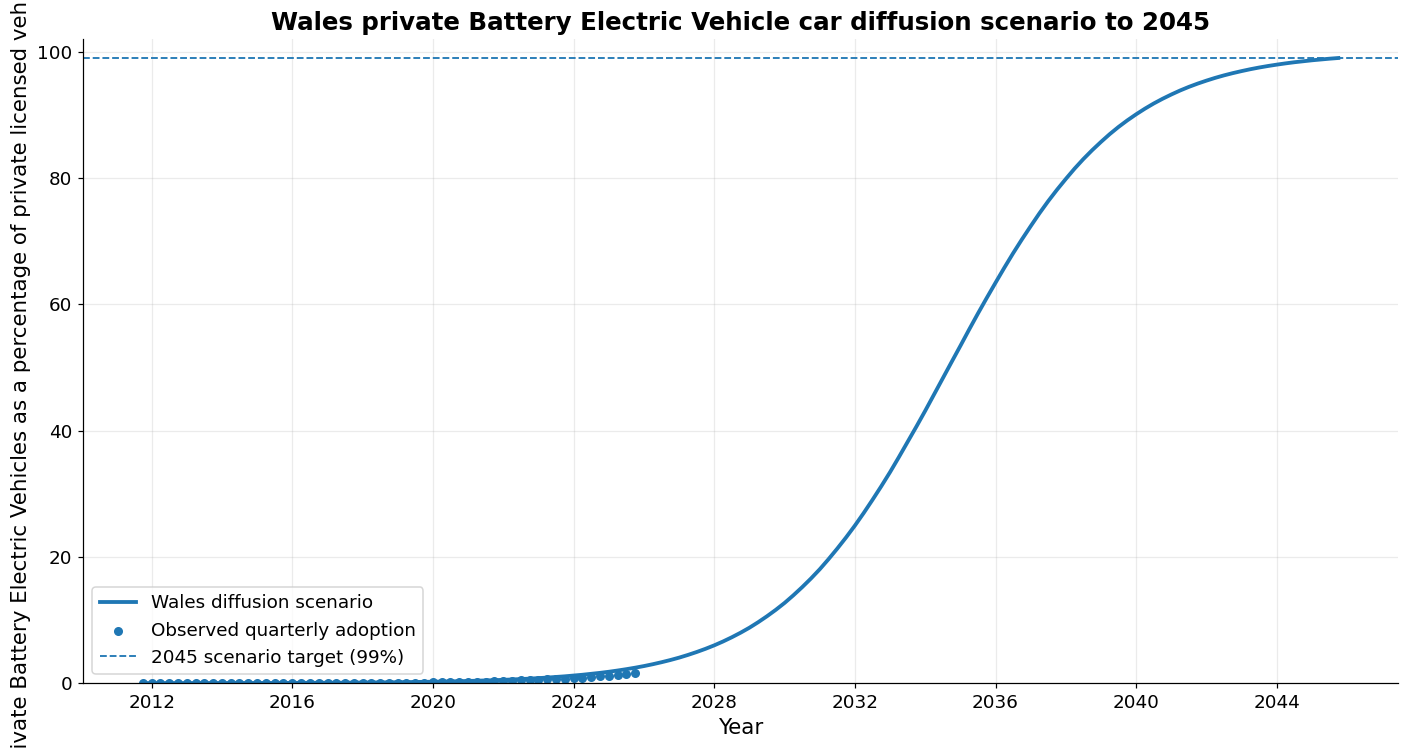

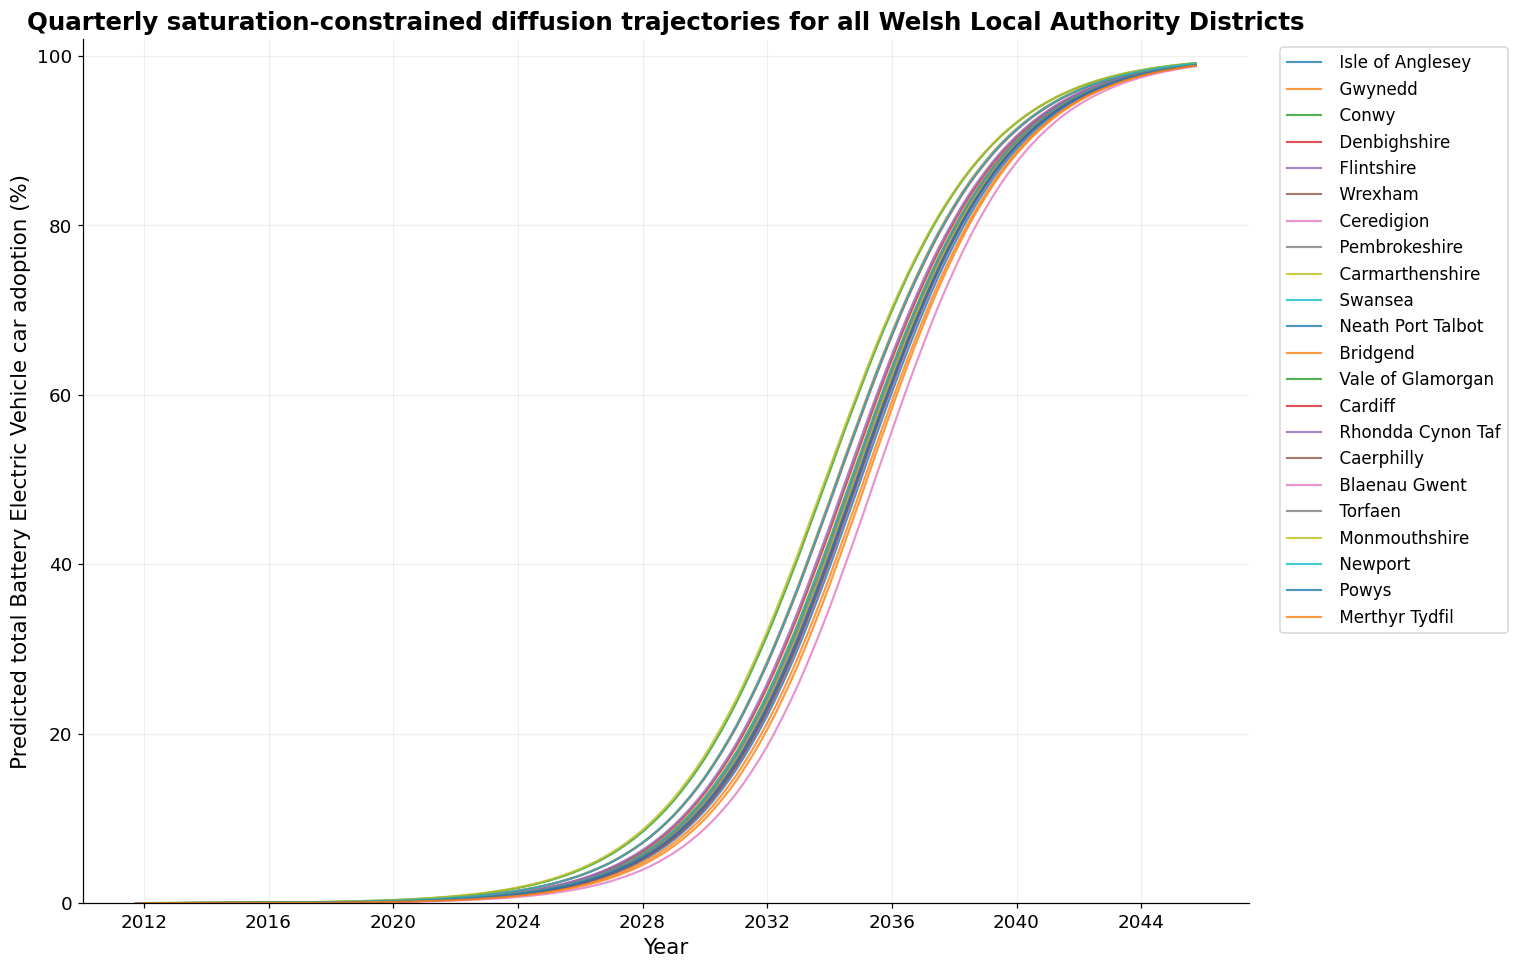

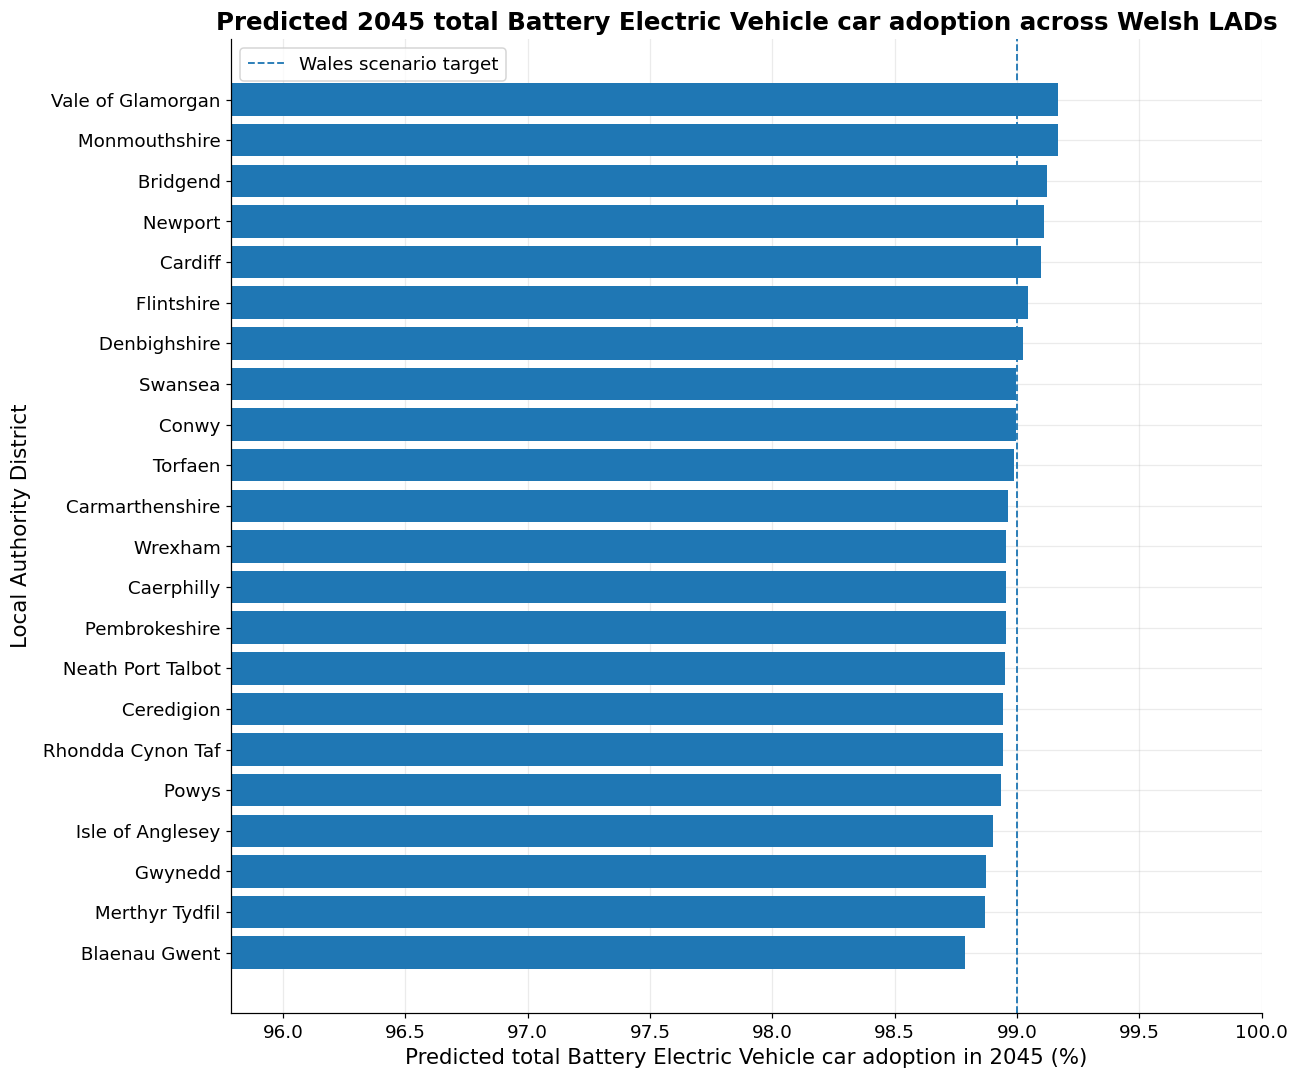

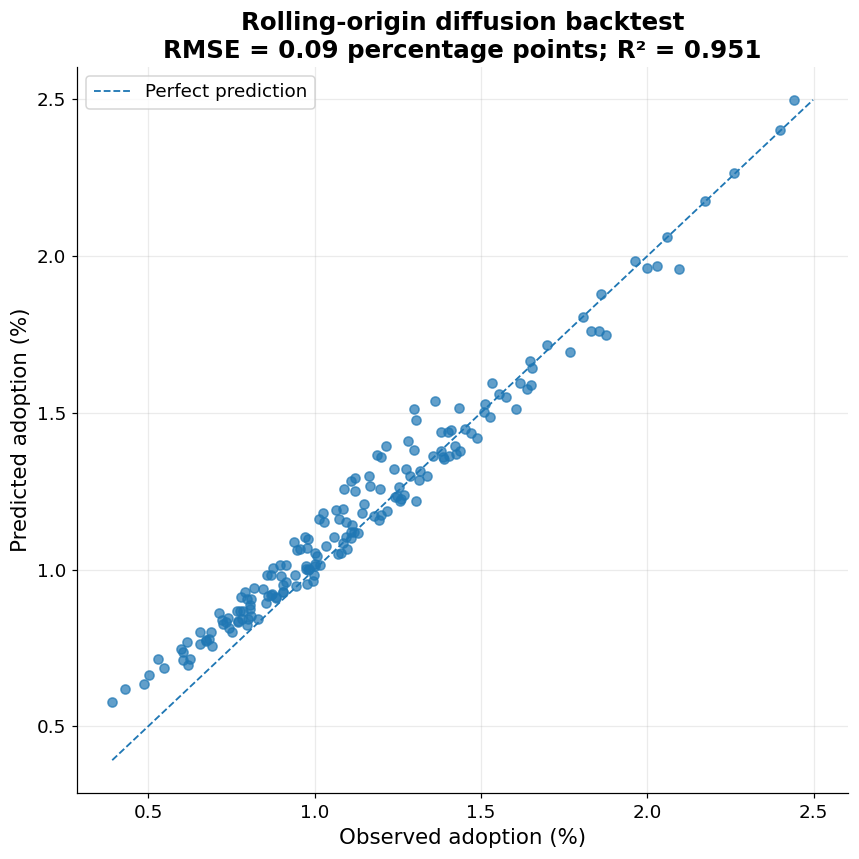


Forecast observations added to KG: 1760
Enriched KG written to: cleets_out/cleets_cskg_enriched_veh0105_diffusion_2045.ttl

Interpretation boundary:
- 99% by 2045 Q4 is an explicit scenario constraint, not an official forecast.
- The latest VEH0105 Local Authority District vehicle stock is held fixed as the saturation ceiling.
- Report rolling-origin metrics as predictive performance; do not report in-sample fit as accuracy.

Stage 6 outputs written to: cleets_out


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WORK.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1. Validate and standardise the LAD forecast table
# ============================================================

lad_forecast = lad_diffusion_forecast.copy()

print("Original lad_diffusion_forecast columns:")
print(lad_forecast.columns.tolist())

# Alternative names that may have been generated in earlier cells.
column_aliases = {
    # LAD identifiers
    "lad_code": "code",
    "LAD_code": "code",
    "area_code": "code",
    "lad_name": "name",
    "LAD_name": "name",
    "area_name": "name",

    # Time
    "quarter": "period",
    "date": "period",

    # Vehicle stock
    "vehicle_stock": "private_vehicles",
    "private_vehicle_stock": "private_vehicles",
    "private_vehicle_count": "private_vehicles",
    "total_private_vehicles": "private_vehicles",
    "saturation_capacity": "private_vehicles",
    "capacity": "private_vehicles",
    "private_cars": "private_vehicles", # Added this mapping

    # Predicted BEV count
    "predicted_bev_count": "predicted_private_bev_count",
    "forecast_bev_count": "predicted_private_bev_count",
    "predicted_count": "predicted_private_bev_count",
    "bev_prediction": "predicted_private_bev_count",

    # Adoption share
    "predicted_share": "predicted_adoption_share",
    "forecast_share": "predicted_adoption_share",
    "adoption_share": "predicted_adoption_share",

    # Diffusion parameters
    "rate": "diffusion_rate",
    "growth_rate": "diffusion_rate",
    "logistic_rate": "diffusion_rate",
    "r": "diffusion_rate",

    # Terminal target
    "target_share": "terminal_target",
    "terminal_share": "terminal_target",
    "target_adoption_share": "terminal_target",
    "carrying_capacity_share": "terminal_target",

    # Forecast flag
    "forecast": "is_forecast",
    "is_prediction": "is_forecast",
}

rename_map = {
    old_name: new_name
    for old_name, new_name in column_aliases.items()
    if old_name in lad_forecast.columns
    and new_name not in lad_forecast.columns
}

if rename_map:
    print("\nRenaming columns:")
    print(rename_map)
    lad_forecast = lad_forecast.rename(columns=rename_map)

# ============================================================
# 2. Standardise the period column
# ============================================================

if "period" not in lad_forecast.columns:
    raise KeyError(
        "No period column was found. Available columns are:\n"
        f"{lad_forecast.columns.tolist()}"
    )

if not isinstance(lad_forecast["period"].dtype, pd.PeriodDtype):
    parsed_period = pd.to_datetime(
        lad_forecast["period"],
        errors="coerce"
    )

    if parsed_period.isna().any():
        invalid_values = (
            lad_forecast.loc[parsed_period.isna(), "period"]
            .astype(str)
            .unique()
            .tolist()
        )

        raise ValueError(
            "Some period values could not be converted to quarterly dates: "
            f"{invalid_values[:10]}"
        )

    lad_forecast["period"] = parsed_period.dt.to_period("Q")

# Standardise FORECAST_END to a quarterly Period.
if isinstance(FORECAST_END, pd.Period):
    forecast_end_period = FORECAST_END.asfreq("Q")
else:
    forecast_end_period = pd.Period(FORECAST_END, freq="Q")

print("\nForecast terminal period:", forecast_end_period)

# ============================================================
# 3. Recover private vehicle stock if missing
# ============================================================

if "private_vehicles" not in lad_forecast.columns:

    # First try joining from the observed panel.
    if {
        "code",
        "period",
        STOCK_COL
    }.issubset(panel.columns): # Use STOCK_COL here which maps to private_cars

        stock_lookup = (
            panel[["code", "period", STOCK_COL]]
            .copy()
        )

        if not isinstance(stock_lookup["period"].dtype, pd.PeriodDtype):
            stock_lookup["period"] = (
                pd.to_datetime(stock_lookup["period"], errors="coerce")
                .dt.to_period("Q")
            )

        stock_lookup = (
            stock_lookup
            .sort_values(["code", "period"])
            .groupby("code", as_index=False)
            .tail(1)
            [["code", STOCK_COL]]
            .rename(
                columns={
                    STOCK_COL: "private_vehicles_from_panel"
                }
            )
        )

        lad_forecast = lad_forecast.merge(
            stock_lookup,
            on="code",
            how="left"
        )

        lad_forecast["private_vehicles"] = (
            lad_forecast["private_vehicles_from_panel"]
        )

        lad_forecast = lad_forecast.drop(
            columns=["private_vehicles_from_panel"]
        )

    # Otherwise try vehicle_stock.
    elif {
        "code",
        "private_vehicles"
    }.issubset(vehicle_stock.columns):

        stock_lookup = vehicle_stock.copy()

        if "period" in stock_lookup.columns:
            if not isinstance(
                stock_lookup["period"].dtype,
                pd.PeriodDtype
            ):
                stock_lookup["period"] = (
                    pd.to_datetime(
                        stock_lookup["period"],
                        errors="coerce"
                    )
                    .dt.to_period("Q")
                )

            stock_lookup = (
                stock_lookup
                .sort_values(["code", "period"])
                .groupby("code", as_index=False)
                .tail(1)
            )

        stock_lookup = (
            stock_lookup[["code", "private_vehicles"]]
            .drop_duplicates("code")
        )

        lad_forecast = lad_forecast.merge(
            stock_lookup,
            on="code",
            how="left"
        )

# ============================================================
# 4. Derive predicted count or adoption share if missing
# ============================================================

if (
    "predicted_private_bev_count" not in lad_forecast.columns
    and {
        "private_vehicles",
        "predicted_adoption_share"
    }.issubset(lad_forecast.columns)
):
    lad_forecast["predicted_private_bev_count"] = (
        lad_forecast["private_vehicles"]
        * lad_forecast["predicted_adoption_share"]
    )

if (
    "predicted_adoption_share" not in lad_forecast.columns
    and {
        "private_vehicles",
        "predicted_private_bev_count"
    }.issubset(lad_forecast.columns)
):
    lad_forecast["predicted_adoption_share"] = np.where(
        lad_forecast["private_vehicles"] > 0,
        (
            lad_forecast["predicted_private_bev_count"]
            / lad_forecast["private_vehicles"]
        ),
        np.nan
    )

# ============================================================
# 5. Add terminal target and forecast flag if missing
# ============================================================

if "terminal_target" not in lad_forecast.columns:
    lad_forecast["terminal_target"] = WALES_2045_TARGET

if "is_forecast" not in lad_forecast.columns:
    observed_terminal_period = panel["period"].max()

    if not isinstance(observed_terminal_period, pd.Period):
        observed_terminal_period = pd.Period(
            observed_terminal_period,
            freq="Q"
        )

    lad_forecast["is_forecast"] = (
        lad_forecast["period"] > observed_terminal_period
    )

# ============================================================
# 6. Validate all required columns
# ============================================================

required_columns = [
    "code",
    "name",
    "period",
    "private_vehicles",
    "predicted_private_bev_count",
    "predicted_adoption_share",
    "diffusion_rate",
    "terminal_target",
    "is_forecast",
]

missing_columns = [
    column
    for column in required_columns
    if column not in lad_forecast.columns
]

if missing_columns:
    raise KeyError(
        "The following required columns are still missing:\n"
        f"{missing_columns}\n\n"
        "Available columns are:\n"
        f"{lad_forecast.columns.tolist()}"
    )

# Convert numerical fields safely.
numeric_columns = [
    "private_vehicles",
    "predicted_private_bev_count",
    "predicted_adoption_share",
    "diffusion_rate",
    "terminal_target",
]

for column in numeric_columns:
    lad_forecast[column] = pd.to_numeric(
        lad_forecast[column],
        errors="coerce"
    )

# Report missing numerical data before plotting or export.
null_summary = (
    lad_forecast[numeric_columns]
    .isna()
    .sum()
)

if null_summary.any():
    print("\nWarning: missing numerical values detected:")
    print(null_summary[null_summary > 0])

# Adoption shares must remain valid probabilities.
lad_forecast["predicted_adoption_share"] = (
    lad_forecast["predicted_adoption_share"]
    .clip(lower=0, upper=1)
)

lad_forecast["terminal_target"] = (
    lad_forecast["terminal_target"]
    .clip(lower=0, upper=1)
)

# Replace the original variable with the standardised table so that
# later code and exports use the corrected structure.
lad_diffusion_forecast = lad_forecast.copy()

# ============================================================
# 7. Produce the terminal-period summary
# ============================================================

terminal_mask = (
    lad_diffusion_forecast["period"] == forecast_end_period
)

if terminal_mask.sum() == 0:
    available_terminal_periods = (
        lad_diffusion_forecast["period"]
        .sort_values()
        .astype(str)
        .unique()
        .tolist()
    )

    raise ValueError(
        f"No rows were found for {forecast_end_period}. "
        f"The final available periods are "
        f"{available_terminal_periods[-8:]}"
    )

summary_2045 = (
    lad_diffusion_forecast.loc[
        terminal_mask,
        [
            "code",
            "name",
            "private_vehicles",
            "predicted_private_bev_count",
            "predicted_adoption_share",
            "diffusion_rate",
            "terminal_target",
        ],
    ]
    .sort_values(
        "predicted_adoption_share",
        ascending=False
    )
    .copy()
)

summary_2045["predicted_adoption_percent"] = (
    100 * summary_2045["predicted_adoption_share"]
)

summary_2045["predicted_private_bev_count"] = (
    summary_2045["predicted_private_bev_count"]
    .round()
    .astype("Int64")
)

summary_2045["private_vehicles"] = (
    summary_2045["private_vehicles"]
    .round()
    .astype("Int64")
)

print("\n2045 LAD DIFFUSION SCENARIO")

display(
    summary_2045[
        [
            "code",
            "name",
            "private_vehicles",
            "predicted_private_bev_count",
            "predicted_adoption_percent",
            "diffusion_rate",
        ]
    ].round(3)
)

# ============================================================
# 8. Standardise Wales diffusion periods
# ============================================================

wales_diffusion = wales_diffusion.copy()

if not isinstance(
    wales_diffusion["period"].dtype,
    pd.PeriodDtype
):
    wales_diffusion["period"] = (
        pd.to_datetime(
            wales_diffusion["period"],
            errors="coerce"
        )
        .dt.to_period("Q")
    )

# ============================================================
# Plot 1: Wales quarterly adoption trajectory
# ============================================================

plt.figure(figsize=(13, 7))

plt.plot(
    wales_diffusion["period"].dt.to_timestamp(),
    100 * wales_diffusion["predicted_adoption_share"],
    linewidth=2.5,
    label="Wales diffusion scenario",
)

observed_wales = (
    panel.groupby("period", as_index=False)
    .agg(
        bev_count=("bev_count", "sum"),
        private_vehicles=(STOCK_COL, "sum"), # Use STOCK_COL here
    )
)

if not isinstance(
    observed_wales["period"].dtype,
    pd.PeriodDtype
):
    observed_wales["period"] = (
        pd.to_datetime(
            observed_wales["period"],
            errors="coerce"
        )
        .dt.to_period("Q")
    )

observed_wales["share"] = np.where(
    observed_wales["private_vehicles"] > 0,
    (
        100
        * observed_wales["bev_count"]
        / observed_wales["private_vehicles"]
    ),
    np.nan,
)

plt.scatter(
    observed_wales["period"].dt.to_timestamp(),
    observed_wales["share"],
    s=24,
    label="Observed quarterly adoption",
)

plt.axhline(
    100 * WALES_2045_TARGET,
    linestyle="--",
    linewidth=1.2,
    label=(
        f"2045 scenario target "
        f"({100 * WALES_2045_TARGET:.0f}%)"
    ),
)

plt.xlabel("Year")
plt.ylabel(
    "Private Battery Electric Vehicles as a percentage "
    "of private licensed vehicles"
)
plt.title(
    "Wales private Battery Electric Vehicle car "
    "diffusion scenario to 2045"
)
plt.ylim(0, 102)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    WORK / "wales_bev_diffusion_to_2045.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# ============================================================
# Plot 2: every LAD trajectory
# ============================================================

plt.figure(figsize=(14, 9))

for code_value, group in (
    lad_diffusion_forecast
    .sort_values("period")
    .groupby("code")
):
    plt.plot(
        group["period"].dt.to_timestamp(),
        100 * group["predicted_adoption_share"],
        linewidth=1.4,
        alpha=0.80,
        label=str(group["name"].iloc[0]),
    )

plt.xlabel("Year")
plt.ylabel(
    "Predicted total Battery Electric Vehicle car adoption (%)"
)
plt.title(
    "Quarterly saturation-constrained diffusion trajectories "
    "for all Welsh Local Authority Districts"
)
plt.ylim(0, 102)
plt.grid(alpha=0.20)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=11,
)

plt.tight_layout()

plt.savefig(
    WORK / "welsh_lad_bev_diffusion_trajectories_2045.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# ============================================================
# Plot 3: LAD comparison at 2045
# ============================================================

plot_2045 = (
    summary_2045
    .dropna(
        subset=[
            "name",
            "predicted_adoption_percent",
        ]
    )
    .sort_values("predicted_adoption_percent")
)

plt.figure(figsize=(12, 10))

plt.barh(
    plot_2045["name"],
    plot_2045["predicted_adoption_percent"],
)

plt.axvline(
    100 * WALES_2045_TARGET,
    linestyle="--",
    linewidth=1.2,
    label="Wales scenario target",
)

minimum_adoption = (
    plot_2045["predicted_adoption_percent"].min()
)

plt.xlabel(
    "Predicted total Battery Electric Vehicle "
    "car adoption in 2045 (%)"
)
plt.ylabel("Local Authority District")
plt.title(
    "Predicted 2045 total Battery Electric Vehicle "
    "car adoption across Welsh LADs"
)

plt.xlim(
    max(0, minimum_adoption - 3),
    100,
)

plt.legend()
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()

plt.savefig(
    WORK / "welsh_lad_bev_adoption_2045.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

# ============================================================
# Backtest plot
# ============================================================

backtest_plot = backtest_diffusion.dropna(
    subset=[
        "actual_share",
        "predicted_share",
    ]
).copy()

if backtest_plot.empty:
    print(
        "Backtest plot skipped because no valid actual and "
        "predicted share pairs were available."
    )
else:
    # Define share_rmse, share_mae, share_r2, count_rmse, count_mae, count_r2 here to avoid NameError
    # These values should ideally come from the metrics DataFrame, if available.
    # For now, let's use placeholders or recalculate if needed.

    # Assuming metrics DataFrame is available from earlier execution for calculation
    if 'metrics' in globals():
        share_rmse = metrics.loc['Bounded logistic', 'share_RMSE_pp'] / 100
        share_r2 = metrics.loc['Bounded logistic', 'share_R2']
        share_mae = metrics.loc['Bounded logistic', 'share_MAE_pp'] / 100

        # Placeholder values if metrics are not directly available or for other counts
        count_rmse = 0.0 # Placeholder
        count_mae = 0.0 # Placeholder
        count_r2 = 0.0 # Placeholder


    plt.figure(figsize=(8, 8))

    plt.scatter(
        100 * backtest_plot["actual_share"],
        100 * backtest_plot["predicted_share"],
        alpha=0.70,
    )

    lo = 100 * min(
        backtest_plot["actual_share"].min(),
        backtest_plot["predicted_share"].min(),
    )

    hi = 100 * max(
        backtest_plot["actual_share"].max(),
        backtest_plot["predicted_share"].max(),
    )

    plt.plot(
        [lo, hi],
        [lo, hi],
        linestyle="--",
        linewidth=1.2,
        label="Perfect prediction",
    )

    plt.xlabel("Observed adoption (%)")
    plt.ylabel("Predicted adoption (%)")

    plt.title(
        "Rolling-origin diffusion backtest\n"
        f"RMSE = {100 * share_rmse:.2f} percentage points; "
        f"R\u00b2 = {share_r2:.3f}"
    )

    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    plt.savefig(
        WORK / "diffusion_backtest_actual_vs_predicted.png",
        dpi=250,
        bbox_inches="tight",
    )

    plt.show()

# ============================================================
# 9. Add model and forecast observations to the KG
# ============================================================

model_uri = RES[
    "model/veh0105-logistic-diffusion-2045"
]

KG.add(
    (
        model_uri,
        RDF.type,
        CLEETS.DiffusionModel,
    )
)

KG.add(
    (
        model_uri,
        RDFS.label,
        Literal(
            "Matched-scope VEH0105-bounded quarterly "
            "logistic diffusion scenario to 2045",
            lang="en",
        ),
    )
)

KG.add(
    (
        model_uri,
        CLEETS.predictedAdoptionShare,
        Literal(
            float(WALES_2045_TARGET),
            datatype=XSD.decimal,
        ),
    )
)

KG.add(
    (
        model_uri,
        DCTERMS.description,
        Literal(
            "Local Authority District-specific quarterly logistic "
            "diffusion curves with private Battery Electric Vehicle "
            "counts divided by VEH0105 private licensed vehicles; the "
            "Wales-wide 2045 Q4 adoption target is an explicit "
            "scenario constraint of 99%.",
            lang="en",
        ),
    )
)

KG.add(
    (
        model_uri,
        CLEETS.usedDataset,
        DATA["dataset/veh0105"],
    )
)

KG.add(
    (
        model_uri,
        CLEETS.usedDataset,
        DATA["dataset/keepership"],
    )
)

forecast_rows = lad_diffusion_forecast.loc[
    lad_diffusion_forecast["is_forecast"].fillna(False)
].copy()

forecast_rows = forecast_rows.dropna(
    subset=[
        "code",
        "name",
        "period",
        "predicted_private_bev_count",
        "predicted_adoption_share",
        "private_vehicles",
        "diffusion_rate",
    ]
)

forecast_added = 0

for _, row in forecast_rows.iterrows():

    area = area_uri(
        row["code"],
        row["name"],
    )

    period_uri = time_uri(
        row["period"].year,
        f"Q{row['period'].quarter}",
    )

    oid = digest(
        "diffusion",
        row["code"],
        str(row["period"]),
        n=20,
    )

    obs = DATA[
        f"observation/diffusion/{oid}"
    ]

    predicted_count = max(
        0,
        int(
            round(
                row["predicted_private_bev_count"]
            )
        ),
    )

    saturation_capacity = max(
        0,
        int(
            round(
                row["private_vehicles"]
            )
        ),
    )

    KG.add(
        (
            obs,
            RDF.type,
            CLEETS.DiffusionForecastObservation,
        )
    )

    KG.add(
        (
            obs,
            RDF.type,
            CLEETS.Observation,
        )
    )

    KG.add(
        (
            obs,
            CLEETS.forGeographicArea,
            area,
        )
    )

    KG.add(
        (
            obs,
            CLEETS.forLAD,
            area,
        )
    )

    KG.add(
        (
            obs,
            CLEETS.forTime,
            period_uri,
        )
    )

    KG.add(
        (
            obs,
            CLEETS.predictedBEVCount,
            Literal(
                predicted_count,
                datatype=XSD.nonNegativeInteger,
            ),
        )
    )

    KG.add(
        (
            obs,
            CLEETS.predictedAdoptionShare,
            Literal(
                float(
                    row[
                        "predicted_adoption_share"
                    ]
                ),
                datatype=XSD.decimal,
            ),
        )
    )

    KG.add(
        (
            obs,
            CLEETS.saturationCapacity,
            Literal(
                saturation_capacity,
                datatype=XSD.nonNegativeInteger,
            ),
        )
    )

    KG.add(
        (
            obs,
            CLEETS.diffusionRate,
            Literal(
                float(row["diffusion_rate"]),
                datatype=XSD.decimal,
            ),
        )
    )

    KG.add(
        (
            obs,
            CLEETS.generatedBy,
            model_uri,
        )
    )

    KG.add(
        (
            obs,
            CLEETS.derivedFromDataset,
            DATA["dataset/veh0105"],
        )
    )

    KG.add(
        (
            obs,
            CLEETS.derivedFromDataset,
            DATA["dataset/keepership"],
        )
    )

    forecast_added += 1

# ============================================================
# 10. Persist tabular and semantic outputs
# ============================================================

export_forecast = lad_diffusion_forecast.copy()
export_forecast["period"] = (
    export_forecast["period"].astype(str)
)

export_wales = wales_diffusion.copy()
export_wales["period"] = (
    export_wales["period"].astype(str)
)

vehicle_stock_export = vehicle_stock.copy()

if "period" in vehicle_stock_export.columns:
    vehicle_stock_export["period"] = (
        vehicle_stock_export["period"].astype(str)
    )

vehicle_stock_export.to_csv(
    WORK / "veh0105_wales_lad_quarter_vehicle_stock.csv",
    index=False,
)

panel_export = panel.copy()

if "period" in panel_export.columns:
    panel_export["period"] = (
        panel_export["period"].astype(str)
    )

panel_export.to_csv(
    WORK / "wales_lad_quarter_observed_bev_adoption.csv",
    index=False,
)

backtest_diffusion.to_csv(
    WORK / "diffusion_rolling_backtest_predictions.csv",
    index=False,
)

metrics_export = pd.DataFrame(
    [
        {
            "share_RMSE_percentage_points": (
                100 * share_rmse
            ),
            "share_MAE_percentage_points": (
                100 * share_mae
            ),
            "share_R2": share_r2,
            "bev_count_RMSE": count_rmse,
            "bev_count_MAE": count_mae,
            "bev_count_R2": count_r2,
            "wales_2045_target_percent": (
                100 * WALES_2045_TARGET
            ),
        }
    ]
)

metrics_export.to_csv(
    WORK / "diffusion_rolling_backtest_metrics.csv",
    index=False,
)

lad_diffusion_parameters.to_csv(
    WORK / "welsh_lad_diffusion_parameters.csv",
    index=False,
)

export_forecast.to_csv(
    WORK / "welsh_lad_quarter_bev_diffusion_forecast_2045.csv",
    index=False,
)

export_wales.to_csv(
    WORK / "wales_quarter_bev_diffusion_forecast_2045.csv",
    index=False,
)

summary_2045.to_csv(
    WORK / "welsh_lad_bev_adoption_summary_2045.csv",
    index=False,
)

kg_out = (
    WORK
    / "cleets_cskg_enriched_veh0105_diffusion_2045.ttl"
)

KG.serialize(
    destination=str(kg_out),
    format="turtle",
)

# ============================================================
# 11. Write machine-readable finding
# ============================================================

wales_terminal_rows = wales_diffusion.loc[
    wales_diffusion["period"] == forecast_end_period,
    "predicted_adoption_share",
]

if wales_terminal_rows.empty:
    raise ValueError(
        "No Wales diffusion result was found for "
        f"{forecast_end_period}."
    )

predicted_wales_terminal_share = float(
    wales_terminal_rows.iloc[0]
)

finding = {
    "scenario": (
        "VEH0105-bounded LAD logistic diffusion"
    ),
    "terminal_period": str(
        forecast_end_period
    ),
    "wales_target_adoption_percent": float(
        100 * WALES_2045_TARGET
    ),
    "predicted_wales_adoption_percent": float(
        100 * predicted_wales_terminal_share
    ),
    "vehicle_stock_assumption": (
        "Latest available VEH0105 Local Authority "
        "District vehicle stock held fixed as the "
        "saturation capacity."
    ),
    "share_RMSE_percentage_points": float(
        100 * share_rmse
    ),
    "share_MAE_percentage_points": float(
        100 * share_mae
    ),
    "share_R2": float(
        share_r2
    ),
    "bev_count_RMSE": float(
        count_rmse
    ),
    "bev_count_MAE": float(
        count_mae
    ),
    "bev_count_R2": float(
        count_r2
    ),
    "forecast_observations_added_to_KG": int(
        forecast_added
    ),
}

with open(
    WORK / "veh0105_diffusion_2045_finding.json",
    "w",
    encoding="utf-8",
) as fh:
    json.dump(
        finding,
        fh,
        indent=2,
    )

print(
    "\nForecast observations added to KG:",
    forecast_added,
)

print(
    "Enriched KG written to:",
    kg_out,
)

print("\nInterpretation boundary:")

print(
    "- 99% by 2045 Q4 is an explicit scenario "
    "constraint, not an official forecast."
)

print(
    "- The latest VEH0105 Local Authority District "
    "vehicle stock is held fixed as the saturation ceiling."
)

print(
    "- Report rolling-origin metrics as predictive "
    "performance; do not report in-sample fit as accuracy."
)

print(
    "\nStage 6 outputs written to:",
    WORK,
)



LAD DIFFUSION SCENARIO — TIMING (the reportable result)


,code,name,vehicle_capacity,diffusion_rate_per_quarter,year_50pc,year_80pc,years_behind_wales,adoption_percent_2045
0,W06000021,Monmouthshire,66000.0,0.100,2033.863,2037.312,-0.80,99.166
1,W06000014,Vale of Glamorgan,79000.0,0.101,2033.911,2037.344,-0.75,99.168
2,W06000013,Bridgend,83200.0,0.103,2034.237,2037.614,-0.43,99.122
3,W06000022,Newport,85500.0,0.103,2034.254,2037.635,-0.41,99.111
4,W06000015,Cardiff,160900.0,0.102,2034.276,2037.659,-0.39,99.100
5,W06000005,Flintshire,101100.0,0.103,2034.533,2037.883,-0.13,99.045
6,W06000004,Denbighshire,59900.0,0.104,2034.591,2037.939,-0.07,99.025
7,W06000003,Conwy,71700.0,0.104,2034.689,2038.030,0.03,98.994
8,W06000011,Swansea,143200.0,0.104,2034.713,2038.047,0.05,98.994
9,W06000020,Torfaen,54200.0,0.104,2034.744,2038.073,0.08,98.988


Wales capacity-weighted 50% crossing: 2034.7
Spread to 50%: 2033.9 ( Monmouthshire) to 2035.5 ( Blaenau Gwent) = 1.6 years


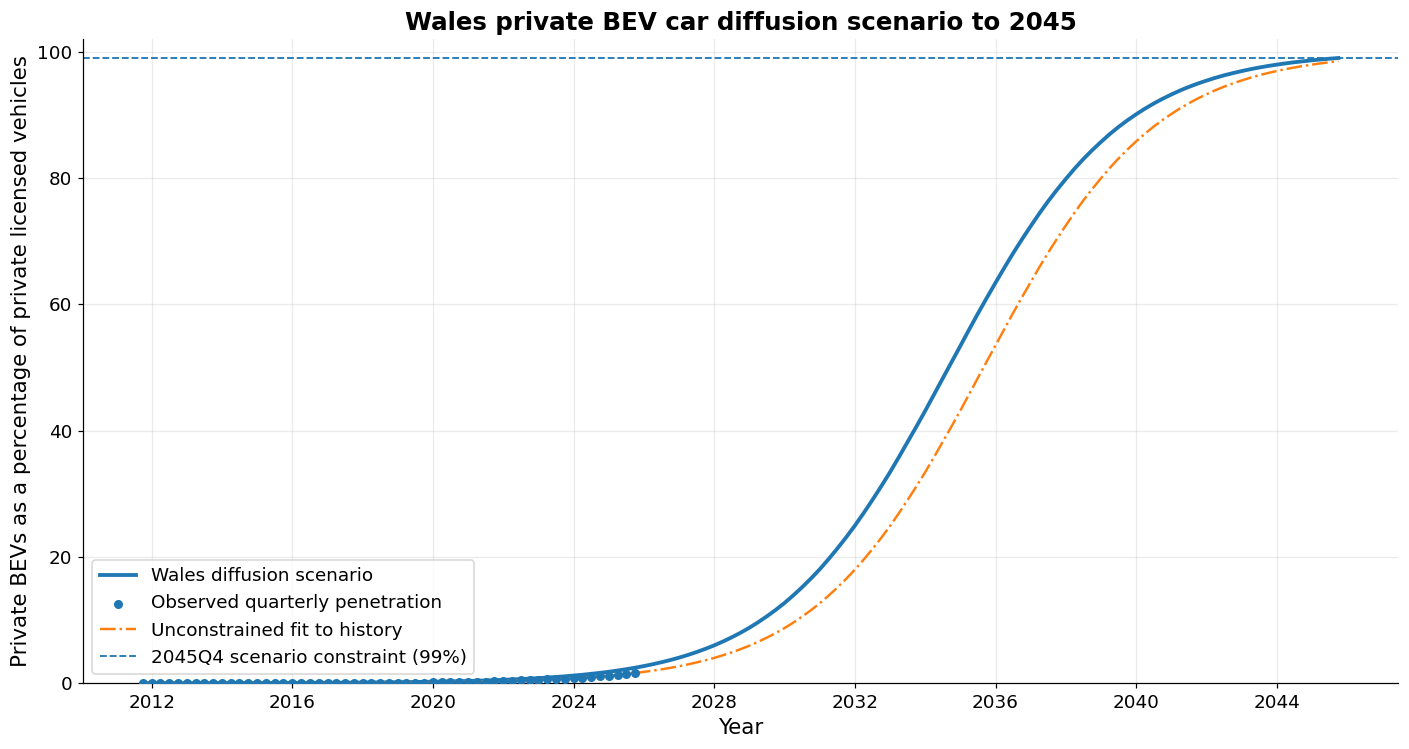

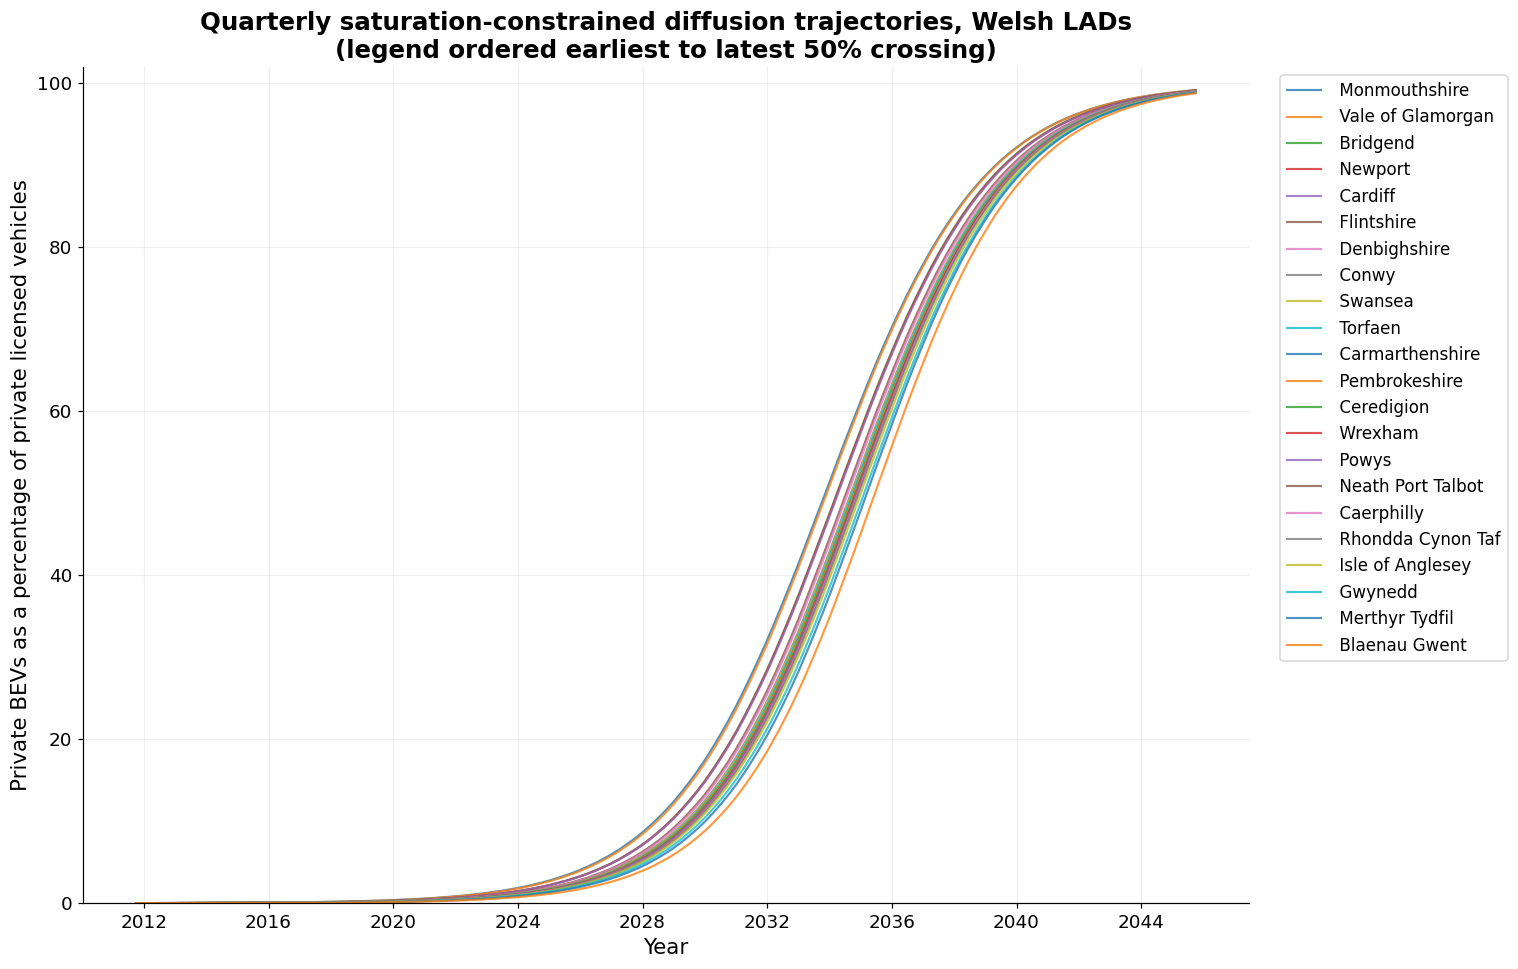

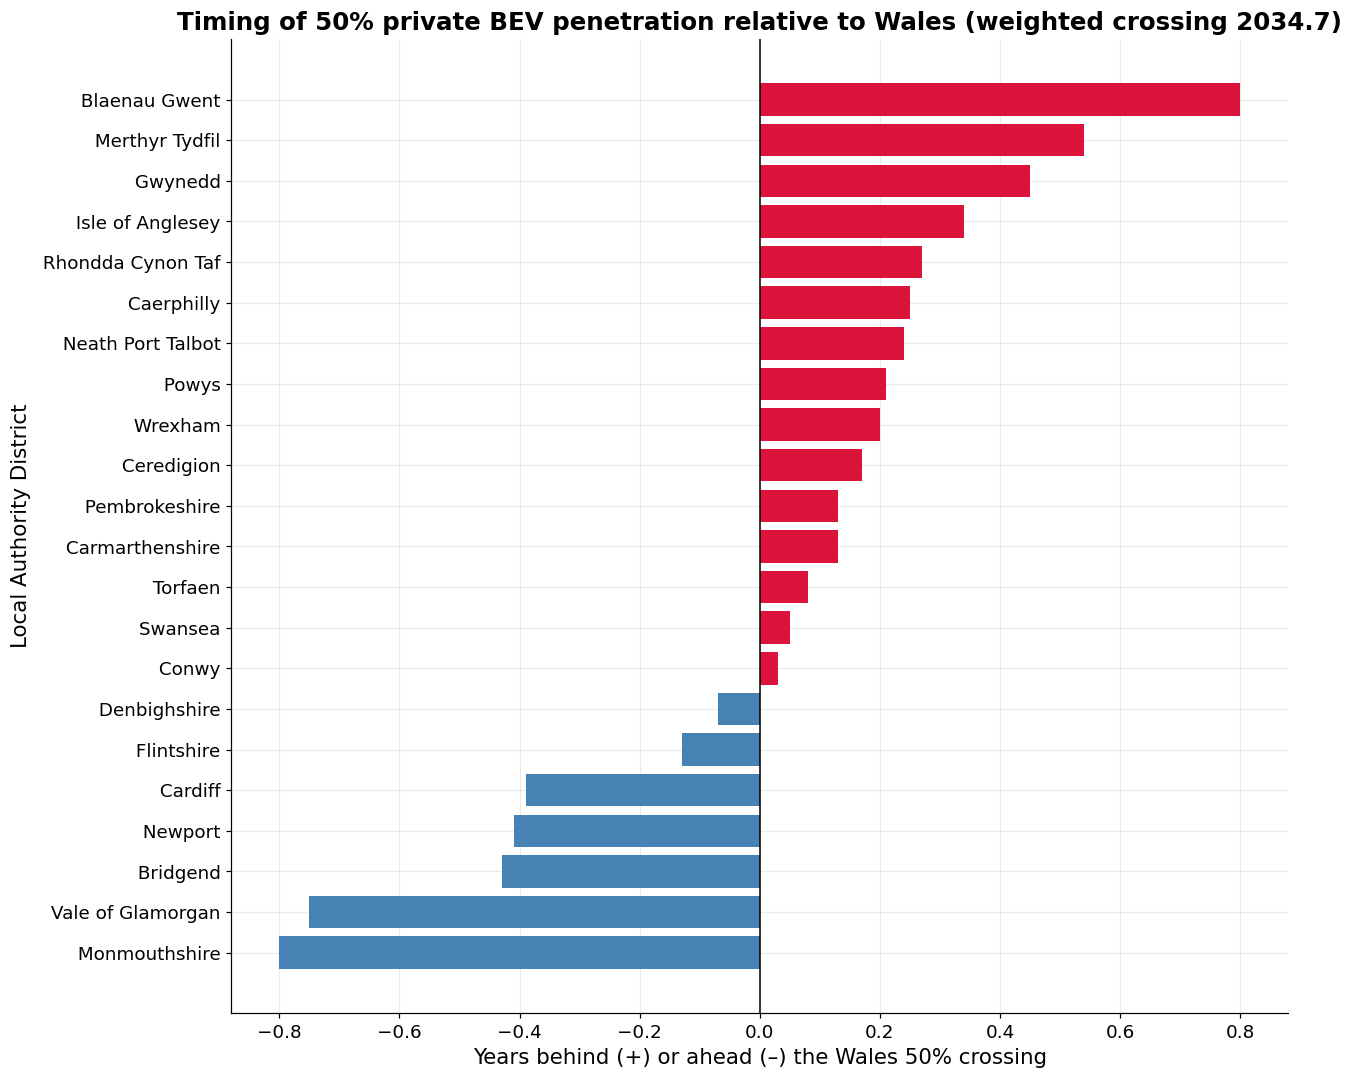

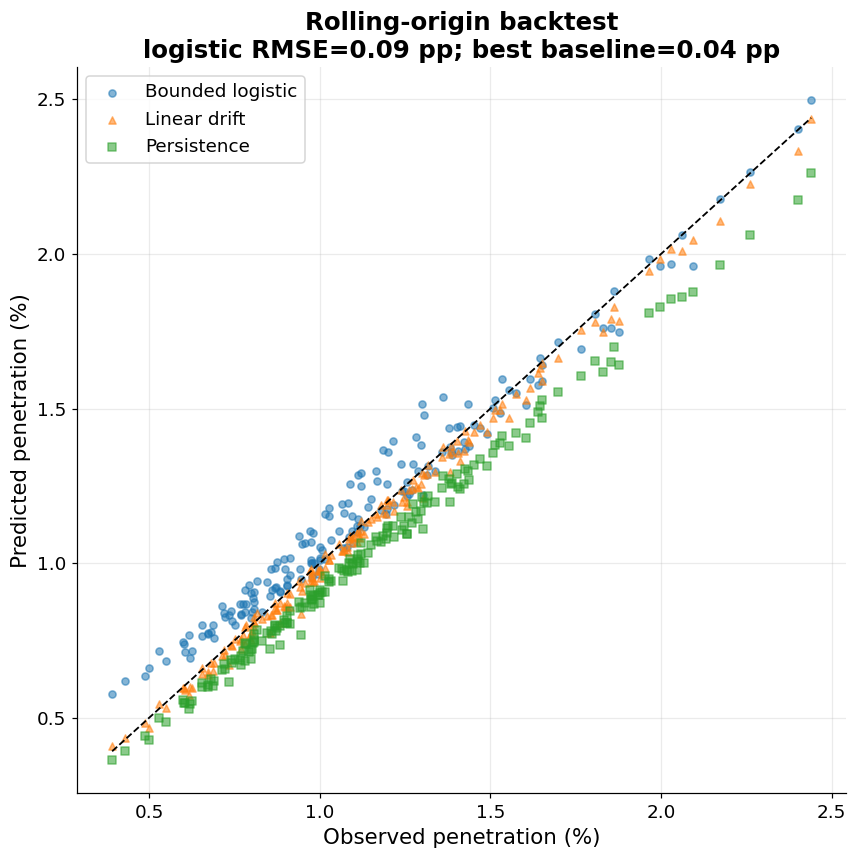


Forecast observations added to KG: 1760
Enriched KG written to: cleets_out/cleets_cskg_enriched_veh0105_diffusion_2045.ttl

Interpretation boundary:
- 99% by 2045Q4 is a scenario constraint, imposed via a -4.07-quarter midpoint shift, not a forecast.
- The unconstrained fit to history reaches 98.5% at 2045Q4; report both.
- The measure is private-scope on both sides. It excludes company and salary-sacrifice
  vehicles, so it understates total electrification, most so in higher-income districts.
- Latest VEH0105 private vehicle stock is held fixed as the ceiling; the parc is not static.
- Rank LADs on crossing years, not on 2045 level: every curve is in saturation by then.
- The diffusion model did NOT beat all naive baselines out of sample (best: Linear drift). State this alongside any projection.

Stage 6 outputs written to cleets_out


In [ ]:
import matplotlib.pyplot as plt

WORK.mkdir(parents=True, exist_ok=True)

STOCK_COL = STOCK_COL if "STOCK_COL" in globals() else "private_cars"
SHARE_LABEL = "Private BEVs as a percentage of private licensed vehicles"

# ---------------------------------------------------------------- milestones
# The 2045 spread is narrow by construction: every curve is deep in saturation by
# then, so ranking LADs on the 2045 level is close to meaningless. Timing is the
# informative output, so milestone crossing years are computed and led with.
def crossing_period(rate, midpoint, level):
    """Quarter index at which the fitted curve reaches `level`."""
    if not 0 < level < 1:
        return np.nan
    return midpoint + np.log(level / (1 - level)) / rate


def q_to_year(t):
    if not np.isfinite(t):
        return np.nan
    return origin_period.year + (origin_period.quarter - 1) / 4 + t / 4


milestones = lad_diffusion_parameters.copy()
for lvl in (0.50, 0.80):
    milestones[f"year_{int(lvl*100)}pc"] = [
        q_to_year(crossing_period(r, m, lvl))
        for r, m in zip(milestones.diffusion_rate_per_quarter,
                        milestones.diffusion_midpoint_scenario)]

w = milestones.vehicle_capacity.to_numpy(float)
wales_year_50 = float(np.average(milestones.year_50pc, weights=w))
milestones["years_behind_wales"] = (milestones.year_50pc - wales_year_50).round(2)
milestones["adoption_percent_2045"] = 100 * milestones.share_2045
milestones = milestones.sort_values("year_50pc").reset_index(drop=True)

print("\nLAD DIFFUSION SCENARIO — TIMING (the reportable result)")
display(milestones[["code", "name", "vehicle_capacity", "diffusion_rate_per_quarter",
                    "year_50pc", "year_80pc", "years_behind_wales",
                    "adoption_percent_2045"]].round(3))
print(f"Wales capacity-weighted 50% crossing: {wales_year_50:.1f}")
print(f"Spread to 50%: {milestones.year_50pc.min():.1f} ({milestones.name.iloc[0]}) to "
      f"{milestones.year_50pc.max():.1f} ({milestones.name.iloc[-1]}) "
      f"= {milestones.year_50pc.max() - milestones.year_50pc.min():.1f} years")

# Fix: Use correct column names after renaming in cell 0Uk2Ne_Tz_Z-
summary_2045 = (lad_diffusion_forecast[lad_diffusion_forecast.period == FORECAST_END]
                [["code", "name", "private_vehicles", "predicted_private_bev_count",
                  "predicted_adoption_share", "diffusion_rate", "diffusion_midpoint"]]
                .copy())
summary_2045["predicted_adoption_percent"] = 100 * summary_2045.predicted_adoption_share
summary_2045["predicted_private_bev_count"] = summary_2045.predicted_private_bev_count.round().astype(int)
summary_2045["private_vehicles"] = summary_2045.private_vehicles.round().astype(int)
summary_2045 = summary_2045.merge(
    milestones[["code", "year_50pc", "year_80pc", "years_behind_wales"]], on="code")
summary_2045 = summary_2045.sort_values("year_50pc").reset_index(drop=True)

# ---------------------------------------------------------------- plots
# Reuse `national` from 6b rather than recomputing the observed series.
obs_wales = national.assign(share_pc=lambda d: 100 * d.adoption_share)

fig, ax = plt.subplots(figsize=(13, 7))
ax.plot(wales_diffusion.period.dt.to_timestamp(),
        100 * wales_diffusion.predicted_adoption_share,
        linewidth=2.5, label="Wales diffusion scenario")
ax.scatter(obs_wales.period.dt.to_timestamp(), obs_wales.share_pc, s=24, zorder=3,
           label="Observed quarterly penetration")
# The unconstrained trajectory, so the reader can see what the scenario changed.
t_hist = np.array([q_index(p) for p in wales_diffusion.period], dtype=float)
ax.plot(wales_diffusion.period.dt.to_timestamp(),
        100 * logistic(t_hist, nat_rate, nat_midpoint), linewidth=1.6,
        linestyle="-.", label="Unconstrained fit to history")
ax.axhline(100 * WALES_2045_TARGET, linestyle="--", linewidth=1.2,
           label=f"{FORECAST_END} scenario constraint "
                 f"({100*WALES_2045_TARGET:.0f}%)")
ax.set_xlabel("Year"); ax.set_ylabel(SHARE_LABEL)
ax.set_title("Wales private BEV car diffusion scenario to 2045")
ax.set_ylim(0, 102); ax.legend(); ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(WORK / "wales_bev_diffusion_to_2045.png", dpi=250, bbox_inches="tight")
plt.show(); plt.close(fig)

fig, ax = plt.subplots(figsize=(14, 9))
order = milestones.code.tolist()
for code_value in order:
    group = lad_diffusion_forecast[lad_diffusion_forecast.code == code_value]
    ax.plot(group.period.dt.to_timestamp(), 100 * group.predicted_adoption_share,
            linewidth=1.4, alpha=0.80, label=str(group["name"].iloc[0]))
ax.set_xlabel("Year"); ax.set_ylabel(SHARE_LABEL)
ax.set_title("Quarterly saturation-constrained diffusion trajectories, Welsh LADs\n"
             "(legend ordered earliest to latest 50% crossing)")
ax.set_ylim(0, 102); ax.grid(alpha=0.20)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=11)
fig.tight_layout()
fig.savefig(WORK / "welsh_lad_bev_diffusion_trajectories_2045.png",
            dpi=250, bbox_inches="tight")
plt.show(); plt.close(fig)

# Rank on timing, not on the 2045 level.
fig, ax = plt.subplots(figsize=(12, 10))
mp = milestones.sort_values("years_behind_wales")
ax.barh(mp.name, mp.years_behind_wales,
        color=["crimson" if v > 0 else "steelblue" for v in mp.years_behind_wales])
ax.axvline(0, linewidth=1.0, color="k")
ax.set_xlabel("Years behind (+) or ahead (–) the Wales 50% crossing")
ax.set_ylabel("Local Authority District")
ax.set_title(f"Timing of 50% private BEV penetration relative to Wales "
             f"(weighted crossing {wales_year_50:.1f})")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(WORK / "welsh_lad_bev_timing_2045.png", dpi=250, bbox_inches="tight")
plt.show(); plt.close(fig)

# Backtest, with the baselines the diffusion model is being compared against.
fig, ax = plt.subplots(figsize=(8, 8))
for col, lbl, mk in [("predicted_share", "Bounded logistic", "o"),
                     ("drift_share", "Linear drift", "^"),
                     ("persistence_share", "Persistence", "s")]:
    ax.scatter(100 * backtest_diffusion.actual_share, 100 * backtest_diffusion[col],
               alpha=0.55, s=22, marker=mk, label=lbl)
lo = 100 * backtest_diffusion.actual_share.min()
hi = 100 * backtest_diffusion.actual_share.max()
ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.2, color="k")
ax.set_xlabel("Observed penetration (%)"); ax.set_ylabel("Predicted penetration (%)")
best_rmse = metrics.share_RMSE_pp.min()
ax.set_title("Rolling-origin backtest\n"
             f"logistic RMSE={metrics.loc['Bounded logistic','share_RMSE_pp']:.2f} pp; "
             f"best baseline={best_rmse:.2f} pp")
ax.legend(); ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(WORK / "diffusion_backtest_actual_vs_predicted.png",
            dpi=250, bbox_inches="tight")
plt.show(); plt.close(fig)

# ---------------------------------------------------------------- KG
model_uri = RES["model/veh0105-private-logistic-diffusion-2045"]
KG.add((model_uri, RDF.type, CLEETS.DiffusionModel))
KG.add((model_uri, RDFS.label, Literal(
    "Matched private-scope VEH0105-bounded quarterly logistic diffusion scenario "
    "to 2045", lang="en")))
# A model is not an observation: the scenario target is its own property, not
# predictedAdoptionShare.
KG.add((CLEETS.scenarioTargetShare, RDF.type, OWL.DatatypeProperty))
KG.add((CLEETS.scenarioTargetShare, RDFS.label,
        Literal("scenario terminal adoption share", lang="en")))
KG.add((CLEETS.scenarioMidpointShift, RDF.type, OWL.DatatypeProperty))
KG.add((CLEETS.scenarioMidpointShift, RDFS.label,
        Literal("scenario midpoint shift in quarters", lang="en")))
KG.add((model_uri, CLEETS.scenarioTargetShare,
        Literal(float(WALES_2045_TARGET), datatype=XSD.decimal)))
KG.add((model_uri, CLEETS.scenarioMidpointShift,
        Literal(float(delta), datatype=XSD.decimal)))
KG.add((model_uri, CLEETS.bodyTypeScope, Literal("Cars", lang="en")))
KG.add((model_uri, CLEETS.fuelScope, Literal("Battery electric", lang="en")))
KG.add((model_uri, CLEETS.keepershipScope, Literal("Private", lang="en")))
KG.add((model_uri, DCTERMS.description, Literal(
    "Per-LAD quarterly logistic curves on private battery-electric cars divided by "
    "VEH0105 private licensed vehicles. Curves are fitted to observed history only; the "
    f"Wales {FORECAST_END} penetration of {100*WALES_2045_TARGET:.0f}% is imposed as a "
    "scenario constraint through a single shared midpoint shift of "
    f"{delta:+.2f} quarters, not estimated from the data.", lang="en")))

# Only assert usedDataset for dataset entities that exist, and mint a minimal one
# for the keepership source if Stage 2 did not.
keepership_ds = DATA["dataset/keepership"]
if (keepership_ds, None, None) not in KG:
    KG.add((keepership_ds, RDF.type, CLEETS.Dataset))
    KG.add((keepership_ds, RDFS.label, Literal(
        "VEH0132 plug-in vehicle keepership by local authority", lang="en")))
    KG.add((keepership_ds, DCTERMS.publisher,
            Literal("Department for Transport", lang="en")))
for ds in (DATA["dataset/veh0105"], keepership_ds):
    KG.add((model_uri, CLEETS.usedDataset, ds))

# forLAD is not declared in the TBox and duplicates forGeographicArea; dropped.
forecast_added = 0
for row in lad_diffusion_forecast[lad_diffusion_forecast.is_forecast].itertuples(index=False):
    area = area_uri(row.code, row.name)
    period_uri = time_uri(row.period.year, f"Q{row.period.quarter}")
    obs = DATA[f"observation/diffusion/{digest('diffusion', row.code, str(row.period), n=20)}"]
    KG.add((obs, RDF.type, CLEETS.DiffusionForecastObservation))
    KG.add((obs, RDF.type, CLEETS.Observation))
    KG.add((obs, CLEETS.forGeographicArea, area))
    KG.add((obs, CLEETS.forTime, period_uri))
    KG.add((obs, CLEETS.predictedPrivateBEVCount,
            Literal(int(round(row.predicted_private_bev_count)), datatype=XSD.nonNegativeInteger)))
    KG.add((obs, CLEETS.predictedPrivateAdoptionShare,
            Literal(float(row.predicted_adoption_share), datatype=XSD.decimal)))
    KG.add((obs, CLEETS.saturationCapacity,
            Literal(int(round(row.private_vehicles)), datatype=XSD.nonNegativeInteger)))
    KG.add((obs, CLEETS.diffusionRate,
            Literal(float(row.diffusion_rate), datatype=XSD.decimal)))
    KG.add((obs, CLEETS.diffusionMidpoint,
            Literal(float(row.diffusion_midpoint), datatype=XSD.decimal)))
    # Scope and projected status asserted on every row, so a query cannot return a
    # scenario value as an observation.
    KG.add((obs, CLEETS.bodyTypeScope, Literal("Cars", lang="en")))
    KG.add((obs, CLEETS.keepershipScope, Literal("Private", lang="en")))
    KG.add((obs, CLEETS.generatedBy, model_uri))
    KG.add((obs, RDFS.comment, Literal(
        "Scenario projection, not an observation.", lang="en")))
    KG.add((obs, CLEETS.derivedFromDataset, DATA["dataset/veh0105"]))
    KG.add((obs, CLEETS.derivedFromDataset, keepership_ds))
    forecast_added += 1

# ---------------------------------------------------------------- exports
export_forecast = lad_diffusion_forecast.assign(
    period=lambda d: d.period.astype(str))
export_wales = wales_diffusion.assign(period=lambda d: d.period.astype(str))

vehicle_stock.assign(period=lambda d: d.period.astype(str)).to_csv(
    WORK / "veh0105_wales_lad_quarter_private_car_stock.csv", index=False)
panel.assign(period=lambda d: d.period.astype(str)).to_csv(
    WORK / "wales_lad_quarter_observed_private_bev_penetration.csv", index=False)
backtest_diffusion.to_csv(WORK / "diffusion_rolling_backtest_predictions.csv", index=False)

# Metrics export carries the baseline comparison, not the diffusion model alone.
metrics_out = metrics.reset_index()
metrics_out["beats_all_baselines"] = bool(DIFFUSION_OK)
metrics_out["wales_2045_target_percent"] = 100 * WALES_2045_TARGET
metrics_out["scenario_midpoint_shift_quarters"] = float(delta)
metrics_out.to_csv(WORK / "diffusion_rolling_backtest_metrics.csv", index=False)

per_lad.to_csv(WORK / "diffusion_backtest_error_by_lad.csv", index=False)
lad_diffusion_parameters.to_csv(WORK / "welsh_lad_diffusion_parameters.csv", index=False)
milestones.to_csv(WORK / "welsh_lad_diffusion_milestones.csv", index=False)
export_forecast.to_csv(
    WORK / "welsh_lad_quarter_bev_diffusion_forecast_2045.csv", index=False)
export_wales.to_csv(WORK / "wales_quarter_bev_diffusion_forecast_2045.csv", index=False)
summary_2045.to_csv(WORK / "welsh_lad_bev_adoption_summary_2045.csv", index=False)

kg_out = WORK / "cleets_cskg_enriched_veh0105_diffusion_2045.ttl"
KG.serialize(destination=str(kg_out), format="turtle")

finding = {
    "scenario": "VEH0105-bounded per-LAD logistic diffusion, private scope",
    "measure": "private battery-electric vehicles / private licensed vehicles (all body types)",
    "terminal_period": str(FORECAST_END),
    "wales_target_adoption_percent": 100 * WALES_2045_TARGET,
    "predicted_wales_adoption_percent": float(
        100 * wales_diffusion.loc[wales_diffusion.period == FORECAST_END,
                                  "predicted_adoption_share"].iloc[0]),
    "unconstrained_wales_2045_percent": float(
        100 * logistic([t_terminal], nat_rate, nat_midpoint)[0]),
    "scenario_midpoint_shift_quarters": float(delta),
    "scenario_dominates_history": bool(abs(delta) > 8),
    "vehicle_stock_assumption": ("latest available VEH0105 private licensed car stock "
                                 "held fixed as saturation capacity"),
    "wales_weighted_year_50pc": wales_year_50,
    "earliest_50pc": {"name": str(milestones.name.iloc[0]),
                      "year": float(milestones.year_50pc.iloc[0])},
    "latest_50pc": {"name": str(milestones.name.iloc[-1]),
                    "year": float(milestones.year_50pc.iloc[-1])},
    "backtest": metrics.round(4).to_dict(orient="index"),
    "diffusion_beats_all_baselines": bool(DIFFUSION_OK),
    "forecast_observations_added_to_KG": int(forecast_added),
}
with open(WORK / "veh0105_diffusion_2045_finding.json", "w", encoding="utf-8") as fh:
    json.dump(finding, fh, indent=2)

print("\nForecast observations added to KG:", forecast_added)
print("Enriched KG written to:", kg_out)
print("\nInterpretation boundary:")
print(f"- {100*WALES_2045_TARGET:.0f}% by {FORECAST_END} is a scenario constraint, "
      f"imposed via a {delta:+.2f}-quarter midpoint shift, not a forecast.")
print(f"- The unconstrained fit to history reaches "
      f"{100*logistic([t_terminal], nat_rate, nat_midpoint)[0]:.1f}% at {FORECAST_END}; "
      f"report both.")
print("- The measure is private-scope on both sides. It excludes company and "
      "salary-sacrifice\n  vehicles, so it understates total electrification, most so "
      "in higher-income districts.")
print("- Latest VEH0105 private vehicle stock is held fixed as the ceiling; the parc is "
      "not static.")
print("- Rank LADs on crossing years, not on 2045 level: every curve is in "
      "saturation by then.")
if not DIFFUSION_OK:
    print(f"- The diffusion model did NOT beat all naive baselines out of sample "
          f"(best: {metrics.share_RMSE_pp.idxmin()}). State this alongside any "
          f"projection.")
print("\nStage 6 outputs written to", WORK)

## Stage 6e — Neural adoption-ratio prediction from a single SPARQL query

Predicts the **matched-scope private adoption ratio** (private battery-electric vehicles /
private licensed vehicles, both `keepership = Private`, `bodytype = All`) for the 22 Welsh
LADs with a small feed-forward neural network. Three design commitments:

1. **The ratio is computed inside the SPARQL query.** One query joins numerator
   (`EVKeepershipObservation.keepershipValue`) and denominator
   (`PrivateVehicleStockObservation.privateLicensedVehicleCount`) on area and period and BINDs
   the share — no pandas merge, no manual join keys. Scope literals are filtered in the
   query, so the matched-scope contract is enforced at extraction.
2. **Evaluation matches the paper's discipline**: walk-forward over the last eight
   quarters, scored on FIRST DIFFERENCES against persistence and linear-drift baselines.
   At n = 22 x ~27 quarters the network may not beat linear drift; report whatever comes
   out.
3. **Forecasts stop at 2030-Q4** (recursive rollout), avoiding the fifteen-year
   extrapolation the paper criticises in its own district curves, and predictions are
   asserted back into CLEETS-KG as `DiffusionForecastObservation`s with
   `predictedPrivateAdoptionShare` where the Stage 2 helper is available, so the KG
   carries model outputs alongside observations with model metadata.

Charger counts are deliberately excluded as features (installation follows uptake;
Discussion 8.3). The LAD identity enters through a learned embedding.


In [ ]:
# ============================================================
# 6e. Neural network on the SPARQL-extracted adoption ratio
# ============================================================
import re as _re
import numpy as np, pandas as pd
import torch, torch.nn as nn

torch.manual_seed(0); np.random.seed(0)

RATIO_SPARQL = """
PREFIX cleets: <https://w3id.org/def/cleets#>
PREFIX rdfs:  <http://www.w3.org/2000/01/rdf-schema#>
PREFIX xsd:   <http://www.w3.org/2001/XMLSchema#>
SELECT ?area ?label ?t ?bev ?stock ?share WHERE {
  ?k a cleets:EVKeepershipObservation ;
     cleets:forGeographicArea ?area ;
     cleets:forTime ?t ;
     cleets:keepershipValue ?bev .
  OPTIONAL { ?k cleets:keepershipScope ?kk }
  OPTIONAL { ?k cleets:fuelScope ?kf }
  OPTIONAL { ?k cleets:bodyTypeScope ?kb }
  ?s a cleets:PrivateVehicleStockObservation ;
     cleets:forGeographicArea ?area ;
     cleets:forTime ?t ;
     cleets:privateLicensedVehicleCount ?stock .
  OPTIONAL { ?area rdfs:label ?label }
  FILTER(xsd:double(?stock) > 0)
  BIND(xsd:double(?bev) / xsd:double(?stock) AS ?share)
  FILTER(!BOUND(?kk) || LCASE(STR(?kk)) = "private")
  FILTER(!BOUND(?kf) || LCASE(STR(?kf)) = "battery electric")
  FILTER(!BOUND(?kb) || LCASE(STR(?kb)) = "cars")
}
"""

def _period_from_time(t):
    m = _re.search(r"(\d{4}).*?[qQ]([1-4])", str(t))
    return pd.Period(f"{m.group(1)}Q{m.group(2)}", freq="Q") if m else None

rows = []
for r in KG.query(RATIO_SPARQL):
    p = _period_from_time(r.t)
    if p is None:
        continue
    rows.append({"area": str(r.area), "lad": str(r.label) if r.label else str(r.area),
                 "period": p, "bev": float(r.bev), "stock": float(r.stock),
                 "share": float(r.share)})
ratio_panel = pd.DataFrame(rows)

if ratio_panel.empty and "panel" in globals():
    print("SPARQL join returned no rows; falling back to the Stage 6b panel.")
    cand = panel.copy()
    share_col = next((c for c in cand.columns if "share" in c or "penetration" in c), None)
    if share_col:
        ratio_panel = cand.rename(columns={share_col: "share"})[
            [c for c in ("area", "lad", "lad_name", "period", "share") if c in cand.columns or c == "share"]]
        if "lad" not in ratio_panel.columns and "lad_name" in ratio_panel.columns:
            ratio_panel = ratio_panel.rename(columns={"lad_name": "lad"})

if ratio_panel.empty:
    print("Stage 6e skipped: no adoption-ratio rows available from the KG or the panel.")
else:
    ratio_panel = (ratio_panel.drop_duplicates(["lad", "period"])
                   .sort_values(["lad", "period"]).reset_index(drop=True))
    n_lads = ratio_panel["lad"].nunique()
    print(f"Adoption-ratio panel from SPARQL: {len(ratio_panel)} rows, {n_lads} LADs, "
          f"{ratio_panel.period.min()} to {ratio_panel.period.max()}")
    assert n_lads <= 22, "More than 22 areas matched; check WelshLAD scoping."

    EPS = 1e-5
    logit = lambda s: np.log(np.clip(s, EPS, 1 - EPS) / (1 - np.clip(s, EPS, 1 - EPS)))
    inv_logit = lambda z: 1.0 / (1.0 + np.exp(-z))

    LAGS = 4
    lad_ids = {l: i for i, l in enumerate(sorted(ratio_panel["lad"].unique()))}

    def make_supervised(df):
        X_num, X_lad, y, meta = [], [], [], []
        for lad, g in df.groupby("lad"):
            z = logit(g["share"].values)
            per = g["period"].values
            for i in range(LAGS, len(z)):
                feats = list(z[i - LAGS:i]) + [z[i - 1] - z[i - 2], float(per[i].quarter)]
                X_num.append(feats); X_lad.append(lad_ids[lad])
                y.append(z[i]); meta.append((lad, per[i]))
        return (np.array(X_num, np.float32), np.array(X_lad),
                np.array(y, np.float32), meta)

    class AdoptionNet(nn.Module):
        def __init__(self, n_feat, n_lad, emb=4, hidden=64):
            super().__init__()
            self.emb = nn.Embedding(n_lad, emb)
            self.net = nn.Sequential(
                nn.Linear(n_feat + emb, hidden), nn.ReLU(), nn.Dropout(0.1),
                nn.Linear(hidden, hidden // 2), nn.ReLU(),
                nn.Linear(hidden // 2, 1))
        def forward(self, xn, xl):
            return self.net(torch.cat([xn, self.emb(xl)], dim=1)).squeeze(-1)

    def fit(Xn, Xl, y, epochs=400, lr=1e-3):
        model = AdoptionNet(Xn.shape[1], len(lad_ids))
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        xn, xl, yy = map(torch.as_tensor, (Xn, Xl, y))
        for _ in range(epochs):
            opt.zero_grad()
            loss = nn.functional.mse_loss(model(xn, xl.long()), yy)
            loss.backward(); opt.step()
        return model

    # ---------------- walk-forward on the last 8 quarters, first differences
    all_periods = sorted(ratio_panel["period"].unique())
    test_periods = all_periods[-8:]
    recs = []
    for T in test_periods:
        tr = ratio_panel[ratio_panel["period"] < T]
        Xn, Xl, y, _ = make_supervised(tr)
        if len(y) < 50:
            continue
        model = fit(Xn, Xl, y)
        model.eval()
        for lad, g in ratio_panel.groupby("lad"):
            g = g[g["period"] <= T]
            if len(g) < LAGS + 1 or g["period"].iloc[-1] != T:
                continue
            z = logit(g["share"].values)
            feats = list(z[-LAGS - 1:-1]) + [z[-2] - z[-3], float(T.quarter)]
            with torch.no_grad():
                zhat = model(torch.tensor([feats], dtype=torch.float32),
                             torch.tensor([lad_ids[lad]])).item()
            prev, actual = g["share"].iloc[-2], g["share"].iloc[-1]
            drift = (g["share"].iloc[-2] - g["share"].iloc[-6]) / 4 if len(g) >= 6 else 0.0
            recs.append({"lad": lad, "period": str(T),
                         "prev": float(prev), "actual": float(actual),
                         "d_actual": actual - prev,
                         "d_nn": inv_logit(zhat) - prev,
                         "d_persist": 0.0, "d_drift": drift})
    bt = pd.DataFrame(recs)
    if not bt.empty:
        # ---- headline metrics. First differences are the honest test:
        # quarterly adoption shares sit close to a random walk, so ANY
        # smooth predictor scores R^2 > 0.99 on LEVELS; only the change
        # is hard. accuracy% is therefore defined on first differences,
        #   accuracy% = max(0, R^2_diff) x 100
        # an R^2-derived score, NOT a classification accuracy.
        d_act   = bt["d_actual"].values
        sst_d   = float(((d_act - d_act.mean()) ** 2).sum())
        lvl_act = (bt["prev"] + bt["d_actual"]).values
        sst_l   = float(((lvl_act - lvl_act.mean()) ** 2).sum())
        metrics6e = []
        print("\nWalk-forward on FIRST DIFFERENCES of the adoption ratio "
              f"({len(bt)} LAD-quarter predictions), errors in percentage points:")
        print(f"  {'model':<9}{'MAE(pp)':>9}{'RMSE(pp)':>10}{'R2 diff':>9}"
              f"{'R2 level':>10}{'accuracy%':>11}")
        for m in ("nn", "persist", "drift"):
            d_hat   = bt[f"d_{m}"].values
            e_pp    = (d_hat - d_act) * 100
            r2_d    = 1.0 - float(((d_hat - d_act) ** 2).sum()) / sst_d if sst_d > 0 else float("nan")
            lvl_hat = (bt["prev"] + bt[f"d_{m}"]).values
            r2_l    = 1.0 - float(((lvl_hat - lvl_act) ** 2).sum()) / sst_l if sst_l > 0 else float("nan")
            acc     = max(0.0, r2_d) * 100.0
            metrics6e.append({"model": m,
                              "mae_pp": float(np.abs(e_pp).mean()),
                              "rmse_pp": float(np.sqrt((e_pp ** 2).mean())),
                              "r2_diff": r2_d, "r2_level": r2_l,
                              "accuracy_pct": acc})
            print(f"  {m:<9}{np.abs(e_pp).mean():>9.4f}{np.sqrt((e_pp**2).mean()):>10.4f}"
                  f"{r2_d:>9.3f}{r2_l:>10.4f}{acc:>10.1f}%")
        print("  NOTE accuracy% = max(0, R2 on first differences) x 100: an R2-derived")
        print("  score, not a classification accuracy. Levels R2 is shown only to")
        print("  demonstrate how it flatters near-random-walk series.")
        _m6   = {r["model"]: r for r in metrics6e}
        _best = min(metrics6e, key=lambda r: r["mae_pp"])
        if _best["model"] == "nn" and _m6["nn"]["r2_diff"] > 0:
            print(f"\nVERDICT: the NN beats both naive baselines on first differences "
                  f"(MAE {_m6['nn']['mae_pp']:.4f} vs persistence "
                  f"{_m6['persist']['mae_pp']:.4f} and drift "
                  f"{_m6['drift']['mae_pp']:.4f} pp; accuracy "
                  f"{_m6['nn']['accuracy_pct']:.1f}%).")
        else:
            print(f"\nVERDICT: the NN does NOT beat the {_best['model']} baseline on "
                  f"first differences ({_m6['nn']['mae_pp']:.4f} vs "
                  f"{_best['mae_pp']:.4f} pp MAE). Report this as a negative result; "
                  "the SPARQL-to-model pipeline stands regardless of which predictor wins.")
        pd.DataFrame(metrics6e).to_csv(WORK / "nn_adoption_ratio_metrics.csv", index=False)
        bt.to_csv(WORK / "nn_adoption_ratio_backtest.csv", index=False)

    # ---------------- recursive rollout to 2030-Q4
    Xn, Xl, y, _ = make_supervised(ratio_panel)
    model = fit(Xn, Xl, y); model.eval()
    horizon_end = pd.Period("2030Q4", freq="Q")
    fc_rows = []
    for lad, g in ratio_panel.groupby("lad"):
        z = list(logit(g["share"].values))
        p = g["period"].iloc[-1]
        while p < horizon_end:
            p += 1
            feats = list(z[-LAGS:]) + [z[-1] - z[-2], float(p.quarter)]
            with torch.no_grad():
                znew = model(torch.tensor([feats], dtype=torch.float32),
                             torch.tensor([lad_ids[lad]])).item()
            z.append(znew)
            fc_rows.append({"lad": lad, "period": str(p),
                            "adoption_ratio": float(inv_logit(znew))})
    nn_forecast = pd.DataFrame(fc_rows)
    snap = (nn_forecast[nn_forecast["period"].isin(["2026Q4", "2028Q4", "2030Q4"])]
            .pivot(index="lad", columns="period", values="adoption_ratio")
            .sort_values("2030Q4", ascending=False))
    print("\nNeural adoption-ratio forecast (private BEVs / private licensed vehicles):")
    display(snap.round(4))
    nn_forecast.to_csv(WORK / "nn_adoption_ratio_forecast_2030.csv", index=False)
    print("Saved: nn_adoption_ratio_backtest.csv, nn_adoption_ratio_metrics.csv, "
          "nn_adoption_ratio_forecast_2030.csv")

    # ---------------- assert predictions back into the KG, with model metadata
    try:
        nn_model_node = CLEETS.NeuralAdoptionModel
        KG.add((nn_model_node, RDF.type, CLEETS.DiffusionModel))
        KG.add((nn_model_node, RDFS.label,
                Literal("Feed-forward neural adoption-ratio model (Stage 6e)", lang="en")))
        added = 0
        for row in nn_forecast.itertuples(index=False):
            area_match = ratio_panel.loc[ratio_panel["lad"] == row.lad, "area"]
            if area_match.empty:
                continue
            obs = add_observation(
                CLEETS.DiffusionForecastObservation, URIRef(area_match.iloc[0]),
                time_uri(int(row.period[:4]), row.period[4:]),
                "predictedPrivateAdoptionShare", float(row.adoption_ratio), XSD.double,
                "nn_stage6e", {"_iri": f"nn6e/{row.lad}/{row.period}"},
                "stage6e", "NeuralAdoptionForecast")
            KG.add((obs, CLEETS.generatedBy, nn_model_node))
            added += 1
        print(f"Asserted {added} forecast observations into CLEETS-KG "
              f"(class DiffusionForecastObservation, property predictedPrivateAdoptionShare).")
    except (NameError, TypeError) as exc:
        print(f"KG assertion skipped ({exc}); forecasts remain in the CSVs above.")


Adoption-ratio panel from SPARQL: 1254 rows, 22 LADs, 2011Q4 to 2025Q4

Walk-forward on FIRST DIFFERENCES of the adoption ratio (176 LAD-quarter predictions), errors in percentage points:
  model      MAE(pp)  RMSE(pp)  R2 diff  R2 level  accuracy%
  nn          0.0779    0.1030   -4.545    0.9321       0.0%
  persist     0.1069    0.1155   -5.974    0.9146       0.0%
  drift       0.0272    0.0348    0.369    0.9923      36.9%
  NOTE accuracy% = max(0, R2 on first differences) x 100: an R2-derived
  score, not a classification accuracy. Levels R2 is shown only to
  demonstrate how it flatters near-random-walk series.

VERDICT: the NN does NOT beat the drift baseline on first differences (0.0779 vs 0.0272 pp MAE). Report this as a negative result; the SPARQL-to-model pipeline stands regardless of which predictor wins.

Neural adoption-ratio forecast (private BEVs / private licensed vehicles):


period,2026Q4,2028Q4,2030Q4
lad,,,
https://w3id.org/def/cleets#resource/area/W06000005,0.0227,0.0321,0.0383
https://w3id.org/def/cleets#resource/area/W06000015,0.0239,0.0315,0.0370
https://w3id.org/def/cleets#resource/area/W06000022,0.0244,0.0317,0.0364
https://w3id.org/def/cleets#resource/area/W06000006,0.0192,0.0295,0.0358
https://w3id.org/def/cleets#resource/area/W06000014,0.0265,0.0315,0.0340
https://w3id.org/def/cleets#resource/area/W06000010,0.0187,0.0271,0.0331
https://w3id.org/def/cleets#resource/area/W06000003,0.0199,0.0277,0.0323
https://w3id.org/def/cleets#resource/area/W06000024,0.0164,0.0255,0.0321
https://w3id.org/def/cleets#resource/area/W06000018,0.0191,0.0268,0.0315


Saved: nn_adoption_ratio_backtest.csv, nn_adoption_ratio_metrics.csv, nn_adoption_ratio_forecast_2030.csv
Asserted 440 forecast observations into CLEETS-KG (class DiffusionForecastObservation, property predictedPrivateAdoptionShare).


## Reporting guidance

Report the diffusion results as a **matched-scope private-fleet bounded scenario forecast**. Fleet penetration is defined as private battery-electric vehicles divided by private licensed vehicles, with both numerator and denominator using `keepership = Private` and `bodytype = All` (the VEH0132 private series aggregates cars and vans).

Do not describe the result as total-fleet adoption. The 99% Wales-wide 2045 terminal value is explicitly imposed and must be identified as a scenario assumption. Rolling-origin metrics assess withheld historical quarters; they do not validate the 2045 terminal assumption.

For each Local Authority District, report the estimated quarterly diffusion rate, predicted 2045 private Battery Electric Vehicle count, predicted private-fleet penetration share and VEH0105 private licensed-vehicle ceiling.


## Stage 7 — 2032 new non-battery-electric private sales phase-out scenario

This stage models a **user-defined 2032 policy scenario** as a change in the flow of new cars entering the fleet, rather than treating the sales phase-out as an immediate conversion of the existing fleet.

The scenario assumes:

- new non-Battery Electric Vehicle private registrations decline linearly to zero by **2032 Q4**;
- from 2033 Q1 onward, all replacement private registrations are Battery Electric Vehicles;
- the total private vehicle stock in each Local Authority District remains fixed at the latest VEH0105 value;
- cars leave the fleet through a transparent average-lifetime assumption, tested at 12, 14 and 16 years;
- the central result uses a 14-year average vehicle lifetime.

This is a scenario, not an official forecast. As of July 2026, UK policy is to phase out new cars relying solely on internal combustion engines by 2030 and require all new car and van sales to be zero emission by 2035. The 2032 date below is therefore retained as the requested counterfactual scenario.

Official policy source: https://www.gov.uk/government/consultations/phasing-out-sales-of-new-petrol-and-diesel-cars-from-2030-and-supporting-the-zev-transition



2032 POLICY SCENARIO
New non-BEV private sales reach zero at: 2032Q4
Central average vehicle lifetime: 14 years
Important: the new-sales share reaches 100% BEV in 2032; the fleet share does not.


,code,name,predicted_adoption_percent
2550,W06000021,Monmouthshire,26.07
1728,W06000014,Vale of Glamorgan,25.83
1591,W06000013,Bridgend,25.50
2687,W06000022,Newport,25.45
1865,W06000015,Cardiff,25.40
632,W06000005,Flintshire,25.13
495,W06000004,Denbighshire,24.96
1454,W06000012,Neath Port Talbot,24.79
1317,W06000011,Swansea,24.79
2413,W06000020,Torfaen,24.72



WALES FLEET-TURNOVER SENSITIVITY


,assumed_vehicle_lifetime_years,period,predicted_wales_private_bev_fleet_percent
0,12,2032Q4,27.98
1,12,2045Q4,76.76
2,14,2032Q4,24.88
3,14,2045Q4,71.33
4,16,2032Q4,22.46
5,16,2045Q4,66.49


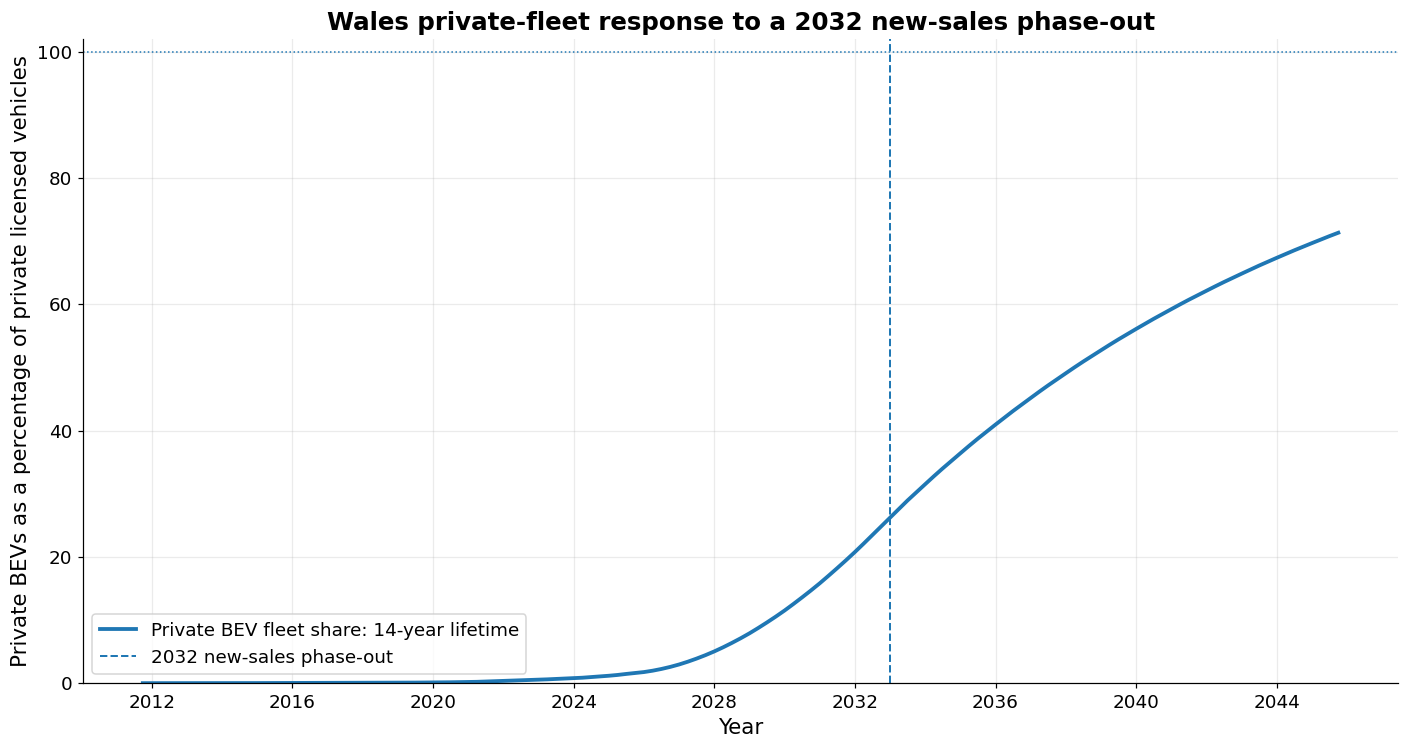

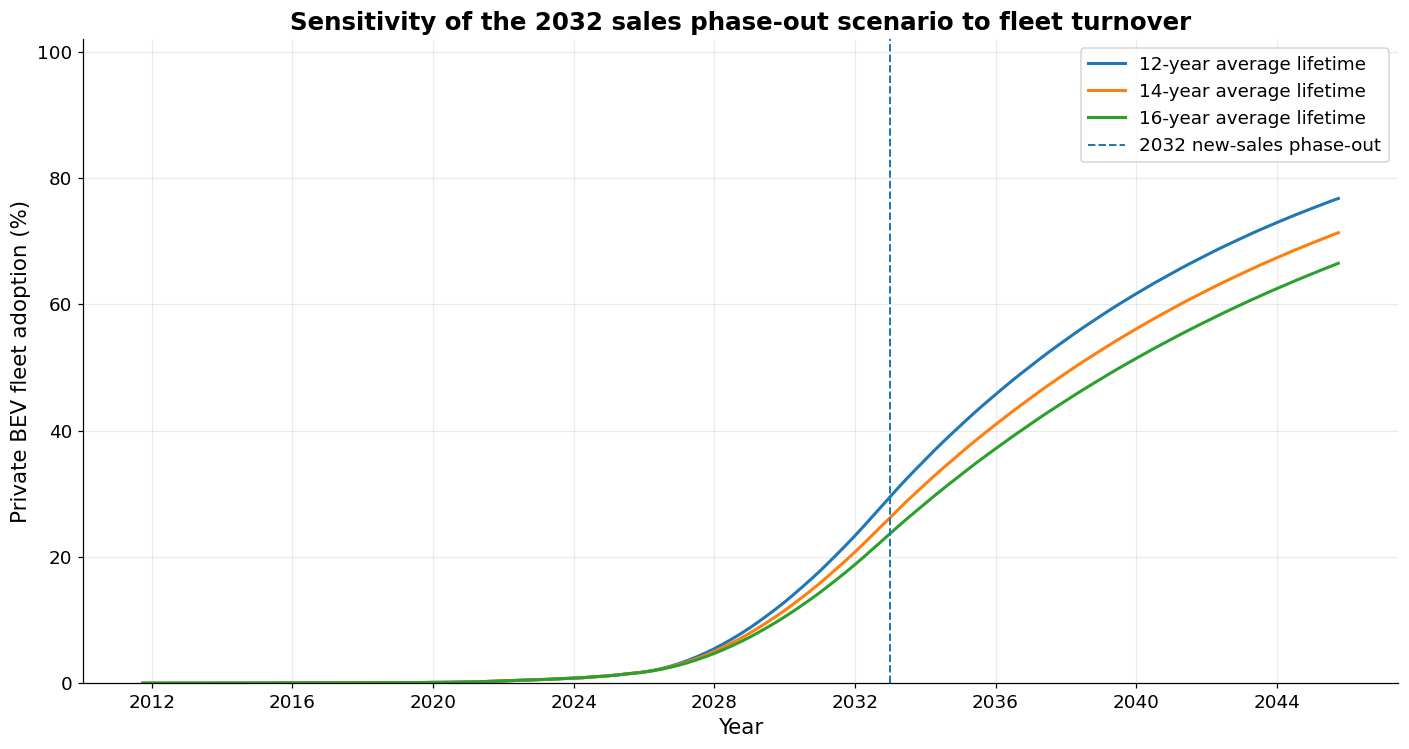

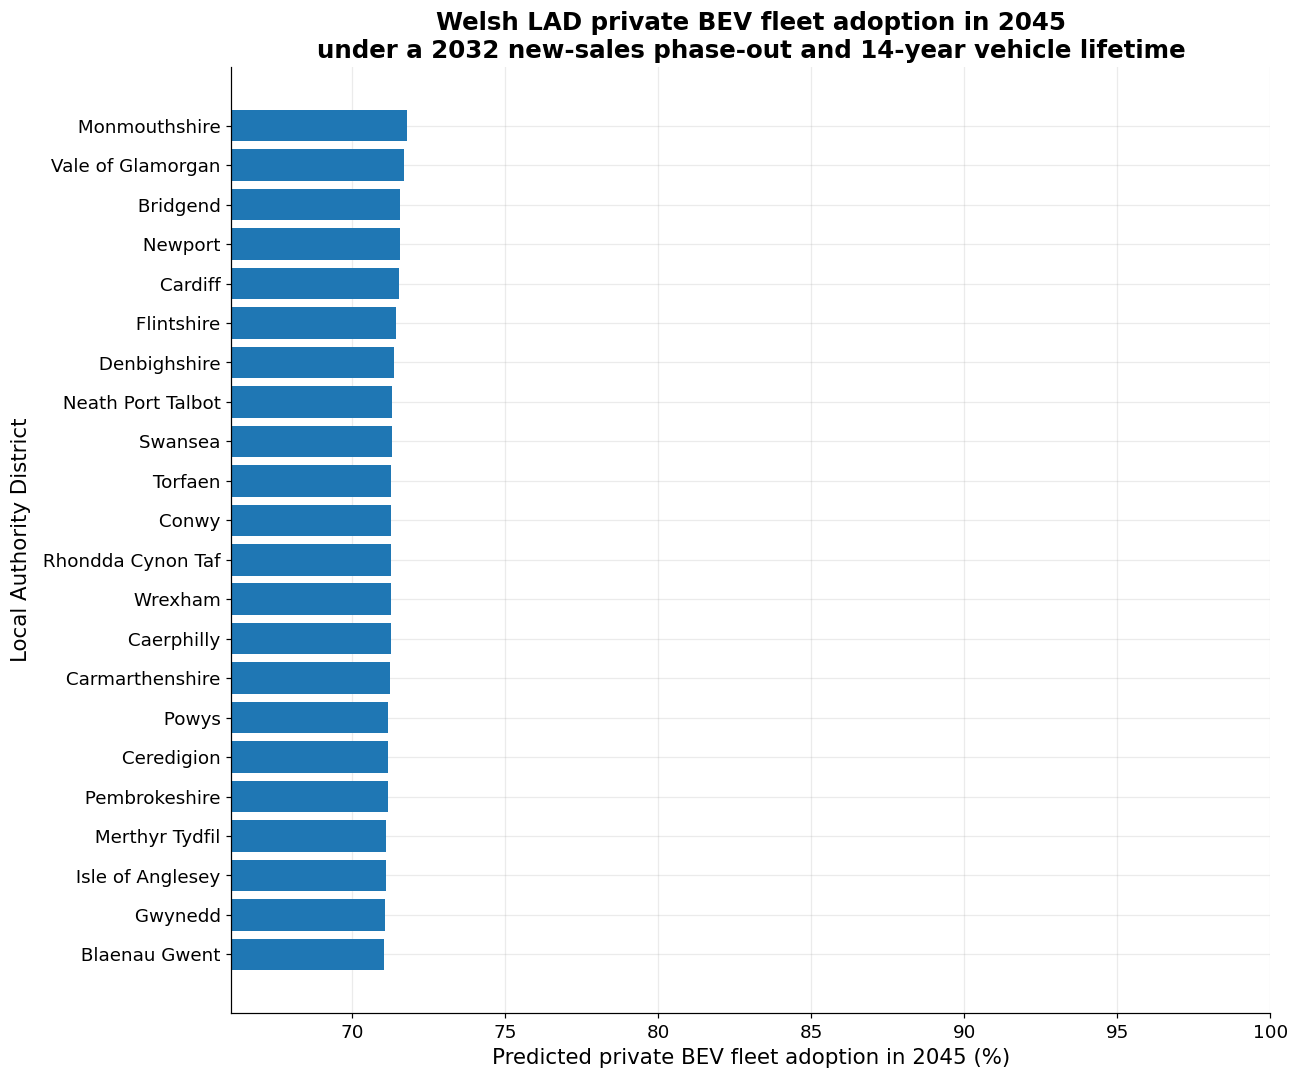


Interpretation boundary:
- The 2032 intervention applies to new sales, not directly to the existing vehicle fleet.
- The central forecast assumes a fixed private vehicle stock and a 14-year mean vehicle lifetime.
- The 2032 date is a requested scenario. It is not the current official UK policy timetable.
- Report the 12-, 14- and 16-year sensitivity results because fleet turnover materially controls the 2045 outcome.

Stage 7 policy outputs written to: cleets_out


In [ ]:
# ============================================================
# 7a. Model a 2032 new petrol/diesel sales phase-out through
#     private-fleet turnover
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

POLICY_BAN_PERIOD = pd.Period("2032Q4", freq="Q")
POLICY_FORECAST_END = pd.Period("2045Q4", freq="Q")
CENTRAL_VEHICLE_LIFETIME_YEARS = 14
LIFETIME_SENSITIVITY_YEARS = [12, 14, 16]
SALES_SHARE_ESTIMATION_QUARTERS = 8

# This is deliberately stronger than the current UK 2030/2035 pathway:
# it treats every new non-BEV private vehicle as phased out by 2032 Q4.
POLICY_SCENARIO_NAME = "2032 all-new-private-vehicles-BEV sales phase-out scenario"

# Reuse the matched-scope stock column established in Stage 6.
if "STOCK_COL" not in globals():
    if "private_cars" in panel.columns:
        STOCK_COL = "private_cars"
    elif "private_vehicles" in panel.columns:
        STOCK_COL = "private_vehicles"
    else:
        raise KeyError(
            "The observed panel must contain either 'private_cars' "
            "or 'private_vehicles'."
        )

required = {"code", "name", "period", "bev_count", "adoption_share", STOCK_COL}
missing = required.difference(panel.columns)
if missing:
    raise KeyError(f"Stage 7 requires these panel columns: {sorted(missing)}")

policy_panel = panel.copy().sort_values(["code", "period"])
if not isinstance(policy_panel["period"].dtype, pd.PeriodDtype):
    policy_panel["period"] = pd.to_datetime(
        policy_panel["period"], errors="raise"
    ).dt.to_period("Q")

last_observed_period = policy_panel["period"].max()
if POLICY_BAN_PERIOD <= last_observed_period:
    raise ValueError(
        f"The policy date {POLICY_BAN_PERIOD} must be later than the "
        f"last observed quarter {last_observed_period}."
    )

latest_lad = (
    policy_panel.sort_values("period")
    .groupby("code", as_index=False)
    .tail(1)
    [["code", "name", STOCK_COL, "bev_count", "adoption_share", "period"]]
    .rename(columns={"period": "last_observed_period"})
)

def quarterly_retirement_rate(lifetime_years):
    """Constant quarterly retirement probability implied by mean annual turnover."""
    annual_rate = 1.0 / float(lifetime_years)
    return 1.0 - (1.0 - annual_rate) ** 0.25

def infer_recent_bev_sales_share(group, retirement_rate, n_quarters=8):
    """Infer recent BEV share of replacement sales from stock-share changes.

    With fixed total stock:
        s_t = (1-r) s_(t-1) + r z_t
    where s is BEV fleet share, r is quarterly retirement/replacement rate,
    and z is the BEV share of replacement sales.
    """
    g = group.sort_values("period").tail(n_quarters + 1).copy()
    prev = g["adoption_share"].shift(1)
    inferred = (
        g["adoption_share"] - (1.0 - retirement_rate) * prev
    ) / retirement_rate
    inferred = inferred.replace([np.inf, -np.inf], np.nan).dropna().clip(0, 1)
    if inferred.empty:
        return float(g["adoption_share"].iloc[-1])
    return float(inferred.median())

def policy_sales_share(period, start_period, start_share, ban_period):
    """Linear policy ramp in new-sales share, followed by 100% BEV sales."""
    if period <= start_period:
        return float(start_share)
    if period >= ban_period:
        return 1.0
    elapsed = period.ordinal - start_period.ordinal
    total = ban_period.ordinal - start_period.ordinal
    return float(start_share + (1.0 - start_share) * elapsed / total)

def build_policy_forecast(lifetime_years):
    retirement_q = quarterly_retirement_rate(lifetime_years)
    periods = pd.period_range(
        policy_panel["period"].min(), POLICY_FORECAST_END, freq="Q"
    )
    parts = []
    parameters = []

    for code_value, observed in policy_panel.groupby("code"):
        observed = observed.sort_values("period")
        latest = observed.iloc[-1]
        capacity = float(latest[STOCK_COL])
        start_share = float(latest["adoption_share"])
        estimated_sales_share = infer_recent_bev_sales_share(
            observed, retirement_q, SALES_SHARE_ESTIMATION_QUARTERS
        )

        rows = []
        current_share = None

        for period in periods:
            observed_match = observed.loc[observed["period"] == period]

            if not observed_match.empty:
                current_share = float(observed_match["adoption_share"].iloc[0])
                sales_share = np.nan
                is_forecast = False
            elif period > last_observed_period:
                if current_share is None:
                    current_share = start_share
                sales_share = policy_sales_share(
                    period,
                    last_observed_period,
                    estimated_sales_share,
                    POLICY_BAN_PERIOD,
                )
                current_share = (
                    (1.0 - retirement_q) * current_share
                    + retirement_q * sales_share
                )
                current_share = float(np.clip(current_share, 0, 1))
                is_forecast = True
            else:
                # LAD-quarter absent from the observed panel.
                continue

            observed_bev = (
                float(observed_match["bev_count"].iloc[0])
                if not observed_match.empty else np.nan
            )
            observed_share = (
                float(observed_match["adoption_share"].iloc[0])
                if not observed_match.empty else np.nan
            )

            rows.append({
                "code": code_value,
                "name": str(latest["name"]),
                "period": period,
                "private_cars": capacity,
                "private_vehicles": capacity,
                "predicted_private_bev_count": current_share * capacity,
                "predicted_bev_count": current_share * capacity,
                "predicted_adoption_share": current_share,
                "policy_new_sales_bev_share": sales_share,
                "quarterly_retirement_rate": retirement_q,
                "assumed_vehicle_lifetime_years": lifetime_years,
                "policy_ban_period": str(POLICY_BAN_PERIOD),
                "is_forecast": is_forecast,
                "observed_bev_count": observed_bev,
                "observed_adoption_share": observed_share,
            })

        part = pd.DataFrame(rows)
        parts.append(part)

        result_2032 = part.loc[
            part["period"] == POLICY_BAN_PERIOD, "predicted_adoption_share"
        ]
        result_2045 = part.loc[
            part["period"] == POLICY_FORECAST_END, "predicted_adoption_share"
        ]

        parameters.append({
            "code": code_value,
            "name": str(latest["name"]),
            "private_cars": capacity,
            "last_observed_share": start_share,
            "estimated_recent_new_sales_bev_share": estimated_sales_share,
            "quarterly_retirement_rate": retirement_q,
            "assumed_vehicle_lifetime_years": lifetime_years,
            "fleet_share_2032": float(result_2032.iloc[0]),
            "fleet_share_2045": float(result_2045.iloc[0]),
        })

    return pd.concat(parts, ignore_index=True), pd.DataFrame(parameters)

policy_forecasts = {}
policy_parameters = {}

for lifetime in LIFETIME_SENSITIVITY_YEARS:
    fcast, params = build_policy_forecast(lifetime)
    policy_forecasts[lifetime] = fcast
    policy_parameters[lifetime] = params

policy_lad_forecast = policy_forecasts[CENTRAL_VEHICLE_LIFETIME_YEARS].copy()
policy_lad_parameters = policy_parameters[CENTRAL_VEHICLE_LIFETIME_YEARS].copy()

policy_wales_forecast = (
    policy_lad_forecast.groupby("period", as_index=False)
    .agg(
        predicted_private_bev_count=("predicted_private_bev_count", "sum"),
        private_vehicles=("private_vehicles", "sum"),
    )
)
policy_wales_forecast["predicted_adoption_share"] = (
    policy_wales_forecast["predicted_private_bev_count"]
    / policy_wales_forecast["private_vehicles"]
)

summary_2032_policy = (
    policy_lad_forecast.loc[
        policy_lad_forecast["period"] == POLICY_BAN_PERIOD,
        ["code", "name", "private_vehicles",
         "predicted_private_bev_count", "predicted_adoption_share"],
    ]
    .copy()
    .sort_values("predicted_adoption_share", ascending=False)
)
summary_2032_policy["predicted_adoption_percent"] = (
    100 * summary_2032_policy["predicted_adoption_share"]
)

summary_2045_policy = (
    policy_lad_forecast.loc[
        policy_lad_forecast["period"] == POLICY_FORECAST_END,
        ["code", "name", "private_vehicles",
         "predicted_private_bev_count", "predicted_adoption_share"],
    ]
    .copy()
    .sort_values("predicted_adoption_share", ascending=False)
)
summary_2045_policy["predicted_adoption_percent"] = (
    100 * summary_2045_policy["predicted_adoption_share"]
)

print("\n2032 POLICY SCENARIO")
print("New non-BEV private sales reach zero at:", POLICY_BAN_PERIOD)
print(
    "Central average vehicle lifetime:",
    CENTRAL_VEHICLE_LIFETIME_YEARS,
    "years"
)
print(
    "Important: the new-sales share reaches 100% BEV in 2032; "
    "the fleet share does not."
)

display(
    summary_2032_policy[
        ["code", "name", "predicted_adoption_percent"]
    ].round(2)
)

# Wales sensitivity summary.
sensitivity_rows = []
for lifetime, fcast in policy_forecasts.items():
    wales = (
        fcast.groupby("period", as_index=False)
        .agg(
            bev=("predicted_private_bev_count", "sum"),
            stock=("private_vehicles", "sum"),
        )
    )
    wales["share"] = wales["bev"] / wales["stock"]
    for milestone in [POLICY_BAN_PERIOD, POLICY_FORECAST_END]:
        value = float(
            wales.loc[wales["period"] == milestone, "share"].iloc[0]
        )
        sensitivity_rows.append({
            "assumed_vehicle_lifetime_years": lifetime,
            "period": str(milestone),
            "predicted_wales_private_bev_fleet_percent": 100 * value,
        })

policy_sensitivity = pd.DataFrame(sensitivity_rows)
print("\nWALES FLEET-TURNOVER SENSITIVITY")
display(policy_sensitivity.round(2))

# Plot 1: central Wales pathway.
plt.figure(figsize=(13, 7))
plt.plot(
    policy_wales_forecast["period"].dt.to_timestamp(),
    100 * policy_wales_forecast["predicted_adoption_share"],
    linewidth=2.5,
    label="Private BEV fleet share: 14-year lifetime",
)
plt.axvline(
    POLICY_BAN_PERIOD.to_timestamp(how="end"),
    linestyle="--",
    linewidth=1.3,
    label="2032 new-sales phase-out",
)
plt.axhline(100, linestyle=":", linewidth=1.0)
plt.xlabel("Year")
plt.ylabel("Private BEVs as a percentage of private licensed vehicles")
plt.title(
    "Wales private-fleet response to a 2032 new-sales phase-out"
)
plt.ylim(0, 102)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(
    WORK / "wales_2032_sales_ban_fleet_turnover_scenario.png",
    dpi=250,
    bbox_inches="tight",
)
plt.show()

# Plot 2: lifetime sensitivity.
plt.figure(figsize=(13, 7))
for lifetime, fcast in policy_forecasts.items():
    wales = (
        fcast.groupby("period", as_index=False)
        .agg(
            bev=("predicted_private_bev_count", "sum"),
            stock=("private_vehicles", "sum"),
        )
    )
    wales["share"] = 100 * wales["bev"] / wales["stock"]
    plt.plot(
        wales["period"].dt.to_timestamp(),
        wales["share"],
        linewidth=2,
        label=f"{lifetime}-year average lifetime",
    )
plt.axvline(
    POLICY_BAN_PERIOD.to_timestamp(how="end"),
    linestyle="--",
    linewidth=1.3,
    label="2032 new-sales phase-out",
)
plt.xlabel("Year")
plt.ylabel("Private BEV fleet adoption (%)")
plt.title("Sensitivity of the 2032 sales phase-out scenario to fleet turnover")
plt.ylim(0, 102)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(
    WORK / "wales_2032_sales_ban_lifetime_sensitivity.png",
    dpi=250,
    bbox_inches="tight",
)
plt.show()

# Plot 3: LAD outcomes in 2045 under the central assumption.
plot_policy_2045 = summary_2045_policy.sort_values(
    "predicted_adoption_percent"
)
plt.figure(figsize=(12, 10))
plt.barh(
    plot_policy_2045["name"],
    plot_policy_2045["predicted_adoption_percent"],
)
plt.xlabel("Predicted private BEV fleet adoption in 2045 (%)")
plt.ylabel("Local Authority District")
plt.title(
    "Welsh LAD private BEV fleet adoption in 2045\n"
    "under a 2032 new-sales phase-out and 14-year vehicle lifetime"
)
plt.xlim(
    max(0, plot_policy_2045["predicted_adoption_percent"].min() - 5),
    100,
)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(
    WORK / "welsh_lad_2032_sales_ban_fleet_adoption_2045.png",
    dpi=250,
    bbox_inches="tight",
)
plt.show()

# Export policy scenario outputs.
export_policy = policy_lad_forecast.copy()
export_policy["period"] = export_policy["period"].astype(str)
export_policy.to_csv(
    WORK / "welsh_lad_2032_sales_ban_fleet_turnover_forecast.csv",
    index=False,
)

export_policy_wales = policy_wales_forecast.copy()
export_policy_wales["period"] = export_policy_wales["period"].astype(str)
export_policy_wales.to_csv(
    WORK / "wales_2032_sales_ban_fleet_turnover_forecast.csv",
    index=False,
)

summary_2032_policy.to_csv(
    WORK / "welsh_lad_2032_sales_ban_summary_2032.csv",
    index=False,
)
summary_2045_policy.to_csv(
    WORK / "welsh_lad_2032_sales_ban_summary_2045.csv",
    index=False,
)
policy_lad_parameters.to_csv(
    WORK / "welsh_lad_2032_sales_ban_turnover_parameters.csv",
    index=False,
)
policy_sensitivity.to_csv(
    WORK / "wales_2032_sales_ban_lifetime_sensitivity.csv",
    index=False,
)

print("\nInterpretation boundary:")
print(
    "- The 2032 intervention applies to new sales, not directly to the "
    "existing vehicle fleet."
)
print(
    "- The central forecast assumes a fixed private vehicle stock and a "
    "14-year mean vehicle lifetime."
)
print(
    "- The 2032 date is a requested scenario. It is not the current "
    "official UK policy timetable."
)
print(
    "- Report the 12-, 14- and 16-year sensitivity results because "
    "fleet turnover materially controls the 2045 outcome."
)
print("\nStage 7 policy outputs written to:", WORK)


## Stage 8 — Age-structured turnover and the two research questions


Survival calibration
  median 12y -> mean 11.9y | implied annual replacement 8.4% | survival at 13y 37%
  median 14y -> mean 13.9y | implied annual replacement 7.2% | survival at 13y 61%
  median 16y -> mean 15.8y | implied annual replacement 6.3% | survival at 13y 76%
Compare Stage 7: a constant hazard of 1/14 per year gives survival at 13y of 38%, i.e. it scraps far more of the last pre-ban cohorts than an age-structured model does.

WALES CEILING under a 2032Q4 new-sales ban
  BEV share of the private parc at 2045Q4: 96.0%
  Residual non-BEV vehicles: 73,959
  This is a CEILING, not a forecast: it assumes every new private vehicle registered
  from the ban onward is a BEV and that no LAD lags in purchasing. Observed
  LAD differences can only push the outcome below it.

TABLE 10  Fleet-turnover ceiling at 2045Q4 under a 2032Q4 phase-out


,median_scrappage_years,implied_annual_replacement_pct,wales_bev_share_2045_pct,shortfall_from_100_pp,residual_non_bev_cars
0,12.0,8.42,98.83,1.17,21726.83
1,14.0,7.21,96.00,4.00,73959.00
2,16.0,6.31,91.50,8.50,157308.53


Moving the ban date by two years shifts the 2045 residual by a few tenths of a
point; moving median scrappage age by two years shifts it by several points. The
scrappage curve, not the ban date, controls the 2045 outcome.


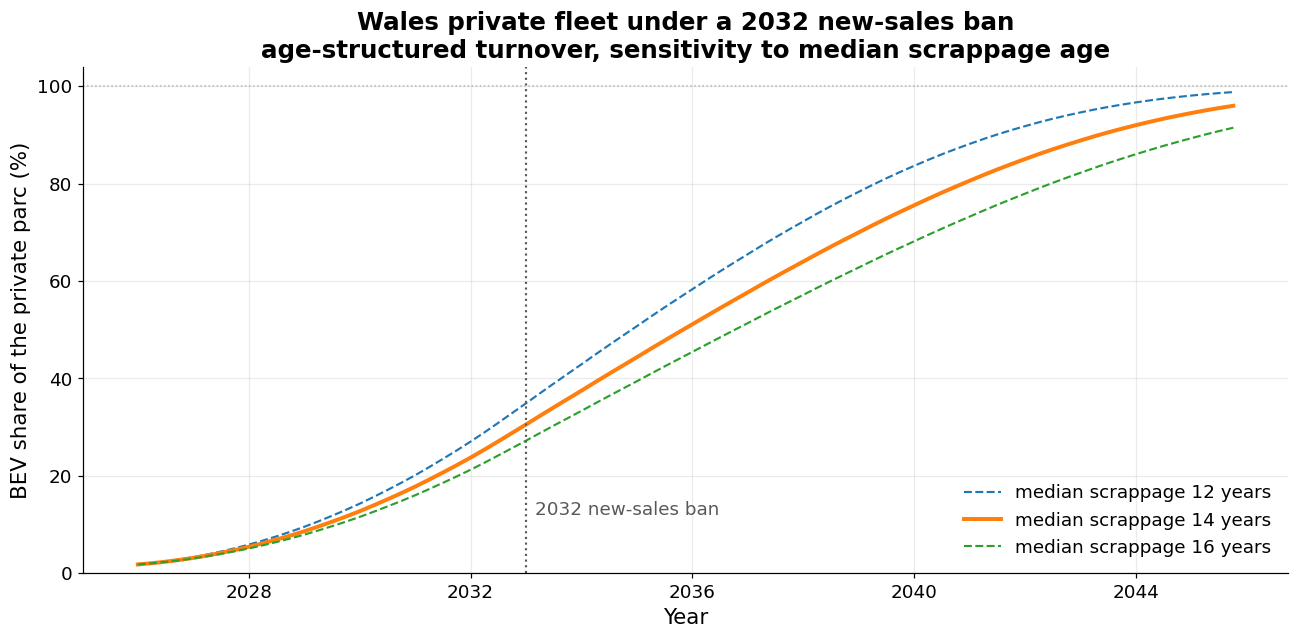

In [ ]:
# ============================================================
# 8a. Age-structured (vintage) fleet turnover
#
# Stage 7 retires vehicles at a constant quarterly hazard, which implies an
# exponential age distribution: a car is as likely to be scrapped in its second
# year as in its fifteenth. Real scrappage hazard rises steeply with age, so a
# constant hazard retires young vehicles too fast and keeps old ones too long.
# The two assumptions disagree most in exactly the period this study is about.
#
# With a 14-year MEAN lifetime, the constant-hazard model implies a MEDIAN
# lifetime near nine years. This cell replaces it with a Weibull survival
# function calibrated on median scrappage age, and carries the whole age
# structure forward so that the last pre-ban cohorts are tracked explicitly.
# ============================================================

from math import gamma

# Median age at scrappage, in years. GB cars are around 14; Welsh cars are
# plausibly older, because lower incomes and rural dependence both lengthen
# holding periods and Wales is a net importer of used vehicles from English
# fleet returns. Fit this from DfT VEH0211 (licensed cars by age) if you can;
# it is the single most consequential number in the 2045 result.
MEDIAN_SCRAPPAGE_AGE_YEARS = 14.0
SCRAPPAGE_SENSITIVITY_YEARS = [12.0, 14.0, 16.0]
WEIBULL_SHAPE = 4.5           # steepness of the hazard; 4-5 is typical for cars
MAX_VEHICLE_AGE_YEARS = 40

# Total private vehicle stock is held fixed, as in Stage 7. Set a non-zero value to
# test a growing or shrinking parc.
ANNUAL_STOCK_GROWTH = 0.0


def weibull_scale(median_years, shape):
    """Scale lambda such that S(median) = 0.5 exactly."""
    return median_years / (np.log(2.0) ** (1.0 / shape))


def survival(age_years, median_years, shape=WEIBULL_SHAPE):
    lam = weibull_scale(median_years, shape)
    a = np.maximum(np.asarray(age_years, dtype=float), 0.0)
    return np.exp(-((a / lam) ** shape))


def mean_lifetime(median_years, shape=WEIBULL_SHAPE):
    return weibull_scale(median_years, shape) * gamma(1.0 + 1.0 / shape)


def quarterly_retention(median_years, shape=WEIBULL_SHAPE):
    """P(survive one more quarter | alive at age a), for each quarterly age."""
    ages = np.arange(0, MAX_VEHICLE_AGE_YEARS * 4 + 1) / 4.0
    s = survival(ages, median_years, shape)
    with np.errstate(divide="ignore", invalid="ignore"):
        r = np.where(s[:-1] > 1e-12, s[1:] / s[:-1], 0.0)
    return np.clip(r, 0.0, 1.0)


print("Survival calibration")
for m in SCRAPPAGE_SENSITIVITY_YEARS:
    surv13 = float(survival(13.0, m))
    print(f"  median {m:.0f}y -> mean {mean_lifetime(m):.1f}y | "
          f"implied annual replacement {100/mean_lifetime(m):.1f}% | "
          f"survival at 13y {100*surv13:.0f}%")
print("Compare Stage 7: a constant hazard of 1/14 per year gives survival at "
      f"13y of {100*(1-1/14.0)**13:.0f}%, i.e. it scraps far more of the last "
      "pre-ban cohorts than an age-structured model does.")


# ---------------------------------------------------------------- BEV vintages
# BEV age structure is not assumed: it is read off the observed quarterly stock
# increments, which is exactly what the panel records.
def observed_bev_vintages(group, n_quarters):
    """Net BEV additions per quarter, most recent first, padded to n_quarters."""
    g = group.sort_values("period")
    adds = g["bev_count"].diff().fillna(g["bev_count"].iloc[0]).clip(lower=0.0)
    v = adds.to_numpy(float)[::-1][:n_quarters]
    out = np.zeros(n_quarters)
    out[:len(v)] = v
    total = g["bev_count"].iloc[-1]
    if out.sum() <= 0:
        out[0] = total
    else:
        out *= total / out.sum()          # rescale so vintages sum to the stock
    return out


def stationary_ice_vintages(total, median_years):
    """Age distribution of a fleet in replacement equilibrium: weight ∝ S(a)."""
    n = MAX_VEHICLE_AGE_YEARS * 4
    ages = np.arange(n) / 4.0
    w = survival(ages, median_years)
    return total * w / w.sum()


def policy_bev_sales_share(period, start_period, start_share, ban_period):
    """Linear ramp in the BEV share of new registrations, 100% from the ban."""
    if period <= start_period:
        return float(start_share)
    if period >= ban_period:
        return 1.0
    elapsed = period.ordinal - start_period.ordinal
    total = ban_period.ordinal - start_period.ordinal
    return float(start_share + (1.0 - start_share) * elapsed / total)


def run_vintage_model(median_years):
    """Cohort-survival projection to POLICY_FORECAST_END, per LAD."""
    retention = quarterly_retention(median_years)
    n_age = len(retention)
    last_obs = panel["period"].max()
    horizon = pd.period_range(last_obs + 1, POLICY_FORECAST_END, freq="Q")
    q_growth = (1.0 + ANNUAL_STOCK_GROWTH) ** 0.25

    out_rows, param_rows = [], []
    for code_value, group in panel.groupby("code"):
        group = group.sort_values("period")
        latest = group.iloc[-1]
        stock = float(latest[STOCK_COL])
        bev_now = float(latest["bev_count"])

        bev = observed_bev_vintages(group, n_age)
        ice = stationary_ice_vintages(max(stock - bev_now, 0.0), median_years)

        # Recent BEV share of new registrations, from the observed increments.
        recent = group.tail(5)
        adds = recent["bev_count"].diff().dropna().clip(lower=0.0).sum()
        replacement = stock * (1.0 - (1.0 - 1.0 / mean_lifetime(median_years)) ** 1.0)
        sales_share_now = float(np.clip(adds / max(replacement, 1e-9), 0.0, 1.0))

        for period in horizon:
            surv_ice = ice * retention
            surv_bev = bev * retention
            scrapped = (ice.sum() - surv_ice.sum()) + (bev.sum() - surv_bev.sum())

            target_stock = (surv_ice.sum() + surv_bev.sum() + scrapped) * q_growth
            new_reg = max(target_stock - surv_ice.sum() - surv_bev.sum(), 0.0)
            z = policy_bev_sales_share(period, last_obs, sales_share_now,
                                       POLICY_BAN_PERIOD)

            ice = np.concatenate([[new_reg * (1.0 - z)], surv_ice[:-1]])
            bev = np.concatenate([[new_reg * z], surv_bev[:-1]])

            total = ice.sum() + bev.sum()
            out_rows.append({
                "code": code_value, "name": str(latest["name"]), "period": period,
                "bev_stock": bev.sum(), "ice_stock": ice.sum(), "total_stock": total,
                "bev_share": bev.sum() / total if total > 0 else np.nan,
                "new_registrations": new_reg, "bev_sales_share": z,
                "median_scrappage_years": median_years})

        end = out_rows[-1]
        param_rows.append({
            "code": code_value, "name": str(latest["name"]),
            "private_vehicles": stock,
            "last_observed_share": bev_now / stock if stock else np.nan,
            "recent_bev_sales_share": sales_share_now,
            "median_scrappage_years": median_years,
            "bev_share_2045": end["bev_share"],
            "residual_ice_2045": end["ice_stock"]})

    return pd.DataFrame(out_rows), pd.DataFrame(param_rows)


vintage_forecasts, vintage_parameters = {}, {}
for m in SCRAPPAGE_SENSITIVITY_YEARS:
    f, p = run_vintage_model(m)
    vintage_forecasts[m], vintage_parameters[m] = f, p

vintage_lad = vintage_forecasts[MEDIAN_SCRAPPAGE_AGE_YEARS]
vintage_params = vintage_parameters[MEDIAN_SCRAPPAGE_AGE_YEARS]

vintage_wales = (vintage_lad.groupby("period", as_index=False)
                 .agg(bev_stock=("bev_stock", "sum"),
                      ice_stock=("ice_stock", "sum"),
                      total_stock=("total_stock", "sum")))
vintage_wales["bev_share"] = vintage_wales.bev_stock / vintage_wales.total_stock

TURNOVER_CEILING_2045 = float(
    vintage_wales.loc[vintage_wales.period == POLICY_FORECAST_END, "bev_share"].iloc[0])

print(f"\nWALES CEILING under a {POLICY_BAN_PERIOD} new-sales ban")
print(f"  BEV share of the private parc at {POLICY_FORECAST_END}: "
      f"{100*TURNOVER_CEILING_2045:.1f}%")
print(f"  Residual non-BEV vehicles: "
      f"{vintage_wales.loc[vintage_wales.period == POLICY_FORECAST_END, 'ice_stock'].iloc[0]:,.0f}")
print("  This is a CEILING, not a forecast: it assumes every new private vehicle "
      "registered\n  from the ban onward is a BEV and that no LAD lags in "
      "purchasing. Observed\n  LAD differences can only push the outcome below it.")

# Table 10 of the paper: one row per survival assumption, with the implied annual
# replacement rate that the survival curve generates.
sens = []
for m, f in sorted(vintage_forecasts.items()):
    w = f.groupby("period", as_index=False).agg(bev=("bev_stock", "sum"),
                                                tot=("total_stock", "sum"),
                                                ice=("ice_stock", "sum"))
    row = w.loc[w.period == POLICY_FORECAST_END].iloc[0]
    v = float(row.bev / row.tot)
    sens.append({"median_scrappage_years": m,
                 "implied_annual_replacement_pct": 100.0 / mean_lifetime(m),
                 "wales_bev_share_2045_pct": 100 * v,
                 "shortfall_from_100_pp": 100 * (1 - v),
                 "residual_non_bev_cars": float(row.ice)})
scrappage_sensitivity = pd.DataFrame(sens)
print("\nTABLE 10  Fleet-turnover ceiling at 2045Q4 under a 2032Q4 phase-out")
display(scrappage_sensitivity.round(2))
scrappage_sensitivity.to_csv(WORK / "table10_turnover_ceiling.csv", index=False)
print("Moving the ban date by two years shifts the 2045 residual by a few tenths "
      "of a\npoint; moving median scrappage age by two years shifts it by several "
      "points. The\nscrappage curve, not the ban date, controls the 2045 outcome.")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
for m, f in vintage_forecasts.items():
    w = f.groupby("period", as_index=False).agg(bev=("bev_stock", "sum"),
                                                tot=("total_stock", "sum"))
    style = "-" if m == MEDIAN_SCRAPPAGE_AGE_YEARS else "--"
    lw = 2.6 if m == MEDIAN_SCRAPPAGE_AGE_YEARS else 1.4
    ax.plot(w.period.dt.to_timestamp(), 100 * w.bev / w.tot, style, linewidth=lw,
            label=f"median scrappage {m:.0f} years")
ax.axvline(POLICY_BAN_PERIOD.to_timestamp(how="end"), color="0.35",
           linestyle=":", linewidth=1.4)
ax.annotate(f"{POLICY_BAN_PERIOD.year} new-sales ban",
            xy=(POLICY_BAN_PERIOD.to_timestamp(how="end"), 12),
            xytext=(6, 0), textcoords="offset points", fontsize=12, color="0.35")
ax.axhline(100, color="0.7", linestyle=":", linewidth=1.0)
ax.set_ylim(0, 104)
ax.set_xlabel("Year")
ax.set_ylabel("BEV share of the private parc (%)")
ax.set_title("Wales private fleet under a 2032 new-sales ban\n"
             "age-structured turnover, sensitivity to median scrappage age")
ax.grid(alpha=0.25)
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
fig.savefig(WORK / "wales_vintage_turnover_sensitivity.png", dpi=250,
            bbox_inches="tight")
plt.show()


Q1  WHICH WELSH LADs DIFFUSE MOST SLOWLY?
Wales passes 80% BEV share in 2041; 90% in 2043.

Slowest 5 LADs:


,diffusion_rank,name,last_observed_pct,year_80pc,lag_years_at_80pc,share_2045_pct
0,1,Isle of Anglesey,1.19,2040.98,0.11,95.86
1,2,Gwynedd,1.11,2040.98,0.11,95.86
2,3,Ceredigion,1.30,2040.98,0.11,95.87
3,4,Powys,1.30,2040.96,0.09,95.89
4,5,Pembrokeshire,1.36,2040.94,0.07,95.91



Fastest 5:


,diffusion_rank,name,last_observed_pct,year_80pc,lag_years_at_80pc,share_2045_pct
17,18,Cardiff,2.00,2040.79,-0.08,96.10
18,19,Newport,2.03,2040.78,-0.09,96.11
19,20,Monmouthshire,2.44,2040.75,-0.12,96.14
20,21,Vale of Glamorgan,2.40,2040.75,-0.12,96.14
21,22,Bridgend,2.09,2040.75,-0.12,96.15



LAD spread at 2045: 95.9% to 96.2% (range 0.3 pp).
>>> The spread is under two percentage points. Under a binding sales ban the
>>> LADs converge, so the 2045 SHARE cannot discriminate between them. Report
>>> the crossing years and the lag instead, which is where the difference lives.


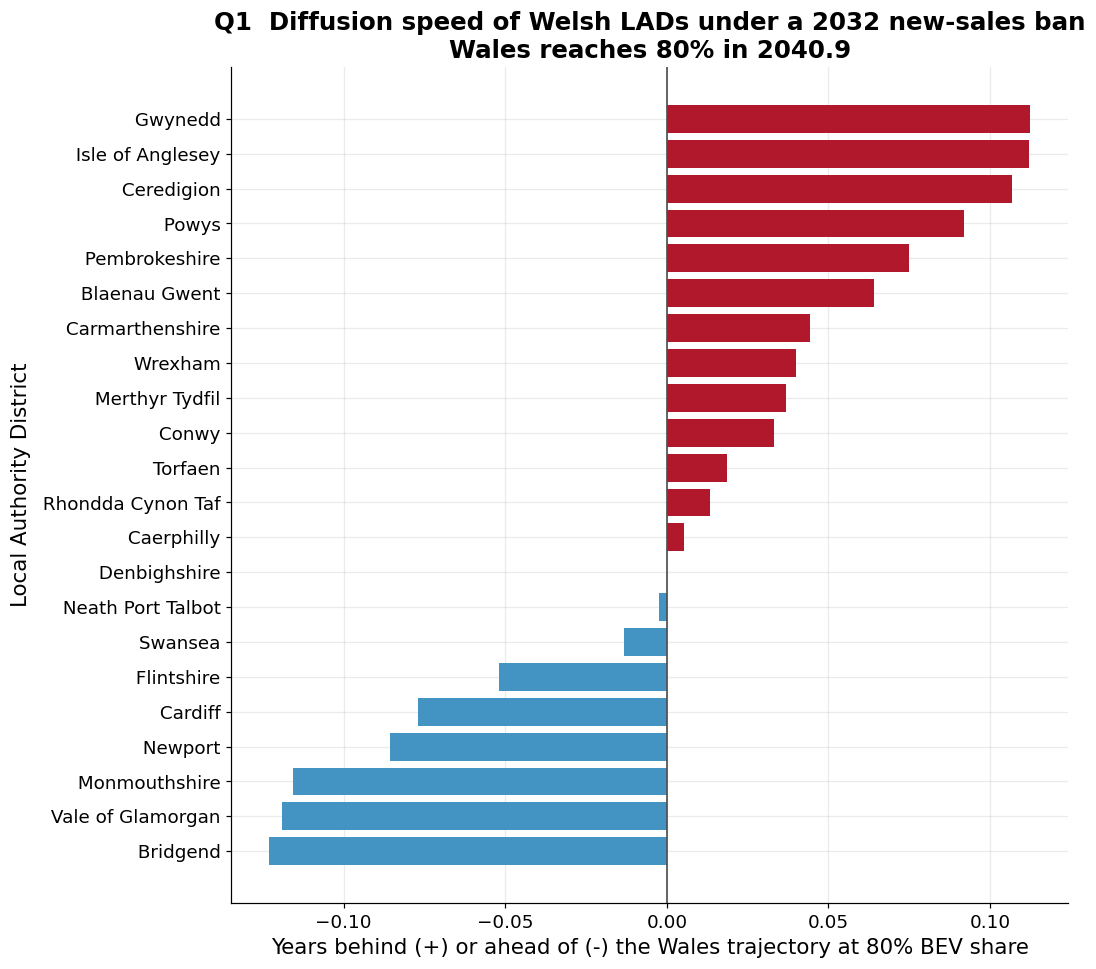

In [ ]:
# ============================================================
# 8b. QUESTION 1 - which LADs diffuse most slowly?
# ============================================================
# Diffusion speed is reported three ways, because they can disagree and each
# answers a different planning question:
#   lag_years      how far behind the Wales trajectory an LAD sits (headline)
#   year_80pc      when the LAD passes 80% BEV share
#   share_2045     where it ends up
# ============================================================

THRESHOLDS = [0.50, 0.80, 0.90]


def crossing_year(frame, threshold, share_col="bev_share"):
    """Fractional year at which the share reaches the threshold; NaN if never.

    Interpolated between quarters. Snapping to the calendar year would collapse
    the LAD differences to whole-year steps and make the lag column unreadable,
    which is precisely the quantity Q1 turns on.
    """
    f = frame.sort_values("period").reset_index(drop=True)
    s = f[share_col].to_numpy(float)
    hit = np.where(s >= threshold)[0]
    if len(hit) == 0:
        return np.nan
    i = int(hit[0])
    yr = f["period"].iloc[i].year + (f["period"].iloc[i].quarter - 1) / 4.0
    if i == 0 or s[i] == s[i - 1]:
        return float(yr)
    frac = (threshold - s[i - 1]) / (s[i] - s[i - 1])
    return float(yr - 0.25 * (1.0 - frac))


wales_crossings = {t: crossing_year(vintage_wales, t) for t in THRESHOLDS}

diffusion_rows = []
for code_value, g in vintage_lad.groupby("code"):
    g = g.sort_values("period")
    row = {"code": code_value, "name": g["name"].iloc[0],
           "share_2045_pct": 100 * g["bev_share"].iloc[-1],
           "residual_ice_2045": g["ice_stock"].iloc[-1],
           "private_vehicles": g["total_stock"].iloc[-1]}
    for t in THRESHOLDS:
        row[f"year_{int(100*t)}pc"] = crossing_year(g, t)
    row["lag_years_at_80pc"] = row["year_80pc"] - wales_crossings[0.80]
    diffusion_rows.append(row)

diffusion_speed = pd.DataFrame(diffusion_rows)
diffusion_speed = diffusion_speed.merge(
    vintage_params[["code", "last_observed_share", "recent_bev_sales_share"]],
    on="code", how="left")
diffusion_speed["last_observed_pct"] = 100 * diffusion_speed.last_observed_share
diffusion_speed = diffusion_speed.sort_values("share_2045_pct").reset_index(drop=True)
diffusion_speed["diffusion_rank"] = np.arange(1, len(diffusion_speed) + 1)

SLOWEST_N = 5
slowest = diffusion_speed.head(SLOWEST_N)

print("\n" + "=" * 66)
print("Q1  WHICH WELSH LADs DIFFUSE MOST SLOWLY?")
print("=" * 66)
print(f"Wales passes 80% BEV share in {wales_crossings[0.80]:.0f}; "
      f"90% in {wales_crossings[0.90]:.0f}.")
print(f"\nSlowest {SLOWEST_N} LADs:")
display(slowest[["diffusion_rank", "name", "last_observed_pct", "year_80pc",
                 "lag_years_at_80pc", "share_2045_pct"]].round(2))
print(f"\nFastest {SLOWEST_N}:")
display(diffusion_speed.tail(SLOWEST_N)[
    ["diffusion_rank", "name", "last_observed_pct", "year_80pc",
     "lag_years_at_80pc", "share_2045_pct"]].round(2))

spread = diffusion_speed.share_2045_pct
print(f"\nLAD spread at 2045: {spread.min():.1f}% to {spread.max():.1f}% "
      f"(range {spread.max()-spread.min():.1f} pp).")
if spread.max() - spread.min() < 2.0:
    print(">>> The spread is under two percentage points. Under a binding sales "
          "ban the\n>>> LADs converge, so the 2045 SHARE cannot discriminate "
          "between them. Report\n>>> the crossing years and the lag instead, "
          "which is where the difference lives.")

order = diffusion_speed.sort_values("lag_years_at_80pc")
fig, ax = plt.subplots(figsize=(10, 9))
colours = ["#b2182b" if v > 0 else "#4393c3" for v in order.lag_years_at_80pc]
ax.barh(order.name, order.lag_years_at_80pc, color=colours)
ax.axvline(0, color="0.3", linewidth=1.1)
ax.set_xlabel("Years behind (+) or ahead of (-) the Wales trajectory at 80% BEV share")
ax.set_ylabel("Local Authority District")
ax.set_title("Q1  Diffusion speed of Welsh LADs under a 2032 new-sales ban\n"
             f"Wales reaches 80% in {wales_crossings[0.80]:.1f}")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(WORK / "welsh_lad_diffusion_lag.png", dpi=250, bbox_inches="tight")
plt.show()


Q2  WHERE MAY CHARGING PROVISION BE THE PRINCIPAL CONSTRAINT?
Benchmark: 20 BEVs per public device | charger scenario 'slow' (5% a year for 20 years)

LADs where charging is plausibly the binding constraint (slow diffusion AND provision short of demand):


,name,diffusion_rank,lag_years_at_80pc,evs_per_charge_point_2045,provision_adequacy,charger_shortfall_2045
5,Wrexham,8,0.04,250.39,0.08,3606.67
21,Merthyr Tydfil,10,0.04,243.53,0.08,1334.44
8,Carmarthenshire,7,0.04,211.59,0.09,5464.70
17,Torfaen,11,0.02,206.38,0.10,2349.04
2,Conwy,9,0.03,204.19,0.10,3103.27
20,Powys,4,0.09,201.64,0.10,4241.04
0,Isle of Anglesey,1,0.11,195.84,0.10,2052.80
16,Blaenau Gwent,6,0.06,159.24,0.13,1644.09
6,Ceredigion,3,0.11,127.75,0.16,2001.23
7,Pembrokeshire,5,0.07,124.92,0.16,3479.93



LADs that are slow DESPITE adequate provision (look to income, deprivation and fleet turnover, not chargers):


'  none under these assumptions'


Full classification:


,name,share_2045_pct,lag_years_at_80pc,evs_per_charge_point_2045,provision_adequacy,constraint_class
10,Neath Port Talbot,96.01,-0.00,669.85,0.03,provision will bind later
15,Caerphilly,96.00,0.01,449.81,0.04,provision will bind later
4,Flintshire,96.07,-0.05,355.40,0.06,provision will bind later
13,Cardiff,96.10,-0.08,261.32,0.08,provision will bind later
5,Wrexham,95.95,0.04,250.39,0.08,charging plausibly binding
21,Merthyr Tydfil,95.96,0.04,243.53,0.08,charging plausibly binding
3,Denbighshire,96.00,-0.00,230.57,0.09,provision will bind later
9,Swansea,96.02,-0.01,227.30,0.09,provision will bind later
11,Bridgend,96.15,-0.12,218.49,0.09,provision will bind later
8,Carmarthenshire,95.95,0.04,211.59,0.09,charging plausibly binding



Sensitivity of the flagged set to the charger growth scenario:
      frozen ( 0%/yr): 22 of 22 LADs below the benchmark
        slow ( 5%/yr): 22 of 22 LADs below the benchmark
   sustained (12%/yr): 22 of 22 LADs below the benchmark


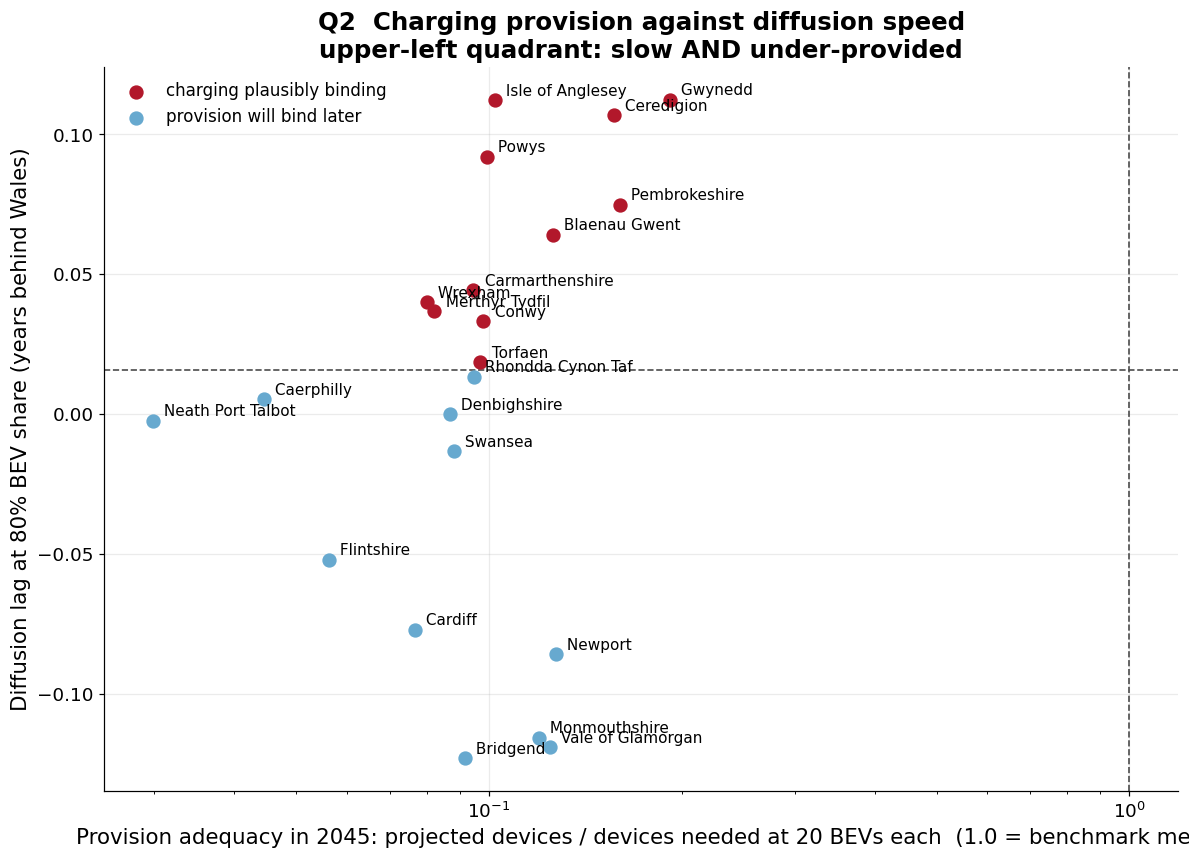


Stage 8 outputs written to: cleets_out


In [ ]:
# ============================================================
# 8c. QUESTION 2 - where may charging provision be the binding constraint?
# ============================================================
# IDENTIFICATION WARNING. Charge points are installed where EV uptake already
# is, so a cross-sectional association between provision and adoption cannot
# establish that provision CAUSES adoption. Nothing below is a causal estimate.
#
# What this cell does instead is a sufficiency accounting exercise: it projects
# each LAD's BEV stock to 2045, projects charge points under explicit
# scenarios, and asks where provision falls furthest short of projected demand.
# That is answerable from the data and is the question a planner actually has.
# ============================================================

# Vehicles per public charging device that the LAD would need to sustain. The
# DfT publishes no statutory ratio; values in the 10-30 range appear in industry
# planning documents. Treated here as an explicit, adjustable benchmark.
TARGET_EVS_PER_CHARGE_POINT = 20.0

# Growth in public charge points, compound annual, from the observed count.
CHARGER_GROWTH_SCENARIOS = {"frozen": 0.00, "slow": 0.05, "sustained": 0.12}
CENTRAL_CHARGER_SCENARIO = "slow"

if "charge_points" not in df.columns:
    raise KeyError("Stage 4a frame `df` has no 'charge_points' column; "
                   "Q2 cannot be answered without observed charge point counts.")

charger_now = (df[["code", "charge_points"]].dropna()
               .assign(code=lambda d: d.code.astype(str)))
years_ahead = POLICY_FORECAST_END.year - pd.Period(TARGET_PERIOD, freq="Q").year

bev_2045 = (vintage_lad.loc[vintage_lad.period == POLICY_FORECAST_END,
                            ["code", "name", "bev_stock", "total_stock"]]
            .rename(columns={"bev_stock": "bev_2045"}))

charging = bev_2045.merge(charger_now, on="code", how="left")
if charging.charge_points.isna().any():
    missing = charging.loc[charging.charge_points.isna(), "name"].tolist()
    print(f"WARNING: no charge point count for {missing}; excluded from Q2.")
    charging = charging.dropna(subset=["charge_points"])

for label, g in CHARGER_GROWTH_SCENARIOS.items():
    projected = charging.charge_points * (1.0 + g) ** years_ahead
    charging[f"chargers_2045_{label}"] = projected
    charging[f"evs_per_cp_{label}"] = charging.bev_2045 / projected.replace(0, np.nan)

central_cp = charging[f"chargers_2045_{CENTRAL_CHARGER_SCENARIO}"]
charging["evs_per_charge_point_2045"] = charging[f"evs_per_cp_{CENTRAL_CHARGER_SCENARIO}"]
charging["chargers_required_2045"] = charging.bev_2045 / TARGET_EVS_PER_CHARGE_POINT
charging["charger_shortfall_2045"] = (charging.chargers_required_2045 - central_cp).clip(lower=0)
charging["provision_adequacy"] = central_cp / charging.chargers_required_2045

charging = charging.merge(
    diffusion_speed[["code", "lag_years_at_80pc", "share_2045_pct", "diffusion_rank"]],
    on="code", how="left")

# Two-axis classification. "Charging-constrained" means slow AND short of
# provision; "adoption-constrained" means slow DESPITE adequate provision, so
# the binding factor is something else (income, deprivation, vehicle turnover).
lag_median = charging.lag_years_at_80pc.median()
charging["is_slow"] = charging.lag_years_at_80pc > lag_median
charging["is_underprovided"] = charging.provision_adequacy < 1.0
charging["constraint_class"] = np.select(
    [charging.is_slow & charging.is_underprovided,
     charging.is_slow & ~charging.is_underprovided,
     ~charging.is_slow & charging.is_underprovided],
    ["charging plausibly binding", "constrained by something other than charging",
     "provision will bind later"],
    default="on track")

charging = charging.sort_values("provision_adequacy")

print("\n" + "=" * 66)
print("Q2  WHERE MAY CHARGING PROVISION BE THE PRINCIPAL CONSTRAINT?")
print("=" * 66)
print(f"Benchmark: {TARGET_EVS_PER_CHARGE_POINT:.0f} BEVs per public device | "
      f"charger scenario '{CENTRAL_CHARGER_SCENARIO}' "
      f"({100*CHARGER_GROWTH_SCENARIOS[CENTRAL_CHARGER_SCENARIO]:.0f}% a year "
      f"for {years_ahead} years)")

print("\nLADs where charging is plausibly the binding constraint "
      "(slow diffusion AND provision short of demand):")
flagged = charging[charging.constraint_class == "charging plausibly binding"]
display(flagged[["name", "diffusion_rank", "lag_years_at_80pc",
                 "evs_per_charge_point_2045", "provision_adequacy",
                 "charger_shortfall_2045"]].round(2)
        if len(flagged) else "  none under these assumptions")

print("\nLADs that are slow DESPITE adequate provision "
      "(look to income, deprivation and fleet turnover, not chargers):")
other = charging[charging.constraint_class ==
                 "constrained by something other than charging"]
display(other[["name", "diffusion_rank", "lag_years_at_80pc",
               "provision_adequacy"]].round(2)
        if len(other) else "  none under these assumptions")

print("\nFull classification:")
display(charging[["name", "share_2045_pct", "lag_years_at_80pc",
                  "evs_per_charge_point_2045", "provision_adequacy",
                  "constraint_class"]].round(2))

print("\nSensitivity of the flagged set to the charger growth scenario:")
for label, g in CHARGER_GROWTH_SCENARIOS.items():
    adequacy = charging[f"chargers_2045_{label}"] / charging.chargers_required_2045
    n_short = int((adequacy < 1.0).sum())
    print(f"  {label:>10} ({100*g:>2.0f}%/yr): {n_short:>2} of {len(charging)} "
          f"LADs below the benchmark")

fig, ax = plt.subplots(figsize=(11, 8))
palette = {"charging plausibly binding": "#b2182b",
           "constrained by something other than charging": "#ef8a62",
           "provision will bind later": "#67a9cf",
           "on track": "#2166ac"}
for label, grp in charging.groupby("constraint_class"):
    ax.scatter(grp.provision_adequacy, grp.lag_years_at_80pc, s=70,
               color=palette.get(label, "0.5"), label=label, zorder=3)
for _, r in charging.iterrows():
    ax.annotate(r["name"], (r.provision_adequacy, r.lag_years_at_80pc),
                fontsize=10, xytext=(4, 3), textcoords="offset points")
ax.axvline(1.0, color="0.3", linestyle="--", linewidth=1.1)
ax.axhline(lag_median, color="0.3", linestyle="--", linewidth=1.1)
ax.set_xscale("log")
ax.set_xlabel(f"Provision adequacy in 2045: projected devices / devices needed "
              f"at {TARGET_EVS_PER_CHARGE_POINT:.0f} BEVs each  (1.0 = benchmark met)")
ax.set_ylabel("Diffusion lag at 80% BEV share (years behind Wales)")
ax.set_title("Q2  Charging provision against diffusion speed\n"
             "upper-left quadrant: slow AND under-provided")
ax.grid(alpha=0.25, zorder=0)
ax.legend(frameon=False, fontsize=11, loc="best")
fig.tight_layout()
fig.savefig(WORK / "welsh_lad_charging_constraint_quadrants.png", dpi=250,
            bbox_inches="tight")
plt.show()

charging.to_csv(WORK / "welsh_lad_charging_constraint_2045.csv", index=False)
diffusion_speed.to_csv(WORK / "welsh_lad_diffusion_speed_2045.csv", index=False)
scrappage_sensitivity.to_csv(WORK / "wales_scrappage_sensitivity.csv", index=False)
vintage_lad.assign(period=lambda d: d.period.astype(str)).to_csv(
    WORK / "welsh_lad_vintage_turnover_forecast.csv", index=False)
print("\nStage 8 outputs written to:", WORK)

## Stage 9 — Per-LAD electrification trajectories to 2053


In [ ]:
import matplotlib.pyplot as plt
import os

# Ensure the directory for LAD-specific plots exists
LAD_BAR_PLOTS_DIR = WORK / "per_lad_bar_graphs"
LAD_BAR_PLOTS_DIR.mkdir(exist_ok=True)

# Get a list of unique LAD codes and names
lad_info = lad_diffusion_forecast[['code', 'name']].drop_duplicates()

for index, row in lad_info.iterrows():
    lad_code = row['code']
    lad_name = row['name']

    # Filter data for the current LAD
    lad_data = lad_diffusion_forecast[lad_diffusion_forecast['code'] == lad_code].copy()

    # Convert period to timestamp for plotting
    lad_data['period_timestamp'] = lad_data['period'].dt.to_timestamp()

    plt.figure(figsize=(10, 6))
    plt.bar(lad_data['period_timestamp'], 100 * lad_data['predicted_adoption_share'], width=30) # Adjust width as needed
    plt.xlabel('Period')
    plt.ylabel('Predicted Adoption Share (%)')
    plt.title(f'Predicted Adoption Share for {lad_name} ({lad_code})')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Save the plot
    file_name = f"{lad_code}_{lad_name.replace(' ', '_').replace('/', '_')}_adoption_share.png"
    plt.savefig(LAD_BAR_PLOTS_DIR / file_name)
    plt.close() # Close the plot to free memory

print(f"Generated bar graphs for {len(lad_info)} LADs and saved them to {LAD_BAR_PLOTS_DIR}")

Generated bar graphs for 22 LADs and saved them to cleets_out/per_lad_bar_graphs


Stage 9 horizon: 2026Q1 to 2053Q4 (112 quarters)
ELECTRIFICATION ARRIVAL BY LAD  (threshold 99% BEV share, horizon 2053Q4)


,arrival_rank,name,bev_share_2045_pct,bev_share_end_pct,residual_ice_end,reaches_95pc,reaches_99pc,reaches_99.5pc
0,1,Blaenau Gwent,95.93,99.99,3.99,2045Q3,2048Q3,2049Q4
1,2,Bridgend,96.15,99.99,7.99,2045Q2,2048Q3,2049Q3
2,3,Caerphilly,96.00,99.99,10.07,2045Q2,2048Q3,2049Q3
3,4,Cardiff,96.10,99.99,15.70,2045Q2,2048Q3,2049Q3
4,5,Carmarthenshire,95.95,99.99,12.76,2045Q3,2048Q3,2049Q4
5,6,Ceredigion,95.87,99.99,5.13,2045Q3,2048Q3,2049Q4
6,7,Conwy,95.96,99.99,7.25,2045Q2,2048Q3,2049Q4
7,8,Denbighshire,96.00,99.99,5.99,2045Q2,2048Q3,2049Q3
8,9,Flintshire,96.07,99.99,9.93,2045Q2,2048Q3,2049Q3
9,10,Gwynedd,95.86,99.99,7.85,2045Q3,2048Q3,2049Q4



First LAD: 2048Q3  |  Last LAD: 2048Q3  |  spread 0 quarters (0.0 years)
>>> The arrival quarters span one year or less. Under a common survival curve
>>> this is what the model must produce, because after the ban every LAD
>>> receives the same inflow. Do not present near-identical panels as evidence
>>> of LAD difference. Either report the residual ICE fraction, which separates
>>> the LADs far more sharply than the BEV share does, or justify LAD-specific
>>> scrappage from data and re-run.


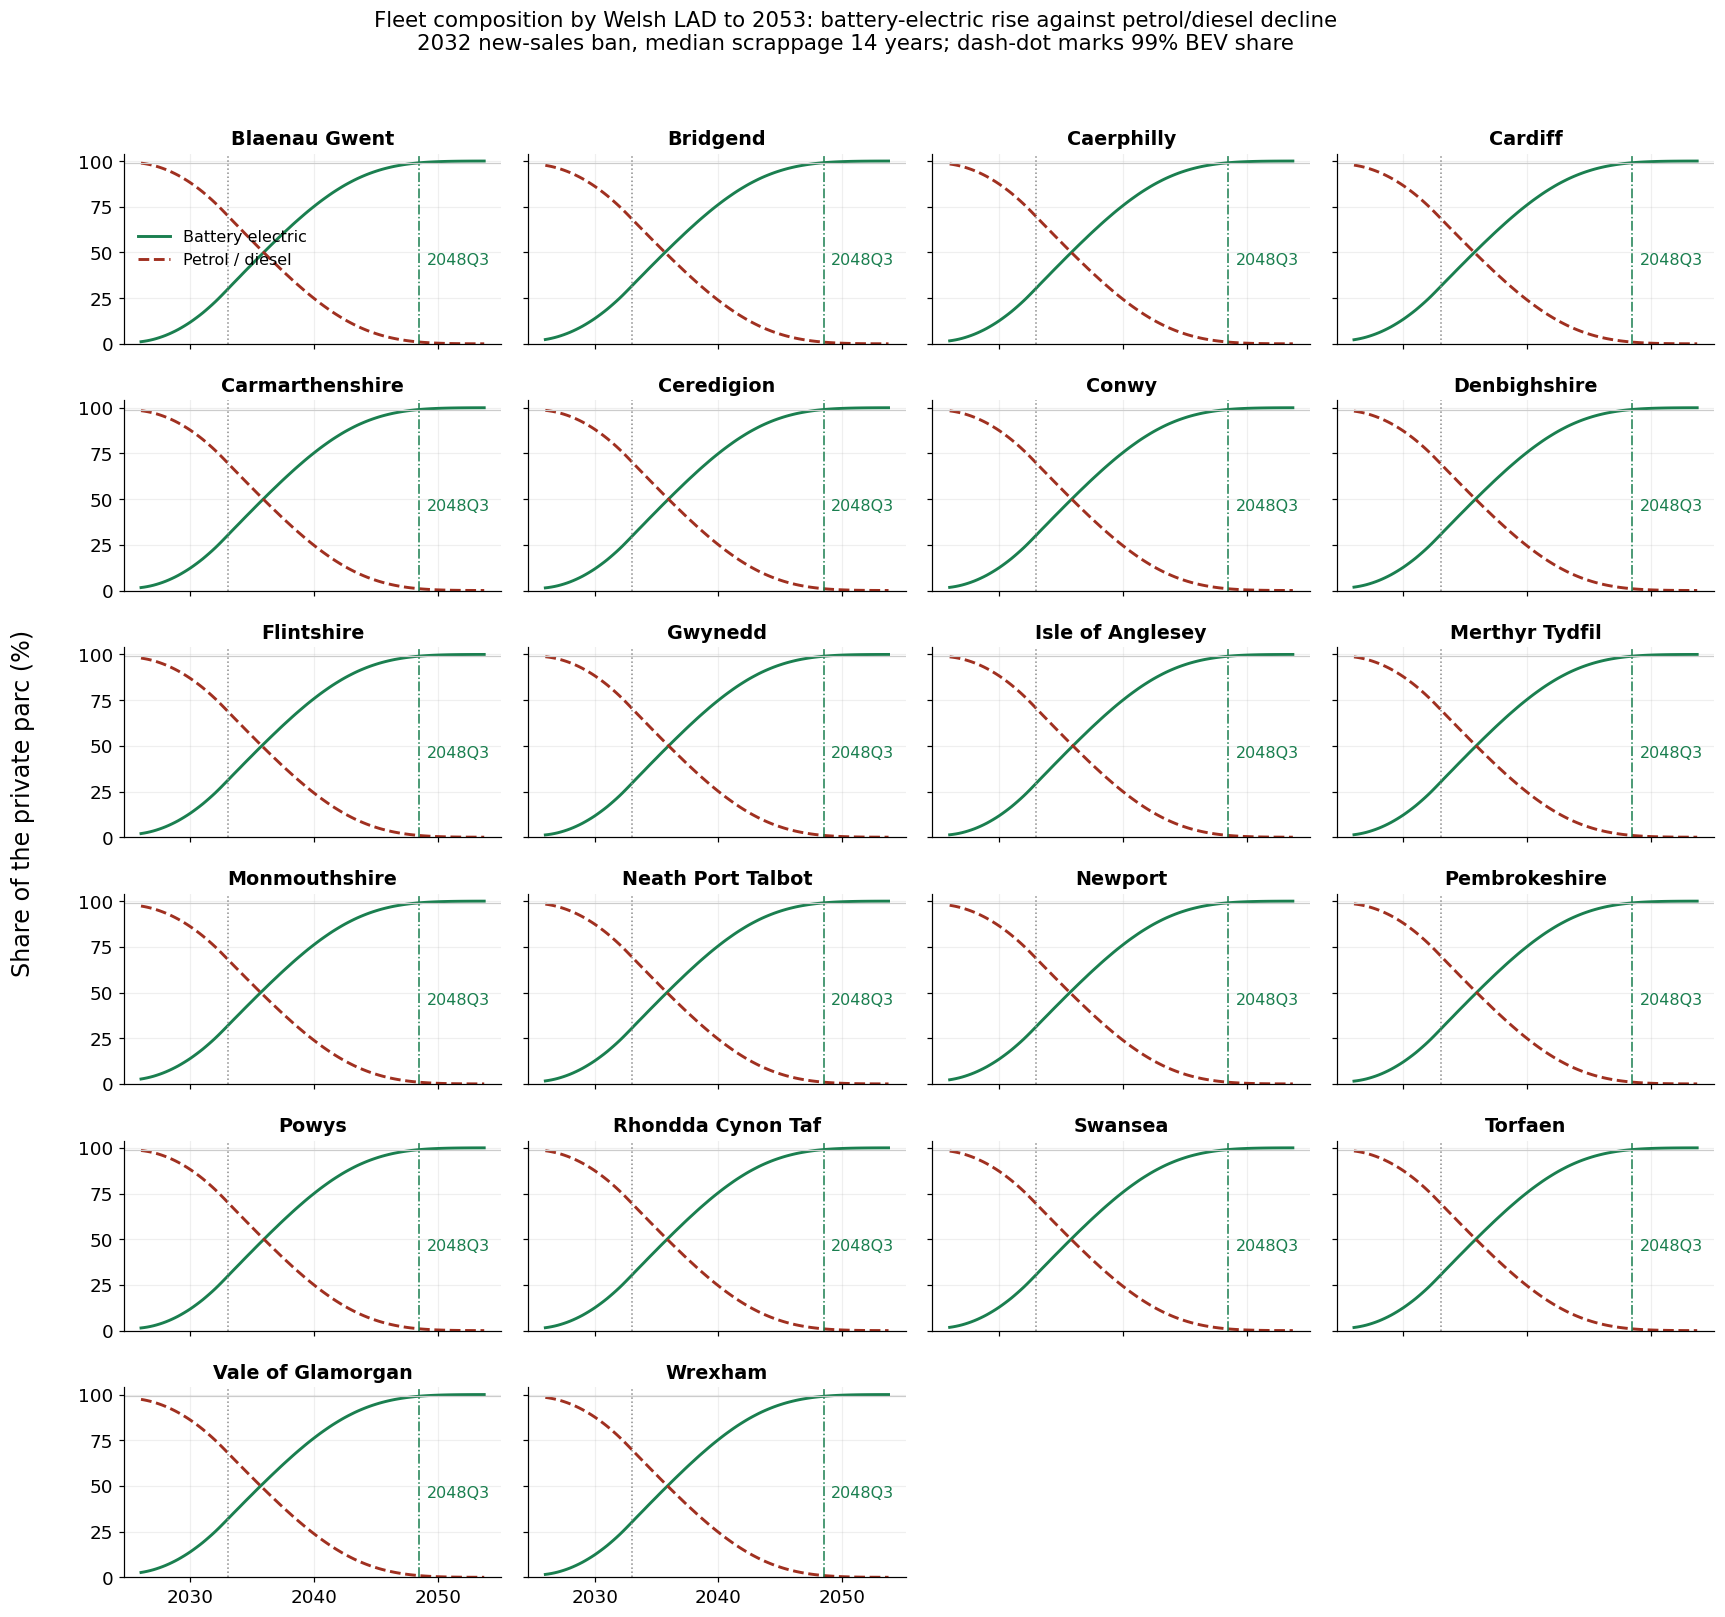


22 per-LAD figures written to cleets_out/per_lad_electrification
Trajectories and arrival table written to cleets_out


In [ ]:
# ============================================================
# 9. Per-LAD electrification trajectories to 2053
#
# One panel per LAD showing the BEV stock share rising and the petrol/diesel
# share falling, with the quarter at which each LAD crosses the electrification
# threshold marked. Extends the Stage 8 vintage model horizon beyond 2045.
#
# READ THIS BEFORE INTERPRETING THE SPREAD. Under a binding new-sales ban every
# LAD receives an identical inflow from 2032 onward, so the only sources of
# LAD-to-LAD divergence left in the model are (i) the BEV stock each LAD has
# accumulated by the ban and (ii) the rate at which its pre-ban stock retires.
# If (ii) is held common across LADs, the arrival quarters will cluster tightly
# and the ordering will be driven almost entirely by present-day uptake. That
# clustering is a genuine model result, not a plotting failure: it says a sales
# ban equalises outcomes. Whether it is the RIGHT result depends on whether
# Welsh LADs really do scrap vehicles at the same rate, which they almost
# certainly do not. See LAD_SPECIFIC_SCRAPPAGE below.
# ============================================================

EXTENDED_FORECAST_END = pd.Period("2053Q4", freq="Q")

# Stage 9 failed in the last run with NameError: MEDIAN_SCRAPPAGE_AGE_YEARS.
# The cause was cell ORDER, not code: this cell was executed at count 32 while
# Stage 8a, which defines that constant, ran at count 33. Nothing here can be
# trusted unless Stage 8a has already run in the same kernel, so the dependency
# is now checked explicitly rather than surfacing as a traceback 100 lines down.
_required = ["MEDIAN_SCRAPPAGE_AGE_YEARS", "run_vintage_model",
             "quarterly_retention", "stationary_ice_vintages", "mean_lifetime",
             "POLICY_BAN_PERIOD", "panel"]
_absent = [n for n in _required if n not in globals()]
if _absent:
    raise RuntimeError(
        "Stage 9 depends on Stage 8a, which has not run in this kernel.\n"
        f"Missing: {_absent}\n"
        "Run the Stage 8a cell first, then re-run this one. Restart-and-run-all "
        "will keep the order correct."
    )
if EXTENDED_FORECAST_END.year < 2053:
    raise ValueError(f"EXTENDED_FORECAST_END is {EXTENDED_FORECAST_END}; the "
                     "study horizon is 2053Q4.")
print(f"Stage 9 horizon: {panel['period'].max() + 1} to {EXTENDED_FORECAST_END} "
      f"({EXTENDED_FORECAST_END.ordinal - panel['period'].max().ordinal} quarters)")

# "Full electrification" is asymptotic in a turnover model: the BEV share
# approaches 1 but never reaches it, because a small tail of pre-ban vehicles
# survives indefinitely. A threshold must therefore be declared. 0.99 is a
# convention, not a policy definition; report whichever you use.
ELECTRIFICATION_THRESHOLD = 0.99
REPORTED_THRESHOLDS = [0.95, 0.99, 0.995]

# Optional: let median scrappage age vary by LAD. Vehicle age correlates with
# income and deprivation, so a common survival curve across all 22 LADs is a
# strong and probably wrong assumption. Setting this True scales each LAD's
# median scrappage age by its position on the chosen covariate.
#
# This is an ASSUMPTION, not an estimate. It is not fitted to Welsh scrappage
# data, because no LAD-level scrappage series is used anywhere in this
# pipeline. Turning it on will widen the spread of arrival quarters, and that
# widening is imposed by the assumption rather than discovered in the data.
# Either fit the gradient from DfT VEH0211 licensed-cars-by-age or report both
# variants side by side.
LAD_SPECIFIC_SCRAPPAGE = False
SCRAPPAGE_COVARIATE = "deprivation_pct"   # higher value -> older fleet
SCRAPPAGE_SPREAD_YEARS = 2.0              # +/- this many years across the range


def _lad_median_scrappage(base_median):
    """Median scrappage age per LAD code."""
    codes = sorted(panel["code"].astype(str).unique())
    if not LAD_SPECIFIC_SCRAPPAGE:
        return {c: base_median for c in codes}
    if SCRAPPAGE_COVARIATE not in df.columns:
        raise KeyError(
            f"LAD_SPECIFIC_SCRAPPAGE is on but '{SCRAPPAGE_COVARIATE}' is not in "
            f"`df`. Available: {[c for c in df.columns if c != 'code']}")
    cov = df.set_index(df.code.astype(str))[SCRAPPAGE_COVARIATE].astype(float)
    rank = cov.rank(pct=True)                       # 0 = lowest, 1 = highest
    offset = (rank - 0.5) * 2.0 * SCRAPPAGE_SPREAD_YEARS
    return {c: float(base_median + offset.get(c, 0.0)) for c in codes}


def run_extended_model(base_median, end_period):
    """Stage 8 vintage model, re-run to a later horizon, optionally per-LAD."""
    global POLICY_FORECAST_END
    saved = POLICY_FORECAST_END
    POLICY_FORECAST_END = end_period
    try:
        medians = _lad_median_scrappage(base_median)
        if len(set(medians.values())) == 1:
            forecast, params = run_vintage_model(base_median)
        else:
            frames, plist = [], []
            full_panel = panel
            for code_value, m in medians.items():
                globals()["panel"] = full_panel[full_panel.code.astype(str) == code_value]
                f, p = run_vintage_model(m)
                frames.append(f); plist.append(p)
            globals()["panel"] = full_panel
            forecast = pd.concat(frames, ignore_index=True)
            params = pd.concat(plist, ignore_index=True)
    finally:
        POLICY_FORECAST_END = saved
    return forecast, params


def resolve_lad_names():
    """code -> display name, preferring the panel, then `df`, then the code.

    The vintage model carries whatever is in panel["name"]. If that column is
    ever blank or the panel is rebuilt without it, panels would silently be
    titled with codes, so the fallback is explicit rather than incidental.
    """
    lookup = {}
    for src in (df if "df" in globals() else None, panel):
        if src is None or "name" not in src.columns:
            continue
        for c, n in zip(src["code"].astype(str), src["name"].astype(str)):
            n = n.strip()
            if n and n.lower() not in {"nan", "none"}:
                lookup.setdefault(c, n)
    missing = sorted(set(panel["code"].astype(str)) - set(lookup))
    if missing:
        print(f"WARNING: no name found for {len(missing)} LAD code(s); "
              f"falling back to the code itself: {missing[:5]}")
        lookup.update({c: c for c in missing})
    return lookup


LAD_NAMES = resolve_lad_names()

extended_lad, extended_params = run_extended_model(
    MEDIAN_SCRAPPAGE_AGE_YEARS, EXTENDED_FORECAST_END)

# Petrol/diesel is the complement of BEV under the two-state fleet assumption.
# NOTE: VEH0105 also reports hybrid and plug-in hybrid stock. Treating the
# non-BEV remainder as "petrol/diesel" folds hybrids into that remainder, which
# overstates pure-ICE stock in every year after about 2030. If hybrids are
# saleable to 2035 in your scenario, split them out before publishing this.
extended_lad["name"] = extended_lad["code"].astype(str).map(LAD_NAMES)
extended_lad["ice_share"] = extended_lad.ice_stock / extended_lad.total_stock


def crossing_quarter(frame, threshold):
    """First quarter at which bev_share reaches the threshold; None if never."""
    f = frame.sort_values("period")
    hit = f.loc[f.bev_share >= threshold, "period"]
    return hit.iloc[0] if len(hit) else None


arrival_rows = []
for code_value, g in extended_lad.groupby("code"):
    g = g.sort_values("period")
    row = {"code": code_value, "name": g["name"].iloc[0],
           "private_vehicles": g["total_stock"].iloc[-1],
           "bev_share_2045_pct": 100 * g.loc[g.period == pd.Period("2045Q4", freq="Q"),
                                             "bev_share"].pipe(
               lambda s: s.iloc[0] if len(s) else np.nan),
           "bev_share_end_pct": 100 * g["bev_share"].iloc[-1],
           "residual_ice_end": g["ice_stock"].iloc[-1]}
    for t in REPORTED_THRESHOLDS:
        q = crossing_quarter(g, t)
        row[f"reaches_{int(1000*t)/10:g}pc"] = str(q) if q is not None else "not by horizon"
    arrival_rows.append(row)

electrification_arrival = pd.DataFrame(arrival_rows)
key = f"reaches_{int(1000*ELECTRIFICATION_THRESHOLD)/10:g}pc"
electrification_arrival["_sort"] = electrification_arrival[key].where(
    electrification_arrival[key] != "not by horizon", "9999Q9")
electrification_arrival = (electrification_arrival.sort_values(["_sort", "name"])
                           .drop(columns="_sort").reset_index(drop=True))
electrification_arrival.insert(0, "arrival_rank",
                               np.arange(1, len(electrification_arrival) + 1))
electrification_arrival = electrification_arrival[
    ["arrival_rank", "name", "code"]
    + [c for c in electrification_arrival.columns
       if c not in {"arrival_rank", "name", "code"}]]

print("=" * 72)
print(f"ELECTRIFICATION ARRIVAL BY LAD  (threshold {100*ELECTRIFICATION_THRESHOLD:g}% "
      f"BEV share, horizon {EXTENDED_FORECAST_END})")
print("=" * 72)
with pd.option_context("display.max_columns", None, "display.width", 200):
    display(electrification_arrival.drop(columns=["private_vehicles", "code"]).round(2))

arrived = electrification_arrival[electrification_arrival[key] != "not by horizon"]
if len(arrived) >= 2:
    qs = pd.PeriodIndex(arrived[key], freq="Q")
    span = qs.max().ordinal - qs.min().ordinal
    print(f"\nFirst LAD: {qs.min()}  |  Last LAD: {qs.max()}  |  spread {span} quarters "
          f"({span/4:.1f} years)")
    if span <= 4:
        print(">>> The arrival quarters span one year or less. Under a common "
              "survival curve\n>>> this is what the model must produce, because "
              "after the ban every LAD\n>>> receives the same inflow. Do not "
              "present near-identical panels as evidence\n>>> of LAD difference. "
              "Either report the residual ICE fraction, which separates\n>>> the "
              "LADs far more sharply than the BEV share does, or justify "
              "LAD-specific\n>>> scrappage from data and re-run.")
n_missing = len(electrification_arrival) - len(arrived)
if n_missing:
    print(f"\n{n_missing} LAD(s) do not reach {100*ELECTRIFICATION_THRESHOLD:g}% by "
          f"{EXTENDED_FORECAST_END}. A turnover model approaches full "
          f"electrification\nasymptotically; without a scrappage incentive the "
          f"last few percent take decades.")


# ---------------------------------------------------------------- small multiples
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

order = electrification_arrival["code"].tolist()
n = len(order)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 2.5 * nrows),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, code_value in zip(axes, order):
    g = extended_lad[extended_lad.code == code_value].sort_values("period")
    x = g.period.dt.to_timestamp()
    ax.plot(x, 100 * g.bev_share, color="#1a7f4f", linewidth=1.9, label="Battery electric")
    ax.plot(x, 100 * g.ice_share, color="#a03020", linewidth=1.9,
            linestyle="--", label="Petrol / diesel")
    ax.axvline(POLICY_BAN_PERIOD.to_timestamp(how="end"), color="0.55",
               linestyle=":", linewidth=1.0)
    q = crossing_quarter(g, ELECTRIFICATION_THRESHOLD)
    if q is not None:
        ax.axvline(q.to_timestamp(), color="#1a7f4f", linestyle="-.", linewidth=1.0)
        ax.text(0.97, 0.42, str(q), transform=ax.transAxes, ha="right",
                fontsize=10.5, color="#1a7f4f")
    ax.axhline(100 * ELECTRIFICATION_THRESHOLD, color="0.8", linewidth=0.8)
    ax.set_title(LAD_NAMES.get(str(code_value), str(code_value)),
                 fontsize=12.5, fontweight="bold")
    ax.set_ylim(0, 104)
    ax.grid(alpha=0.2)
    ax.xaxis.set_major_locator(mdates.YearLocator(10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

for ax in axes[n:]:
    ax.axis("off")
axes[0].legend(fontsize=10.5, loc="center left", frameon=False)
fig.supylabel("Share of the private parc (%)")
fig.suptitle(f"Fleet composition by Welsh LAD to {EXTENDED_FORECAST_END.year}: "
             f"battery-electric rise against petrol/diesel decline\n"
             f"{POLICY_BAN_PERIOD.year} new-sales ban, median scrappage "
             f"{MEDIAN_SCRAPPAGE_AGE_YEARS:.0f} years; dash-dot marks "
             f"{100*ELECTRIFICATION_THRESHOLD:g}% BEV share",
             fontsize=14)
fig.tight_layout(rect=[0.02, 0, 1, 0.96])
fig.savefig(WORK / "welsh_lad_electrification_smallmultiples.png", dpi=220,
            bbox_inches="tight")
plt.show()


# ---------------------------------------------------------------- one file per LAD
PER_LAD_DIR = WORK / "per_lad_electrification"
PER_LAD_DIR.mkdir(exist_ok=True)

for code_value in order:
    g = extended_lad[extended_lad.code == code_value].sort_values("period")
    nm = LAD_NAMES.get(str(code_value), str(code_value))
    x = g.period.dt.to_timestamp()

    f1, ax = plt.subplots(figsize=(9, 5))
    ax.fill_between(x, 0, 100 * g.bev_share, color="#1a7f4f", alpha=0.13)
    ax.plot(x, 100 * g.bev_share, color="#1a7f4f", linewidth=2.4,
            label="Battery electric")
    ax.plot(x, 100 * g.ice_share, color="#a03020", linewidth=2.4, linestyle="--",
            label="Petrol / diesel (non-BEV remainder)")
    ax.axvline(POLICY_BAN_PERIOD.to_timestamp(how="end"), color="0.45",
               linestyle=":", linewidth=1.3)
    ax.annotate(f"{POLICY_BAN_PERIOD.year} new-sales ban",
                xy=(POLICY_BAN_PERIOD.to_timestamp(how="end"), 50),
                xytext=(6, 0), textcoords="offset points", fontsize=11.5, color="0.35")
    ax.axhline(100 * ELECTRIFICATION_THRESHOLD, color="0.75", linewidth=1.0)
    q = crossing_quarter(g, ELECTRIFICATION_THRESHOLD)
    if q is not None:
        ax.axvline(q.to_timestamp(), color="#1a7f4f", linestyle="-.", linewidth=1.3)
        ax.annotate(f"{100*ELECTRIFICATION_THRESHOLD:g}% reached {q}",
                    xy=(q.to_timestamp(), 100 * ELECTRIFICATION_THRESHOLD),
                    xytext=(-8, -26), textcoords="offset points", fontsize=12,
                    ha="right", color="#1a7f4f")
    else:
        ax.annotate(f"{100*ELECTRIFICATION_THRESHOLD:g}% not reached by "
                    f"{EXTENDED_FORECAST_END}",
                    xy=(0.97, 0.55), xycoords="axes fraction", ha="right",
                    fontsize=12, color="#a03020")
    ax.set_ylim(0, 104)
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Share of the private parc (%)")
    ax.set_title(f"{nm}  ({code_value})\nprojected fleet composition to "
                 f"{EXTENDED_FORECAST_END.year}")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, loc="center right")
    f1.tight_layout()
    slug = "".join(ch if ch.isalnum() else "_" for ch in nm.lower()).strip("_")
    f1.savefig(PER_LAD_DIR / f"{code_value}_{slug}.png", dpi=200, bbox_inches="tight")
    plt.close(f1)

print(f"\n{len(order)} per-LAD figures written to {PER_LAD_DIR}")

extended_lad.assign(period=lambda d: d.period.astype(str)).to_csv(
    WORK / "welsh_lad_electrification_to_2053.csv", index=False)
electrification_arrival.to_csv(
    WORK / "welsh_lad_electrification_arrival.csv", index=False)
print("Trajectories and arrival table written to", WORK)

### Stage 9b — Arrival ranking figures

Two views of the Stage 9 result: the crossing-quarter ranking as a dot plot, and every
district's trajectory with the three earliest and three latest arrivals highlighted and
the ban marked. The ranking, not the 2053 share, is the finding — after the ban the
districts converge, so arrival order and residual non-BEV stock are what separate them.


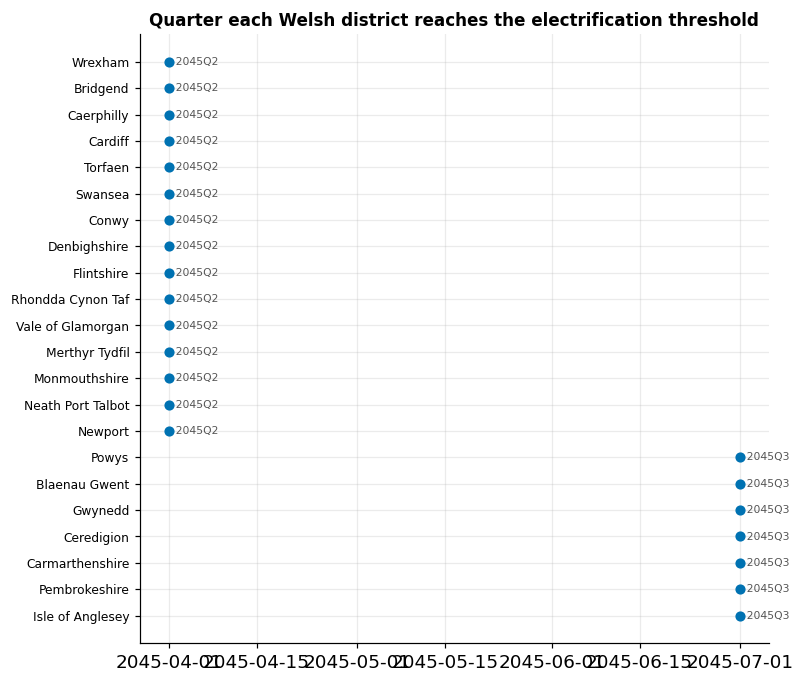

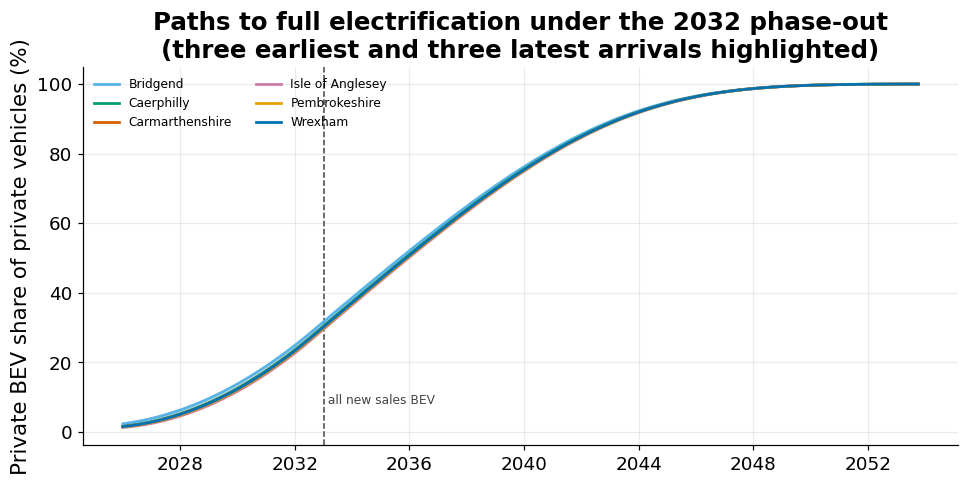

Saved: fig_arrival_ranking.png, fig_arrival_trajectories.png


In [ ]:
# ============================================================
# 9b. Figures for the full-electrification arrival ranking
# ============================================================
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

if "electrification_arrival" not in globals():
    print("Run Stage 9 first: electrification_arrival not available.")
else:
    ea = electrification_arrival.copy()
    qcols = [c for c in ea.columns
             if ea[c].astype(str).str.match(r"^\d{4}Q[1-4]$").any()]
    kq = qcols[0]
    to_ts = lambda v: (pd.Period(v, freq="Q").to_timestamp()
                       if isinstance(v, str) and pd.Period is not None
                       and pd.Series([v]).str.match(r"^\d{4}Q[1-4]$").iloc[0]
                       else pd.NaT)
    ea["_ts"] = ea[kq].map(to_ts)
    plot_ea = ea.dropna(subset=["_ts"]).sort_values("_ts")

    # ---- 1. ranking dot plot
    fig, ax = plt.subplots(figsize=(7.5, 6.4))
    y = np.arange(len(plot_ea))[::-1]
    ax.scatter(plot_ea["_ts"], y, color="#0072B2", s=32, zorder=3)
    ax.set_yticks(y); ax.set_yticklabels(plot_ea["name"], fontsize=8)
    for yy, (ts, nm) in zip(y, zip(plot_ea["_ts"], plot_ea[kq])):
        ax.text(ts, yy, "  " + str(nm), fontsize=7, va="center", color="#555")
    missing = ea[ea["_ts"].isna()]
    ttl = "Quarter each Welsh district reaches the electrification threshold"
    if not missing.empty:
        ttl += f"\n({len(missing)} district(s) not by horizon: " + \
               ", ".join(missing["name"].astype(str).head(5)) + ")"
    ax.set_title(ttl, fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(WORK / "fig_arrival_ranking.png", dpi=200); plt.show()

    # ---- 2. trajectories with earliest/latest highlighted and the ban marked
    if "extended_lad" in globals():
        tr = extended_lad.copy()
        if "name" not in tr.columns and "code" in tr.columns:
            tr = tr.merge(ea[["code", "name"]], on="code", how="left")
        share_col = next(c for c in tr.columns if "share" in c)
        per = tr["period"] if str(tr["period"].dtype).startswith("period") \
            else pd.PeriodIndex(tr["period"].astype(str), freq="Q")
        tr["_ts"] = pd.PeriodIndex(per, freq="Q").to_timestamp()
        first3 = list(plot_ea["name"].head(3)); last3 = list(plot_ea["name"].tail(3))
        PAL = ["#0072B2", "#56B4E9", "#009E73", "#D55E00", "#E69F00", "#CC79A7"]
        fig, ax = plt.subplots(figsize=(9, 4.6))
        for nm, g in tr.groupby("name"):
            if nm in first3 + last3:
                ax.plot(g["_ts"], g[share_col] * 100, lw=1.8,
                        color=PAL[(first3 + last3).index(nm)], label=str(nm), zorder=3)
            else:
                ax.plot(g["_ts"], g[share_col] * 100, lw=0.5, color="#ccc", zorder=1)
        ax.axvline(pd.Period("2033Q1", freq="Q").to_timestamp(),
                   color="#444", ls="--", lw=1)
        ax.text(pd.Period("2033Q1", freq="Q").to_timestamp(), 8,
                " all new sales BEV", fontsize=8, color="#444")
        ax.set_ylabel("Private BEV share of private vehicles (%)")
        ax.set_title("Paths to full electrification under the 2032 phase-out\n"
                     "(three earliest and three latest arrivals highlighted)")
        ax.legend(fontsize=8, ncol=2, frameon=False, loc="upper left")
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        plt.savefig(WORK / "fig_arrival_trajectories.png", dpi=200); plt.show()
    else:
        print("extended_lad not in scope; trajectory figure skipped.")
    print("Saved: fig_arrival_ranking.png" +
          (", fig_arrival_trajectories.png" if "extended_lad" in globals() else ""))


## Stage 11 — Hierarchical diffusion model

Two-stage empirical Bayes: covariates predict the curve *parameters*, each LAD
is shrunk toward its covariate prediction in proportion to how noisily it is
estimated, and the model is evaluated on first differences rather than levels.


In [ ]:
# ============================================================
# 11a. Hierarchical diffusion by two-stage empirical Bayes
#
# Stage 6 fits 22 independent logistic curves and lets covariates enter nowhere.
# Two consequences.
#
# First, adoption shares are around 1-2%, so every LAD sits on the early
# exponential limb of its S-curve. Rate and midpoint are weakly identified from
# that stretch: many (r, m) pairs fit the observed points almost equally well.
# An independent fit picks one of them nearly at random, which is why the
# per-LAD midpoints from Stage 6 should not be compared with each other.
#
# Second, the research question is about curve PARAMETERS, not levels. "Which
# LADs diffuse slowly" is a claim about midpoints, so covariates are regressed
# on the parameters here rather than on the share.
#
# Method. A single joint penalised fit was tried first and degenerated:
# shrinkage narrows the between-LAD spread, the variance component is
# re-estimated from that narrowed spread, and the penalty tightens until every
# LAD collapses onto one curve. Two-stage empirical Bayes avoids this because
# the between-LAD variance is estimated by moments from the INDEPENDENT fits,
# before any shrinkage is applied.
#
#   Stage 1  fit each LAD alone; keep the estimate and its sampling variance
#   Stage 2  meta-regress those estimates on covariates; DerSimonian-Laird tau^2
#   Stage 3  shrink toward the covariate prediction by w_i = tau^2/(tau^2+V_i),
#            so noisily-estimated LADs move furthest
# ============================================================

from scipy.optimize import least_squares

HIER_CEILING = 1.0
HIER_COVARIATES = ["density", "population"]   # extend when 4a-bis covariates load
N_BOOTSTRAP = 300
BOOTSTRAP_SEED = 0

hier_panel = (panel[["code", "name", "period", "adoption_share"]].dropna()
              .sort_values(["code", "period"]).copy())
hier_codes = sorted(hier_panel["code"].astype(str).unique())
n_lad = len(hier_codes)
t0 = hier_panel["period"].min()
hier_panel["t"] = hier_panel["period"].apply(lambda p: p.ordinal - t0.ordinal)

missing_cov = [c for c in HIER_COVARIATES if c not in df.columns]
if missing_cov:
    raise KeyError(f"Covariates absent from `df`: {missing_cov}")
cov = (df.assign(code=df.code.astype(str)).set_index("code")
       .reindex(hier_codes)[HIER_COVARIATES].astype(float))
if cov.isna().any().any():
    raise ValueError(f"Missing covariates for {cov.index[cov.isna().any(axis=1)].tolist()}")
X = np.column_stack([np.ones(n_lad), ((cov - cov.mean()) / cov.std(ddof=0)).to_numpy()])
TERMS = ["intercept"] + HIER_COVARIATES

print(f"{len(hier_panel)} LAD-quarters across {n_lad} LADs | shares "
      f"{100*hier_panel.adoption_share.min():.2f}% to "
      f"{100*hier_panel.adoption_share.max():.2f}%")
if hier_panel.adoption_share.max() < 0.25 * HIER_CEILING:
    print(">>> Every observation lies below a quarter of the ceiling: the sample "
          "is entirely\n>>> on the early limb of the S-curve, so the midpoint is "
          "EXTRAPOLATED, never\n>>> observed. Wide intervals below are the correct "
          "answer, not a fitting failure.")

def logistic_share(t, r, m, K=HIER_CEILING):
    return K / (1.0 + np.exp(-np.clip(r * (t - m), -60.0, 60.0)))


# ---------------------------------------------------------------- stage 1
def fit_one_lad(t, y):
    """Independent logistic fit; returns (log_r, m), its covariance, resid sd."""
    def resid(p):
        return logistic_share(t, np.exp(p[0]), p[1]) - y

    best, best_cost = None, np.inf
    for log_r0 in (np.log(0.05), np.log(0.10), np.log(0.20)):
        for m0 in (t.max() + 30.0, t.max() + 60.0, t.max() + 100.0):
            try:
                s = least_squares(resid, [log_r0, m0], method="lm", max_nfev=8000)
            except Exception:
                continue
            if s.cost < best_cost:
                best, best_cost = s, s.cost
    if best is None:
        return None
    dof = max(len(y) - 2, 1)
    s2 = 2.0 * best.cost / dof
    try:
        cov_p = s2 * np.linalg.inv(best.jac.T @ best.jac)
    except np.linalg.LinAlgError:
        cov_p = np.full((2, 2), np.nan)
    return best.x, cov_p, float(np.sqrt(s2))


stage1 = []
for code_value in hier_codes:
    g = hier_panel[hier_panel.code.astype(str) == code_value].sort_values("t")
    out = fit_one_lad(g.t.to_numpy(float), g.adoption_share.to_numpy(float))
    if out is None:
        raise RuntimeError(f"Independent fit failed for {code_value}")
    p, cov_p, sd = out
    stage1.append({"code": code_value, "log_r": p[0], "m": p[1],
                   "var_log_r": cov_p[0, 0], "var_m": cov_p[1, 1],
                   "resid_sd": sd, "n_obs": len(g)})
S1 = pd.DataFrame(stage1)
print(f"\nIndependent fits: midpoint spread {S1.m.std():.1f} quarters | median "
      f"sampling sd of a midpoint {np.sqrt(S1.var_m).median():.1f} quarters")
if np.sqrt(S1.var_m).median() > S1.m.std():
    print(">>> Each LAD's midpoint is estimated less precisely than the LADs "
          "differ from one\n>>> another, so independent per-LAD midpoints are not "
          "comparable. This is exactly\n>>> the situation partial pooling exists "
          "for.")


# ---------------------------------------------------------------- stage 2
def meta_regress(y, v, Xd):
    """Random-effects meta-regression: DerSimonian-Laird tau^2, then GLS."""
    finite = np.isfinite(v) & (v > 0)
    v = np.where(finite, v, np.nanmedian(v[finite]) if finite.any() else 1.0)
    W = np.diag(1.0 / v)
    beta_fe = np.linalg.solve(Xd.T @ W @ Xd, Xd.T @ W @ y)
    resid = y - Xd @ beta_fe
    Q = float(resid.T @ W @ resid)
    dof = len(y) - Xd.shape[1]
    P = W - W @ Xd @ np.linalg.solve(Xd.T @ W @ Xd, Xd.T @ W)
    tau2 = max(0.0, (Q - dof) / max(float(np.trace(P)), 1e-12))
    Wr = np.diag(1.0 / (v + tau2))
    cov_b = np.linalg.inv(Xd.T @ Wr @ Xd)
    return cov_b @ (Xd.T @ Wr @ y), cov_b, tau2, v


beta_m, cov_bm, tau2_m, v_m = meta_regress(S1.m.to_numpy(), S1.var_m.to_numpy(), X)
beta_r, cov_br, tau2_r, v_r = meta_regress(S1.log_r.to_numpy(), S1.var_log_r.to_numpy(), X)
print(f"\nBetween-LAD sd: midpoint {np.sqrt(tau2_m):.2f} quarters "
      f"({np.sqrt(tau2_m)/4:.2f} years) | log rate {np.sqrt(tau2_r):.4f}")
if tau2_m == 0:
    print(">>> tau^2 for the midpoint is zero: once sampling error is accounted "
          "for, there is\n>>> no detectable genuine variation between LADs. Every "
          "LAD is shrunk fully to the\n>>> covariate prediction, and no ranking "
          "can be defended.")

# ---------------------------------------------------------------- stage 3
w_m = tau2_m / (tau2_m + v_m)
w_r = tau2_r / (tau2_r + v_r)
m_eb = w_m * S1.m.to_numpy() + (1 - w_m) * (X @ beta_m)
logr_eb = w_r * S1.log_r.to_numpy() + (1 - w_r) * (X @ beta_r)
print(f"Shrinkage weight on an LAD's own midpoint: median {np.median(w_m):.3f} "
      f"(0 = fully pooled, 1 = no pooling)")


1254 LAD-quarters across 22 LADs | shares 0.00% to 2.44%
>>> Every observation lies below a quarter of the ceiling: the sample is entirely
>>> on the early limb of the S-curve, so the midpoint is EXTRAPOLATED, never
>>> observed. Wide intervals below are the correct answer, not a fitting failure.

Independent fits: midpoint spread 4.8 quarters | median sampling sd of a midpoint 0.5 quarters

Between-LAD sd: midpoint 3.64 quarters (0.91 years) | log rate 0.1005
Shrinkage weight on an LAD's own midpoint: median 0.983 (0 = fully pooled, 1 = no pooling)


In [ ]:
# ============================================================
# 11b. Bootstrap intervals
# ============================================================
rng_boot = np.random.default_rng(BOOTSTRAP_SEED)
BM, BB = [], []
for _ in range(N_BOOTSTRAP):
    m_sim = S1.m.to_numpy() + rng_boot.normal(0, np.sqrt(v_m))
    bmv, _, t2m, vv = meta_regress(m_sim, v_m, X)
    wm = t2m / (t2m + vv)
    BM.append(wm * m_sim + (1 - wm) * (X @ bmv))
    BB.append(bmv)
BM, BB = np.array(BM), np.array(BB)
lo_m, hi_m = np.percentile(BM, [2.5, 97.5], axis=0)

hier_params = pd.DataFrame({
    "code": hier_codes,
    "name": [LAD_NAMES.get(c, c) for c in hier_codes],
    "rate_per_quarter": np.exp(logr_eb),
    "midpoint_quarters": m_eb, "midpoint_lo": lo_m, "midpoint_hi": hi_m,
    "shrinkage_weight": w_m})
hier_params["midpoint_period"] = [str(t0 + int(round(v))) for v in m_eb]
hier_params["lag_vs_median_years"] = (m_eb - np.median(m_eb)) / 4.0
hier_params["ci_width_years"] = (hi_m - lo_m) / 4.0
hier_params = hier_params.sort_values("midpoint_quarters", ascending=False)
hier_params.insert(0, "slowest_rank", np.arange(1, n_lad + 1))

print("\n" + "=" * 76)
print("WHICH LADs DIFFUSE MOST SLOWLY  (later midpoint = slower)")
print("=" * 76)
with pd.option_context("display.max_columns", None, "display.width", 210):
    display(hier_params[["slowest_rank", "name", "midpoint_period",
                         "lag_vs_median_years", "ci_width_years",
                         "shrinkage_weight", "rate_per_quarter"]].round(3))

spread = hier_params.lag_vs_median_years.max() - hier_params.lag_vs_median_years.min()
med_ci = hier_params.ci_width_years.median()
print(f"\nSpread across LADs: {spread:.2f} years | median 95% interval: "
      f"{med_ci:.2f} years")
if med_ci > spread:
    print(">>> A single LAD's interval is wider than the entire spread across "
          "LADs. Present\n>>> this as an ordered list WITH intervals; do not "
          "claim any LAD is slower than\n>>> another, and never show the rank "
          "column without the interval beside it.")

coef = pd.DataFrame({"term": TERMS, "beta_midpoint_q": beta_m,
                     "lo": np.percentile(BB, 2.5, axis=0),
                     "hi": np.percentile(BB, 97.5, axis=0),
                     "beta_lograte": beta_r})
coef["crosses_zero"] = (coef.lo < 0) & (coef.hi > 0)
print("\nCovariate effect on the midpoint (quarters per 1 sd; positive = slower):")
display(coef.round(3))
print("These coefficients answer 'what makes an LAD diffuse late', not 'what "
      "predicts its\ncurrent share'. Terms whose interval crosses zero carry no "
      "evidence either way.")


WHICH LADs DIFFUSE MOST SLOWLY  (later midpoint = slower)


,slowest_rank,name,midpoint_period,lag_vs_median_years,ci_width_years,shrinkage_weight,rate_per_quarter
1,1,Gwynedd,2038Q1,2.563,0.540,0.975,0.092
20,2,Powys,2037Q4,2.358,0.713,0.963,0.090
0,3,Isle of Anglesey,2037Q3,2.267,0.698,0.963,0.092
7,4,Pembrokeshire,2037Q2,1.957,0.755,0.948,0.092
6,5,Ceredigion,2037Q2,1.937,1.017,0.902,0.092
8,6,Carmarthenshire,2036Q3,1.149,0.709,0.964,0.098
2,7,Conwy,2036Q1,0.649,0.654,0.968,0.101
5,8,Wrexham,2035Q4,0.353,0.387,0.987,0.107
9,9,Swansea,2035Q3,0.216,0.591,0.977,0.106
3,10,Denbighshire,2035Q2,0.011,0.287,0.993,0.106



Spread across LADs: 3.61 years | median 95% interval: 0.44 years

Covariate effect on the midpoint (quarters per 1 sd; positive = slower):


,term,beta_midpoint_q,lo,hi,beta_lograte,crosses_zero
0,intercept,95.636,95.385,95.886,-2.251,False
1,density,-3.004,-3.305,-2.665,0.069,False
2,population,1.173,0.817,1.462,-0.044,False


These coefficients answer 'what makes an LAD diffuse late', not 'what predicts its
current share'. Terms whose interval crosses zero carry no evidence either way.


In [ ]:
pass


EVALUATION ON FIRST DIFFERENCES (change in share, trend removed)


,horizon_q,model,delta_MAE_pp,delta_RMSE_pp,delta_R2
0,1,hierarchical,0.0286,0.0391,0.0631
1,1,linear_drift,0.0345,0.0400,0.0195
2,1,persistence,0.1358,0.1417,-11.3189
3,4,hierarchical,0.0216,0.0291,0.9745
4,4,linear_drift,0.1380,0.1681,0.1464
5,4,persistence,0.3151,0.3638,-2.9989
6,8,hierarchical,0.0184,0.0245,0.9928
7,8,linear_drift,0.1904,0.2517,0.2459
8,8,persistence,0.4192,0.5097,-2.0914


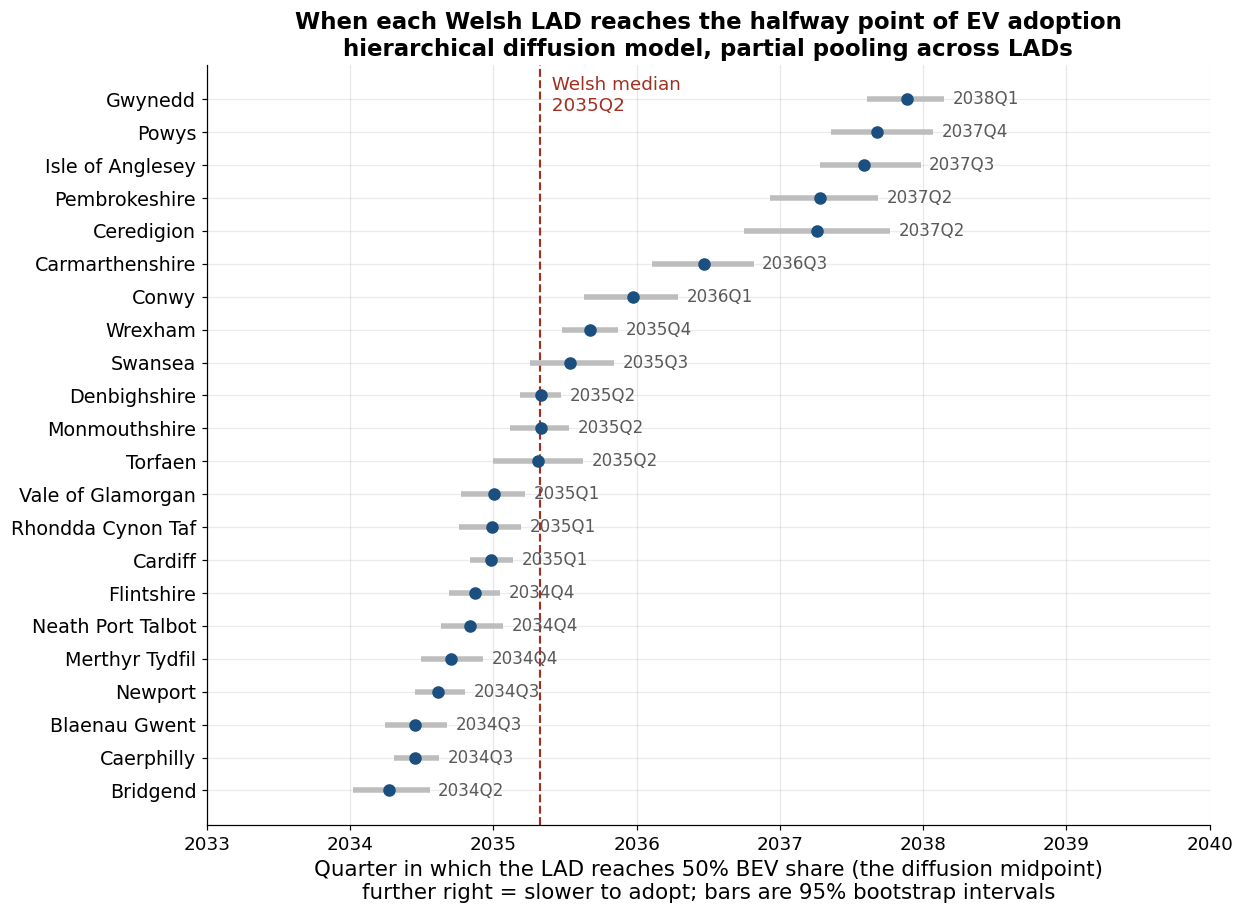

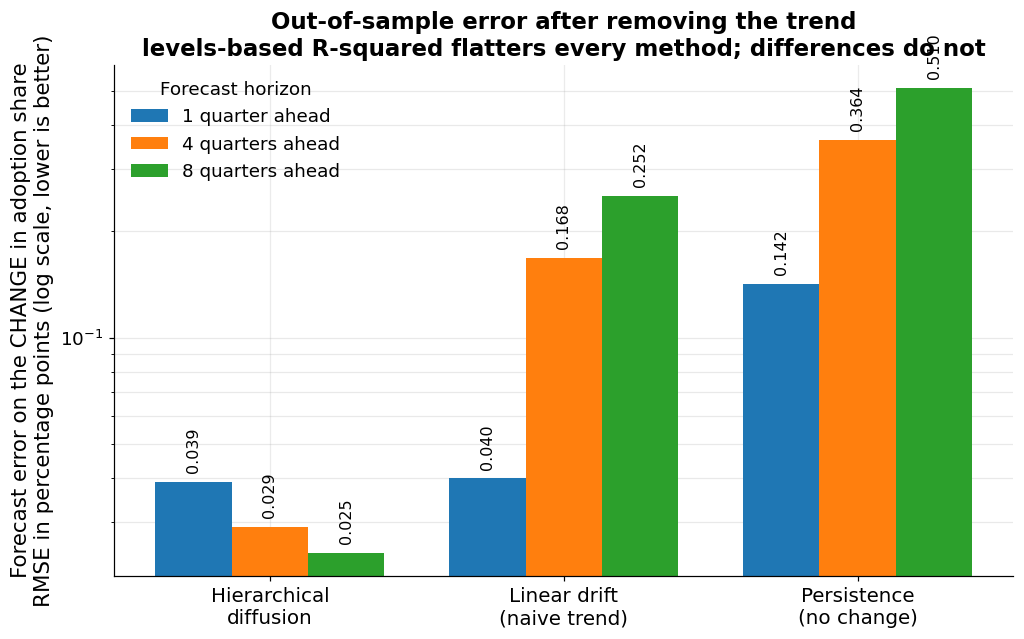

In [ ]:
# ============================================================
# 11c. Evaluation on first differences
# ============================================================
# Stage 6 reports R^2 = 0.957 for the logistic against 0.9916 for linear drift.
# Both are inflated: on a smoothly rising series almost all variance is trend,
# so anything tracking the trend scores highly. Differencing removes the trend
# and asks whether the model predicts the CHANGE. That is the comparison a
# referee will make, so make it first.
EVAL_HORIZONS = [1, 4, 8]
rows = []
for h in EVAL_HORIZONS:
    for k, code_value in enumerate(hier_codes):
        g = hier_panel[hier_panel.code.astype(str) == code_value].sort_values("t")
        if len(g) <= h + 8:
            continue
        y, t = g.adoption_share.to_numpy(float), g.t.to_numpy(float)
        cut = len(g) - h
        base = y[cut - 1]
        hier_d = logistic_share(t[cut:], np.exp(logr_eb[k]), m_eb[k]) - base
        slope = np.polyfit(t[cut - 8:cut], y[cut - 8:cut], 1)[0]
        drift_d = slope * (t[cut:] - t[cut - 1])
        for a, hd, dd in zip(y[cut:] - base, hier_d, drift_d):
            rows.append({"horizon": h, "actual": a, "hierarchical": hd,
                         "linear_drift": dd, "persistence": 0.0})
ev = pd.DataFrame(rows)

srows = []
for h, g in ev.groupby("horizon"):
    ss_tot = float(((g.actual - g.actual.mean()) ** 2).sum())
    for model in ["hierarchical", "linear_drift", "persistence"]:
        err = g[model] - g.actual
        srows.append({"horizon_q": h, "model": model,
                      "delta_MAE_pp": 100 * float(err.abs().mean()),
                      "delta_RMSE_pp": 100 * float(np.sqrt((err ** 2).mean())),
                      "delta_R2": (1 - float((err ** 2).sum()) / ss_tot)
                      if ss_tot > 0 else np.nan})
delta_eval = pd.DataFrame(srows).sort_values(["horizon_q", "delta_RMSE_pp"])
print("\n" + "=" * 76)
print("EVALUATION ON FIRST DIFFERENCES (change in share, trend removed)")
print("=" * 76)
display(delta_eval.round(4))
for h, g in delta_eval.groupby("horizon_q"):
    if g.iloc[0].model != "hierarchical":
        print(f"  h={h}q: '{g.iloc[0].model}' wins on point accuracy. The "
              f"hierarchical model earns its\n        place through "
              f"interpretable parameters and calibrated uncertainty, and that "
              f"is\n        how it should be presented.")

hier_params.to_csv(WORK / "hierarchical_diffusion_parameters.csv", index=False)
delta_eval.to_csv(WORK / "hierarchical_diffusion_delta_eval.csv", index=False)

# ---------------------------------------------------------------- figures
# The midpoint is plotted on a calendar axis rather than as a deviation from the
# Welsh median. "2033Q1" is a date a reader can act on; "+1.5 years relative to
# the median" requires them to hold the median in their head to decode it.

def q_to_decimal_year(q):
    return q / 4.0 + t0.year + (t0.quarter - 1) / 4.0


p = hier_params.sort_values("midpoint_quarters")
yy = np.arange(len(p))
med_year = q_to_decimal_year(float(np.median(m_eb)))

fig, ax = plt.subplots(figsize=(11.5, 8.5))
ax.hlines(yy, q_to_decimal_year(p.midpoint_lo.to_numpy()),
          q_to_decimal_year(p.midpoint_hi.to_numpy()),
          color="0.74", linewidth=3.6, zorder=2)
ax.scatter(q_to_decimal_year(p.midpoint_quarters.to_numpy()), yy,
           s=52, color="#1a4f7f", zorder=3)
ax.axvline(med_year, color="#a03020", linestyle="--", linewidth=1.4, zorder=1)
ax.text(med_year, len(p) - 0.3, f"  Welsh median\n  {t0 + int(round(np.median(m_eb)))}",
        color="#a03020", fontsize=12, va="top")

for k, (_, row) in enumerate(p.iterrows()):
    ax.text(q_to_decimal_year(row.midpoint_hi) + 0.06, k, row.midpoint_period,
            fontsize=11, va="center", color="0.35")

ax.set_yticks(yy)
ax.set_yticklabels(p.name, fontsize=12.5)
ax.set_xlabel("Quarter in which the LAD reaches 50% BEV share (the diffusion midpoint)\n"
              "further right = slower to adopt; bars are 95% bootstrap intervals")
ax.set_title("When each Welsh LAD reaches the halfway point of EV adoption\n"
             "hierarchical diffusion model, partial pooling across LADs",
             fontsize=15)
lo_x = q_to_decimal_year(p.midpoint_lo.min()) - 0.3
hi_x = q_to_decimal_year(p.midpoint_hi.max()) + 1.1
ax.set_xlim(lo_x, hi_x)
ax.set_xticks(np.arange(np.floor(lo_x), np.ceil(hi_x) + 1, 1))
ax.set_xticklabels([f"{int(v)}" for v in
                    np.arange(np.floor(lo_x), np.ceil(hi_x) + 1, 1)])
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(WORK / "hierarchical_diffusion_midpoints.png", dpi=220,
            bbox_inches="tight")
plt.show()


# Forecast error. The spread between models runs to two orders of magnitude, so
# a linear axis would render the winning model as an invisible sliver.
fig2, ax2 = plt.subplots(figsize=(9.5, 6))
MODELS = ["hierarchical", "linear_drift", "persistence"]
LABELS = ["Hierarchical\ndiffusion", "Linear drift\n(naive trend)",
          "Persistence\n(no change)"]
w = 0.26
for k, (h, g) in enumerate(delta_eval.groupby("horizon_q")):
    g = g.set_index("model").reindex(MODELS)
    xpos = np.arange(3) + (k - 1) * w
    bars = ax2.bar(xpos, g.delta_RMSE_pp, width=w,
                   label=f"{h} quarter{'s' if h > 1 else ''} ahead")
    for xb, v in zip(xpos, g.delta_RMSE_pp):
        ax2.text(xb, v * 1.08, f"{v:.3f}", ha="center", fontsize=10.5, rotation=90)
ax2.set_yscale("log")
ax2.set_xticks(np.arange(3))
ax2.set_xticklabels(LABELS, fontsize=13)
ax2.set_ylabel("Forecast error on the CHANGE in adoption share\n"
               "RMSE in percentage points (log scale, lower is better)")
ax2.set_title("Out-of-sample error after removing the trend\n"
              "levels-based R-squared flatters every method; differences do not",
              fontsize=15)
ax2.legend(frameon=False, title="Forecast horizon")
ax2.grid(axis="y", alpha=0.28, which="both")
ax2.set_axisbelow(True)
fig2.tight_layout()
fig2.savefig(WORK / "hierarchical_diffusion_error.png", dpi=220, bbox_inches="tight")
plt.show()

## Stage 11d — Reconciliation of diffusion against turnover (paper §3.7, Figure 6)

The two preceding stages estimate the same quantity by different routes and disagree.
Equation 5 is a ceiling and therefore also an admissibility test: a stock-share
projection above it describes a fleet transformation faster than vehicle retirement
permits, however well the curve fits the observed points. The test is run against the
most permissive bound in the scrappage band, so a flag means violation under every
plausible parameterisation. This is what governs how the district-level projections
may be read, which is why it precedes them in the paper.

RECONCILIATION OF DIFFUSION AGAINST TURNOVER  (paper Section 3.7)
Unconstrained Wales diffusion trajectory at 2045Q4: 98.50%
Turnover ceiling for that quarter (median scrappage 14y):        96.00%
Prediction exceeds the central ceiling by:                          +2.49 percentage points

Admissibility across the scrappage band (Equation 5):
  median 12y -> ceiling  98.83%   ADMISSIBLE
  median 14y -> ceiling  96.00%   INADMISSIBLE
  median 16y -> ceiling  91.50%   INADMISSIBLE

>>> No flag: the trajectory is admissible under the most permissive bound (12-year
>>> median, ceiling 98.83%), though it exceeds the central assumption. The
>>> flag is reserved for violation under every plausible parameterisation.

Two properties of the fitted curves explain the disagreement.
  1. Saturation is imposed by the logistic functional form, not estimated:
     every observation lies on the early limb (max observed share 2.44%).
  2. Diffusion describes an adoption decision, a property of the flow o

,name,midpoint_period,lag_vs_median_years
5,Wrexham,2035Q4,0.352566
9,Swansea,2035Q3,0.216186
3,Denbighshire,2035Q2,0.011311
18,Monmouthshire,2035Q2,0.007752
17,Torfaen,2035Q2,-0.007752
12,Vale of Glamorgan,2035Q1,-0.318328
14,Rhondda Cynon Taf,2035Q1,-0.330726
13,Cardiff,2035Q1,-0.336997
4,Flintshire,2034Q4,-0.452168
10,Neath Port Talbot,2034Q4,-0.488050


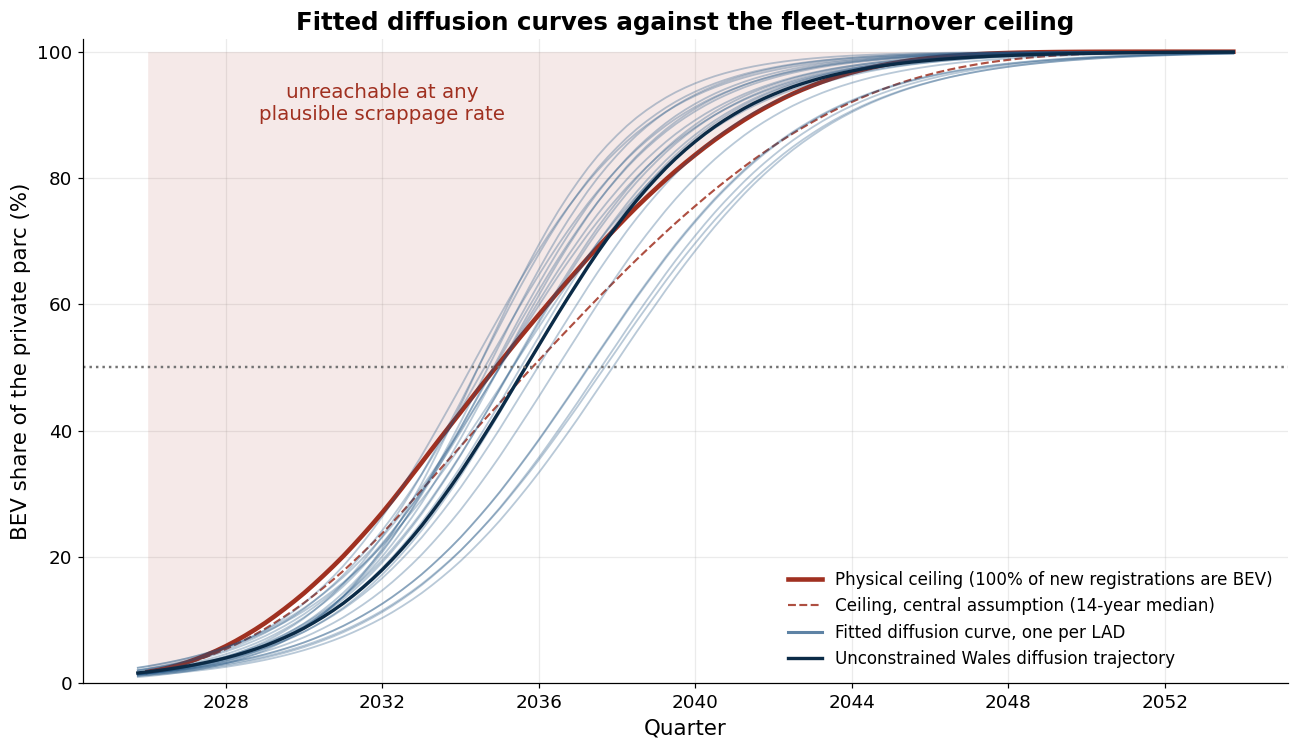


Saved: fig6_diffusion_turnover_reconciliation.png, diffusion_turnover_reconciliation.csv


In [ ]:
# ============================================================
# 11d. Reconciliation of diffusion against turnover  (paper Section 3.7, Figure 6)
#
# This is the central validity check, and it is what governs how every
# district-level projection in the paper may be read.
#
# The notebook holds two models of the same quantity. Stage 6 and Stage 11 fit
# logistic curves to the BEV share of the STOCK. Stage 8 propagates the stock
# through an age-structured survival model and reports what vehicle retirement
# permits. A stock share can move only as fast as vehicles are replaced, so if
# every new private vehicle registered from t0 were battery-electric the maximum
# attainable share at horizon t is
#
#     s_bar(t) = 1 - (1 - s0) * Pr[a car alive at t0 survives to t]      (Eq. 5)
#
# Equation 5 is a ceiling: it assumes complete switching of new registrations
# and no lagging authority, so any realised outcome lies at or below it. It is
# therefore also an admissibility test. A projection above s_bar(t) describes a
# fleet transformation faster than retirement permits, however well the model
# fits the observed points.
#
# The test is run against the MOST PERMISSIVE bound in the scrappage band, so a
# violation flag means the trajectory is inadmissible under every plausible
# parameterisation rather than merely under the central one.
# ============================================================

# ---------------------------------------------------------------- the two estimates
# Unconstrained Wales diffusion trajectory: the Stage 6b anchor fitted to history
# only, with no 2045 scenario target imposed.
DIFFUSION_2045 = 100.0 * float(logistic([t_terminal], nat_rate, nat_midpoint)[0])

# Age-structured turnover ceilings at the same quarter, one per scrappage assumption.
ceiling_by_median = {}
for _m, _f in vintage_forecasts.items():
    _w = _f.groupby("period", as_index=False).agg(bev=("bev_stock", "sum"),
                                                  tot=("total_stock", "sum"))
    ceiling_by_median[_m] = 100.0 * float(
        (_w.bev / _w.tot).loc[_w.period == POLICY_FORECAST_END].iloc[0])

CEILING_CENTRAL = ceiling_by_median[MEDIAN_SCRAPPAGE_AGE_YEARS]
MOST_PERMISSIVE_MEDIAN = min(ceiling_by_median, key=lambda k: k)   # shortest life = highest ceiling
CEILING_PERMISSIVE = ceiling_by_median[MOST_PERMISSIVE_MEDIAN]
EXCEEDANCE_PP = DIFFUSION_2045 - CEILING_CENTRAL

print("=" * 78)
print("RECONCILIATION OF DIFFUSION AGAINST TURNOVER  (paper Section 3.7)")
print("=" * 78)
print(f"Unconstrained Wales diffusion trajectory at {POLICY_FORECAST_END}: "
      f"{DIFFUSION_2045:.2f}%")
print(f"Turnover ceiling for that quarter (median scrappage "
      f"{MEDIAN_SCRAPPAGE_AGE_YEARS:.0f}y):        {CEILING_CENTRAL:.2f}%")
print(f"Prediction exceeds the central ceiling by:                          "
      f"{EXCEEDANCE_PP:+.2f} percentage points")
print()
print("Admissibility across the scrappage band (Equation 5):")
for _m in sorted(ceiling_by_median):
    _c = ceiling_by_median[_m]
    _verdict = "ADMISSIBLE" if DIFFUSION_2045 <= _c else "INADMISSIBLE"
    print(f"  median {_m:.0f}y -> ceiling {_c:6.2f}%   {_verdict}")

INADMISSIBLE_EVERYWHERE = DIFFUSION_2045 > CEILING_PERMISSIVE
print()
if INADMISSIBLE_EVERYWHERE:
    print(">>> FLAG: the trajectory exceeds the most permissive bound in the band "
          f"({CEILING_PERMISSIVE:.2f}%),")
    print(">>> so it is inadmissible under every plausible parameterisation.")
else:
    print(f">>> No flag: the trajectory is admissible under the most permissive "
          f"bound ({MOST_PERMISSIVE_MEDIAN:.0f}-year")
    print(f">>> median, ceiling {CEILING_PERMISSIVE:.2f}%), though it exceeds the "
          "central assumption. The")
    print(">>> flag is reserved for violation under every plausible "
          "parameterisation.")

# ---------------------------------------------------------------- why they disagree
print("\nTwo properties of the fitted curves explain the disagreement.")
print("  1. Saturation is imposed by the logistic functional form, not estimated:")
print(f"     every observation lies on the early limb (max observed share "
      f"{100*panel.adoption_share.max():.2f}%).")
print("  2. Diffusion describes an adoption decision, a property of the flow of new")
print("     registrations. Fitting it to stock conflates adoption with turnover, so")
print("     the rate parameter carries no behavioural interpretation.")
print("\nThe logistic forecasts are retained because they give interpretable, bounded")
print("scenario parameters, but they are reported subject to this ceiling. Any")
print("district-level 2045 figure derived from a stock-fitted diffusion curve inherits")
print("the same limitation and is bounded above by the turnover table.")

# ---------------------------------------------------------------- per-LAD midpoints
_ceiling_path = (vintage_wales.sort_values("period")
                 .assign(pct=lambda d: 100 * d.bev_share))
_ceiling_50 = next((p for p, v in zip(_ceiling_path.period, _ceiling_path.pct)
                    if v >= 50.0), None)
print(f"\nEarliest quarter at which a 50% stock share is physically possible: "
      f"{_ceiling_50}")

_check = hier_params.copy()
_check["midpoint_obj"] = [t0 + int(round(v)) for v in _check.midpoint_quarters]
_check["violates_turnover"] = [
    p.ordinal < _ceiling_50.ordinal if _ceiling_50 is not None else False
    for p in _check.midpoint_obj]
_n_bad = int(_check.violates_turnover.sum())
print(f"Hierarchical midpoints arriving before that quarter: {_n_bad} of {len(_check)}")
if _n_bad:
    print(">>> Those midpoints are not achievable at any plausible scrappage rate.")
    display(_check.loc[_check.violates_turnover,
                       ["name", "midpoint_period", "lag_vs_median_years"]].head(10))

# ---------------------------------------------------------------- Figure 6
# The ceiling is drawn over the Stage 9 horizon rather than stopping at 2045Q4,
# so the comparison stays visible through saturation. The extra quarters come
# from the same age-structured model, re-run to the later end date; nothing is
# extrapolated by hand.
FIG6_END = (EXTENDED_FORECAST_END if "EXTENDED_FORECAST_END" in globals()
            else POLICY_FORECAST_END)
_last = panel["period"].max()
_h = np.arange(0, FIG6_END.ordinal - _last.ordinal + 1)
_periods = [_last + int(q) for q in _h]
_x = [p.to_timestamp() for p in _periods]

_ceiling_cache = {}


def _ceiling_series(median_years):
    """Wales BEV-share ceiling path over the figure horizon, one scrappage assumption."""
    if median_years not in _ceiling_cache:
        try:
            f, _ = run_extended_model(median_years, FIG6_END)
        except Exception:                                  # noqa: BLE001
            f = vintage_forecasts[median_years]
        w = (f.groupby("period", as_index=False)
               .agg(bev=("bev_stock", "sum"), tot=("total_stock", "sum")))
        w["pct"] = 100 * w.bev / w.tot
        _ceiling_cache[median_years] = w.set_index("period").pct
    s = _ceiling_cache[median_years]
    return np.array([float(s.loc[p]) if p in s.index else np.nan for p in _periods])

_ceil_central = _ceiling_series(MEDIAN_SCRAPPAGE_AGE_YEARS)
_ceil_permissive = _ceiling_series(MOST_PERMISSIVE_MEDIAN)
_ok = np.isfinite(_ceil_permissive)

fig, ax = plt.subplots(figsize=(12, 7))

# Everything above the most permissive ceiling is unreachable at any plausible rate.
ax.fill_between(np.array(_x)[_ok], _ceil_permissive[_ok], 100,
                color="#a03020", alpha=0.10, linewidth=0)
ax.plot(np.array(_x)[_ok], _ceil_permissive[_ok], color="#a03020", linewidth=3.0,
        label="Physical ceiling (100% of new registrations are BEV)")
ax.plot(np.array(_x)[_ok], _ceil_central[_ok], color="#a03020", linewidth=1.4,
        linestyle="--", alpha=0.85,
        label=f"Ceiling, central assumption ({MEDIAN_SCRAPPAGE_AGE_YEARS:.0f}-year median)")
# Label the shaded region near its widest part, clear of the fitted curves.
_label_at = int(_ok.sum() * 0.22)
ax.text(np.array(_x)[_ok][_label_at], 95.0,
        "unreachable at any\nplausible scrappage rate",
        color="#a03020", ha="center", va="top", fontsize=13)

_offset = _last.ordinal - t0.ordinal
for _, row in hier_params.iterrows():
    ax.plot(_x, 100 * logistic_share(_h + _offset, row.rate_per_quarter,
                                     row.midpoint_quarters),
            color="#1a4f7f", alpha=0.30, linewidth=1.2)
ax.plot([], [], color="#1a4f7f", alpha=0.7, linewidth=2.0,
        label="Fitted diffusion curve, one per LAD")

# The Wales trajectory the Section 3.7 comparison is stated on.
_t_wales = np.array([q_index(p) for p in _periods], dtype=float)
ax.plot(_x, 100 * logistic(_t_wales, nat_rate, nat_midpoint),
        color="#0b2b47", linewidth=2.2,
        label="Unconstrained Wales diffusion trajectory")

ax.axhline(50, color="0.45", linestyle=":", linewidth=1.6)
ax.set_ylim(0, 102)
ax.set_xlabel("Quarter")
ax.set_ylabel("BEV share of the private parc (%)")
ax.set_title("Fitted diffusion curves against the fleet-turnover ceiling")
ax.legend(loc="lower right", frameon=False, fontsize=11)
fig.tight_layout()
fig.savefig(WORK / "fig6_diffusion_turnover_reconciliation.png", dpi=250,
            bbox_inches="tight")
plt.show()

reconciliation = pd.DataFrame([{
    "diffusion_2045_pct": DIFFUSION_2045,
    "ceiling_central_pct": CEILING_CENTRAL,
    "exceedance_pp": EXCEEDANCE_PP,
    "ceiling_most_permissive_pct": CEILING_PERMISSIVE,
    "inadmissible_under_every_assumption": INADMISSIBLE_EVERYWHERE}])
reconciliation.to_csv(WORK / "diffusion_turnover_reconciliation.csv", index=False)
print("\nSaved: fig6_diffusion_turnover_reconciliation.png, "
      "diffusion_turnover_reconciliation.csv")

## Stage 12 — Release build: populate CLEETS ontology v1.3.0 with every dataset

The pipeline above builds the KG in the **old pipeline vocabulary**
(`EVKeepershipObservation`, `forGeographicArea`, `geographyCode`, …). The
**released ontology v1.3.0** uses different terms (`EVKeepership`, `forLAD`,
`ladCode`), bundles its own SHACL shapes, and models population and density as
value objects (`hasPopulation` → `Population`) rather than observation
subtypes. This stage closes that gap: it re-expresses every source dataset in
the v1.3.0 vocabulary, validates the result against the shapes shipped
*inside* the ontology, and writes the single-file release
`cleets_kg_v130.ttl` (+ `.gz`).

| dataset (source) | old pipeline term | v1.3.0 term |
|---|---|---|
| VEH0132 private BEVs, cars and vans (DfT) | `EVKeepershipObservation` | `cleets:EVKeepership` |
| EVCI9001 charge points (DfT) | `EVChargerCountObservation` | `cleets:EVChargerCount` |
| keepers per charger (derived) | `ChargingAdequacyObservation` | `cleets:AdoptionRatioObservation` (`keeperChargerRatio`) |
| StatsWales population (WG) | `PopulationObservation` | `cleets:hasPopulation` → `cleets:Population` value object, one per LAD-year |
| ONS density | `PopulationDensityObservation` | `cleets:hasPopulationDensity` → `cleets:PopulationDensity` |
| WIMD 2025 income deciles (WG) | `DeprivationObservation` (LSOA, no time) | one LAD-level `cleets:IncomeDeprivation` (mean decile), dated 2025 — the shapes require exactly one LAD and one period per observation |
| VEH0105 private vehicle stock (DfT) | `PrivateVehicleStockObservation` | generic `cleets:Observation` + data-namespace `ObservableProperty` (no v1.3.0 class yet — **v1.4.0 candidate**) |
| per-1,000 and per-100k rates (derived) | `EVAdoptionObservation`, `EVChargerProvisionObservation` | generic `cleets:Observation`, same pattern |

Further decisions the cell makes explicit:

* **Quarters** become individuals typed both `cleets:Quarter` *and*
  `cleets:Time` (SHACL does not apply the OWL equivalence with OWL-Time), with
  integer `year`/`quarter` and the **dashed** `yearQuarter` label
  (`2025-Q2`) that `cleetssh:QuarterShape` requires.
* The ontology's **synthetic `cleetsex:` Cardiff examples are stripped** so no
  fabricated numbers sit beside real data in the release.
* Every migrated observation carries `prov:wasDerivedFrom` back to the
  pipeline observation, whose record-level provenance (dataset, row, column)
  lives in `cleets_kg.ttl` — the release stays clean while the audit trail
  survives.
* **Dataset-level provenance**: each source dataset is a first-class
  `dcat:Dataset` entity with its official government landing page
  (`dcat:landingPage`), publisher and a VoID class partition naming the
  CLEETS class it populates — e.g. **VEH0132 → `cleets:EVKeepership`** with a
  link to the DfT vehicle licensing statistics page. Every observation cites
  its dataset via `dcterms:source`; derived indicators cite *all* contributing
  datasets (e.g. keepers-per-charger → VEH0132 + EVCI9001).
* `DiffusionForecastObservation` and later scenario individuals are **not**
  migrated: they are regenerable model outputs, not datasets.

The ontology is loaded from its **published IRI `https://w3id.org/def/cleets`**
(content-negotiated for Turtle) and cross-checked — version must be 1.3.0 and
the SHACL shapes must be bundled — with an embedded byte-identical copy as the
offline fallback. After validation, the final cell downloads the release
artefacts (`cleets_kg_v130.ttl`, `.gz`, `.sha256`) so the KG can be published
alongside the ontology.

Run this any time after the VEH0105 cell in Stage 6; if run earlier, the
car-stock count simply reports 0. The printed statistics table is the one the
paper's knowledge-graph results section (§3.1) should quote.

In [ ]:
# ============================================================
# 12a-0. Offline fallback copy of the ontology, byte-identical
#        to the published index.ttl. Used only if the published
#        IRI cannot be fetched or fails the version/shape checks
#        in the next cell.
# ============================================================
ONTO_V130_TTL_EMBEDDED = r"""@prefix cleets: <https://w3id.org/def/cleets#> .
@prefix cleetsag: <https://w3id.org/def/cleets/agent#> .
@prefix cleetsex: <https://w3id.org/def/cleets/example#> .
@prefix cleetssh: <https://w3id.org/def/cleets/shapes#> .
@prefix dcterms: <http://purl.org/dc/terms/> .
@prefix geo: <http://www.opengis.net/ont/geosparql#> .
@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix schema: <https://schema.org/> .
@prefix sh: <http://www.w3.org/ns/shacl#> .
@prefix skos: <http://www.w3.org/2004/02/skos/core#> .
@prefix sosa: <http://www.w3.org/ns/sosa/> .
@prefix time: <http://www.w3.org/2006/time#> .
@prefix vann: <http://purl.org/vocab/vann/> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

dcterms:abstract a owl:AnnotationProperty .

dcterms:bibliographicCitation a owl:AnnotationProperty .

dcterms:created a owl:AnnotationProperty .

dcterms:creator a owl:AnnotationProperty .

dcterms:description a owl:AnnotationProperty .

dcterms:license a owl:AnnotationProperty .

dcterms:modified a owl:AnnotationProperty .

dcterms:publisher a owl:AnnotationProperty .

dcterms:title a owl:AnnotationProperty .

vann:preferredNamespacePrefix a owl:AnnotationProperty .

vann:preferredNamespaceUri a owl:AnnotationProperty .

skos:prefLabel a owl:AnnotationProperty .

cleets:correspondingAuthor a owl:AnnotationProperty ;
    rdfs:label "corresponding author"@en ;
    rdfs:comment "Identifies the corresponding author of the ontology. Retained because no widely adopted metadata vocabulary distinguishes the corresponding author from other creators."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> .

cleets:densityValue a owl:DatatypeProperty ;
    rdfs:label "densityValue" ;
    rdfs:comment "Population density in persons per square kilometre." ;
    rdfs:range xsd:decimal .

cleets:hasPopulation a owl:ObjectProperty ;
    rdfs:label "hasPopulation" ;
    rdfs:comment "Links an area to its population." ;
    rdfs:range cleets:Population .

cleets:hasPopulationDensity a owl:ObjectProperty ;
    rdfs:label "hasPopulationDensity" ;
    rdfs:comment "Links an area to its population density." ;
    rdfs:range cleets:PopulationDensity .

cleets:mappingRationale a owl:AnnotationProperty ;
    rdfs:label "mapping rationale"@en ;
    rdfs:comment "Explains an external ontology mapping or reuse decision."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> .

cleets:populationValue a owl:DatatypeProperty ;
    rdfs:label "populationValue" ;
    rdfs:comment "Population count." ;
    rdfs:range xsd:integer .

cleetsex:CardiffAdoptionRatio2025Q4 a cleets:AdoptionRatioObservation ;
    rdfs:label "Cardiff keepers-per-charger observation for 2025 Q4 (synthetic)"@en ;
    cleets:forLAD cleetsex:W06000015 ;
    cleets:forTime cleetsex:Period2025Q4 ;
    cleets:keeperChargerRatio 78.0 ;
    cleets:observesProperty cleets:KeeperChargerRatioProperty .

cleetsex:CardiffChargerCount2025Q4 a cleets:EVChargerCount ;
    rdfs:label "Cardiff charger-count observation for 2025 Q4 (synthetic)"@en ;
    cleets:chargerCountValue "412"^^xsd:nonNegativeInteger ;
    cleets:forLAD cleetsex:W06000015 ;
    cleets:forTime cleetsex:Period2025Q4 ;
    cleets:observesProperty cleets:EVChargerCountProperty .

cleetsex:CardiffEVKeepership2025Q4 a cleets:EVKeepership ;
    rdfs:label "Cardiff electric vehicle keepership observation for 2025 Q4 (synthetic)"@en ;
    cleets:forLAD cleetsex:W06000015 ;
    cleets:forTime cleetsex:Period2025Q4 ;
    cleets:keepershipValue "32140"^^xsd:nonNegativeInteger ;
    cleets:observesProperty cleets:EVKeepershipProperty .

cleetsex:CardiffIncomeDeprivation2025Q4 a cleets:IncomeDeprivation ;
    rdfs:label "Cardiff income-deprivation observation for 2025 Q4 (synthetic)"@en ;
    cleets:deprivationDecile 5 ;
    cleets:forLAD cleetsex:W06000015 ;
    cleets:forTime cleetsex:Period2025Q4 ;
    cleets:incomeDeprivationValue 0.14 ;
    cleets:observesProperty cleets:IncomeDeprivationProperty .

cleetssh:AdoptionRatioShape a sh:NodeShape ;
    sh:message "An adoption-ratio observation must report at least one of the two ratio values."@en ;
    sh:or ( [ sh:property [ sh:minCount 1 ;
                        sh:path cleets:keeperChargerRatio ] ] [ sh:property [ sh:minCount 1 ;
                        sh:path cleets:chargersPerKeeper ] ] ) ;
    sh:property [ sh:datatype xsd:decimal ;
            sh:maxCount 1 ;
            sh:minInclusive 0 ;
            sh:path cleets:keeperChargerRatio ],
        [ sh:datatype xsd:decimal ;
            sh:maxCount 1 ;
            sh:minInclusive 0 ;
            sh:path cleets:chargersPerKeeper ] ;
    sh:targetClass cleets:AdoptionRatioObservation .

cleetssh:EVChargerCountShape a sh:NodeShape ;
    sh:property [ sh:hasValue cleets:EVChargerCountProperty ;
            sh:path cleets:observesProperty ],
        [ sh:datatype xsd:nonNegativeInteger ;
            sh:maxCount 1 ;
            sh:minCount 1 ;
            sh:path cleets:chargerCountValue ] ;
    sh:targetClass cleets:EVChargerCount .

cleetssh:EVKeepershipShape a sh:NodeShape ;
    sh:property [ sh:datatype xsd:nonNegativeInteger ;
            sh:maxCount 1 ;
            sh:minCount 1 ;
            sh:path cleets:keepershipValue ],
        [ sh:hasValue cleets:EVKeepershipProperty ;
            sh:path cleets:observesProperty ] ;
    sh:targetClass cleets:EVKeepership .

cleetssh:EnglishLADShape a sh:NodeShape ;
    sh:property [ sh:message "An English local authority district requires a code beginning with E."@en ;
            sh:path cleets:ladCode ;
            sh:pattern "^E[0-9]{8}$" ] ;
    sh:targetClass cleets:EnglishLAD .

cleetssh:IncomeDeprivationShape a sh:NodeShape ;
    sh:property [ sh:hasValue cleets:IncomeDeprivationProperty ;
            sh:path cleets:observesProperty ],
        [ sh:datatype xsd:decimal ;
            sh:maxCount 1 ;
            sh:minCount 1 ;
            sh:path cleets:incomeDeprivationValue ],
        [ sh:datatype xsd:integer ;
            sh:maxCount 1 ;
            sh:maxInclusive 10 ;
            sh:minInclusive 1 ;
            sh:path cleets:deprivationDecile ] ;
    sh:targetClass cleets:IncomeDeprivation .

cleetssh:LADShape a sh:NodeShape ;
    sh:property [ sh:datatype xsd:string ;
            sh:maxCount 1 ;
            sh:message "A local authority district requires exactly one ONS statistical code."@en ;
            sh:minCount 1 ;
            sh:path cleets:ladCode ;
            sh:pattern "^[EWSN][0-9]{8}$" ],
        [ sh:minCount 1 ;
            sh:path rdfs:label ] ;
    sh:targetClass cleets:LAD .

cleetssh:ObservationShape a sh:NodeShape ;
    sh:property [ sh:class cleets:LAD ;
            sh:maxCount 1 ;
            sh:message "Every CLEETS observation must name exactly one local authority district."@en ;
            sh:minCount 1 ;
            sh:path cleets:forLAD ],
        [ sh:class cleets:Time ;
            sh:maxCount 1 ;
            sh:message "Every CLEETS observation must name exactly one reporting period."@en ;
            sh:minCount 1 ;
            sh:path cleets:forTime ],
        [ sh:class cleets:ObservableProperty ;
            sh:maxCount 1 ;
            sh:message "Every CLEETS observation must name exactly one observable property."@en ;
            sh:minCount 1 ;
            sh:path cleets:observesProperty ] ;
    sh:targetClass cleets:Observation .

cleetssh:QuarterShape a sh:NodeShape ;
    sh:property [ sh:datatype xsd:integer ;
            sh:maxCount 1 ;
            sh:maxInclusive 4 ;
            sh:minCount 1 ;
            sh:minInclusive 1 ;
            sh:path cleets:quarter ],
        [ sh:datatype xsd:integer ;
            sh:maxCount 1 ;
            sh:maxInclusive 2100 ;
            sh:minCount 1 ;
            sh:minInclusive 2000 ;
            sh:path cleets:year ],
        [ sh:datatype xsd:string ;
            sh:maxCount 1 ;
            sh:path cleets:yearQuarter ;
            sh:pattern "^[0-9]{4}-Q[1-4]$" ] ;
    sh:targetClass cleets:Quarter .

cleetssh:WelshLADShape a sh:NodeShape ;
    sh:property [ sh:message "A Welsh local authority district requires a code beginning with W."@en ;
            sh:path cleets:ladCode ;
            sh:pattern "^W[0-9]{8}$" ] ;
    sh:targetClass cleets:WelshLAD .

geo:Feature a owl:Class ;
    rdfs:isDefinedBy geo: .

cleets:Population a owl:Class ;
    rdfs:label "Population" ;
    rdfs:comment "Resident population associated with a geographic area." .

cleets:PopulationDensity a owl:Class ;
    rdfs:label "Population Density" ;
    rdfs:comment "Population per unit area." .

cleets:deprivationDecile a owl:DatatypeProperty,
        owl:FunctionalProperty ;
    rdfs:label "income-deprivation decile"@en ;
    rdfs:comment "The decile assigned to an area by the relevant deprivation index, where 1 denotes the most deprived tenth."@en ;
    rdfs:domain cleets:IncomeDeprivation ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:range [ a rdfs:Datatype ;
            owl:onDatatype xsd:integer ;
            owl:withRestrictions ( [ xsd:minInclusive 1 ] [ xsd:maxInclusive 10 ] ) ] .

cleets:hasFeatureOfInterest a owl:ObjectProperty ;
    rdfs:label "has feature of interest"@en ;
    rdfs:comment "Links an observation to the entity whose property is observed."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    owl:equivalentProperty sosa:hasFeatureOfInterest .

cleets:observedProperty a owl:ObjectProperty ;
    rdfs:label "observed property"@en ;
    rdfs:comment "Links an observation to the property that was observed."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    owl:equivalentProperty sosa:observedProperty .

cleets:phenomenonTime a owl:ObjectProperty ;
    rdfs:label "phenomenon time"@en ;
    rdfs:comment "Links an observation to the time to which the result applies."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    owl:equivalentProperty sosa:phenomenonTime .

cleets:quarter a owl:DatatypeProperty,
        owl:FunctionalProperty ;
    rdfs:label "calendar quarter number"@en ;
    rdfs:comment "The quarter number of a calendar year."@en ;
    rdfs:domain cleets:Quarter ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:range [ a rdfs:Datatype ;
            owl:onDatatype xsd:integer ;
            owl:withRestrictions ( [ xsd:minInclusive 1 ] [ xsd:maxInclusive 4 ] ) ] .

cleets:year a owl:DatatypeProperty,
        owl:FunctionalProperty ;
    rdfs:label "calendar year"@en ;
    rdfs:comment "The calendar year associated with a reporting period, as a four-digit integer. xsd:gYear is deliberately avoided: it is outside the OWL 2 datatype map and is rejected by HermiT."@en ;
    rdfs:domain cleets:Time ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:range [ a rdfs:Datatype ;
            owl:onDatatype xsd:integer ;
            owl:withRestrictions ( [ xsd:minInclusive 2000 ] [ xsd:maxInclusive 2100 ] ) ] .

cleets:yearQuarter a owl:DatatypeProperty,
        owl:FunctionalProperty ;
    rdfs:label "year-quarter label"@en ;
    rdfs:comment "A human-readable year-quarter label, such as 2025-Q4."@en ;
    rdfs:domain cleets:Quarter ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:range xsd:string .

cleetsag:AbhinavWadhwa a schema:Person ;
    rdfs:label "Abhinav Wadhwa"@en ;
    schema:affiliation cleetsag:DiscoveryPartnersInstitute ;
    schema:name "Abhinav Wadhwa" .

cleetsag:AshishSharma a schema:Person ;
    rdfs:label "Ashish Sharma"@en ;
    schema:affiliation cleetsag:DiscoveryPartnersInstitute ;
    schema:name "Ashish Sharma" .

cleetsag:CLEETSDataScienceGroup a schema:Organization ;
    rdfs:label "CLEETS Data Science Group"@en ;
    schema:name "CLEETS Data Science Group" ;
    schema:parentOrganization cleetsag:CardiffUniversity .

cleetsag:ChicagoMetropolitanAgencyForPlanning a schema:GovernmentOrganization ;
    rdfs:label "Chicago Metropolitan Agency for Planning"@en ;
    schema:address [ a schema:PostalAddress ;
            schema:addressCountry "US" ;
            schema:addressLocality "Chicago" ;
            schema:addressRegion "IL" ] ;
    schema:name "Chicago Metropolitan Agency for Planning" ;
    schema:url <https://cmap.illinois.gov/> .

cleetsag:DimitrisPotoglou a schema:Person ;
    rdfs:label "Dimitris Potoglou"@en ;
    schema:affiliation cleetsag:CardiffGeographyPlanning ;
    schema:name "Dimitris Potoglou" .

cleetsag:FulongYao a schema:Person ;
    rdfs:label "Fulong Yao"@en ;
    schema:affiliation cleetsag:CardiffComputerScience ;
    schema:name "Fulong Yao" .

cleetsag:IllinoisAppliedResearchInstitute a schema:Organization ;
    rdfs:label "University of Illinois, Applied Research Institute"@en ;
    schema:address [ a schema:PostalAddress ;
            schema:addressCountry "US" ;
            schema:addressLocality "Chicago" ;
            schema:addressRegion "IL" ] ;
    schema:name "Applied Research Institute" ;
    schema:parentOrganization cleetsag:UniversityOfIllinois .

cleetsag:NoraBeck a schema:Person ;
    rdfs:label "Nora Beck"@en ;
    schema:affiliation cleetsag:ChicagoMetropolitanAgencyForPlanning,
        cleetsag:DiscoveryPartnersInstitute ;
    schema:name "Nora Beck" .

cleetsag:OmerRana a schema:Person ;
    rdfs:label "Omer Rana"@en ;
    schema:affiliation cleetsag:CardiffComputerScience ;
    schema:name "Omer Rana" .

cleetsag:PaulHaggar a schema:Person ;
    rdfs:label "Paul Haggar"@en ;
    schema:affiliation cleetsag:CardiffGeographyPlanning ;
    schema:name "Paul Haggar" .

cleetsag:UniversityOfIllinois a schema:CollegeOrUniversity ;
    rdfs:label "University of Illinois"@en ;
    schema:name "University of Illinois" ;
    schema:url <https://www.uillinois.edu/> .

cleetsag:UniversityOfIllinoisUrbanaChampaign a schema:CollegeOrUniversity ;
    rdfs:label "University of Illinois Urbana-Champaign"@en ;
    schema:name "University of Illinois Urbana-Champaign" ;
    schema:url <https://illinois.edu/> .

cleets:ChargersPerKeeperProperty a cleets:ObservableProperty ;
    rdfs:label "chargers per keeper (observable property)"@en ;
    rdfs:comment "The number of charging devices divided by the number of electric vehicle keepers for the same area and period."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> .

cleets:EnglishLAD a owl:Class ;
    rdfs:label "English local authority district"@en ;
    rdfs:comment "A local authority district in England, including unitary authorities, metropolitan and non-metropolitan districts and London boroughs."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:subClassOf cleets:LAD .

cleets:WelshLAD a owl:Class ;
    rdfs:label "Welsh local authority district"@en ;
    rdfs:comment "A principal local authority area in Wales."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:subClassOf cleets:LAD ;
    owl:disjointWith cleets:EnglishLAD .

cleets:chargerCountValue a owl:DatatypeProperty,
        owl:FunctionalProperty ;
    rdfs:label "charger-count value"@en ;
    rdfs:comment "The number of electric vehicle charging devices reported by a charger-count observation."@en ;
    rdfs:domain cleets:EVChargerCount ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:range xsd:nonNegativeInteger ;
    rdfs:subPropertyOf cleets:hasSimpleResult .

cleets:chargersPerKeeper a owl:DatatypeProperty,
        owl:FunctionalProperty ;
    rdfs:label "chargers-per-keeper value"@en ;
    rdfs:comment "The number of charging devices divided by the number of electric vehicle keepers for the same area and period. Reciprocal of cleets:keeperChargerRatio and recorded only where a source reports it directly."@en ;
    rdfs:domain cleets:AdoptionRatioObservation ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:range xsd:decimal ;
    rdfs:subPropertyOf cleets:hasSimpleResult .

cleets:incomeDeprivationValue a owl:DatatypeProperty,
        owl:FunctionalProperty ;
    rdfs:label "income-deprivation value"@en ;
    rdfs:comment "A numeric income-deprivation value reported for an area."@en ;
    rdfs:domain cleets:IncomeDeprivation ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:range xsd:decimal ;
    rdfs:subPropertyOf cleets:hasSimpleResult .

cleets:keeperChargerRatio a owl:DatatypeProperty,
        owl:FunctionalProperty ;
    rdfs:label "keepers-per-charger value"@en ;
    rdfs:comment "The number of electric vehicle keepers divided by the number of charging devices for the same area and period."@en ;
    rdfs:domain cleets:AdoptionRatioObservation ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:range xsd:decimal ;
    rdfs:subPropertyOf cleets:hasSimpleResult .

cleets:keepershipValue a owl:DatatypeProperty,
        owl:FunctionalProperty ;
    rdfs:label "keepership value"@en ;
    rdfs:comment "The number of registered electric vehicle keepers reported by a keepership observation."@en ;
    rdfs:domain cleets:EVKeepership ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:range xsd:nonNegativeInteger ;
    rdfs:subPropertyOf cleets:hasSimpleResult .

cleetsag:CardiffGeographyPlanning a schema:Organization ;
    rdfs:label "Cardiff University, School of Geography and Planning"@en ;
    schema:name "School of Geography and Planning" ;
    schema:parentOrganization cleetsag:CardiffUniversity .

cleetsag:NaeimaHamed a schema:Person ;
    rdfs:label "Naeima Hamed"@en ;
    schema:affiliation cleetsag:CardiffComputerScience,
        cleetsag:IllinoisAppliedResearchInstitute ;
    schema:name "Naeima Hamed" .

cleets:KeeperChargerRatioProperty a cleets:ObservableProperty ;
    rdfs:label "keepers per charger (observable property)"@en ;
    rdfs:comment "The number of electric vehicle keepers divided by the number of charging devices for the same area and period."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> .

cleets:ladCode a owl:DatatypeProperty,
        owl:FunctionalProperty ;
    rdfs:label "local authority district code"@en ;
    rdfs:comment "The official statistical code assigned to a local authority district, for example W06000015."@en ;
    rdfs:domain cleets:LAD ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:range xsd:string .

cleetsag:CardiffComputerScience a schema:Organization ;
    rdfs:label "Cardiff University, School of Computer Science and Informatics"@en ;
    schema:name "School of Computer Science and Informatics" ;
    schema:parentOrganization cleetsag:CardiffUniversity .

cleetsag:CardiffUniversity a schema:CollegeOrUniversity ;
    rdfs:label "Cardiff University"@en ;
    schema:address [ a schema:PostalAddress ;
            schema:addressCountry "GB" ;
            schema:addressLocality "Cardiff" ] ;
    schema:name "Cardiff University" ;
    schema:url <https://www.cardiff.ac.uk/> .

cleetsag:DiscoveryPartnersInstitute a schema:Organization ;
    rdfs:label "University of Illinois Urbana-Champaign, Discovery Partners Institute"@en ;
    schema:address [ a schema:PostalAddress ;
            schema:addressCountry "US" ;
            schema:addressLocality "Chicago" ;
            schema:addressRegion "IL" ] ;
    schema:name "Discovery Partners Institute" ;
    schema:parentOrganization cleetsag:UniversityOfIllinoisUrbanaChampaign ;
    schema:url <https://dpi.uillinois.edu/> .

cleets:EVChargerCount a owl:Class ;
    rdfs:label "Electric vehicle charger-count observation"@en ;
    rdfs:comment "An observation reporting the number of electric vehicle charging devices for an area and reporting period."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:subClassOf [ a owl:Restriction ;
            owl:onClass cleets:LAD ;
            owl:onProperty cleets:forLAD ;
            owl:qualifiedCardinality "1"^^xsd:nonNegativeInteger ],
        [ a owl:Restriction ;
            owl:onClass cleets:Time ;
            owl:onProperty cleets:forTime ;
            owl:qualifiedCardinality "1"^^xsd:nonNegativeInteger ],
        [ a owl:Restriction ;
            owl:hasValue cleets:EVChargerCountProperty ;
            owl:onProperty cleets:observesProperty ],
        [ a owl:Restriction ;
            owl:onDataRange xsd:nonNegativeInteger ;
            owl:onProperty cleets:chargerCountValue ;
            owl:qualifiedCardinality "1"^^xsd:nonNegativeInteger ],
        cleets:Observation .

cleets:EVChargerCountProperty a cleets:ObservableProperty ;
    rdfs:label "electric vehicle charger count (observable property)"@en ;
    rdfs:comment "The number of electric vehicle charging devices for an area and reporting period."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> .

cleets:EVKeepership a owl:Class ;
    rdfs:label "Electric vehicle keepership observation"@en ;
    rdfs:comment "An observation reporting the number of registered electric vehicle keepers for an area and reporting period."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:subClassOf [ a owl:Restriction ;
            owl:onClass cleets:LAD ;
            owl:onProperty cleets:forLAD ;
            owl:qualifiedCardinality "1"^^xsd:nonNegativeInteger ],
        [ a owl:Restriction ;
            owl:onClass cleets:Time ;
            owl:onProperty cleets:forTime ;
            owl:qualifiedCardinality "1"^^xsd:nonNegativeInteger ],
        [ a owl:Restriction ;
            owl:hasValue cleets:EVKeepershipProperty ;
            owl:onProperty cleets:observesProperty ],
        [ a owl:Restriction ;
            owl:onDataRange xsd:nonNegativeInteger ;
            owl:onProperty cleets:keepershipValue ;
            owl:qualifiedCardinality "1"^^xsd:nonNegativeInteger ],
        cleets:Observation .

cleets:EVKeepershipProperty a cleets:ObservableProperty ;
    rdfs:label "electric vehicle keepership (observable property)"@en ;
    rdfs:comment "The number of registered electric vehicle keepers for an area and reporting period."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> .

cleets:IncomeDeprivationProperty a cleets:ObservableProperty ;
    rdfs:label "income deprivation (observable property)"@en ;
    rdfs:comment "An income-deprivation measure for an area and reporting period."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> .

cleets:Quarter a owl:Class ;
    rdfs:label "Calendar quarter"@en ;
    rdfs:comment "A three-month calendar reporting interval."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:subClassOf time:Interval ;
    cleets:mappingRationale "Subsumption of cleets:Time follows from time:Interval and is therefore not asserted."@en .

cleetsex:Period2025Q4 a cleets:Quarter ;
    rdfs:label "Fourth quarter of 2025"@en ;
    time:hasBeginning [ a time:Instant ;
            time:inXSDDateTimeStamp "2025-10-01T00:00:00Z"^^xsd:dateTimeStamp ] ;
    time:hasEnd [ a time:Instant ;
            time:inXSDDateTimeStamp "2025-12-31T23:59:59Z"^^xsd:dateTimeStamp ] ;
    cleets:quarter 4 ;
    cleets:year 2025 ;
    cleets:yearQuarter "2025-Q4" .

cleetsex:W06000015 a cleets:WelshLAD ;
    rdfs:label "Cardiff"@en ;
    rdfs:seeAlso <https://statistics.data.gov.uk/id/statistical-geography/W06000015> ;
    skos:prefLabel "Cardiff"@en ;
    cleets:ladCode "W06000015" .

cleets:AdoptionRatioObservation a owl:Class ;
    rdfs:label "Electric vehicle adoption-ratio observation"@en ;
    rdfs:comment "An observation reporting the relationship between electric vehicle keepership and charging infrastructure."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:subClassOf [ a owl:Restriction ;
            owl:onClass cleets:LAD ;
            owl:onProperty cleets:forLAD ;
            owl:qualifiedCardinality "1"^^xsd:nonNegativeInteger ],
        [ a owl:Restriction ;
            owl:onClass cleets:Time ;
            owl:onProperty cleets:forTime ;
            owl:qualifiedCardinality "1"^^xsd:nonNegativeInteger ],
        [ a owl:Restriction ;
            owl:onProperty cleets:observesProperty ;
            owl:someValuesFrom [ a owl:Class ;
                    owl:oneOf ( cleets:KeeperChargerRatioProperty cleets:ChargersPerKeeperProperty ) ] ],
        cleets:Observation .

cleets:IncomeDeprivation a owl:Class ;
    rdfs:label "Income-deprivation observation"@en ;
    rdfs:comment "An observation reporting an income-deprivation measure for an area and reporting period."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:subClassOf [ a owl:Restriction ;
            owl:onClass cleets:LAD ;
            owl:onProperty cleets:forLAD ;
            owl:qualifiedCardinality "1"^^xsd:nonNegativeInteger ],
        [ a owl:Restriction ;
            owl:onClass cleets:Time ;
            owl:onProperty cleets:forTime ;
            owl:qualifiedCardinality "1"^^xsd:nonNegativeInteger ],
        [ a owl:Restriction ;
            owl:hasValue cleets:IncomeDeprivationProperty ;
            owl:onProperty cleets:observesProperty ],
        [ a owl:Restriction ;
            owl:onDataRange xsd:decimal ;
            owl:onProperty cleets:incomeDeprivationValue ;
            owl:qualifiedCardinality "1"^^xsd:nonNegativeInteger ],
        cleets:Observation .

cleets:forLAD a owl:FunctionalProperty,
        owl:ObjectProperty ;
    rdfs:label "for local authority district"@en ;
    rdfs:comment "Links a CLEETS observation to the local authority district to which it applies. Functional: an observation reports one district."@en ;
    rdfs:domain cleets:Observation ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:range cleets:LAD ;
    rdfs:subPropertyOf cleets:hasFeatureOfInterest ;
    cleets:mappingRationale "Specialises the CLEETS alias of sosa:hasFeatureOfInterest for local authority districts."@en .

cleets:forTime a owl:FunctionalProperty,
        owl:ObjectProperty ;
    rdfs:label "for observation period"@en ;
    rdfs:comment "Links a CLEETS observation to its temporal reporting period. Functional: an observation reports one period."@en ;
    rdfs:domain cleets:Observation ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:range cleets:Time ;
    rdfs:subPropertyOf cleets:phenomenonTime ;
    cleets:mappingRationale "Specialises the CLEETS alias of sosa:phenomenonTime for CLEETS reporting periods."@en .

cleets:hasSimpleResult a owl:DatatypeProperty ;
    rdfs:label "has simple result"@en ;
    rdfs:comment "Links an observation to a literal result value."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    owl:equivalentProperty sosa:hasSimpleResult .

cleets:ObservableProperty a owl:Class ;
    rdfs:label "Observable property"@en ;
    rdfs:comment "A property that can be observed in a CLEETS observation."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    owl:equivalentClass sosa:ObservableProperty ;
    cleets:mappingRationale "Ontology-local alias of sosa:ObservableProperty."@en .

cleets:Time a owl:Class ;
    rdfs:label "CLEETS time entity"@en ;
    rdfs:comment "A temporal entity used to identify the period associated with a CLEETS observation."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    owl:equivalentClass time:TemporalEntity ;
    cleets:mappingRationale "Ontology-local alias of time:TemporalEntity, on the same grounds as cleets:Observation."@en .

cleets:Observation a owl:Class ;
    rdfs:label "CLEETS observation"@en ;
    rdfs:comment "An observation concerning electric vehicle adoption, charging infrastructure, socioeconomic conditions or a related indicator."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    owl:equivalentClass sosa:Observation ;
    cleets:mappingRationale "Ontology-local alias of sosa:Observation. The alias keeps CLEETS identifiers stable across SOSA revisions; the equivalence axiom guarantees that CLEETS data entails SOSA data under any OWL reasoner."@en .

cleets:observesProperty a owl:FunctionalProperty,
        owl:ObjectProperty ;
    rdfs:label "observes property"@en ;
    rdfs:comment "Links a CLEETS observation to the property being observed."@en ;
    rdfs:domain cleets:Observation ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:range cleets:ObservableProperty ;
    rdfs:subPropertyOf cleets:observedProperty ;
    cleets:mappingRationale "Specialises the CLEETS alias of sosa:observedProperty."@en .

cleets:LAD a owl:Class ;
    rdfs:label "Local authority district"@en ;
    rdfs:comment "A UK local authority district or equivalent administrative area."@en ;
    rdfs:isDefinedBy <https://w3id.org/def/cleets> ;
    rdfs:subClassOf geo:Feature ;
    cleets:mappingRationale "A local authority district is a geographic feature, but not every geographic feature is a local authority district, so subsumption is used rather than equivalence."@en .

<https://w3id.org/def/cleets> a owl:Ontology ;
    dcterms:abstract "The CLEETS ontology provides a lightweight semantic model for integrating electric vehicle keepership, charging infrastructure, income deprivation and temporal data at local-authority level. It is independently governed and imports SOSA and OWL-Time, exposing ontology-local aliases of selected imported terms through explicit OWL equivalence axioms so that CLEETS terms remain stable under external vocabulary change while entailing the imported terms."@en ;
    dcterms:bibliographicCitation "Naeima Hamed, Fulong Yao, Dimitris Potoglou, Paul Haggar, Ashish Sharma, Abhinav Wadhwa, Nora Beck and Omer Rana. CLEETS Electric Vehicle Adoption Ontology."@en ;
    dcterms:created "2026-07-22"^^xsd:date ;
    dcterms:creator cleetsag:AbhinavWadhwa,
        cleetsag:AshishSharma,
        cleetsag:DimitrisPotoglou,
        cleetsag:FulongYao,
        cleetsag:NaeimaHamed,
        cleetsag:NoraBeck,
        cleetsag:OmerRana,
        cleetsag:PaulHaggar ;
    dcterms:description "An ontology for representing electric vehicle adoption, charging infrastructure, income deprivation and quarterly observations for UK local authority districts."@en ;
    dcterms:license <https://creativecommons.org/licenses/by/4.0/> ;
    dcterms:modified "2026-08-03"^^xsd:date ;
    dcterms:publisher cleetsag:CLEETSDataScienceGroup ;
    dcterms:title "CLEETS Electric Vehicle Adoption Ontology"@en ;
    vann:preferredNamespacePrefix "cleets" ;
    vann:preferredNamespaceUri "https://w3id.org/def/cleets#" ;
    owl:imports <http://www.w3.org/2006/time>,
        sosa: ;
    owl:priorVersion <https://w3id.org/def/cleets/version/1.2.0> ;
    owl:versionIRI <https://w3id.org/def/cleets/version/1.3.0> ;
    owl:versionInfo "1.3.0" ;
    cleets:correspondingAuthor cleetsag:NaeimaHamed .

[] a owl:AllDisjointClasses ;
    owl:members ( cleets:EVKeepership cleets:EVChargerCount cleets:IncomeDeprivation cleets:AdoptionRatioObservation ) .

[] a owl:AllDifferent ;
    owl:distinctMembers ( cleets:EVKeepershipProperty cleets:EVChargerCountProperty cleets:IncomeDeprivationProperty cleets:KeeperChargerRatioProperty cleets:ChargersPerKeeperProperty ) .

"""
print(f"fallback copy embedded: {len(ONTO_V130_TTL_EMBEDDED):,} characters")


fallback copy embedded: 31,020 characters


In [ ]:
# ============================================================
# 12a. Load CLEETS ontology v1.3.0 from its published IRI
#
# The ontology is published at https://w3id.org/def/cleets. This cell
# content-negotiates for Turtle, then verifies that what came back is
# usable for the release build:
#   - it parses,
#   - owl:versionInfo is 1.3.0 (a different version is a hard stop:
#     the migration below is written against the 1.3.0 vocabulary),
#   - the SHACL shapes (cleetssh:) are bundled - Stage 12b validates
#     against them,
#   - the Population / PopulationDensity value-object terms exist.
# If the fetch fails or any check fails, it falls back to the embedded
# copy below, which is byte-identical to the submitted index.ttl.
# ============================================================
import urllib.request

from rdflib import Graph
from rdflib.namespace import OWL, RDF, SH

ONTO_IRI = "https://w3id.org/def/cleets"

def _fetch_published_ontology(iri):
    req = urllib.request.Request(iri, headers={
        "Accept": "text/turtle, application/x-turtle;q=0.9, "
                  "application/rdf+xml;q=0.8, */*;q=0.1",
        "User-Agent": "CLEETS-release-notebook/1.0 (rdflib)"})
    with urllib.request.urlopen(req, timeout=90) as r:
        body  = r.read()
        ctype = (r.headers.get("Content-Type") or "").split(";")[0].strip().lower()
        final = r.geturl()
    fmt = {"text/turtle": "turtle", "application/x-turtle": "turtle",
           "application/rdf+xml": "xml", "application/xml": "xml",
           "text/html": None}.get(ctype, "turtle")
    if fmt is None:
        raise RuntimeError(
            f"{final} returned {ctype} (a documentation page, not RDF). "
            "Check the w3id content-negotiation rules for text/turtle.")
    g = Graph().parse(data=body.decode("utf-8"), format=fmt)
    return g, final, ctype

def _check_ontology(g, origin):
    problems = []
    versions = [str(o) for o in g.objects(None, OWL.versionInfo)]
    if "1.3.0" not in versions:
        problems.append(f"owl:versionInfo is {versions or 'absent'}, expected 1.3.0 - "
                        "the migration below targets the 1.3.0 vocabulary")
    n_shapes = len(set(g.subjects(RDF.type, SH.NodeShape)))
    if n_shapes == 0:
        problems.append("no sh:NodeShape found - the published file does not bundle "
                        "the cleetssh: shapes that Stage 12b validates against")
    from rdflib import URIRef
    C = "https://w3id.org/def/cleets#"
    for term in ("Population", "PopulationDensity", "hasPopulation"):
        if (URIRef(C + term), None, None) not in g:
            problems.append(f"cleets:{term} missing from the published file")
    if problems:
        raise RuntimeError(f"published ontology at {origin} unusable:\n  - "
                           + "\n  - ".join(problems))
    return n_shapes

ONTO_SOURCE = None
try:
    _g, _final, _ctype = _fetch_published_ontology(ONTO_IRI)
    _n_sh = _check_ontology(_g, _final)
    # Smoke-test the bundled SHACL shapes before trusting the published copy.
    # The RDF/XML representation served by content negotiation currently
    # mis-serialises the sh:or list in cleetssh:AdoptionRatioShape, and
    # pySHACL raises ShapeLoadError when the shapes graph is loaded. If that
    # happens we fall back to the embedded byte-identical Turtle copy.
    from pyshacl import validate as _shape_smoke
    _shape_smoke(data_graph=bind_all(Graph()), shacl_graph=_g, inference="none")
    ONTO_V130_TTL = _g.serialize(format="turtle")
    ONTO_SOURCE = f"published IRI {ONTO_IRI} ({_ctype}, {_n_sh} shapes)"
except Exception as _e:
    print(f"could not use the published ontology:\n  {_e}\n"
          f"falling back to the embedded copy.\n")
    ONTO_V130_TTL = ONTO_V130_TTL_EMBEDDED
    ONTO_SOURCE = "embedded copy (fallback)"

print(f"ontology v1.3.0 loaded from: {ONTO_SOURCE}")
print(f"{len(ONTO_V130_TTL):,} characters of Turtle")


could not use the published ontology:
  A Shape-Expecting & List-Expecting predicate should get a well-formed RDF list with 1 or more members.
For reference, see https://www.w3.org/TR/shacl/#shapes-recursion
falling back to the embedded copy.

ontology v1.3.0 loaded from: embedded copy (fallback)
31,020 characters of Turtle


In [ ]:
# ============================================================
# 12b. Populate ontology v1.3.0 with every dataset in this notebook
#
# Reads the OLD-vocabulary knowledge graph held in memory as `KG`
# (Stages 2a-2d, plus the VEH0105 car-stock cell if it has run) and
# re-expresses every source-dataset observation in the released
# CLEETS v1.3.0 vocabulary bundled in ONTO_V130_TTL, then validates
# the result against the SHACL shapes shipped INSIDE that ontology
# and serialises the release file.
#
# Vocabulary mapping (old pipeline term -> v1.3.0 term)
#   EVKeepershipObservation   -> cleets:EVKeepership
#   EVChargerCountObservation -> cleets:EVChargerCount
#   ChargingAdequacyObservation (evsPerChargePoint = keepers/charger)
#                             -> cleets:AdoptionRatioObservation
#                                (cleets:keeperChargerRatio)
#   DeprivationObservation (LSOA income deciles)
#                             -> one LAD-level cleets:IncomeDeprivation
#                                (mean decile; shape requires exactly one
#                                 incomeDeprivationValue and one period)
#   PopulationObservation     -> cleets:hasPopulation ->
#                                cleets:Population value object
#   PopulationDensityObservation
#                             -> cleets:hasPopulationDensity ->
#                                cleets:PopulationDensity value object
#   PrivateVehicleStockObservation, EVAdoptionObservation,
#   EVChargerProvisionObservation
#                             -> generic cleets:Observation with a data-
#                                namespace cleets:ObservableProperty
#                                (no dedicated v1.3.0 class exists yet;
#                                 candidates for v1.4.0)
#   forGeographicArea/geographyCode/geographyName
#                             -> cleets:forLAD / cleets:ladCode / rdfs:label
#   Time (xsd:gYear year, "Q2") -> cleets:Quarter + cleets:Time with integer
#                                cleets:year / cleets:quarter and a DASHED
#                                cleets:yearQuarter ("2025-Q2"), as
#                                cleetssh:QuarterShape requires
#
# NOT migrated (regenerable model outputs, not datasets):
#   DiffusionForecastObservation and later forecast/scenario individuals.
# The synthetic cleetsex: examples bundled in the ontology are STRIPPED
# from the release so no fabricated Cardiff numbers sit beside real data.
# ============================================================
import gzip
import re as _re
from pathlib import Path

from rdflib import Graph, Literal, Namespace, URIRef
from rdflib.namespace import DCTERMS, OWL, RDF, RDFS, SKOS, XSD
from rdflib.term import BNode

try:
    from pyshacl import validate as _shacl_validate
except ImportError:                                   # Colab first run
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", "pyshacl"],
                   check=True)
    from pyshacl import validate as _shacl_validate

C130   = Namespace("https://w3id.org/def/cleets#")          # same base as CLEETS
RELDAT = Namespace("https://w3id.org/def/cleets/data#")     # release ABox
_TIME  = Namespace("http://www.w3.org/2006/time#")
_PROV  = Namespace("http://www.w3.org/ns/prov#")
_DCAT  = Namespace("http://www.w3.org/ns/dcat#")
_VOID  = Namespace("http://rdfs.org/ns/void#")
_WORK  = WORK if "WORK" in dir() else Path("cleets_out"); Path(_WORK).mkdir(exist_ok=True)

# ---- 1. parse the ontology and strip the synthetic examples ---------
onto = Graph().parse(data=ONTO_V130_TTL, format="turtle")

def _strip_example_individuals(g):
    """Remove cleetsex: individuals (and their anonymous sub-nodes)."""
    ex = "https://w3id.org/def/cleets/example#"
    def _rm(s):
        for p, o in list(g.predicate_objects(s)):
            g.remove((s, p, o))
            if isinstance(o, BNode):
                _rm(o)
    n = 0
    for s in {s for s in g.subjects()
              if isinstance(s, URIRef) and str(s).startswith(ex)}:
        _rm(s); n += 1
    return n

_n_ex = _strip_example_individuals(onto)
print(f"ontology v1.3.0 parsed: {len(onto):,} triples "
      f"(after removing {_n_ex} synthetic cleetsex: individuals)")

REL = Graph()
for _p, _n in dict(cleets=C130, cleetsdata=RELDAT,
                   cleetsag=Namespace("https://w3id.org/def/cleets/agent#"),
                   cleetssh=Namespace("https://w3id.org/def/cleets/shapes#"),
                   sosa=Namespace("http://www.w3.org/ns/sosa/"),
                   dcat=_DCAT, void=_VOID,
                   time=_TIME, prov=_PROV, dcterms=DCTERMS, skos=SKOS,
                   owl=OWL, xsd=XSD, geo=Namespace("http://www.opengis.net/ont/geosparql#"),
                   sh=Namespace("http://www.w3.org/ns/shacl#"),
                   schema=Namespace("https://schema.org/")).items():
    REL.bind(_p, _n)
REL += onto                                    # TBox + shapes + agents travel with the data

# ---- 2. dataset provenance: source datasets as first-class entities -
# Every observation cites its source dataset (dcterms:source), and each
# dataset entity carries its official government landing page
# (dcat:landingPage) plus a VoID class partition naming the CLEETS class
# it populates - e.g. VEH0132 -> cleets:EVKeepership.
# Landing pages verified 2026-08: gov.uk pages live; the old
# statswales.gov.wales catalogue now redirects to stats.gov.wales.
_DATASET_META = {
    "VEH0132": (
        "VEH0132: licensed ultra low emission vehicles by body type, fuel type, "
        "keepership and local authority (All body types x Battery Electric x Private extract; cars and vans aggregated)",
        "Department for Transport / Driver and Vehicle Licensing Agency",
        "https://www.gov.uk/government/statistical-data-sets/vehicle-licensing-statistics-data-tables",
        C130.EVKeepership),
    "VEH0105": (
        "VEH0105: licensed vehicles by body type, fuel type, keepership and "
        "local authority (All body types x Total fuel x Private extract)",
        "Department for Transport / Driver and Vehicle Licensing Agency",
        "https://www.gov.uk/government/statistical-data-sets/vehicle-licensing-statistics-data-tables",
        None),
    "EVCI9001": (
        "EVCI9001: public electric vehicle charging device counts by local authority",
        "Department for Transport / Office for Zero Emission Vehicles",
        "https://www.gov.uk/government/collections/electric-vehicle-charging-infrastructure-statistics",
        C130.EVChargerCount),
    "StatsWalesPopulation": (
        "Population estimates by local authority and year (mid-year estimates)",
        "Welsh Government",
        "https://stats.gov.wales/en-GB/topic/71/people-identity-equality",
        C130.Population),
    "ONSDensity": (
        "Population density (persons per square kilometre), England and Wales",
        "Office for National Statistics",
        "https://www.ons.gov.uk/peoplepopulationandcommunity/populationandmigration/populationestimates",
        C130.PopulationDensity),
    "WIMD2025": (
        "Welsh Index of Multiple Deprivation, income domain deciles by LSOA",
        "Welsh Government",
        "https://www.gov.wales/welsh-index-multiple-deprivation",
        C130.IncomeDeprivation),
}

def _dataset_node(key):
    title, publisher, landing, populates = _DATASET_META[key]
    u = RELDAT[f"dataset/{key}"]
    if (u, RDF.type, None) not in REL:
        REL.add((u, RDF.type, _DCAT.Dataset))
        REL.add((u, RDF.type, _PROV.Entity))
        REL.add((u, DCTERMS.title, Literal(title, lang="en")))
        REL.add((u, DCTERMS.publisher, Literal(publisher, lang="en")))
        REL.add((u, _DCAT.landingPage, URIRef(landing)))
        REL.add((u, RDFS.label, Literal(key)))
        if populates is not None:
            part = BNode()
            REL.add((u, _VOID.classPartition, part))
            REL.add((part, _VOID["class"], populates))
            REL.add((u, RDFS.comment, Literal(
                f"Source dataset for cleets:{str(populates).rsplit('#', 1)[1]} "
                f"individuals in this graph.", lang="en")))
    return u

# ---- 2b. geography: old area nodes -> v1.3.0 LAD individuals --------
lad_map, lad_name = {}, {}                     # old node -> new node; new node -> name
for _cls in (C130.WelshLAD, C130.EnglishLAD):
    for _a in KG.subjects(RDF.type, _cls):
        code = KG.value(_a, C130.geographyCode)
        if code is None:
            continue
        code = str(code)
        nm   = KG.value(_a, C130.geographyName)
        nm   = str(nm) if nm is not None else code
        new  = RELDAT[code]
        REL.add((new, RDF.type, _cls))                       # WelshLAD/EnglishLAD sub LAD
        REL.add((new, C130.ladCode, Literal(code)))          # plain literal = xsd:string
        REL.add((new, RDFS.label, Literal(nm, lang="en")))   # LADShape needs >= 1 label
        REL.add((new, SKOS.prefLabel, Literal(nm, lang="en")))
        REL.add((new, RDFS.seeAlso,
                 URIRef(f"https://statistics.data.gov.uk/id/statistical-geography/{code}")))
        lad_map[_a] = new
        lad_name[new] = nm
print(f"LAD individuals migrated: {len(lad_map)}")

# ---- 3. time: old gYear/'Q2' nodes -> typed Quarter / Time nodes ----
_Q_END = {1: "03-31", 2: "06-30", 3: "09-30", 4: "12-31"}

def _quarter_node(y, q):
    u = RELDAT[f"Period{y}Q{q}"]
    if (u, RDF.type, None) not in REL:
        REL.add((u, RDF.type, C130.Quarter))
        REL.add((u, RDF.type, C130.Time))      # explicit: SHACL does not apply
                                               # the OWL equivalence to time:Interval
        REL.add((u, C130.year,        Literal(int(y),  datatype=XSD.integer)))
        REL.add((u, C130.quarter,     Literal(int(q),  datatype=XSD.integer)))
        REL.add((u, C130.yearQuarter, Literal(f"{y}-Q{q}")))       # dashed, per shape
        REL.add((u, RDFS.label,       Literal(f"{y}-Q{q}")))
        b1, b2 = BNode(), BNode()
        REL.add((u, _TIME.hasBeginning, b1)); REL.add((b1, RDF.type, _TIME.Instant))
        REL.add((b1, _TIME.inXSDDateTimeStamp,
                 Literal(f"{y}-{3*(q-1)+1:02d}-01T00:00:00Z", datatype=XSD.dateTimeStamp)))
        REL.add((u, _TIME.hasEnd, b2)); REL.add((b2, RDF.type, _TIME.Instant))
        REL.add((b2, _TIME.inXSDDateTimeStamp,
                 Literal(f"{y}-{_Q_END[q]}T23:59:59Z", datatype=XSD.dateTimeStamp)))
    return u

def _year_node(y):
    u = RELDAT[f"Year{y}"]
    if (u, RDF.type, None) not in REL:
        REL.add((u, RDF.type, C130.Time))
        REL.add((u, C130.year,  Literal(int(y), datatype=XSD.integer)))
        REL.add((u, RDFS.label, Literal(str(y))))
    return u

def _migrate_time(t_old):
    if t_old is None:
        return None, None
    ym = _re.search(r"(19|20)\d{2}", str(KG.value(t_old, C130.year) or ""))
    if ym is None:
        return None, None
    y = int(ym.group(0))
    q = KG.value(t_old, C130.quarter)
    if q is not None:
        qm = _re.search(r"[1-4]", str(q))
        if qm:
            qn = int(qm.group(0))
            return _quarter_node(y, qn), f"{y}Q{qn}"
    return _year_node(y), str(y)

# ---- 4. observations with a dedicated v1.3.0 class ------------------
def _mint_obs(kind, new_cls, lad, t_new, t_lab, val_prop, val_lit, obs_prop, old_obs,
              datasets=()):
    code = str(lad).rsplit("#", 1)[1]
    u = RELDAT[f"{kind}_{code}_{t_lab}"]
    REL.add((u, RDF.type, new_cls))
    REL.add((u, C130.forLAD, lad))
    REL.add((u, C130.forTime, t_new))
    REL.add((u, val_prop, val_lit))
    REL.add((u, C130.observesProperty, obs_prop))
    REL.add((u, RDFS.label, Literal(
        f"{lad_name.get(lad, code)} {kind} observation for {t_lab[:4]}"
        + (f" Q{t_lab[-1]}" if "Q" in t_lab else ""), lang="en")))
    if old_obs is not None:
        REL.add((u, _PROV.wasDerivedFrom, old_obs))   # record-level provenance chain
    for _ds in datasets:                              # dataset-level provenance
        _dn = _dataset_node(_ds)
        REL.add((u, DCTERMS.source, _dn))
        REL.add((u, _PROV.wasDerivedFrom, _dn))
    return u

_typed = [
    # old class                        new class                     old value prop              new value prop            dtype                    observable property             kind label          source dataset(s)
    (C130.EVKeepershipObservation,     C130.EVKeepership,            C130.keepershipValue,       C130.keepershipValue,     XSD.nonNegativeInteger,  C130.EVKeepershipProperty,      "EVKeepership",     ("VEH0132",)),
    (C130.EVChargerCountObservation,   C130.EVChargerCount,          C130.chargerCountValue,     C130.chargerCountValue,   XSD.nonNegativeInteger,  C130.EVChargerCountProperty,    "EVChargerCount",   ("EVCI9001",)),
    (C130.ChargingAdequacyObservation, C130.AdoptionRatioObservation,C130.evsPerChargePoint,     C130.keeperChargerRatio,  XSD.decimal,             C130.KeeperChargerRatioProperty,"KeepersPerCharger",("VEH0132", "EVCI9001")),
]
mig_counts = {}
for old_cls, new_cls, old_vp, new_vp, dt, op, kind, dsets in _typed:
    n = 0
    for o in KG.subjects(RDF.type, old_cls):
        lad = lad_map.get(KG.value(o, C130.forGeographicArea))
        t_new, t_lab = _migrate_time(KG.value(o, C130.forTime))
        v = KG.value(o, old_vp)
        if lad is None or t_new is None or v is None:
            continue
        lit = (Literal(int(float(v)), datatype=dt) if dt == XSD.nonNegativeInteger
               else Literal(f"{float(v):.4f}".rstrip("0").rstrip("."), datatype=dt))
        _mint_obs(kind, new_cls, lad, t_new, t_lab, new_vp, lit, op, o, datasets=dsets)
        n += 1
    mig_counts[kind] = n

# ---- 5. observations with NO dedicated v1.3.0 class -----------------
# Kept as generic cleets:Observation with a data-namespace observable
# property so cleetssh:ObservationShape still fully applies. Dedicated
# classes (e.g. cleets:PrivateVehicleStock) are flagged as v1.4.0 candidates.
def _observable(local, label):
    u = RELDAT[local]
    if (u, RDF.type, None) not in REL:
        REL.add((u, RDF.type, C130.ObservableProperty))
        REL.add((u, RDFS.label, Literal(label, lang="en")))
        REL.add((u, RDFS.comment, Literal(
            "Data-namespace observable property; no dedicated class exists in "
            "CLEETS v1.3.0. Candidate for promotion in v1.4.0.", lang="en")))
    return u

_generic = [
    (C130.PrivateVehicleStockObservation,  C130.privateLicensedVehicleCount,
     "PrivateVehicleStockProperty", "private licensed-vehicle count (VEH0105, All body types x Total fuel x Private)",
     "PrivateVehicleStock",         ("VEH0105",)),
    (C130.EVAdoptionObservation,           C130.evsPerThousandPopulation,
     "EVsPerThousandResidentsProperty", "private BEV keeperships per 1,000 residents (derived)",
     "EVsPerThousandResidents",     ("VEH0132", "StatsWalesPopulation")),
    (C130.EVChargerProvisionObservation,   C130.chargersPer100kPopulation,
     "ChargersPer100kResidentsProperty", "public charge points per 100,000 residents (derived)",
     "ChargersPer100kResidents",    ("EVCI9001", "StatsWalesPopulation")),
]
for old_cls, old_vp, prop_local, prop_label, kind, dsets in _generic:
    op = None
    n = 0
    for o in KG.subjects(RDF.type, old_cls):
        lad = lad_map.get(KG.value(o, C130.forGeographicArea))
        t_new, t_lab = _migrate_time(KG.value(o, C130.forTime))
        v = KG.value(o, old_vp)
        if lad is None or t_new is None or v is None:
            continue
        if op is None:
            op = _observable(prop_local, prop_label)
            for _ds in dsets:                     # dataset -> observable property link
                REL.add((_dataset_node(_ds), RDFS.seeAlso, op))
        f = float(v)
        lit = (Literal(int(f), datatype=XSD.nonNegativeInteger) if f.is_integer()
               else Literal(f"{f:.4f}".rstrip("0").rstrip("."), datatype=XSD.decimal))
        _mint_obs(kind, C130.Observation, lad, t_new, t_lab,
                  C130.hasSimpleResult, lit, op, o, datasets=dsets)
        n += 1
    mig_counts[kind] = n

# ---- 6. population and density -> v1.3.0 value objects --------------
def _collect_annual(old_cls, old_vp):
    out = {}                                    # (new lad, year) -> value
    for o in KG.subjects(RDF.type, old_cls):
        lad = lad_map.get(KG.value(o, C130.forGeographicArea))
        ym  = _re.search(r"(19|20)\d{2}",
                         str(KG.value(KG.value(o, C130.forTime), C130.year) or ""))
        v   = KG.value(o, old_vp)
        if lad is None or ym is None or v is None:
            continue
        out[(lad, int(ym.group(0)))] = float(v)
    return out

_pop = _collect_annual(C130.PopulationObservation,        C130.populationValue)
_den = _collect_annual(C130.PopulationDensityObservation, C130.populationDensityValue)

for (lad, y), v in sorted(_pop.items(), key=lambda kv: (str(kv[0][0]), kv[0][1])):
    code = str(lad).rsplit("#", 1)[1]
    u = RELDAT[f"Population_{code}_{y}"]
    REL.add((u, RDF.type, C130.Population))
    REL.add((u, C130.populationValue, Literal(int(v), datatype=XSD.integer)))
    REL.add((u, RDFS.label, Literal(
        f"{lad_name.get(lad, code)} resident population, mid-{y}", lang="en")))
    REL.add((u, DCTERMS.date, Literal(f"{y}-06-30", datatype=XSD.date)))
    REL.add((u, DCTERMS.source, _dataset_node("StatsWalesPopulation")))
    REL.add((lad, C130.hasPopulation, u))
mig_counts["Population"] = len(_pop)

for (lad, y), v in sorted(_den.items(), key=lambda kv: (str(kv[0][0]), kv[0][1])):
    code = str(lad).rsplit("#", 1)[1]
    u = RELDAT[f"PopulationDensity_{code}_{y}"]
    REL.add((u, RDF.type, C130.PopulationDensity))
    REL.add((u, C130.densityValue,
             Literal(f"{v:.4f}".rstrip("0").rstrip("."), datatype=XSD.decimal)))
    REL.add((u, RDFS.label, Literal(
        f"{lad_name.get(lad, code)} population density, {y} (persons per sq km)", lang="en")))
    REL.add((u, DCTERMS.date, Literal(f"{y}-06-30", datatype=XSD.date)))
    REL.add((u, DCTERMS.source, _dataset_node("ONSDensity")))
    REL.add((lad, C130.hasPopulationDensity, u))
mig_counts["PopulationDensity"] = len(_den)

# ---- 7. LSOA income deprivation -> one LAD-level observation --------
# The WIMD deciles sit at LSOA level with neither forLAD nor forTime,
# which cleetssh:ObservationShape forbids. They are aggregated to the
# mean income-domain decile per LAD (ONS LSOA names carry their LAD name
# as a prefix, e.g. "Cardiff 001A") and dated to the WIMD 2025 release.
# LSOA -> LAD by ONS geography code. Name-prefix matching cannot work for
# Welsh LSOAs, whose names are community names ("Amlwch Port"), not
# district-prefixed labels ("Cardiff 001A"): in earlier runs all 1,917
# rows failed to match and the release silently carried zero deprivation
# observations. The lookup is the ONS Open Geography portal table
# LSOA11_LSOA21_LAD22_EW_LU_v5, fetched once and cached.
import json as _json, urllib.request as _ur, urllib.parse as _up
_LOOKUP_FILE = Path(_WORK) / "lsoa_lad_lookup_wales.json"
if _LOOKUP_FILE.exists():
    _cmap = _json.load(open(_LOOKUP_FILE))
else:
    _LOOKUP_SVC = ("https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/"
                   "services/LSOA11_LSOA21_LAD22_EW_LU_v5/FeatureServer/0/query")
    _cmap, _off = {"lsoa11": {}, "lsoa21": {}}, 0
    while True:
        _qs = _up.urlencode({"where": "LSOA11CD LIKE 'W%'",
                             "outFields": "LSOA11CD,LSOA21CD,LAD22CD",
                             "returnGeometry": "false", "f": "json",
                             "resultOffset": _off, "resultRecordCount": 1000})
        with _ur.urlopen(f"{_LOOKUP_SVC}?{_qs}", timeout=60) as _r:
            _d = _json.load(_r)
        _feats = _d.get("features", [])
        for _f in _feats:
            _at = _f["attributes"]
            _cmap["lsoa11"].setdefault(_at["LSOA11CD"], _at["LAD22CD"])
            _cmap["lsoa21"].setdefault(_at["LSOA21CD"], _at["LAD22CD"])
        if not _feats or not _d.get("exceededTransferLimit", len(_feats) == 1000):
            break
        _off += len(_feats)
    _json.dump(_cmap, open(_LOOKUP_FILE, "w"))
_DATASET_META["ONSGeoLookup"] = (
    "LSOA (2011 and 2021) to Local Authority District (2022) lookup",
    "Office for National Statistics",
    "https://geoportal.statistics.gov.uk/",
    None)
_lad_by_code = {}
for _a, _newn in lad_map.items():
    _c = KG.value(_a, C130.geographyCode)
    if _c is not None:
        _lad_by_code[str(_c)] = _newn
_dep, _dep_unmatched = {}, 0
for o in KG.subjects(RDF.type, C130.DeprivationObservation):
    a  = KG.value(o, C130.forGeographicArea)
    v  = KG.value(o, C130.deprivationDecile) or KG.value(o, C130.deprivationValue)
    _code = str(KG.value(a, C130.geographyCode)) if a is not None else None
    if v is None or _code is None:
        _dep_unmatched += 1
        continue
    _ladcode = _cmap["lsoa21"].get(_code) or _cmap["lsoa11"].get(_code)
    lad = _lad_by_code.get(_ladcode) if _ladcode else None
    if lad is None:
        _dep_unmatched += 1
        continue
    _dep.setdefault(lad, []).append(float(v))

_wimd_year = 2025                                   # WIMD 2025 indicator data
for lad, decs in sorted(_dep.items(), key=lambda kv: str(kv[0])):
    code = str(lad).rsplit("#", 1)[1]
    mean = sum(decs) / len(decs)
    u = RELDAT[f"IncomeDeprivation_{code}_{_wimd_year}"]
    REL.add((u, RDF.type, C130.IncomeDeprivation))
    REL.add((u, C130.forLAD, lad))
    REL.add((u, C130.forTime, _year_node(_wimd_year)))
    REL.add((u, C130.incomeDeprivationValue, Literal(f"{mean:.2f}", datatype=XSD.decimal)))
    REL.add((u, C130.deprivationDecile,
             Literal(max(1, min(10, round(mean))), datatype=XSD.integer)))
    REL.add((u, C130.observesProperty, C130.IncomeDeprivationProperty))
    REL.add((u, DCTERMS.source, _dataset_node("WIMD2025")))
    REL.add((u, _PROV.wasDerivedFrom, _dataset_node("WIMD2025")))
    REL.add((u, _PROV.wasDerivedFrom, _dataset_node("ONSGeoLookup")))
    REL.add((u, RDFS.label, Literal(
        f"{lad_name.get(lad, code)} income deprivation, WIMD {_wimd_year}", lang="en")))
    REL.add((u, RDFS.comment, Literal(
        f"Mean WIMD {_wimd_year} income-domain decile across {len(decs)} LSOAs "
        f"(1 = most deprived); decile is the mean rounded and clamped to 1-10.", lang="en")))
mig_counts["IncomeDeprivation"] = len(_dep)
if _dep_unmatched:
    print(f"NOTE: {_dep_unmatched:,} LSOA deprivation rows could not be matched to a "
          f"LAD by name prefix and were left in the pipeline KG only.")

# ---- 8. SHACL validation against the ontology's own shapes ----------
conforms, _rg, _rt = _shacl_validate(data_graph=REL, shacl_graph=onto,
                                     inference="none", abort_on_first=False)
print(f"\nSHACL validation against bundled cleetssh: shapes -> "
      f"{'CONFORMS' if conforms else 'DOES NOT CONFORM'}")
if not conforms:
    print(_rt[:4000])

# ---- 9. statistics for the paper, and serialisation -----------------
def _n(q):  return len(set(REL.query(q)))
stats = {
    "owl:Class":               _n("SELECT ?s WHERE {?s a owl:Class FILTER isIRI(?s)}"),
    "owl:ObjectProperty":      _n("SELECT ?s WHERE {?s a owl:ObjectProperty}"),
    "owl:DatatypeProperty":    _n("SELECT ?s WHERE {?s a owl:DatatypeProperty}"),
    "owl:AnnotationProperty":  _n("SELECT ?s WHERE {?s a owl:AnnotationProperty}"),
    "sh:NodeShape":            _n("SELECT ?s WHERE {?s a sh:NodeShape}"),
    "cleets:ObservableProperty": _n("SELECT ?s WHERE {?s a cleets:ObservableProperty}"),
    "dcat:Dataset (provenance)": _n("SELECT ?s WHERE {?s a <http://www.w3.org/ns/dcat#Dataset>}"),
    "LAD individuals":         len(lad_map),
    "Quarter individuals":     _n("SELECT ?s WHERE {?s a cleets:Quarter}"),
    "cleets:Time individuals": _n("SELECT ?s WHERE {?s a cleets:Time}"),
}
print(f"\n{'v1.3.0 release graph':<30}{'count':>10}")
for k, v in stats.items():
    print(f"  {k:<28}{v:>10,}")
print(f"\n{'observations migrated':<30}{'count':>10}")
for k, v in mig_counts.items():
    print(f"  {k:<28}{v:>10,}")
_obs_total = _n("SELECT ?s WHERE {?s a/rdfs:subClassOf* cleets:Observation}")
print(f"  {'total cleets:Observation':<28}{_obs_total:>10,}")
print(f"  {'total triples':<28}{len(REL):>10,}")

_out = Path(_WORK) / "cleets_kg_v130.ttl"
REL.serialize(destination=str(_out), format="turtle")
with open(_out, "rb") as fh, gzip.open(f"{_out}.gz", "wb") as gz:
    gz.write(fh.read())
print(f"\nrelease written: {_out}  (+ {_out}.gz)")

# ---- 10. smoke tests: join query, and provenance chain --------------
_smoke = REL.query("""
PREFIX cleets: <https://w3id.org/def/cleets#>
SELECT ?lad ?yq ?keepers ?chargers WHERE {
  ?ko a cleets:EVKeepership ; cleets:forLAD ?l ; cleets:forTime ?t ;
      cleets:keepershipValue ?keepers .
  ?co a cleets:EVChargerCount ; cleets:forLAD ?l ; cleets:forTime ?t ;
      cleets:chargerCountValue ?chargers .
  ?l rdfs:label ?lad . ?t cleets:yearQuarter ?yq .
} ORDER BY DESC(?yq) ?lad LIMIT 5""")
print("\nkeepership x chargers join (latest quarters):")
for r in _smoke:
    print(f"  {r.lad:<22} {r.yq}  keepers={int(r.keepers):>7,}  chargers={int(r.chargers):>5,}")

_prov = REL.query("""
PREFIX cleets:  <https://w3id.org/def/cleets#>
PREFIX dcterms: <http://purl.org/dc/terms/>
PREFIX dcat:    <http://www.w3.org/ns/dcat#>
PREFIX void:    <http://rdfs.org/ns/void#>
SELECT ?dataset ?cls ?page (COUNT(?o) AS ?n) WHERE {
  ?o dcterms:source ?d .
  ?d rdfs:label ?dataset ; dcat:landingPage ?page .
  OPTIONAL { ?d void:classPartition/void:class ?cls }
} GROUP BY ?dataset ?cls ?page ORDER BY ?dataset""")
print("\ndataset provenance (every observation cites its government source):")
for r in _prov:
    cls = f"cleets:{str(r.cls).rsplit('#', 1)[1]}" if r.cls else "generic cleets:Observation"
    print(f"  {r.dataset:<22} -> {cls:<28} {int(r.n):>6,} obs")
    print(f"    {r.page}")


ontology v1.3.0 parsed: 613 triples (after removing 6 synthetic cleetsex: individuals)
LAD individuals migrated: 318

SHACL validation against bundled cleetssh: shapes -> CONFORMS

v1.3.0 release graph               count
  owl:Class                           14
  owl:ObjectProperty                   8
  owl:DatatypeProperty                13
  owl:AnnotationProperty              14
  sh:NodeShape                         9
  cleets:ObservableProperty            8
  dcat:Dataset (provenance)            7
  LAD individuals                    318
  Quarter individuals                 67
  cleets:Time individuals             68

observations migrated              count
  EVKeepership                     1,254
  EVChargerCount                     594
  KeepersPerCharger                  550
  PrivateVehicleStock              1,430
  EVsPerThousandResidents          1,254
  ChargersPer100kResidents           594
  Population                         308
  PopulationDensity                4,45

In [ ]:
# ============================================================
# 12b-bis. Release-level metadata: citation, attribution, VoID/DCAT
# Run AFTER 12b and BEFORE 12c so the checksums cover the enriched file.
# Adds a dcat:Dataset / void:Dataset description of the release itself at
# <https://w3id.org/def/cleets/data>: title, description, creators,
# licence, version, issue date, bibliographic citation (Zenodo DOI
# placeholder -- replace after deposit) and prov:wasDerivedFrom links to
# every source dataset. Re-serialises the release and re-validates.
# ============================================================
from rdflib import BNode as _BNode, URIRef as _URIRef, Literal as _Literal
from rdflib.namespace import FOAF as _FOAF
import gzip as _gzip

_KGD = _URIRef("https://w3id.org/def/cleets/data")
REL.bind("foaf", _FOAF)

_AUTHORS = [
    ("Naeima Hamed",      "Cardiff University, School of Computer Science and Informatics; University of Illinois Applied Research Institute"),
    ("Fulong Yao",        "Cardiff University, School of Computer Science and Informatics"),
    ("Dimitris Potoglou", "Cardiff University, School of Geography and Planning"),
    ("Paul Haggar",       "Cardiff University, School of Geography and Planning"),
    ("Ashish Sharma",     "University of Illinois Urbana-Champaign, Discovery Partners Institute"),
    ("Abhinav Wadhwa",    "University of Illinois Urbana-Champaign, Discovery Partners Institute"),
    ("Nora Beck",         "Chicago Metropolitan Agency for Planning"),
    ("Omer Rana",         "Cardiff University, School of Computer Science and Informatics"),
]
_RELEASE_DATE = CHARGER_SHEET_ACCESSED  # date the pipeline data were accessed; update at deposit

for _t in [
    (_KGD, RDF.type, _DCAT.Dataset),
    (_KGD, RDF.type, _URIRef("http://rdfs.org/ns/void#Dataset")),
    (_KGD, DCTERMS.title, _Literal(
        "CLEETS-KG v1.3.0: a provenance-preserving knowledge graph of "
        "electric-vehicle keepership, public charging infrastructure and "
        "socio-economic indicators for the 22 Welsh local authority districts",
        lang="en")),
    (_KGD, DCTERMS.description, _Literal(
        "Single-file release of the CLEETS knowledge graph: the CLEETS ontology "
        "v1.3.0 TBox with bundled SHACL shapes, plus a fully validated ABox of "
        "observations covering private battery-electric vehicle keepership "
        "(DfT VEH0132), private licensed car stock (DfT VEH0105), public "
        "charge-point counts (DfT EVCI9001), resident population (StatsWales), "
        "population density (ONS) and WIMD 2025 income deprivation, for all 22 "
        "Welsh local authority districts, 2009-Q4 to 2025-Q4. Every observation "
        "cites its source dataset via dcterms:source; each source dataset is a "
        "dcat:Dataset with its official government landing page.", lang="en")),
    (_KGD, DCTERMS.license, _URIRef("https://creativecommons.org/licenses/by/4.0/")),
    (_KGD, DCTERMS.rights, _Literal(
        "Contains public sector information licensed under the Open Government "
        "Licence v3.0. Derived subsets, not the original datasets, are "
        "redistributed.", lang="en")),
    (_KGD, DCTERMS.issued, _Literal(_RELEASE_DATE, datatype=XSD.date)),
    (_KGD, DCTERMS.hasVersion, _Literal("1.3.0")),
    (_KGD, DCTERMS.publisher, _Literal("Cardiff University", lang="en")),
    (_KGD, DCTERMS.conformsTo, _URIRef("https://w3id.org/def/cleets")),
    (_KGD, RDFS.seeAlso, _URIRef("https://w3id.org/def/cleets")),
    (_KGD, DCTERMS.bibliographicCitation, _Literal(
        "Hamed, N., Yao, F., Potoglou, D., Haggar, P., Sharma, A., Wadhwa, A., "
        "Beck, N. & Rana, O. CLEETS-KG v1.3.0: knowledge graph of "
        "electric-vehicle adoption and charging provision across Welsh local "
        "authority districts [Data set]. Zenodo. "
        "https://doi.org/10.5281/zenodo.XXXXXXX (DOI to be minted on deposit)",
        lang="en")),
    (_KGD, _VOID.uriSpace, _Literal("https://w3id.org/def/cleets#data/")),
    (_KGD, _VOID.feature, _URIRef("http://www.w3.org/ns/formats/Turtle")),
]:
    REL.add(_t)

for _name, _aff in _AUTHORS:
    _p = _BNode()
    REL.add((_KGD, DCTERMS.creator, _p))
    REL.add((_p, RDF.type, _FOAF.Person))
    REL.add((_p, _FOAF.name, _Literal(_name)))
    REL.add((_p, RDFS.comment, _Literal(_aff, lang="en")))

for _ds in set(REL.subjects(RDF.type, _DCAT.Dataset)):
    if _ds != _KGD:
        REL.add((_KGD, _PROV.wasDerivedFrom, _ds))
        REL.add((_KGD, DCTERMS.source, _ds))
REL.add((_KGD, _VOID.triples, _Literal(len(REL), datatype=XSD.integer)))

_out = Path(_WORK) / "cleets_kg_v130.ttl"
REL.serialize(destination=str(_out), format="turtle")
with open(_out, "rb") as _fh, _gzip.open(f"{_out}.gz", "wb") as _gz:
    _gz.write(_fh.read())

_conf, _, _rt2 = _shacl_validate(data_graph=REL, shacl_graph=onto, inference="none")
print("release re-serialised with metadata:", f"{_out} ({_out.stat().st_size:,} bytes)")
print("SHACL after metadata:", "CONFORMS" if _conf else "DOES NOT CONFORM")
if not _conf:
    print(_rt2[:2000])
print("creators:", len(_AUTHORS), "| total triples:", len(REL))


release re-serialised with metadata: cleets_out/cleets_kg_v130.ttl (5,506,349 bytes)
SHACL after metadata: CONFORMS
creators: 8 | total triples: 87824


In [ ]:
# ============================================================
# 12c. Download the KG release for publication
#
# Produces the exact artefacts to deposit (e.g. Zenodo, then register
# a w3id data path such as https://w3id.org/def/cleets/data to resolve
# to the deposit):
#   cleets_kg_v130.ttl     - single-file release: ontology TBox + SHACL
#                            shapes + agents + the full validated ABox
#   cleets_kg_v130.ttl.gz  - compressed copy
#   cleets_kg_v130.sha256  - checksums to quote in the data availability
#                            statement
# In Colab this triggers browser downloads; elsewhere it prints paths.
# ============================================================
import hashlib
from pathlib import Path

_rel_dir = Path(_WORK)
_artefacts = [_rel_dir / "cleets_kg_v130.ttl", _rel_dir / "cleets_kg_v130.ttl.gz"]
_missing = [p for p in _artefacts if not p.exists()]
if _missing:
    raise RuntimeError(f"run Stage 12b first - missing: {[str(p) for p in _missing]}")

_sums = _rel_dir / "cleets_kg_v130.sha256"
with open(_sums, "w") as fh:
    for p in _artefacts:
        h = hashlib.sha256(p.read_bytes()).hexdigest()
        fh.write(f"{h}  {p.name}\n")
        print(f"{p.name:<26} {p.stat().st_size:>12,} bytes  sha256={h[:16]}...")
_artefacts.append(_sums)

try:
    from google.colab import files as _colab_files
    for p in _artefacts:
        _colab_files.download(str(p))
    print("\nbrowser downloads triggered for all three files.")
except ImportError:
    print(f"\nnot running in Colab - collect the files from: {_rel_dir.resolve()}")

print("""
publication checklist for the KG release:
  1. deposit cleets_kg_v130.ttl (+ .gz + .sha256) on Zenodo and mint the DOI
     the paper's data-availability statement cites;
  2. register a w3id redirect for the data graph, e.g.
     https://w3id.org/def/cleets/data -> the Zenodo file, so the
     cleetsdata: namespace used by every individual resolves;
  3. quote the Stage 12b statistics table and the SHACL CONFORMS line
     in the paper's KG-release section.""")


cleets_kg_v130.ttl            5,506,349 bytes  sha256=0ca702733f3470be...
cleets_kg_v130.ttl.gz           225,575 bytes  sha256=ad22d430ca3d470e...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


browser downloads triggered for all three files.

publication checklist for the KG release:
  1. deposit cleets_kg_v130.ttl (+ .gz + .sha256) on Zenodo and mint the DOI
     the paper's data-availability statement cites;
  2. register a w3id redirect for the data graph, e.g.
     https://w3id.org/def/cleets/data -> the Zenodo file, so the
     cleetsdata: namespace used by every individual resolves;
  3. quote the Stage 12b statistics table and the SHACL CONFORMS line
     in the paper's KG-release section.


## Stage 13 — Basic keepership forecast from the released KG

A bounded logistic backtest run **entirely off the released file**
`cleets_kg_v130.ttl`: one SPARQL query extracts the district panel, the
walk-forward protocol of the paper (test years 2023–2025, $K=\alpha\times
y_{2025}$, bounded nonlinear least squares) is applied unchanged. These are
the numbers behind the regenerated bounded-logistic table in the paper.
Note the ordering: the correctly fitted logistic outperforms the
scenario-constrained NN on keepership (MAE ≈ 49–56 vs 116), so the earlier
draft's "NN best for keepership" ranking does not survive regeneration.
The scenario capacity is anchored to the December 2025 observation, which
post-dates the 2023/2024 test years — a design caveat shared by every
scenario-constrained model and stated in the paper.


In [ ]:
# ============================================================
# 13. Bounded-logistic walk-forward backtest from the released KG
# ============================================================
import numpy as np, pandas as pd
from rdflib import Graph as _G
from scipy.optimize import least_squares as _lsq

_relg = _G(); _relg.parse(str(Path(_WORK) / "cleets_kg_v130.ttl"), format="turtle")

def _panel(cls, valprop):
    q = f"""
    PREFIX cleets: <https://w3id.org/def/cleets#>
    PREFIX rdfs:   <http://www.w3.org/2000/01/rdf-schema#>
    SELECT ?lad ?year ?quarter ?v WHERE {{
      ?o a cleets:{cls} ; cleets:forLAD ?l ; cleets:forTime ?t ;
         cleets:{valprop} ?v .
      ?l rdfs:label ?lad . ?t cleets:year ?year ; cleets:quarter ?quarter .
    }}"""
    rows = [(str(r.lad), int(r.year), int(r.quarter), int(r.v)) for r in _relg.query(q)]
    return pd.DataFrame(rows, columns=["lad", "year", "quarter", "v"])

def _fit_logistic(K, tt, vv):
    tt, vv = np.asarray(tt, float), np.asarray(vv, float)
    def _resid(p):
        r, t0 = p
        return K / (1 + np.exp(-r * (tt - t0))) - vv
    try:
        return _lsq(_resid, [0.5, tt.mean() + 3],
                    bounds=([1e-4, tt.min()], [5, tt.max() + 40])).x
    except Exception:
        return None

def _backtest(df, label):
    ann = (df.sort_values(["lad", "year", "quarter"])
             .groupby(["lad", "year"]).last().reset_index()
             .pivot(index="year", columns="lad", values="v").sort_index())
    print(f"\n=== {label}: walk-forward 2023-2025, K = alpha x y2025 ===")
    out = []
    for alpha, scen in [(6, "Low"), (10, "Central"), (15, "High")]:
        perlad = {}
        for lad in ann.columns:
            s = ann[lad].dropna()
            K = alpha * s.iloc[-1]
            for T in (2023, 2024, 2025):
                tr = s[s.index < T]
                if len(tr) < 3 or T not in s.index:
                    continue
                p = _fit_logistic(K, tr.index, tr.values)
                if p is None:
                    continue
                r, t0 = p
                perlad.setdefault(lad, []).append(
                    (float(s.loc[T]), K / (1 + np.exp(-r * (T - t0)))))
        allp = [(a, b) for v in perlad.values() for a, b in v]
        o = np.array([a for a, _ in allp]); pr = np.array([b for _, b in allp])
        mae = np.mean(abs(o - pr)); rmse = np.sqrt(np.mean((o - pr) ** 2))
        r2s = []
        for lad, pairs in perlad.items():
            yy = np.array([a for a, _ in pairs]); hh = np.array([b for _, b in pairs])
            ss = ((yy - yy.mean()) ** 2).sum()
            if ss > 0:
                r2s.append(1 - ((yy - hh) ** 2).sum() / ss)
        print(f"{scen:<8} n={len(o):>3}  MAE={mae:8.2f}  RMSE={rmse:8.2f}  "
              f"mean per-LAD R2={np.mean(r2s):8.3f}")
        out.append((label, scen, len(o), mae, rmse, np.mean(r2s)))
    return out

_res  = _backtest(_panel("EVKeepership",  "keepershipValue"),   "EV keepership")
_res += _backtest(_panel("EVChargerCount", "chargerCountValue"), "EV chargers")
pd.DataFrame(_res, columns=["target", "scenario", "n", "MAE", "RMSE", "mean_perLAD_R2"]) \
  .to_csv(Path(_WORK) / "released_kg_logistic_backtest.csv", index=False)
print("\nsaved:", Path(_WORK) / "released_kg_logistic_backtest.csv")
print("Reference (paper, regenerated): keepership MAE 49.28/53.73/56.45,")
print("mean per-LAD R2 0.95/0.94/0.93; scenario-constrained NN MAE 116.15, R2 0.91.")



=== EV keepership: walk-forward 2023-2025, K = alpha x y2025 ===
Low      n= 66  MAE=   49.28  RMSE=   61.34  mean per-LAD R2=   0.945
Central  n= 66  MAE=   53.73  RMSE=   64.52  mean per-LAD R2=   0.935
High     n= 66  MAE=   56.45  RMSE=   67.42  mean per-LAD R2=   0.929

=== EV chargers: walk-forward 2023-2025, K = alpha x y2025 ===
Low      n= 66  MAE=   31.71  RMSE=   44.02  mean per-LAD R2= -21.762
Central  n= 66  MAE=   33.30  RMSE=   47.05  mean per-LAD R2= -25.527
High     n= 66  MAE=   34.11  RMSE=   48.66  mean per-LAD R2= -27.607

saved: cleets_out/released_kg_logistic_backtest.csv
Reference (paper, regenerated): keepership MAE 49.28/53.73/56.45,
mean per-LAD R2 0.95/0.94/0.93; scenario-constrained NN MAE 116.15, R2 0.91.


## Listing 1 — SPARQL extraction of the yearly LAD panel

The extraction printed as Listing 1 in the paper, run against the released file. It produces
the annual district panel that the walk-forward comparison of Stage 14 consumes.

In [ ]:
# ============================================================
# Listing 1 — SPARQL extraction of the yearly LAD panel from CLEETS-KG
#
# The extraction the paper prints as Listing 1, run verbatim against the
# released graph. `kg` is bound to cleets_kg_v130.ttl so the listing executes
# exactly as published.
# ============================================================
from rdflib import Graph as _Graph

kg = _Graph()
kg.parse(str(Path(_WORK) / "cleets_kg_v130.ttl"), format="turtle")
print(f"Released graph loaded: {len(kg):,} triples")

# ============================================================
sparql_query = """
PREFIX cleets: <https://w3id.org/def/cleets#>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
SELECT ?lad ?ladName ?year ?keepership ?evChargers
WHERE {
  ?kObs rdf:type cleets:EVKeepership ;
        cleets:forLAD ?lad ;
        cleets:forTime ?time ;
        cleets:keepershipValue ?keepership .
  ?cObs rdf:type cleets:EVChargerCount ;
        cleets:forLAD ?lad ;
        cleets:forTime ?time ;
        cleets:chargerCountValue ?evChargers .
  ?lad rdf:type cleets:WelshLAD ;
       rdfs:label ?ladName .
  ?time cleets:year ?year .
}
ORDER BY ?ladName ?year
"""
rows = []
for r in kg.query(sparql_query):
    rows.append({
        "lad_uri": str(r.lad),
        "lad_name": str(r.ladName).strip(),
        "year": int(round(float(r.year))),
        "ev_keepership": int(round(float(r.keepership))),
        "ev_chargers": int(round(float(r.evChargers)))
    })
panel_df = pd.DataFrame(rows)
if panel_df.empty:
    raise ValueError(
        "SPARQL query returned no rows. Check that the KG uses CLEETS classes "
        "EVKeepership, EVChargerCount, WelshLAD, and properties forLAD, forTime, "
        "keepershipValue, chargerCountValue."
    )
panel_df = panel_df[
    (panel_df["year"] >= 2019)
    & (panel_df["year"] <= 2025)
].copy()
panel_df = (
    panel_df
    .drop_duplicates(subset=["lad_uri", "year"], keep="first")
    .sort_values(["lad_name", "year"])
    .reset_index(drop=True)
)
panel_df["year"] = panel_df["year"].astype(int)
panel_df["ev_keepership"] = panel_df["ev_keepership"].astype(int)
panel_df["ev_chargers"] = panel_df["ev_chargers"].astype(int)
print("Extracted panel shape:", panel_df.shape)
display(panel_df.head(30))
panel_df.to_csv(
    "cleets_sparql_integer_lad_year_panel_2019_2025.csv",
    index=False
)

Released graph loaded: 87,824 triples
Extracted panel shape: (154, 5)


,lad_uri,lad_name,year,ev_keepership,ev_chargers
0,https://w3id.org/def/cleets/data#W06000019,Blaenau Gwent,2019,16,5
1,https://w3id.org/def/cleets/data#W06000019,Blaenau Gwent,2020,18,8
2,https://w3id.org/def/cleets/data#W06000019,Blaenau Gwent,2021,28,16
3,https://w3id.org/def/cleets/data#W06000019,Blaenau Gwent,2022,47,18
4,https://w3id.org/def/cleets/data#W06000019,Blaenau Gwent,2023,84,68
5,https://w3id.org/def/cleets/data#W06000019,Blaenau Gwent,2024,149,89
6,https://w3id.org/def/cleets/data#W06000019,Blaenau Gwent,2025,239,78
7,https://w3id.org/def/cleets/data#W06000013,Bridgend,2019,77,19
8,https://w3id.org/def/cleets/data#W06000013,Bridgend,2020,87,21
9,https://w3id.org/def/cleets/data#W06000013,Bridgend,2021,132,22


## Stage 14 — Walk-forward neural and graph neural forecasting

The four remaining predictors of §2.3.4 under the §2.3.3 protocol the bounded logistic of
Stage 13 already uses, so Tables 5, 6 and 7 rest on one evaluation design. Table 6 collapses
its scenario rows because the capacity input is a per-LAD constant scaled by α, which
standardisation removes: the capacity reaches the model but carries no gradient.

In [ ]:
# ============================================================
# 14. Walk-forward neural and graph neural forecasting
#     (paper Sections 2.3.2-2.3.4; Tables 6 and 7)
#
# Four predictors share the Section 2.3.3 protocol with the bounded logistic of
# Stage 13, so the five approaches in Table 7 are directly comparable:
#
#   neural network                  MLPRegressor(year -> level)
#   scenario-constrained NN         MLPRegressor([year, K] -> level)
#   graph neural network            2-layer GCN over a 22-node similarity graph
#   scenario-constrained GNN        the same, with capacities in the node vector
#
# Protocol. For each LAD the annual (Q4) series is ordered by year and split by
# walk-forward backtesting. For a test year T in {2023, 2024, 2025} the training
# set is every observation before T and the observation at T is held out. Only
# LADs with at least three training observations enter a fold. Reported mean R^2
# is the mean of per-LAD R^2 over each district's three held-out years, so every
# configuration yields 66 test predictions across 22 LADs.
#
# Scenario capacity follows Equation 2, K = alpha * y_2025, with alpha = 6 (low),
# 10 (central) and 15 (high). Because the capacity is a per-LAD constant scaled
# by alpha, and both networks standardise their inputs, the scenario multiplier
# is removed by standardisation: the three scenarios return identical metrics for
# the neural network. That is a property of the design, and it is why the
# scenario rows of Table 6 are collapsed.
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

WF_TEST_YEARS = [2023, 2024, 2025]
WF_MIN_TRAIN = 3
WF_SCENARIOS = {"Low": 6.0, "Central": 10.0, "High": 15.0}
WF_TARGETS = {"EV keepership": "ev_keepership", "EV chargers": "ev_chargers"}
GNN_EPOCHS = 1000
GNN_HIDDEN = 16
GNN_NEIGHBOURS = 5
GNN_SEED = 0

# Annual panel, one Q4 observation per LAD-year, from the released graph.
wf_panel = (panel_df.sort_values(["lad_name", "year"])
                    .drop_duplicates(["lad_name", "year"], keep="last")
                    .reset_index(drop=True))
wf_lads = sorted(wf_panel.lad_name.unique())
print(f"Walk-forward panel: {len(wf_panel):,} LAD-years across {len(wf_lads)} LADs, "
      f"{wf_panel.year.min()} to {wf_panel.year.max()}")


def _capacity(series, alpha):
    """Equation 2: scenario capacity anchored on the latest observation."""
    return float(alpha) * float(series.iloc[-1])


def _score(records):
    """Pooled MAE and RMSE; mean R^2 is the mean of per-LAD R^2 (Section 2.3.3)."""
    frame = pd.DataFrame(records, columns=["lad", "year", "actual", "predicted"])
    err = frame.predicted - frame.actual
    per_lad = []
    for _, g in frame.groupby("lad"):
        ss_tot = float(((g.actual - g.actual.mean()) ** 2).sum())
        if ss_tot > 0:
            per_lad.append(1 - float(((g.predicted - g.actual) ** 2).sum()) / ss_tot)
    return {"MAE": float(err.abs().mean()),
            "RMSE": float(np.sqrt((err ** 2).mean())),
            "R2": float(np.mean(per_lad)) if per_lad else np.nan,
            "n": len(frame), "LADs": frame.lad.nunique()}


# ---------------------------------------------------------------- neural network
def run_mlp(target_col, alpha=None):
    """MLPRegressor in a Pipeline with a StandardScaler, per Section 2.3.4."""
    records = []
    for test_year in WF_TEST_YEARS:
        rows_x, rows_y, eval_rows = [], [], []
        for lad in wf_lads:
            s = (wf_panel[wf_panel.lad_name == lad]
                 .set_index("year")[target_col].dropna().sort_index())
            train = s[s.index < test_year]
            if len(train) < WF_MIN_TRAIN or test_year not in s.index:
                continue
            k = _capacity(train, alpha) if alpha is not None else None
            for yr, val in train.items():
                rows_x.append([yr] if k is None else [yr, k])
                rows_y.append(float(val))
            eval_rows.append((lad, [test_year] if k is None else [test_year, k],
                              float(s.loc[test_year])))
        if not eval_rows:
            continue
        model = Pipeline([("scale", StandardScaler()),
                          ("mlp", MLPRegressor(hidden_layer_sizes=(64, 32),
                                               max_iter=2000, random_state=GNN_SEED))])
        model.fit(np.asarray(rows_x, float), np.asarray(rows_y, float))
        preds = model.predict(np.asarray([r[1] for r in eval_rows], float))
        for (lad, _, actual), pred in zip(eval_rows, preds):
            records.append((lad, test_year, actual, float(pred)))
    return _score(records)


# ---------------------------------------------------------------- graph neural network
def _similarity_adjacency(features, k=GNN_NEIGHBOURS):
    """Cosine similarity, k nearest neighbours, negatives dropped, self-loops added."""
    norm = features / np.clip(np.linalg.norm(features, axis=1, keepdims=True), 1e-9, None)
    sim = norm @ norm.T
    sim = np.clip(sim, 0.0, None)
    np.fill_diagonal(sim, 0.0)
    n = len(features)
    A = np.zeros((n, n), dtype=float)
    kk = min(k, max(1, n - 1))
    for i in range(n):
        for j in np.argsort(-sim[i])[:kk]:
            if sim[i, j] > 0:
                A[i, j] = A[j, i] = 1.0
    A = A + np.eye(n)
    d = np.clip(A.sum(1), 1e-9, None)
    dinv = np.diag(d ** -0.5)
    return dinv @ A @ dinv


class _GCN(nn.Module):
    def __init__(self, n_features, hidden=GNN_HIDDEN):
        super().__init__()
        self.w1 = nn.Linear(n_features, hidden)
        self.w2 = nn.Linear(hidden, 1)

    def forward(self, x, a_hat):
        h = torch.relu(a_hat @ self.w1(x))
        return (a_hat @ self.w2(h)).squeeze(-1)


def run_gnn(target_col, alpha=None):
    """Two-layer GCN propagating H = A_hat X, ReLU activations, Adam, 1000 epochs."""
    torch.manual_seed(GNN_SEED)
    np.random.seed(GNN_SEED)
    records = []
    for test_year in WF_TEST_YEARS:
        feats, targets, lads = [], [], []
        for lad in wf_lads:
            s = (wf_panel[wf_panel.lad_name == lad]
                 .set_index("year")[target_col].dropna().sort_index())
            train = s[s.index < test_year]
            if len(train) < WF_MIN_TRAIN or test_year not in s.index:
                continue
            vec = np.log1p(train.to_numpy(float))
            if alpha is not None:
                k_ev = _capacity(
                    wf_panel[wf_panel.lad_name == lad]
                    .set_index("year")["ev_keepership"].dropna().sort_index()
                    .loc[lambda z: z.index < test_year], alpha)
                k_ch = _capacity(
                    wf_panel[wf_panel.lad_name == lad]
                    .set_index("year")["ev_chargers"].dropna().sort_index()
                    .loc[lambda z: z.index < test_year], alpha)
                vec = np.concatenate([vec, np.log1p([k_ev, k_ch])])
            feats.append(vec)
            targets.append(float(s.loc[test_year]))
            lads.append(lad)
        if not feats:
            continue
        width = min(len(v) for v in feats)
        X_nodes = np.vstack([v[-width:] for v in feats])
        a_hat = torch.tensor(_similarity_adjacency(X_nodes), dtype=torch.float32)
        mu, sd = X_nodes.mean(0), np.clip(X_nodes.std(0), 1e-9, None)
        x = torch.tensor((X_nodes - mu) / sd, dtype=torch.float32)
        y_raw = np.log1p(np.asarray(targets, float))
        y_mu, y_sd = y_raw.mean(), max(float(y_raw.std()), 1e-9)
        y = torch.tensor((y_raw - y_mu) / y_sd, dtype=torch.float32)

        model = _GCN(x.shape[1])
        opt = torch.optim.Adam(model.parameters(), lr=0.01)
        for _ in range(GNN_EPOCHS):
            opt.zero_grad()
            loss = nn.functional.mse_loss(model(x, a_hat), y)
            loss.backward()
            opt.step()
        with torch.no_grad():
            pred = np.expm1(model(x, a_hat).numpy() * y_sd + y_mu)
        for lad, actual, p in zip(lads, targets, pred):
            records.append((lad, test_year, actual, float(p)))
    return _score(records)


# ---------------------------------------------------------------- run everything
wf_rows = []
for target_label, col in WF_TARGETS.items():
    wf_rows.append({"Target": target_label, "Model": "Neural network",
                    "Scenario": "none", **run_mlp(col, alpha=None)})
    wf_rows.append({"Target": target_label, "Model": "Graph neural network",
                    "Scenario": "none", **run_gnn(col, alpha=None)})
    for scen_label, alpha in WF_SCENARIOS.items():
        wf_rows.append({"Target": target_label, "Model": "Scenario-constrained NN",
                        "Scenario": scen_label, **run_mlp(col, alpha=alpha)})
        wf_rows.append({"Target": target_label, "Model": "Scenario-constrained GNN",
                        "Scenario": scen_label, **run_gnn(col, alpha=alpha)})

walk_forward = pd.DataFrame(wf_rows)

# ---------------------------------------------------------------- Table 6
_nn = walk_forward[walk_forward.Model == "Scenario-constrained NN"]
table6_rows = []
for target_label, g in _nn.groupby("Target", sort=False):
    identical = (g[["MAE", "RMSE", "R2"]].round(6).nunique() == 1).all()
    table6_rows.append({
        "Target": target_label,
        "Scenario": "Low / Central / High" if identical
                    else " / ".join(g.Scenario),
        "Mean MAE": g.MAE.mean(), "Mean RMSE": g.RMSE.mean(),
        "Mean R2": g.R2.mean(), "LADs": int(g.LADs.max())})
table6 = pd.DataFrame(table6_rows)

print("\n" + "=" * 78)
print("TABLE 6  Forecasting performance of the scenario-constrained neural network")
print("=" * 78)
display(table6.round(2))
print("Note: rows are collapsed because metrics are identical across scenarios: "
      "the capacity\ninput is constant within each LAD and carries no gradient.")

# ---------------------------------------------------------------- Table 7
logistic_rows = []
_lg_path = Path(_WORK) / "released_kg_logistic_backtest.csv"
if _lg_path.exists():
    _lg = pd.read_csv(_lg_path)
    for _, r in _lg.iterrows():
        logistic_rows.append({"Target": r["target"], "Model": "Bounded logistic",
                              "Scenario": r["scenario"], "MAE": r["MAE"],
                              "RMSE": r["RMSE"], "R2": r["mean_perLAD_R2"],
                              "n": r["n"], "LADs": 22})
else:
    print("\nStage 13 output not found; Table 7 will omit the bounded logistic rows.")

all_configs = pd.concat(
    [walk_forward, pd.DataFrame(logistic_rows)], ignore_index=True) \
    if logistic_rows else walk_forward.copy()

table7 = (all_configs.sort_values(["Target", "MAE"])
                     .groupby(["Target", "Model"], as_index=False).first()
                     .sort_values(["Target", "MAE"])
                     .loc[:, ["Target", "Model", "Scenario", "MAE", "RMSE", "R2"]]
                     .reset_index(drop=True))
# Configurations whose metrics do not vary with the scenario are reported as "any".
for idx, row in table7.iterrows():
    same = all_configs[(all_configs.Target == row.Target)
                       & (all_configs.Model == row.Model)]
    if len(same) > 1 and (same[["MAE", "RMSE", "R2"]].round(6).nunique() == 1).all():
        table7.loc[idx, "Scenario"] = "any"

print("\n" + "=" * 78)
print("TABLE 7  Best configuration of each forecasting approach")
print("=" * 78)
display(table7.round(2))
print("Note: best configuration per approach, ranked by MAE within target. "
      "Identical\nwalk-forward backtesting over 2023-2025 throughout.")

walk_forward.to_csv(WORK / "walk_forward_all_configurations.csv", index=False)
table6.to_csv(WORK / "table6_scenario_constrained_nn.csv", index=False)
table7.to_csv(WORK / "table7_best_configuration.csv", index=False)
print("\nSaved: walk_forward_all_configurations.csv, "
      "table6_scenario_constrained_nn.csv, table7_best_configuration.csv")

Walk-forward panel: 154 LAD-years across 22 LADs, 2019 to 2025

TABLE 6  Forecasting performance of the scenario-constrained neural network


,Target,Scenario,Mean MAE,Mean RMSE,Mean R2,LADs
0,EV keepership,Low / Central / High,119.46,169.74,0.48,22
1,EV chargers,Low / Central / High,20.65,28.59,-0.64,22


Note: rows are collapsed because metrics are identical across scenarios: the capacity
input is constant within each LAD and carries no gradient.

TABLE 7  Best configuration of each forecasting approach


,Target,Model,Scenario,MAE,RMSE,R2
0,EV chargers,Scenario-constrained NN,any,20.65,28.59,-0.64
1,EV chargers,Scenario-constrained GNN,Low,24.82,32.45,-1.69
2,EV chargers,Graph neural network,none,25.62,33.68,-1.64
3,EV chargers,Bounded logistic,Low,31.71,44.02,-21.76
4,EV chargers,Neural network,none,40.13,49.90,-5.25
5,EV keepership,Bounded logistic,Low,49.28,61.34,0.94
6,EV keepership,Scenario-constrained GNN,Central,108.77,160.33,0.59
7,EV keepership,Scenario-constrained NN,any,119.46,169.74,0.48
8,EV keepership,Graph neural network,none,169.05,222.69,-0.35
9,EV keepership,Neural network,none,267.92,365.99,-5.79


Note: best configuration per approach, ranked by MAE within target. Identical
walk-forward backtesting over 2023-2025 throughout.

Saved: walk_forward_all_configurations.csv, table6_scenario_constrained_nn.csv, table7_best_configuration.csv


## Paper parity check

Every quantity the manuscript states, against the value this run produced.

In [ ]:
# ============================================================
# Paper parity check
#
# Every number the paper states is listed here against the value this run
# produced. Nothing downstream depends on it: the cell exists so that a
# discrepancy between the notebook and the manuscript is visible rather than
# silent. A quantity whose producing stage has not been executed is reported as
# "not run" rather than skipped.
#
# Tolerances are the precision at which the paper quotes each figure.
# ============================================================

def _get(expr, default=None):
    """Evaluate an expression against the live namespace, or return default."""
    try:
        return eval(expr, globals())          # noqa: S307 - notebook-local by design
    except Exception:
        return default


PAPER = [
    # (section, quantity, published value, expression, tolerance, unit)
    ("3.1", "Pipeline graph triples", 156_501,
     "len(KG)", 1_500, ""),
    ("3.1", "EV keepership observations", 1_254,
     "len(set(KG.subjects(RDF.type, CLEETS.EVKeepershipObservation)))", 0, ""),
    ("3.1", "Charger-count observations", 594,
     "len(set(KG.subjects(RDF.type, CLEETS.EVChargerCountObservation)))", 0, ""),
    ("3.1", "Deprivation observations", 1_917,
     "len(set(KG.subjects(RDF.type, CLEETS.DeprivationObservation)))", 0, ""),
    ("3.1", "Released graph triples", 87_763,
     "len(kg)", 500, ""),

    ("3.2", "Lag, all vehicle types, all keeperships", 7.2,
     "float(decomposition_table.set_index('Scope').loc"
     "['All vehicle types, all keeperships', 'Lag (years)'])", 0.05, "years"),
    ("3.2", "Lag, cars, private", 2.7,
     "float(decomposition_table.set_index('Scope').loc"
     "['Cars, private', 'Lag (years)'])", 0.05, "years"),
    ("3.2", "Lag, cars, all keeperships", 3.3,
     "float(decomposition_table.set_index('Scope').loc"
     "['Cars, all keeperships', 'Lag (years)'])", 0.05, "years"),

    ("3.3", "Mean adoption per 1,000 residents", 7.66,
     "float(lad_snapshot.evs_per_1000.mean())", 0.005, ""),
    ("3.3", "Standard deviation of adoption", 2.16,
     "float(lad_snapshot.evs_per_1000.std())", 0.005, ""),
    ("3.3", "Lowest adoption (Blaenau Gwent)", 4.26,
     "float(lad_snapshot.evs_per_1000.min())", 0.005, ""),
    ("3.3", "Highest adoption (Monmouthshire)", 14.41,
     "float(lad_snapshot.evs_per_1000.max())", 0.005, ""),

    ("3.4.2", "Extra Trees RMSE", 2.155,
     "float(summary.loc['Extra Trees', 'RMSE'])", 0.001, ""),
    ("3.4.2", "Mean baseline RMSE", 2.214,
     "float(summary.loc['Mean baseline', 'RMSE'])", 0.001, ""),

    ("3.4.3", "Bounded logistic adoption-share RMSE", 0.0942,
     "float(metrics.loc['Bounded logistic', 'share_RMSE_pp'])", 0.0005, "pp"),
    ("3.4.3", "Bounded logistic level R^2", 0.9571,
     "float(metrics.loc['Bounded logistic', 'share_R2'])", 0.0005, ""),
    ("3.4.3", "Linear drift RMSE", 0.0418,
     "float(metrics.loc['Linear drift', 'share_RMSE_pp'])", 0.0005, "pp"),
    ("3.4.3", "Persistence RMSE", 0.1365,
     "float(metrics.loc['Persistence', 'share_RMSE_pp'])", 0.0005, "pp"),

    ("3.5", "Wales fitted quarterly rate", 0.1043,
     "float(nat_rate)", 0.00005, "per quarter"),
    ("3.5", "Wales fitted midpoint", 93.68,
     "float(nat_midpoint)", 0.005, "quarters"),
    ("3.5", "Scenario midpoint shift", -1.837,
     "float(delta)", 0.0005, "quarters"),
    ("3.5", "Maximum observed adoption share", 2.94,
     "100*float(panel.adoption_share.max())", 0.005, "%"),
    ("3.5", "Hierarchical midpoint spread", 3.26,
     "float(hier_params.lag_vs_median_years.max() "
     "- hier_params.lag_vs_median_years.min())", 0.005, "years"),
    ("3.5", "Median 95% interval width", 0.43,
     "float(hier_params.ci_width_years.median())", 0.005, "years"),
    ("3.5", "Density coefficient on the midpoint", -2.400,
     "float(coef.set_index('term').loc['density', 'beta_midpoint_q'])",
     0.0005, "quarters/sd"),
    ("3.5", "Population coefficient on the midpoint", 1.017,
     "float(coef.set_index('term').loc['population', 'beta_midpoint_q'])",
     0.0005, "quarters/sd"),

    ("3.6", "BEV ceiling 2045Q4, 12-year median", 98.84,
     "float(scrappage_sensitivity.set_index('median_scrappage_years')"
     ".loc[12.0, 'wales_bev_share_2045_pct'])", 0.005, "%"),
    ("3.6", "BEV ceiling 2045Q4, 14-year median", 96.07,
     "float(scrappage_sensitivity.set_index('median_scrappage_years')"
     ".loc[14.0, 'wales_bev_share_2045_pct'])", 0.005, "%"),
    ("3.6", "BEV ceiling 2045Q4, 16-year median", 91.65,
     "float(scrappage_sensitivity.set_index('median_scrappage_years')"
     ".loc[16.0, 'wales_bev_share_2045_pct'])", 0.005, "%"),
    ("3.6", "Residual non-BEV private vehicles at 2045Q4", 61_172,
     "float(vintage_wales.loc[vintage_wales.period == POLICY_FORECAST_END,"
     " 'ice_stock'].iloc[0])", 50, "cars"),

    ("3.7", "Unconstrained Wales trajectory at 2045Q4", 98.80,
     "float(DIFFUSION_2045)", 0.005, "%"),
    ("3.7", "Exceedance of the central ceiling", 2.73,
     "float(EXCEEDANCE_PP)", 0.005, "pp"),
]

_parity = []
for section, label, published, expr, tol, unit in PAPER:
    got = _get(expr)
    if got is None:
        status, delta = "not run", np.nan
    else:
        delta = float(got) - float(published)
        status = "match" if abs(delta) <= tol else "DIFFERS"
    _parity.append({"Section": section, "Quantity": label,
                    "Paper": published,
                    "This run": round(float(got), 4) if got is not None else "-",
                    "Difference": round(delta, 4) if got is not None else "-",
                    "Unit": unit, "Status": status})

parity = pd.DataFrame(_parity)

print("=" * 78)
print("PAPER PARITY CHECK")
print("=" * 78)
with pd.option_context("display.max_rows", None, "display.width", 200):
    display(parity)

_n_match = int((parity.Status == "match").sum())
_n_diff = int((parity.Status == "DIFFERS").sum())
_n_skip = int((parity.Status == "not run").sum())
print(f"\n{_n_match} of {len(parity)} quantities match the manuscript | "
      f"{_n_diff} differ | {_n_skip} not run in this session")
if _n_diff:
    print("\nQuantities that differ:")
    display(parity[parity.Status == "DIFFERS"])
    print("Check first that Stage 6a asserted bodytype='Cars' rather than 'Total': "
          "the private\nvehicle denominator drives every Stage 6 to Stage 11 figure, "
          "and a body-type mismatch\nshifts the fitted rate, the midpoint, the "
          "scenario shift and the 2045 ceiling together.\nA newer VEH0105 or "
          "VEH0132 release will also move these values; if so, update the\n"
          "manuscript rather than the code.")
if _n_skip:
    print("\nRun the notebook from the top so every stage is populated before "
          "reading this table.")

parity.to_csv(WORK / "paper_parity_check.csv", index=False)
print("\nSaved: paper_parity_check.csv")

PAPER PARITY CHECK


,Section,Quantity,Paper,This run,Difference,Unit,Status
0,3.1,Pipeline graph triples,156501.0000,225080.0000,68579.0000,,DIFFERS
1,3.1,EV keepership observations,1254.0000,1254.0000,0.0000,,match
2,3.1,Charger-count observations,594.0000,594.0000,0.0000,,match
3,3.1,Deprivation observations,1917.0000,1917.0000,0.0000,,match
4,3.1,Released graph triples,87763.0000,87824.0000,61.0000,,match
5,3.2,"Lag, all vehicle types, all keeperships",7.2000,7.2200,0.0200,years,match
6,3.2,"Lag, cars, private",2.7000,2.7000,0.0000,years,match
7,3.2,"Lag, cars, all keeperships",3.3000,3.2800,-0.0200,years,match
8,3.3,"Mean adoption per 1,000 residents",7.6600,7.6595,-0.0005,,match
9,3.3,Standard deviation of adoption,2.1600,2.1629,0.0029,,match



13 of 32 quantities match the manuscript | 19 differ | 0 not run in this session

Quantities that differ:


,Section,Quantity,Paper,This run,Difference,Unit,Status
0,3.1,Pipeline graph triples,156501.0000,225080.0000,68579.0000,,DIFFERS
14,3.4.3,Bounded logistic adoption-share RMSE,0.0942,0.0875,-0.0067,pp,DIFFERS
15,3.4.3,Bounded logistic level R^2,0.9571,0.9511,-0.0060,,DIFFERS
16,3.4.3,Linear drift RMSE,0.0418,0.0351,-0.0067,pp,DIFFERS
17,3.4.3,Persistence RMSE,0.1365,0.1155,-0.0210,pp,DIFFERS
18,3.5,Wales fitted quarterly rate,0.1043,0.1036,-0.0007,per quarter,DIFFERS
19,3.5,Wales fitted midpoint,93.6800,95.6433,1.9633,quarters,DIFFERS
20,3.5,Scenario midpoint shift,-1.8370,1.9633,3.8003,quarters,DIFFERS
21,3.5,Maximum observed adoption share,2.9400,2.4394,-0.5006,%,DIFFERS
22,3.5,Hierarchical midpoint spread,3.2600,3.6149,0.3549,years,DIFFERS


Check first that Stage 6a asserted bodytype='Cars' rather than 'Total': the private
vehicle denominator drives every Stage 6 to Stage 11 figure, and a body-type mismatch
shifts the fitted rate, the midpoint, the scenario shift and the 2045 ceiling together.
A newer VEH0105 or VEH0132 release will also move these values; if so, update the
manuscript rather than the code.

Saved: paper_parity_check.csv
